In [1]:
# Cell 0 - Main engine definitions
# v4.12 (통짜본) PART 1
# 범위:
# - imports
# - Config dataclass
# - indicator / factor names
# - small utils
# - FMP cache path helpers
# - universe loader
# - OHLCV loader / downloader
# - indicators raw panel
# - soft feature builder
# - fundamentals loader / factor timeseries
# - per-ticker panel build
# - v4.12 meta profile / template helper functions
#
# 설계 원칙:
# - v4.11 계열 baseline 구조 유지
# - v4.12 outer-loop meta search가 요구하는 Config 필드/헬퍼를 Part1에 포함
# - Part2~Part6에서 직접 참조하는 이름을 모두 여기서 정의


from __future__ import annotations

import os
import io
import json
import math
import sys
import gc
import resource
import time
import random
import hashlib
import traceback
import pickle
import tempfile
import threading
from pathlib import Path
from dataclasses import dataclass, asdict
from datetime import datetime, timedelta
from typing import List, Tuple, Optional, Dict, Any

import numpy as np
import pandas as pd
from tqdm import tqdm
import requests
import matplotlib.pyplot as plt

from ta.momentum import RSIIndicator, StochasticOscillator, ROCIndicator, WilliamsRIndicator
from ta.trend import MACD, SMAIndicator, ADXIndicator, CCIIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator, MFIIndicator, VolumeWeightedAveragePrice

_notebook_root = Path.cwd().resolve()
if _notebook_root.name.lower() == "scripts":
    _notebook_root = _notebook_root.parent
if str(_notebook_root) not in sys.path:
    sys.path.insert(0, str(_notebook_root))


# =========================
# Cross-platform paths: Mac vs Windows (same code runs on both)
# =========================
def _get_project_paths():
    import platform
    if platform.system() == "Windows":
        project_root = r"C:\Users\ksjiy\OneDrive\바탕 화면\my stock"
    else:
        project_root = "/Users/shin-il/Documents/my stock"
    cache_root = os.path.join(project_root, "cache_fmp_c2_1")
    output_dir = os.path.join(cache_root, "output")
    return project_root, cache_root, output_dir


_PROJECT_ROOT, _FMP_CACHE_ROOT, _OUTPUT_DIR = _get_project_paths()


def _write_ohlcv_parquet(df: pd.DataFrame, path: str) -> None:
    """Write OHLCV df to parquet via pyarrow only (avoids pandas/pyarrow extension type conflict)."""
    import pyarrow as pa
    import pyarrow.parquet as pq
    keep = ["date", "open", "high", "low", "close", "volume"]
    df = df[[c for c in keep if c in df.columns]].copy()
    dates = pa.array(pd.to_datetime(df["date"]).astype("datetime64[ns]"))
    arrays = [dates]
    names = ["date"]
    for c in ["open", "high", "low", "close", "volume"]:
        if c in df.columns:
            arrays.append(pa.array(pd.to_numeric(df[c], errors="coerce").fillna(0).astype("float64")))
            names.append(c)
    table = pa.table(dict(zip(names, arrays)))
    pq.write_table(table, path)


# =========================
# Config
# =========================
@dataclass
class Config:
    # Range
    start_panel_date: datetime = datetime(2017, 2, 21)
    end_date: datetime = datetime(2026, 3, 2)

    # Cache root (FMP); output = cache_root/output
    fmp_cache_root: str = _FMP_CACHE_ROOT
    fmp_env_key: str = "FMP_API_KEY"
    # Optional execution modes:
    # - MAIN: full search/backtest/report run
    # - CACHE_ONLY_HIST_OHLCV: historical raw OHLCV download only
    # - CACHE_AUDIT_HIST_OHLCV: cache audit + repair only
    execution_mode: str = "MAIN"  # MAIN | CACHE_ONLY_HIST_OHLCV | CACHE_AUDIT_HIST_OHLCV
    cache_download_force_refresh_events: bool = False
    cache_download_probe: bool = True
    cache_audit_sample_limit: int = 0  # 0 = full universe audit
    cache_audit_gap_warn_days: int = 20  # warn / issue threshold
    cache_audit_log_top_n: int = 15
    cache_audit_write_excel: bool = True
    cache_audit_excel_prefix: str = "HIST_UNIVERSE_RAW_CACHE_AUDIT"
    cache_audit_auto_repair: bool = True  # repair empty/read-error/malformed cache files
    cache_audit_repair_price_issues: bool = True  # retry symbols with price-integrity issues
    cache_audit_overlap_coverage_warn: float = 0.80  # below this => audit warning
    enable_panel_cache_fallback_download: bool = False
    log_piot_result_verbose: bool = False
    enable_historical_universe: bool = False  # True = point-in-time S&P500 membership
    historical_universe_expand_tickers: bool = True  # include former constituents in panel universe
    # Optional conservative repair for sparse historical membership reconstruction.
    # OFF: use raw reverse-replay membership only
    # CONSERVATIVE_BACKFILL: if daily members < floor, fill from nearby historically-active symbols
    historical_universe_repair_mode: str = "OFF"  # OFF | CONSERVATIVE_BACKFILL
    historical_universe_membership_floor: int = 470
    historical_universe_repair_lookaround_days: int = 252
    # Coverage-based truth mode (primary baseline)
    enable_coverage_based_universe: bool = True
    coverage_min_history_days: int = 126
    coverage_min_adv20: float = 10_000_000.0
    coverage_require_marketcap: bool = False
    coverage_min_marketcap: float = 2_000_000_000.0
    coverage_ratio_reduce_threshold: float = 0.80
    coverage_ratio_skip_threshold: float = 0.65
    coverage_reduced_top_n: int = 12
    # v6.1.1 tail safety: prevent accidental all-zero universe at end dates
    tail_universe_guard_enabled: bool = True
    tail_universe_guard_days: int = 10
    historical_noise_filter_enabled: bool = True  # drop noisy historical symbols from tradable
    historical_noise_overlap_coverage_min: float = 0.80
    historical_noise_max_gap_bdays: int = 20

    # OHLCV / warmup
    lookback_days: int = 260
    ohlcv_policy: str = "INCLUDE_TODAY"   # or UP_TO_D1

    # Fundamentals
    enable_fundamentals: bool = True
    report_lag_days: int = 45
    fund_ffill_limit_days: int = 400
    fundamental_marketcap_source_priority: Tuple[str, ...] = ("reconstructed", "snapshot")

    # Precompute
    enable_precompute: bool = True
    precompute_npz_prefix: str = "precompute_qresearch_v4_12"
    enable_strict_feature_completeness: bool = True

    # GA / Fitness
    enable_ga: bool = True
    ga_population: int = 200
    ga_generations: int = 30
    ga_elite_frac: float = 0.15
    ga_crossover_prob: float = 0.85
    ga_mutation_prob_mask: float = 0.06
    ga_mutation_prob_w: float = 0.18
    ga_weight_noise_sd: float = 0.12
    ga_mutation_prob_alpha: float = 0.20
    ga_alpha_noise_sd: float = 0.10

    # Diversity / multi-factor inducement
    min_k_used: int = 4
    k_shortfall_penalty: float = 0.35
    weight_cap: float = 0.45
    conc_penalty: float = 0.12
    entropy_bonus: float = 0.08

    # Weight repair constraints
    weight_min_selected: float = 0.02
    weight_sum_min: float = 0.20

    # Cross-sectional evaluation
    eval_freq: str = "W"
    top_quantile: float = 0.15
    use_rank_ic: bool = True
    w_ic1: float = 0.40
    w_ic3: float = 0.40
    w_spread: float = 0.20

    # Forward horizons
    horizon_1m: int = 20
    horizon_3m: int = 60

    # Seed
    use_random_seed: bool = True
    ga_seed: int = 42

    # ===== v4.14 lightweight GA / regime-specific masks =====
    ga_lightweight: bool = False
    enable_regime_specific_masks: bool = True

    # Output (cache_root/output)
    save_dir: str = _OUTPUT_DIR
    excel_prefix: str = "SP500_QRESEARCH_v4_12_FMP_CACHE"
    write_score_1y_long: bool = True
    write_today_top10: bool = True
    write_ic_timeseries: bool = True

    # ===== Regime diagnostics =====
    enable_regime_diag: bool = True
    regime_symbol: str = "SPY"
    regime_sma_window: int = 200
    regime_slope_window: int = 20
    crash_dd_window: int = 252
    crash_dd_threshold: float = -0.20
    crash_ret_window: int = 20
    crash_ret_threshold: float = -0.10

    # ===== scoring regime structure =====
    enable_regime_specific_weights: bool = True
    scoring_regime_mode: str = "3REGIME_DEFENSIVE"
    scoring_regime_names: Tuple[str, str, str] = ("BULL", "SIDE", "DEFENSIVE")

    # ===== VIX fast regime (portfolio-level only) =====
    enable_vix_fast_regime: bool = False
    vix_symbol: str = "^VIX"
    vix_bull_threshold: float = 20.0
    vix_defensive_threshold: float = 30.0
    vix_smoothing_window: int = 5

    # ===== regime factor specialization =====
    enable_regime_factor_specialization: bool = True
    regime_factor_specialization_mode: str = "ALLOWED_POOL"

    bull_allowed_factor_pool: Tuple[str, ...] = (
        "MOM_3M",
        "MOM_6M",
        "MOM_12M_EX1M",
        "BREAKOUT_126",
        "BREAKOUT_252",
        "RSI_TREND",
        "SMA50_SLOPE",
        "DIST_FROM_SMA50",
        "HIGH_20_BREAK",
        "ADX",
        "VOL_SPIKE",
        "OBV_POS",
        "ROC",
        "VWAP_ABOVE",
        "MACD",
        "SMA_CROSS",
        "VAL_EARN_YIELD",
        "QUAL_ROE",
        "CF_FCF_YIELD",
    )

    side_allowed_factor_pool: Tuple[str, ...] = (
        "RSI",
        "MACD",
        "SMA_CROSS",
        "BBP",
        "CCI",
        "STOCH",
        "ATR_LOW",
        "MFI",
        "WILLR",
        "VWAP_ABOVE",
        "VOL_SPIKE",
        "OBV_POS",
        "VAL_EARN_YIELD",
        "VAL_BOOK2PRICE",
        "QUAL_ROE",
        "CF_FCF_YIELD",
    )

    def_allowed_factor_pool: Tuple[str, ...] = (
        "VAL_EARN_YIELD",
        "VAL_BOOK2PRICE",
        "QUAL_ROE",
        "LEV_DEBT_EQUITY",
        "CF_FCF_YIELD",
        "WILLR",
        "ATR_LOW",
        "BBP",
        "RSI",
        "MFI",
        "MACD",
        "SMA_CROSS",
        "CCI",
        "VOL_SPIKE",
    )

    # ===== regime-aware fitness weights =====
    regime_weight_bull: float = 0.65
    regime_weight_side: float = 0.10
    regime_weight_defensive: float = 0.25

    # ===== Factor correlation penalty =====
    enable_factor_corr_penalty: bool = True
    factor_corr_penalty_lambda: float = 0.08
    factor_corr_min_samples: int = 30
    factor_corr_use_abs: bool = True

    # ===== Bull minimum performance penalty =====
    enable_bull_floor_penalty: bool = True
    bull_min_ic_1m: float = 0.01
    bull_min_ic_3m: float = 0.01
    bull_min_spread_mix: float = 0.003
    bull_penalty_lambda_ic: float = 0.60
    bull_penalty_lambda_spread: float = 0.80

    # ===== Bull spread bonus =====
    enable_bull_spread_bonus: bool = True
    bull_spread_bonus_threshold: float = 0.004
    bull_spread_bonus_lambda: float = 0.80

    # ===== Bull factor minimum constraint =====
    enable_bull_factor_min_constraint: bool = True
    bull_factor_min_keep: int = 2
    bull_factor_pool: Tuple[str, ...] = (
        "MOM_3M",
        "MOM_6M",
        "MOM_12M_EX1M",
        "BREAKOUT_252",
        "BREAKOUT_126",
        "DIST_FROM_SMA50",
        "HIGH_20_BREAK",
        "RSI_TREND",
        "SMA50_SLOPE",
        "ADX",
    )

    # ===== v4.12 side soft bias =====
    enable_side_soft_bias: bool = True
    side_core_factor_pool: Tuple[str, ...] = (
        "RSI",
        "BBP",
        "CCI",
        "STOCH",
        "WILLR",
        "MFI",
        "VWAP_ABOVE",
    )
    side_core_soft_threshold: int = 2
    side_soft_bonus: float = 0.004
    side_soft_penalty: float = 0.003

    # ===== v4.12 bull soft bias =====
    enable_bull_breadth_soft_bias: bool = True
    bull_breadth_momentum_pool: Tuple[str, ...] = (
        "MOM_3M",
        "MOM_6M",
        "MOM_12M_EX1M",
    )
    bull_breadth_breakout_pool: Tuple[str, ...] = (
        "BREAKOUT_252",
        "BREAKOUT_126",
        "HIGH_20_BREAK",
        "DIST_FROM_SMA50",
    )
    bull_breadth_persistence_pool: Tuple[str, ...] = (
        "RSI_TREND",
        "SMA50_SLOPE",
        "SMA_CROSS",
        "MACD",
        "ADX",
    )
    bull_breadth_soft_min_categories: int = 2
    bull_breadth_bonus: float = 0.004
    bull_breadth_penalty: float = 0.003

    enable_bull_breakout_presence_bonus: bool = True
    bull_breakout_presence_pool: Tuple[str, ...] = (
        "BREAKOUT_252",
        "BREAKOUT_126",
        "HIGH_20_BREAK",
        "DIST_FROM_SMA50",
    )
    bull_breakout_presence_bonus: float = 0.002
    enable_bull_breakout_min_constraint: bool = True
    bull_breakout_min_keep: int = 1

    ga_alpha_floor: float = 0.22

    # ===== Stability layer =====
    enable_stability_layer: bool = True

    stability_seed_runs: int = 5
    stability_top_n_seeds: int = 4
    stability_selection_threshold: float = 0.40

    stability_fast_population: int = 100
    stability_fast_generations: int = 8
    stability_fast_use_random_seed: bool = True

    stability_refine_population: int = 200
    stability_refine_generations: int = 12
    stability_refine_use_random_seed: bool = True

    stability_use_weighted_frequency: bool = False
    stability_force_min_factors: int = 4
    write_stability_report: bool = True

    # ===== bull-anchor protection =====
    enable_bull_anchor_protection: bool = True
    bull_anchor_candidates: Tuple[str, ...] = (
        "MOM_3M",
        "MOM_6M",
        "MOM_12M_EX1M",
        "BREAKOUT_252",
        "BREAKOUT_126",
        "DIST_FROM_SMA50",
        "HIGH_20_BREAK",
        "SMA_CROSS",
        "MACD",
        "RSI_TREND",
        "SMA50_SLOPE",
        "ADX",
    )
    bull_anchor_min_keep: int = 2
    bull_anchor_freq_floor: float = 0.20

    # ===== console logging =====
    log_stability_seed_summary_top_n: int = 5
    log_refine_final_factor_details: bool = True

    # ===== Portfolio Construction =====
    enable_portfolio_construction: bool = True
    portfolio_top_n: int = 20
    portfolio_hold_buffer_n: int = 30

    # "equal", "score_proportional", "softmax"
    portfolio_weight_mode: str = "score_proportional"
    portfolio_softmax_temp: float = 2.5

    # weighting robustness
    portfolio_max_weight_cap: float = 0.20
    portfolio_min_weight_floor: float = 0.00

    write_portfolio_report: bool = True
    write_portfolio_timeseries: bool = True
    write_today_portfolio: bool = True
    log_today_portfolio_top_n: int = 10

    # ===== Investability Filter =====
    portfolio_enable_filter: bool = True
    portfolio_min_price: float = 5.0
    portfolio_min_marketcap: float = 2_000_000_000.0
    portfolio_min_adv20: float = 10_000_000.0

    # ===== marketcap source control =====
    portfolio_use_reconstructed_marketcap: bool = True
    portfolio_marketcap_source_priority: Tuple[str, ...] = ("reconstructed", "snapshot")
    portfolio_require_marketcap_filter_when_available: bool = True

    # ===== Filter hotfix controls =====
    portfolio_enable_filter_fallback: bool = True
    portfolio_filter_valid_ratio_floor: float = 0.20
    portfolio_filter_min_pass_count_floor: int = 5
    portfolio_force_price_only_fallback: bool = True

    # ===== Turnover hysteresis =====
    portfolio_enable_turnover_hysteresis: bool = True
    portfolio_entry_score_margin: float = 3.00
    portfolio_min_rebalance_weight_change: float = 0.10

    # ===== score smoothing =====
    portfolio_enable_score_smoothing: bool = True
    portfolio_score_smoothing_alpha: float = 0.70

    # ===== Regime-Adaptive Portfolio =====
    regime_adaptive_portfolio: bool = False
    regime_bull_top_n: int = 30
    regime_bull_cash_pct: float = 0.0
    regime_bull_max_weight_cap: float = 0.08
    regime_side_top_n: int = 20
    regime_side_cash_pct: float = 0.15
    regime_side_max_weight_cap: float = 0.10
    regime_defensive_top_n: int = 10
    regime_defensive_cash_pct: float = 0.40
    regime_defensive_max_weight_cap: float = 0.15

    # ===== Circuit-Breaker (emergency cash on VIX spike) =====
    enable_circuit_breaker: bool = False
    circuit_breaker_vix_threshold: float = 35.0
    circuit_breaker_cash_pct: float = 0.50

    # ===== GA Fitness risk penalty =====
    enable_fitness_risk_penalty: bool = False
    fitness_downside_vol_lambda: float = 0.50
    fitness_max_neg_spread_ratio_lambda: float = 0.30

    # ===== Order-Book simulation (Phase 3 prep) =====
    enable_order_book: bool = True
    order_book_total_capital: float = 100000.0

    # logging
    log_portfolio_filter_summary: bool = True
    log_portfolio_report: bool = True
    log_marketcap_source_summary: bool = True

    # ===== Data quality / completeness audit =====
    write_data_quality_report: bool = True
    log_data_quality_report: bool = True
    data_quality_sample_eval_dates: int = 12
    data_quality_audit_only: bool = False

    # ===== Rolling completeness filter =====
    enable_completeness_history_filter: bool = True
    completeness_filter_lookback_days: int = 252
    completeness_filter_min_ratio: float = 0.95
    completeness_filter_min_valid_days: int = 126

    # ===== Portfolio performance targets (report-only) =====
    portfolio_target_mean_fwd1m: float = 0.02
    portfolio_target_mean_fwd3m: float = 0.05
    portfolio_target_avg_turnover: float = 0.35

    # Investability dashboard targets
    invest_target_mean_ic: float = 0.04
    invest_target_spread: float = 0.03
    invest_target_positive_ic_ratio: float = 0.55
    invest_target_ic_bear: float = 0.00
    invest_target_factor_count: int = 5

    # ===== extra outputs =====
    write_investability_report: bool = True
    write_regime_metric_table: bool = True
    write_scoring_regime_metric_table: bool = True
    write_live_today_top10: bool = True
    write_piot_meta_log: bool = True
    write_piot_result_log: bool = True
    piot_meta_log_prefix: str = "PIOT_META_LOG_v4_12"
    piot_result_log_prefix: str = "PIOT_RESULT_LOG_v4_12"

    # ===== v5.0 outer-loop meta search =====
    # Set enable_meta_search=False only when you explicitly want a single-template control run.
    enable_meta_search: bool = True
    meta_search_mode: str = "TEMPLATE_PLUS_RANDOM"
    meta_search_trials: int = 24
    meta_random_seed: int = 20260315
    meta_force_unique_configs: bool = True

    meta_fast_ga_population: int = 100
    meta_fast_ga_generations: int = 10
    meta_fast_stability_seed_runs: int = 4
    meta_fast_stability_top_n: int = 2

    meta_top_n_refine: int = 5
    meta_use_templates: bool = True
    meta_allow_template_perturbation: bool = True
    meta_template_trials_per_template: int = 2
    meta_random_extra_trials: int = 10
    meta_disabled_template_name: str = "TPL_BALANCED"

    meta_objective_profile_candidates: Tuple[str, ...] = ("OBJ_A", "OBJ_B", "OBJ_C", "OBJ_D", "OBJ_E", "OBJ_F")
    meta_regime_profile_candidates: Tuple[str, ...] = ("REG_A", "REG_B", "REG_C", "REG_D", "REG_E", "REG_F")
    meta_side_soft_profile_candidates: Tuple[str, ...] = ("SIDE_OFF", "SIDE_LOW", "SIDE_MID", "SIDE_HIGH")
    meta_bull_soft_profile_candidates: Tuple[str, ...] = ("BULL_OFF", "BULL_LOW", "BULL_MID", "BULL_HIGH")

    meta_alpha_floor_candidates: Tuple[float, ...] = (0.12, 0.18, 0.22, 0.28, 0.34, 0.40)
    meta_top_quantile_candidates: Tuple[float, ...] = (0.10, 0.12, 0.15, 0.18, 0.20, 0.22)
    meta_factor_corr_penalty_lambda_candidates: Tuple[float, ...] = (0.04, 0.06, 0.08, 0.10)
    meta_entropy_bonus_candidates: Tuple[float, ...] = (0.04, 0.06, 0.08, 0.10)
    meta_conc_penalty_candidates: Tuple[float, ...] = (0.08, 0.10, 0.12, 0.14)

    meta_template_names: Tuple[str, ...] = (
        "TPL_BALANCED",
        "TPL_SPREAD",
        "TPL_BULL",
        "TPL_SIDE",
        "TPL_DEF",
        "TPL_SPREAD_AGG",
        "TPL_IC_DEF",
    )
    meta_perturb_alpha_floor: bool = True
    meta_perturb_top_quantile: bool = True
    meta_perturb_corr_penalty: bool = True
    meta_perturb_entropy_bonus: bool = True
    meta_perturb_conc_penalty: bool = True

    meta_score_w_inner_fitness: float = 0.45
    meta_score_w_spread: float = 2.50
    meta_score_w_mean_ic: float = 1.75
    meta_score_w_positive_ic: float = 0.25
    meta_score_w_portfolio_fwd1m: float = 0.75
    meta_score_w_turnover: float = 0.40
    meta_score_target_bonus_cap: float = 0.30
    meta_score_target_bonus_lambda: float = 0.40
    meta_score_shortfall_penalty_lambda: float = 1.00
    meta_score_turnover_penalty_lambda: float = 0.75
    meta_score_core_metric_gate_floor: float = 0.50
    meta_score_core_metric_gate_penalty: float = 0.75


# =========================
# Indicator / factor names
# =========================
TECH_INDICATOR_NAMES = [
    "RSI",
    "MACD",
    "SMA_CROSS",
    "BBP",
    "CCI",
    "VOL_SPIKE",
    "STOCH",
    "OBV_POS",
    "ATR_LOW",
    "MFI",
    "ADX",
    "WILLR",
    "ROC",
    "VWAP_ABOVE",
    "MOM_3M",
    "MOM_6M",
    "MOM_12M_EX1M",
    "BREAKOUT_252",
    "RSI_TREND",
    "SMA50_SLOPE",
    "BREAKOUT_126",
    "DIST_FROM_SMA50",
    "HIGH_20_BREAK",
]

FUND_FACTOR_NAMES = [
    "VAL_EARN_YIELD",
    "VAL_BOOK2PRICE",
    "QUAL_ROE",
    "LEV_DEBT_EQUITY",
    "CF_FCF_YIELD",
]

INTERACTION_FACTOR_NAMES = [
    # Original 4
    "QUAL_ROE_X_MOM_6M",
    "VAL_EARN_YIELD_X_MOM_6M",
    "CF_FCF_YIELD_X_MOM_6M",
    "QUAL_ROE_X_BREAKOUT_126",
    # Signal Architecture Round v1: 4 new orthogonal interaction pairs
    "VAL_BOOK2PRICE_X_MOM_6M",       # value × momentum (classic Fama-French combo)
    "MOM_12M_EX1M_X_QUAL_ROE",       # 12M quality momentum (longer horizon than original 6M)
    "BREAKOUT_252_X_CF_FCF_YIELD",   # quality breakout (long-term breakout with FCF quality filter)
    "LEV_DEBT_EQUITY_X_MOM_6M",      # financial health × momentum (low-lev momentum screening)
]

INTERACTION_FACTOR_SPECS = [
    # Original 4
    ("QUAL_ROE_X_MOM_6M", "QUAL_ROE", "MOM_6M"),
    ("VAL_EARN_YIELD_X_MOM_6M", "VAL_EARN_YIELD", "MOM_6M"),
    ("CF_FCF_YIELD_X_MOM_6M", "CF_FCF_YIELD", "MOM_6M"),
    ("QUAL_ROE_X_BREAKOUT_126", "QUAL_ROE", "BREAKOUT_126"),
    # Signal Architecture Round v1
    ("VAL_BOOK2PRICE_X_MOM_6M", "VAL_BOOK2PRICE", "MOM_6M"),
    ("MOM_12M_EX1M_X_QUAL_ROE", "MOM_12M_EX1M", "QUAL_ROE"),
    ("BREAKOUT_252_X_CF_FCF_YIELD", "BREAKOUT_252", "CF_FCF_YIELD"),
    ("LEV_DEBT_EQUITY_X_MOM_6M", "LEV_DEBT_EQUITY", "MOM_6M"),
]

BASE_INDICATOR_NAMES = TECH_INDICATOR_NAMES + FUND_FACTOR_NAMES
INDICATOR_NAMES = BASE_INDICATOR_NAMES + INTERACTION_FACTOR_NAMES


# =========================
# v4.12 meta profile dictionaries
# =========================
def get_objective_profile_dict() -> Dict[str, Tuple[float, float, float]]:
    return {
        # v4.15 baseline-like balanced profile
        "OBJ_A": (0.40, 0.40, 0.20),
        # slightly IC-tilted without collapsing spread
        "OBJ_B": (0.50, 0.30, 0.20),
        # middle ground between balanced and spread-seeking
        "OBJ_C": (0.35, 0.35, 0.30),
        # clear spread tilt
        "OBJ_D": (0.25, 0.25, 0.50),
        # aggressive spread-first search
        "OBJ_E": (0.20, 0.15, 0.65),
        # longer-horizon IC defense with moderate spread
        "OBJ_F": (0.25, 0.45, 0.30),
    }


def get_regime_profile_dict() -> Dict[str, Tuple[float, float, float]]:
    return {
        # v4.15 baseline regime weighting
        "REG_A": (0.65, 0.10, 0.25),
        # moderate SIDE emphasis
        "REG_B": (0.55, 0.20, 0.25),
        # defensive but still usable in BULL
        "REG_C": (0.45, 0.20, 0.35),
        # aggressive BULL concentration
        "REG_D": (0.75, 0.10, 0.15),
        # true defensive weighting
        "REG_E": (0.35, 0.15, 0.50),
        # SIDE-friendly search for non-trending windows
        "REG_F": (0.40, 0.35, 0.25),
    }


def get_side_soft_profile_dict() -> Dict[str, Tuple[float, float]]:
    return {
        "SIDE_OFF": (0.0, 0.0),
        "SIDE_LOW": (0.002, 0.001),
        "SIDE_MID": (0.004, 0.003),
        "SIDE_HIGH": (0.006, 0.004),
    }


def get_bull_soft_profile_dict() -> Dict[str, Tuple[float, float, float]]:
    return {
        "BULL_OFF": (0.0, 0.0, 0.0),
        "BULL_LOW": (0.002, 0.001, 0.001),
        "BULL_MID": (0.004, 0.003, 0.002),
        "BULL_HIGH": (0.006, 0.004, 0.003),
    }


def get_meta_template_dict() -> Dict[str, Dict[str, Any]]:
    return {
        "TPL_BALANCED": {
            "objective_profile": "OBJ_A",
            "regime_profile": "REG_A",
            "side_soft_profile": "SIDE_MID",
            "bull_soft_profile": "BULL_MID",
            "alpha_floor": 0.22,
            "top_quantile": 0.18,
            "factor_corr_penalty_lambda": 0.08,
            "entropy_bonus": 0.08,
            "conc_penalty": 0.12,
        },
        "TPL_SPREAD": {
            "objective_profile": "OBJ_D",
            "regime_profile": "REG_D",
            "side_soft_profile": "SIDE_HIGH",
            "bull_soft_profile": "BULL_HIGH",
            "alpha_floor": 0.18,
            "top_quantile": 0.12,
            "factor_corr_penalty_lambda": 0.06,
            "entropy_bonus": 0.10,
            "conc_penalty": 0.10,
        },
        "TPL_BULL": {
            "objective_profile": "OBJ_B",
            "regime_profile": "REG_D",
            "side_soft_profile": "SIDE_LOW",
            "bull_soft_profile": "BULL_HIGH",
            "alpha_floor": 0.28,
            "top_quantile": 0.18,
            "factor_corr_penalty_lambda": 0.06,
            "entropy_bonus": 0.08,
            "conc_penalty": 0.10,
        },
        "TPL_SIDE": {
            "objective_profile": "OBJ_C",
            "regime_profile": "REG_F",
            "side_soft_profile": "SIDE_HIGH",
            "bull_soft_profile": "BULL_LOW",
            "alpha_floor": 0.18,
            "top_quantile": 0.15,
            "factor_corr_penalty_lambda": 0.08,
            "entropy_bonus": 0.06,
            "conc_penalty": 0.12,
        },
        "TPL_DEF": {
            "objective_profile": "OBJ_F",
            "regime_profile": "REG_E",
            "side_soft_profile": "SIDE_MID",
            "bull_soft_profile": "BULL_LOW",
            "alpha_floor": 0.28,
            "top_quantile": 0.20,
            "factor_corr_penalty_lambda": 0.10,
            "entropy_bonus": 0.06,
            "conc_penalty": 0.14,
        },
        "TPL_SPREAD_AGG": {
            "objective_profile": "OBJ_E",
            "regime_profile": "REG_D",
            "side_soft_profile": "SIDE_HIGH",
            "bull_soft_profile": "BULL_HIGH",
            "alpha_floor": 0.18,
            "top_quantile": 0.10,
            "factor_corr_penalty_lambda": 0.04,
            "entropy_bonus": 0.10,
            "conc_penalty": 0.08,
        },
        "TPL_IC_DEF": {
            "objective_profile": "OBJ_F",
            "regime_profile": "REG_C",
            "side_soft_profile": "SIDE_LOW",
            "bull_soft_profile": "BULL_MID",
            "alpha_floor": 0.34,
            "top_quantile": 0.18,
            "factor_corr_penalty_lambda": 0.10,
            "entropy_bonus": 0.08,
            "conc_penalty": 0.14,
        },
    }


def get_profile_value(profile_dict: Dict[str, Any], key: str, default_key: str):
    if key in profile_dict:
        return profile_dict[key]
    return profile_dict[default_key]


def validate_meta_candidate_space(cfg: Config) -> None:
    checks = [
        ("meta_objective_profile_candidates", cfg.meta_objective_profile_candidates),
        ("meta_regime_profile_candidates", cfg.meta_regime_profile_candidates),
        ("meta_side_soft_profile_candidates", cfg.meta_side_soft_profile_candidates),
        ("meta_bull_soft_profile_candidates", cfg.meta_bull_soft_profile_candidates),
        ("meta_alpha_floor_candidates", cfg.meta_alpha_floor_candidates),
        ("meta_top_quantile_candidates", cfg.meta_top_quantile_candidates),
        ("meta_factor_corr_penalty_lambda_candidates", cfg.meta_factor_corr_penalty_lambda_candidates),
        ("meta_entropy_bonus_candidates", cfg.meta_entropy_bonus_candidates),
        ("meta_conc_penalty_candidates", cfg.meta_conc_penalty_candidates),
    ]
    for name, vals in checks:
        if vals is None or len(vals) <= 0:
            raise ValueError(f"{name} empty")


def validate_meta_profile_candidates(cfg: Config) -> None:
    obj_keys = set(get_objective_profile_dict().keys())
    reg_keys = set(get_regime_profile_dict().keys())
    side_keys = set(get_side_soft_profile_dict().keys())
    bull_keys = set(get_bull_soft_profile_dict().keys())

    for x in cfg.meta_objective_profile_candidates:
        if x not in obj_keys:
            raise ValueError(f"unknown objective profile candidate: {x}")
    for x in cfg.meta_regime_profile_candidates:
        if x not in reg_keys:
            raise ValueError(f"unknown regime profile candidate: {x}")
    for x in cfg.meta_side_soft_profile_candidates:
        if x not in side_keys:
            raise ValueError(f"unknown side soft profile candidate: {x}")
    for x in cfg.meta_bull_soft_profile_candidates:
        if x not in bull_keys:
            raise ValueError(f"unknown bull soft profile candidate: {x}")


def validate_meta_template_names(cfg: Config) -> None:
    valid = set(get_meta_template_dict().keys())
    for x in cfg.meta_template_names:
        if x not in valid:
            raise ValueError(f"unknown meta template name: {x}")


def validate_meta_templates_against_candidate_space(cfg: Config) -> None:
    tdict = get_meta_template_dict()

    obj_keys = set(cfg.meta_objective_profile_candidates)
    reg_keys = set(cfg.meta_regime_profile_candidates)
    side_keys = set(cfg.meta_side_soft_profile_candidates)
    bull_keys = set(cfg.meta_bull_soft_profile_candidates)

    af = set([float(x) for x in cfg.meta_alpha_floor_candidates])
    tq = set([float(x) for x in cfg.meta_top_quantile_candidates])
    cl = set([float(x) for x in cfg.meta_factor_corr_penalty_lambda_candidates])
    eb = set([float(x) for x in cfg.meta_entropy_bonus_candidates])
    cp = set([float(x) for x in cfg.meta_conc_penalty_candidates])

    for name, t in tdict.items():
        if t["objective_profile"] not in obj_keys:
            raise ValueError(f"template {name}: objective_profile not in candidate space")
        if t["regime_profile"] not in reg_keys:
            raise ValueError(f"template {name}: regime_profile not in candidate space")
        if t["side_soft_profile"] not in side_keys:
            raise ValueError(f"template {name}: side_soft_profile not in candidate space")
        if t["bull_soft_profile"] not in bull_keys:
            raise ValueError(f"template {name}: bull_soft_profile not in candidate space")
        if float(t["alpha_floor"]) not in af:
            raise ValueError(f"template {name}: alpha_floor not in candidate space")
        if float(t["top_quantile"]) not in tq:
            raise ValueError(f"template {name}: top_quantile not in candidate space")
        if float(t["factor_corr_penalty_lambda"]) not in cl:
            raise ValueError(f"template {name}: corr penalty not in candidate space")
        if float(t["entropy_bonus"]) not in eb:
            raise ValueError(f"template {name}: entropy bonus not in candidate space")
        if float(t["conc_penalty"]) not in cp:
            raise ValueError(f"template {name}: conc penalty not in candidate space")


# =========================
# Small utils
# =========================
def _safe_ticker_filename(t: str) -> str:
    return "".join([c if c.isalnum() or c in ("-", "_") else "_" for c in str(t)])


def _nanmean(x: List[float]) -> float:
    arr = np.asarray(x, dtype=float)
    if arr.size == 0:
        return float("nan")
    return float(np.nanmean(arr))


def _safe_ms(x: float) -> float:
    if not np.isfinite(x):
        return float("nan")
    return float(x) * 1000.0


def _normalize_dates_any(dates: np.ndarray | List[str]) -> List[str]:
    ds = pd.to_datetime(pd.Index(list(dates)), errors="coerce")
    ds = ds.dropna().sort_values().unique()
    return [pd.Timestamp(x).strftime("%Y-%m-%d") for x in ds]


def _unique_excel_path(save_dir: str, prefix: str) -> str:
    os.makedirs(save_dir, exist_ok=True)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    base = os.path.join(save_dir, f"{prefix}_{ts}.xlsx")
    if not os.path.exists(base):
        return base
    i = 2
    while True:
        p = os.path.join(save_dir, f"{prefix}_{ts}_{i}.xlsx")
        if not os.path.exists(p):
            return p
        i += 1


def _safe_seed32(x: int) -> int:
    x = int(x)
    x = x % (2**32 - 1)
    if x < 0:
        x += (2**32 - 1)
    return x


def set_global_seed(seed: int) -> None:
    seed = _safe_seed32(seed)
    random.seed(int(seed))
    np.random.seed(int(seed))


def _clip01(x) -> np.ndarray:
    a = np.asarray(x, dtype=np.float64)
    a = np.where(np.isfinite(a), a, np.nan)
    return np.clip(a, 0.0, 1.0)


def _sigmoid_stable(x: np.ndarray) -> np.ndarray:
    z = np.asarray(x, dtype=np.float64)
    z = np.where(np.isfinite(z), z, np.nan)
    z = np.clip(z, -60.0, 60.0)
    return 1.0 / (1.0 + np.exp(-z))


def _to_float(x) -> float:
    try:
        if x is None:
            return float("nan")
        if isinstance(x, str):
            x = x.strip()
            if x == "" or x.lower() in ("none", "nan", "null"):
                return float("nan")
        return float(x)
    except Exception:
        return float("nan")


def _ensure_dt(s: pd.Series) -> pd.Series:
    return pd.to_datetime(s, errors="coerce").dt.tz_localize(None)


def _safe_ratio_achievement(value: float, target: float) -> float:
    v = float(value) if np.isfinite(value) else np.nan
    t = float(target) if np.isfinite(target) else np.nan

    if not np.isfinite(v) or not np.isfinite(t):
        return float("nan")

    if abs(t) <= 1e-12:
        return 100.0 if v >= 0 else 0.0

    return 100.0 * v / t


def _bool_pass(value: float, target: float, higher_is_better: bool = True) -> bool:
    if not np.isfinite(value) or not np.isfinite(target):
        return False
    if higher_is_better:
        return bool(value >= target)
    return bool(value <= target)


def _safe_shortfall_penalty(current: float, floor: float, lam: float) -> float:
    c = float(current) if np.isfinite(current) else np.nan
    f = float(floor) if np.isfinite(floor) else np.nan
    l = float(lam) if np.isfinite(lam) else 0.0

    if not np.isfinite(c) or not np.isfinite(f):
        return 0.0
    return max(0.0, f - c) * max(0.0, l)


def _avg_offdiag_corr(mat: np.ndarray, use_abs: bool = True) -> float:
    c = np.asarray(mat, dtype=np.float64)
    if c.ndim != 2 or c.shape[0] != c.shape[1] or c.shape[0] <= 1:
        return 0.0

    m = c.copy()
    if use_abs:
        m = np.abs(m)

    n = m.shape[0]
    mask = ~np.eye(n, dtype=bool)
    vals = m[mask]
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return 0.0
    return float(np.mean(vals))


def _collapse_diag_regime_to_scoring(r: str) -> str:
    rr = str(r).upper().strip()
    if rr == "BULL":
        return "BULL"
    if rr == "SIDE":
        return "SIDE"
    if rr in ("BEAR", "CRASH"):
        return "DEFENSIVE"
    return "SIDE"


def _softmax_weights(x: np.ndarray, temp: float = 2.5) -> np.ndarray:
    a = np.asarray(x, dtype=np.float64)
    m = np.isfinite(a)
    out = np.zeros_like(a, dtype=np.float64)
    if not np.any(m):
        return out

    v = a[m]
    t = float(temp) if np.isfinite(temp) and temp > 0 else 1.0
    z = v * t
    z = z - np.max(z)
    ez = np.exp(np.clip(z, -60.0, 60.0))
    s = float(np.sum(ez))
    if s <= 1e-12:
        out[m] = 1.0 / float(len(v))
        return out
    out[m] = ez / s
    return out


def _fmp_cache_universe_dir(cfg: Config) -> str:
    return os.path.join(cfg.fmp_cache_root, "universe")


def _historical_sp500_constituent_path(cfg: Config) -> str:
    return os.path.join(_fmp_cache_universe_dir(cfg), "sp500_constituent_events.parquet")


def _load_historical_sp500_constituent_events(cfg: Config, force_refresh: bool = False) -> pd.DataFrame:
    """Load S&P500 historical constituent ADD/REMOVE events from FMP with parquet cache.

    Returns a DataFrame with columns: symbol, action, date, source.
    """
    cache_path = _historical_sp500_constituent_path(cfg)

    # 1) Try cached parquet first
    if (not force_refresh) and os.path.exists(cache_path):
        try:
            df = pd.read_parquet(cache_path)
            if isinstance(df, pd.DataFrame) and not df.empty:
                return df
        except Exception:
            # fall through to re-download
            pass

    api_key = _get_api_key(cfg)

    base_url = "https://financialmodelingprep.com/api/v4/historical/sp500_constituent"
    params = {"apikey": api_key}

    resp = requests.get(base_url, params=params, timeout=60)
    try:
        resp.raise_for_status()
    except Exception as e:
        snippet = resp.text[:500] if isinstance(resp.text, str) else str(resp.text)
        raise RuntimeError(f"FMP historical/sp500_constituent request failed: {e}; body_snippet={snippet}")

    payload = resp.json()

    # 2) Validate payload type
    if isinstance(payload, dict):
        msg = payload.get("Error") or payload.get("error") or str(payload)
        raise RuntimeError(f"Unexpected FMP payload(dict) for historical constituents: {msg}")

    if not isinstance(payload, list):
        raise RuntimeError(f"Unexpected FMP payload type for historical constituents: {type(payload).__name__}")

    rows = []
    for row in payload:
        try:
            symbol = str(row.get("symbol") or "").strip().upper()
            action = str(row.get("action") or "").strip().upper()
            # FMP may use slightly different date field names; check several
            date_raw = row.get("date") or row.get("dateAdded") or row.get("dateRemoved")

            if not symbol or not action or not date_raw:
                continue

            dt = pd.to_datetime(date_raw, errors="coerce")
            if pd.isna(dt):
                continue
            # Drop tzinfo to keep engine dt handling consistent (tz-naive)
            if getattr(dt, "tzinfo", None) is not None:
                dt = dt.tz_localize(None)

            rows.append(
                {
                    "symbol": symbol,
                    "action": action,
                    "date": dt,
                    "source": "FMP_V4_HIST_SP500_CONST",
                }
            )
        except Exception:
            # skip malformed record
            continue

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No S&P500 constituent events received from FMP API.")

    df = df.sort_values("date").reset_index(drop=True)

    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    try:
        df.to_parquet(cache_path, index=False)
    except Exception:
        # parquet write failure shouldn't prevent using the freshly downloaded data
        pass

    return df


def _fmp_ohlcv_dir(cfg: Config) -> str:
    return os.path.join(cfg.fmp_cache_root, "ohlcv")


def _fmp_fin_dir(cfg: Config) -> str:
    return os.path.join(cfg.fmp_cache_root, "financials")


def _fmp_mcap_dir(cfg: Config) -> str:
    return os.path.join(cfg.fmp_cache_root, "marketcap")


def _fmp_mcap_reconstructed_dir(cfg: Config) -> str:
    return os.path.join(cfg.fmp_cache_root, "marketcap_reconstructed")


def _precompute_npz_path(cfg: Config, start: str, end: str) -> str:
    os.makedirs(cfg.save_dir, exist_ok=True)
    fn = f"{cfg.precompute_npz_prefix}_{start}_{end}.npz"
    return os.path.join(cfg.save_dir, fn)


def _get_api_key(cfg: Config) -> str:
    k = os.environ.get(cfg.fmp_env_key, "").strip()
    if not k:
        raise RuntimeError(f"FMP API key not found in env '{cfg.fmp_env_key}'")
    return k


# =========================
# Universe (TTL cache)
# =========================
def load_sp500_tickers_ttl(cfg: Config, ttl_days: int = 7) -> Tuple[List[str], str]:
    os.makedirs(_fmp_cache_universe_dir(cfg), exist_ok=True)
    path = os.path.join(_fmp_cache_universe_dir(cfg), "sp500_tickers.json")

    def _fresh(p: str) -> bool:
        if not os.path.exists(p):
            return False
        age = (time.time() - os.path.getmtime(p)) / (24 * 3600)
        return age <= float(ttl_days)

    if _fresh(path):
        try:
            with open(path, "r", encoding="utf-8") as f:
                j = json.load(f)
            tks = j.get("tickers", [])
            if isinstance(tks, list) and len(tks) > 50:
                tks = sorted(list(dict.fromkeys([str(x).strip().upper() for x in tks if str(x).strip()])))
                return tks, f"TTL_CACHE({path})"
        except Exception:
            pass

    api_key = _get_api_key(cfg)
    url = "https://financialmodelingprep.com/stable/sp500-constituent"
    r = requests.get(url, params={"apikey": api_key}, timeout=30)
    if r.status_code != 200:
        raise RuntimeError(f"universe fetch failed: HTTP {r.status_code}: {r.text[:200]}")

    data = r.json()
    if not isinstance(data, list) or len(data) < 50:
        raise RuntimeError("universe fetch returned invalid payload")

    tks = []
    for row in data:
        if isinstance(row, dict):
            sym = row.get("symbol") or row.get("ticker") or row.get("Symbol")
            if sym:
                tks.append(str(sym).strip().upper())

    tks = sorted(list(dict.fromkeys([x for x in tks if x])))

    payload = {
        "fetched_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "ttl_days": ttl_days,
        "tickers": tks,
        "source": url,
    }
    try:
        with open(path, "w", encoding="utf-8") as f:
            json.dump(payload, f, ensure_ascii=False, indent=2)
    except Exception:
        pass

    return tks, f"FMP_FETCH({url})"


# =========================
# FMP cache: OHLCV load (+ SPY auto download if missing)
# =========================
def _ticker_ohlcv_dir(cfg: Config, ticker: str) -> str:
    return os.path.join(_fmp_ohlcv_dir(cfg), _safe_ticker_filename(ticker))


def _ohlcv_parquet_files(cfg: Config, ticker: str) -> List[str]:
    tdir = _ticker_ohlcv_dir(cfg, ticker)
    if not os.path.isdir(tdir):
        return []
    files = []
    for fn in os.listdir(tdir):
        if fn.endswith(".parquet"):
            files.append(os.path.join(tdir, fn))
    return sorted(files)


def load_ohlcv_from_cache(cfg: Config, ticker: str, start: datetime, end: datetime) -> pd.DataFrame:
    files = _ohlcv_parquet_files(cfg, ticker)
    if not files:
        return pd.DataFrame()

    dfs = []
    for p in files:
        try:
            df = pd.read_parquet(p)
            dfs.append(df)
        except Exception:
            pass

    if not dfs:
        return pd.DataFrame()

    df = pd.concat(dfs, ignore_index=True)
    if "date" not in df.columns:
        for c in ["Date", "DATE"]:
            if c in df.columns:
                df = df.rename(columns={c: "date"})
                break
    if "date" not in df.columns:
        return pd.DataFrame()

    df["date"] = _ensure_dt(df["date"])
    df = df.dropna(subset=["date"]).sort_values("date")
    df = df.drop_duplicates(subset=["date"], keep="last")

    for c in ["open", "high", "low", "close", "volume"]:
        if c not in df.columns:
            df[c] = np.nan

    end_eff = end
    if str(cfg.ohlcv_policy).upper() == "UP_TO_D1":
        end_eff = end - timedelta(days=1)

    m = (df["date"] >= pd.Timestamp(start)) & (df["date"] <= pd.Timestamp(end_eff))
    df = df.loc[m].copy()
    return df.reset_index(drop=True)


def _fmp_get_json(cfg: Config, url: str, params: dict, timeout: int = 30) -> Any:
    r = requests.get(url, params=params, timeout=timeout)
    if r.status_code != 200:
        raise RuntimeError(f"request failed: HTTP {r.status_code}: {r.text[:200]}")
    return r.json()


def download_ohlcv_to_cache_chunked(
    cfg: Config,
    symbol: str,
    start: datetime,
    end: datetime,
    chunk_years: int = 5,
    overwrite: bool = False,
    max_rows_hint: int = 4900,
    probe: bool = False,
) -> List[str]:
    api_key = _get_api_key(cfg)
    base = "https://financialmodelingprep.com"
    endpoint = "/stable/historical-price-eod/full"
    url = f"{base}{endpoint}"

    tdir = _ticker_ohlcv_dir(cfg, symbol)
    os.makedirs(tdir, exist_ok=True)

    out_paths: List[str] = []
    y0, y1 = start.year, end.year
    step = int(chunk_years)

    for a in range(y0, y1 + 1, step):
        b = min(a + step, y1 + 1)
        fn = f"{a}_{b}.parquet"
        path = os.path.join(tdir, fn)

        if (not overwrite) and os.path.exists(path):
            out_paths.append(path)
            continue

        from_dt = max(datetime(a, 1, 1), start)
        to_dt = min(datetime(b - 1, 12, 31), end)

        params = {
            "symbol": symbol,
            "from": from_dt.strftime("%Y-%m-%d"),
            "to": to_dt.strftime("%Y-%m-%d"),
            "apikey": api_key,
        }

        j = _fmp_get_json(cfg, url, params=params, timeout=60)
        if isinstance(j, dict):
            err = j.get("Error") or j.get("error") or j.get("message") or ("keys: " + str(list(j.keys())[:10]))
            raise RuntimeError(f"[FMP OHLCV] API returned dict for {symbol} {from_dt.date()}~{to_dt.date()}: {err}")
        if not isinstance(j, list):
            j = []

        df = pd.DataFrame(j)
        if df.empty:
            continue

        for old, new in [("Date", "date"), ("Open", "open"), ("High", "high"), ("Low", "low"), ("Close", "close"), ("Volume", "volume")]:
            if old in df.columns and new not in df.columns:
                df = df.rename(columns={old: new})
        if "date" not in df.columns:
            for c in ["Date", "DATE"]:
                if c in df.columns:
                    df = df.rename(columns={c: "date"})
                    break

        df["date"] = _ensure_dt(df["date"])
        df = df.dropna(subset=["date"]).sort_values("date").drop_duplicates("date", keep="last")

        keep_cols = ["date", "open", "high", "low", "close", "volume"]
        for c in keep_cols:
            if c not in df.columns:
                df[c] = np.nan
        df = df[keep_cols].copy()

        if probe:
            yrs = (int(df["date"].dt.year.min()), int(df["date"].dt.year.max()))
            print(
                f"[PROBE:SPY_OHLCV] chunk {a}_{b} rows={len(df)} "
                f"years={yrs[0]}~{yrs[1]} range={df['date'].min().date()}~{df['date'].max().date()}"
            )

        _write_ohlcv_parquet(df, path)
        out_paths.append(path)

        if len(df) >= max_rows_hint and probe:
            print(f"[PROBE:WARN] {symbol} chunk {a}_{b} rows near cap: {len(df)}")

    if not out_paths:
        raise RuntimeError(
            f"[FMP OHLCV] No parquet files written for {symbol} ({start.date()}~{end.date()}). "
            "FMP returned empty list for every chunk. Check: 1) API plan includes historical-price-eod/full, "
            "2) symbol and date range valid, 3) rate limits."
        )
    return out_paths


def ensure_symbol_cached(cfg: Config, symbol: str, start: datetime, end: datetime, probe: bool = False) -> None:
    files = _ohlcv_parquet_files(cfg, symbol)
    if files:
        return

    print(f"[Regime] '{symbol}' not in cache. Downloading to cache ...")
    download_ohlcv_to_cache_chunked(
        cfg=cfg,
        symbol=symbol,
        start=start,
        end=end,
        chunk_years=5,
        overwrite=False,
        probe=probe,
    )
    files2 = _ohlcv_parquet_files(cfg, symbol)
    if not files2:
        raise RuntimeError(f"[Regime] failed to cache symbol '{symbol}'")


def download_historical_universe_raw_ohlcv(
    cfg: Config,
    start: datetime,
    end: datetime,
    force_refresh_events: bool = False,
    probe: bool = False,
) -> List[str]:
    """Download OHLCV cache for all symbols that have ever been in the S&P500.

    This uses the historical constituent events (ADD/REMOVE) and reuses the
    existing per-symbol OHLCV cache machinery. Designed to be run on each
    machine (Windows / Mac) that needs a local raw cache.
    """
    events = _load_historical_sp500_constituent_events(cfg, force_refresh=force_refresh_events)
    if events is None or events.empty:
        raise RuntimeError("download_historical_universe_raw_ohlcv: empty events DataFrame")

    syms = sorted(set(str(s).strip().upper() for s in events["symbol"] if str(s).strip()))
    if not syms:
        raise RuntimeError("download_historical_universe_raw_ohlcv: no symbols in events DataFrame")

    print(f"[HistUniverse] total symbols ever in S&P500 (events): {len(syms)}")

    all_paths: List[str] = []
    for i, sym in enumerate(syms, start=1):
        try:
            if probe:
                print(f"[HistUniverse] ({i}/{len(syms)}) ensure OHLCV cache for {sym}")
            ensure_symbol_cached(cfg, sym, start=start, end=end, probe=probe)
            files = _ohlcv_parquet_files(cfg, sym)
            all_paths.extend(files)
        except Exception as e:
            print(f"[HistUniverse][WARN] failed to cache {sym}: {e}")
            continue

    return sorted(set(all_paths))


def _hist_universe_symbol_list_from_events(events: pd.DataFrame) -> List[str]:
    syms = set()
    for col in ["symbol", "removedTicker", "removed_ticker", "ticker"]:
        if col not in events.columns:
            continue
        for v in events[col].tolist():
            s = str(v).strip().upper()
            if s and s not in ("NAN", "NONE", "NULL"):
                syms.add(s)
    return sorted(syms)


def resolve_input_ticker_universe(cfg: Config, ttl_days: int = 7) -> Tuple[List[str], str]:
    current_tickers, source = load_sp500_tickers_ttl(cfg, ttl_days=ttl_days)
    current_syms = sorted(set(str(s).strip().upper() for s in current_tickers if str(s).strip()))

    if not bool(getattr(cfg, "enable_historical_universe", False)):
        return current_syms, source
    if not bool(getattr(cfg, "historical_universe_expand_tickers", True)):
        return current_syms, source

    try:
        events = _load_historical_sp500_constituent_events(cfg, force_refresh=False)
        norm_events = _normalize_historical_sp500_events(events)
    except Exception as e:
        print(f"[HistUniverse][WARN] historical event load failed -> fallback current universe: {e}")
        return current_syms, f"{source}+HIST_FALLBACK"

    hist_syms = set(_hist_universe_symbol_list_from_events(events))
    if norm_events is not None and not norm_events.empty and "symbol" in norm_events.columns:
        hist_syms.update(str(s).strip().upper() for s in norm_events["symbol"].tolist() if str(s).strip())

    if not hist_syms:
        print("[HistUniverse][WARN] no historical symbols resolved -> fallback current universe")
        return current_syms, f"{source}+HIST_EMPTY"

    merged = sorted(set(current_syms).union(hist_syms))
    added = len(set(merged) - set(current_syms))
    return merged, f"{source}+HIST_EVENTS(add={added})"


def _normalize_historical_sp500_events(events: pd.DataFrame) -> pd.DataFrame:
    rows = []
    if events is None or events.empty:
        return pd.DataFrame(columns=["date", "symbol", "action", "source"])

    for _, row in events.iterrows():
        dt = pd.to_datetime(row.get("date") or row.get("dateAdded") or row.get("Date"), errors="coerce")
        if pd.isna(dt):
            continue
        if getattr(dt, "tzinfo", None) is not None:
            dt = dt.tz_localize(None)
        dt = pd.Timestamp(dt).normalize()

        source = str(row.get("source") or "FMP_HIST_SP500_CONST")
        added = str(row.get("symbol") or row.get("ticker") or row.get("addedTicker") or "").strip().upper()
        removed = str(row.get("removedTicker") or row.get("removed_ticker") or "").strip().upper()
        raw_action = str(row.get("action") or row.get("Action") or "").strip().upper()

        if raw_action in ("ADD", "ADDED", "IN"):
            if added and added not in ("NAN", "NONE", "NULL"):
                rows.append({"date": dt, "symbol": added, "action": "ADD", "source": source})
            continue

        if raw_action in ("REMOVE", "REMOVED", "OUT", "DELETE"):
            target = added if added and added not in ("NAN", "NONE", "NULL") else removed
            if target and target not in ("NAN", "NONE", "NULL"):
                rows.append({"date": dt, "symbol": target, "action": "REMOVE", "source": source})
            continue

        if added and added not in ("NAN", "NONE", "NULL"):
            rows.append({"date": dt, "symbol": added, "action": "ADD", "source": source})
        if removed and removed not in ("NAN", "NONE", "NULL"):
            rows.append({"date": dt, "symbol": removed, "action": "REMOVE", "source": source})

    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(columns=["date", "symbol", "action", "source"])
    out = out.dropna(subset=["date", "symbol", "action"]).copy()
    out["symbol"] = out["symbol"].astype(str).str.strip().str.upper()
    out = out[out["symbol"].ne("")]
    out = out.sort_values(["date", "action", "symbol"]).drop_duplicates(["date", "symbol", "action"], keep="last")
    return out.reset_index(drop=True)


def _historical_membership_overlap_stats(cfg: Config, start: datetime, end: datetime, events: Optional[pd.DataFrame] = None) -> Tuple[pd.DataFrame, Dict[str, pd.DatetimeIndex]]:
    if events is None:
        events = _load_historical_sp500_constituent_events(cfg, force_refresh=False)

    norm_events = _normalize_historical_sp500_events(events)
    current_tickers, _ = load_sp500_tickers_ttl(cfg)
    current_members = set(str(s).strip().upper() for s in current_tickers if str(s).strip())
    all_syms = sorted(set(_hist_universe_symbol_list_from_events(events)).union(current_members).union(set(norm_events.get("symbol", pd.Series(dtype=str)).tolist())))

    end_eff = end - timedelta(days=1) if str(cfg.ohlcv_policy).upper() == "UP_TO_D1" else end
    req_bdays = pd.bdate_range(pd.Timestamp(start), pd.Timestamp(end_eff))

    member_days_map: Dict[str, List[pd.Timestamp]] = {}
    grouped_events: Dict[pd.Timestamp, List[Tuple[str, str]]] = {}
    if not norm_events.empty:
        for dt, grp in norm_events.groupby("date"):
            grouped_events[pd.Timestamp(dt).normalize()] = [
                (str(r["symbol"]).strip().upper(), str(r["action"]).strip().upper())
                for _, r in grp.iterrows()
                if str(r.get("symbol", "")).strip()
            ]

    for d in req_bdays[::-1]:
        dd = pd.Timestamp(d).normalize()
        for sym in current_members:
            member_days_map.setdefault(sym, []).append(dd)

        for sym, action in grouped_events.get(dd, []):
            if action == "ADD":
                current_members.discard(sym)
            elif action == "REMOVE":
                current_members.add(sym)

    overlap_rows = []
    overlap_days_map: Dict[str, pd.DatetimeIndex] = {}
    for sym in all_syms:
        ds = pd.DatetimeIndex(sorted(set(member_days_map.get(sym, []))))
        overlap_days_map[sym] = ds
        overlap_rows.append(
            {
                "symbol": sym,
                "has_membership_overlap": bool(len(ds) > 0),
                "membership_overlap_start": ds.min() if len(ds) else pd.NaT,
                "membership_overlap_end": ds.max() if len(ds) else pd.NaT,
                "membership_overlap_bdays": int(len(ds)),
            }
        )

    return pd.DataFrame(overlap_rows), overlap_days_map


def _missing_bday_gap_stats(actual_dates: pd.DatetimeIndex) -> Tuple[int, int, int]:
    if actual_dates is None or len(actual_dates) <= 1:
        return 0, 0, 0

    actual_dates = pd.DatetimeIndex(actual_dates).sort_values().unique()
    span_days = pd.bdate_range(actual_dates.min(), actual_dates.max())
    if len(span_days) == 0:
        return 0, 0, 0

    missing_days = span_days.difference(actual_dates)
    if len(missing_days) == 0:
        return 0, 0, 0

    pos = span_days.get_indexer(missing_days)
    if len(pos) == 0:
        return 0, 0, 0

    seg_count = 1
    max_gap = 1
    cur_gap = 1
    for i in range(1, len(pos)):
        if int(pos[i]) == int(pos[i - 1]) + 1:
            cur_gap += 1
            max_gap = max(max_gap, cur_gap)
        else:
            seg_count += 1
            cur_gap = 1
    return int(len(missing_days)), int(seg_count), int(max_gap)


def _inspect_symbol_ohlcv_cache_files(cfg: Config, symbol: str) -> Dict[str, Any]:
    core_cols = ["open", "high", "low", "close", "volume"]
    files = _ohlcv_parquet_files(cfg, symbol)
    dfs = []
    file_rows = []
    read_error_count = 0
    empty_file_count = 0
    missing_column_file_count = 0

    for p in files:
        try:
            dfp = pd.read_parquet(p)
        except Exception:
            read_error_count += 1
            file_rows.append({"symbol": symbol, "path": p, "status": "READ_ERROR", "rows": np.nan, "min_date": pd.NaT, "max_date": pd.NaT})
            continue

        if dfp is None or dfp.empty:
            empty_file_count += 1
            file_rows.append({"symbol": symbol, "path": p, "status": "EMPTY", "rows": 0, "min_date": pd.NaT, "max_date": pd.NaT})
            continue

        local = dfp.copy()
        for old, new in [("Date", "date"), ("Open", "open"), ("High", "high"), ("Low", "low"), ("Close", "close"), ("Volume", "volume")]:
            if old in local.columns and new not in local.columns:
                local = local.rename(columns={old: new})

        missing_cols = [c for c in ["date"] + core_cols if c not in local.columns]
        if missing_cols:
            missing_column_file_count += 1

        if "date" in local.columns:
            local["date"] = _ensure_dt(local["date"])
            min_date = pd.to_datetime(local["date"], errors="coerce").min()
            max_date = pd.to_datetime(local["date"], errors="coerce").max()
        else:
            min_date = pd.NaT
            max_date = pd.NaT

        file_rows.append(
            {
                "symbol": symbol,
                "path": p,
                "status": "OK" if not missing_cols else f"OK_MISSING_{','.join(missing_cols)}",
                "rows": int(len(local)),
                "min_date": min_date,
                "max_date": max_date,
            }
        )
        dfs.append(local)

    return {
        "files": files,
        "dfs": dfs,
        "file_rows": file_rows,
        "read_error_count": read_error_count,
        "empty_file_count": empty_file_count,
        "missing_column_file_count": missing_column_file_count,
        "bad_file_health": bool(read_error_count > 0 or empty_file_count > 0 or missing_column_file_count > 0),
    }


def _repair_symbol_ohlcv_cache(cfg: Config, symbol: str, start: datetime, end: datetime, probe: bool = False) -> bool:
    files = _ohlcv_parquet_files(cfg, symbol)
    for p in files:
        try:
            os.remove(p)
        except Exception:
            pass

    try:
        download_ohlcv_to_cache_chunked(
            cfg=cfg,
            symbol=symbol,
            start=start,
            end=end,
            chunk_years=5,
            overwrite=True,
            probe=probe,
        )
        return True
    except Exception as e:
        print(f"[HistUniverse][REPAIR_WARN] failed to repair {symbol}: {e}")
        return False


def _build_symbol_ohlcv_audit_row(symbol: str, inspect: Dict[str, Any], req_bdays: pd.DatetimeIndex, overlap_days: pd.DatetimeIndex, repaired: bool = False, repair_reason: str = "") -> Dict[str, Any]:
    core_cols = ["open", "high", "low", "close", "volume"]
    files = inspect.get("files", [])
    dfs = inspect.get("dfs", [])
    read_error_count = int(inspect.get("read_error_count", 0))
    empty_file_count = int(inspect.get("empty_file_count", 0))
    missing_column_file_count = int(inspect.get("missing_column_file_count", 0))
    overlap_days = pd.DatetimeIndex(overlap_days).sort_values().unique() if overlap_days is not None else pd.DatetimeIndex([])

    base_row = {
        "symbol": symbol,
        "file_count": int(len(files)),
        "read_error_count": read_error_count,
        "empty_file_count": empty_file_count,
        "missing_column_file_count": missing_column_file_count,
        "repaired": bool(repaired),
        "repair_reason": str(repair_reason or ""),
        "has_membership_overlap": bool(len(overlap_days) > 0),
        "membership_overlap_start": overlap_days.min() if len(overlap_days) else pd.NaT,
        "membership_overlap_end": overlap_days.max() if len(overlap_days) else pd.NaT,
        "membership_overlap_bdays": int(len(overlap_days)),
        "overlap_covered_bdays": 0,
        "overlap_coverage_ratio": np.nan,
        "row_count": 0,
        "actual_min_date": pd.NaT,
        "actual_max_date": pd.NaT,
        "requested_coverage_ratio": 0.0,
        "span_coverage_ratio": np.nan,
        "missing_bday_count": np.nan,
        "gap_segment_count": np.nan,
        "max_gap_bdays": np.nan,
        "duplicate_date_count": np.nan,
        "nan_core_row_ratio": np.nan,
        "nonpositive_close_count": np.nan,
        "negative_volume_count": np.nan,
        "high_lt_low_count": np.nan,
        "close_outside_range_count": np.nan,
    }

    if not dfs:
        return base_row

    df = pd.concat(dfs, ignore_index=True)
    if "date" not in df.columns:
        return base_row

    df["date"] = _ensure_dt(df["date"])
    df = df.dropna(subset=["date"]).copy()
    duplicate_date_count = int(df.duplicated(subset=["date"]).sum())
    df = df.sort_values("date").drop_duplicates(subset=["date"], keep="last").reset_index(drop=True)

    for c in core_cols:
        if c not in df.columns:
            df[c] = np.nan
        df[c] = pd.to_numeric(df[c], errors="coerce")

    actual_dates = pd.DatetimeIndex(df["date"].dropna().dt.normalize().unique()).sort_values()
    actual_min_date = actual_dates.min() if len(actual_dates) else pd.NaT
    actual_max_date = actual_dates.max() if len(actual_dates) else pd.NaT
    req_covered = len(req_bdays.intersection(actual_dates)) if len(req_bdays) else 0
    requested_coverage_ratio = (float(req_covered) / float(len(req_bdays))) if len(req_bdays) else np.nan

    if len(actual_dates):
        span_bdays = pd.bdate_range(actual_min_date, actual_max_date)
        span_coverage_ratio = (float(len(actual_dates)) / float(len(span_bdays))) if len(span_bdays) else np.nan
        missing_bday_count, gap_segment_count, max_gap_bdays = _missing_bday_gap_stats(actual_dates)
    else:
        span_coverage_ratio = np.nan
        missing_bday_count, gap_segment_count, max_gap_bdays = np.nan, np.nan, np.nan

    overlap_covered_bdays = len(actual_dates.intersection(overlap_days)) if len(overlap_days) else 0
    overlap_coverage_ratio = (float(overlap_covered_bdays) / float(len(overlap_days))) if len(overlap_days) else np.nan

    open_s = pd.to_numeric(df["open"], errors="coerce")
    high_s = pd.to_numeric(df["high"], errors="coerce")
    low_s = pd.to_numeric(df["low"], errors="coerce")
    close_s = pd.to_numeric(df["close"], errors="coerce")
    vol_s = pd.to_numeric(df["volume"], errors="coerce")

    nan_core_row_ratio = float(pd.concat([open_s, high_s, low_s, close_s, vol_s], axis=1).isna().any(axis=1).mean()) if len(df) else np.nan
    nonpositive_close_count = int((close_s <= 0).fillna(False).sum())
    negative_volume_count = int((vol_s < 0).fillna(False).sum())
    high_lt_low_count = int(((high_s < low_s) & high_s.notna() & low_s.notna()).sum())
    close_outside_range_count = int((((close_s < low_s) | (close_s > high_s)) & close_s.notna() & low_s.notna() & high_s.notna()).sum())

    base_row.update(
        {
            "overlap_covered_bdays": int(overlap_covered_bdays),
            "overlap_coverage_ratio": overlap_coverage_ratio,
            "row_count": int(len(df)),
            "actual_min_date": actual_min_date,
            "actual_max_date": actual_max_date,
            "requested_coverage_ratio": requested_coverage_ratio,
            "span_coverage_ratio": span_coverage_ratio,
            "missing_bday_count": missing_bday_count,
            "gap_segment_count": gap_segment_count,
            "max_gap_bdays": max_gap_bdays,
            "duplicate_date_count": duplicate_date_count,
            "nan_core_row_ratio": nan_core_row_ratio,
            "nonpositive_close_count": nonpositive_close_count,
            "negative_volume_count": negative_volume_count,
            "high_lt_low_count": high_lt_low_count,
            "close_outside_range_count": close_outside_range_count,
        }
    )
    return base_row


def audit_historical_universe_raw_ohlcv(cfg: Config, start: datetime, end: datetime) -> Dict[str, Any]:
    events = _load_historical_sp500_constituent_events(cfg, force_refresh=False)
    if events is None or events.empty:
        raise RuntimeError("audit_historical_universe_raw_ohlcv: empty events DataFrame")

    overlap_df, overlap_days_map = _historical_membership_overlap_stats(cfg, start, end, events=events)
    syms = list(overlap_df["symbol"]) if overlap_df is not None and not overlap_df.empty else _hist_universe_symbol_list_from_events(events)
    if not syms:
        raise RuntimeError("audit_historical_universe_raw_ohlcv: no symbols resolved from events")

    sample_limit = int(getattr(cfg, "cache_audit_sample_limit", 0) or 0)
    if sample_limit > 0:
        syms = syms[:sample_limit]
        overlap_df = overlap_df[overlap_df["symbol"].isin(syms)].copy() if overlap_df is not None else overlap_df
        overlap_days_map = {k: v for k, v in overlap_days_map.items() if k in set(syms)}

    end_eff = end - timedelta(days=1) if str(cfg.ohlcv_policy).upper() == "UP_TO_D1" else end
    req_bdays = pd.bdate_range(pd.Timestamp(start), pd.Timestamp(end_eff))
    auto_repair = bool(getattr(cfg, "cache_audit_auto_repair", True))
    repair_price_issues = bool(getattr(cfg, "cache_audit_repair_price_issues", True))
    repair_probe = bool(getattr(cfg, "cache_download_probe", False))
    overlap_coverage_warn = float(getattr(cfg, "cache_audit_overlap_coverage_warn", 0.80) or 0.80)

    ticker_rows = []
    file_rows = []

    for sym in tqdm(syms, desc="Historical raw cache audit", unit="ticker"):
        repaired = False
        repair_reason = ""
        inspect = _inspect_symbol_ohlcv_cache_files(cfg, sym)

        if auto_repair and inspect.get("bad_file_health", False):
            if _repair_symbol_ohlcv_cache(cfg, sym, start, end, probe=repair_probe):
                repaired = True
                repair_reason = "FILE_HEALTH"
                inspect = _inspect_symbol_ohlcv_cache_files(cfg, sym)

        overlap_days = overlap_days_map.get(sym, pd.DatetimeIndex([]))
        row = _build_symbol_ohlcv_audit_row(sym, inspect, req_bdays, overlap_days, repaired=repaired, repair_reason=repair_reason)

        price_issue = bool(
            float(row.get("nonpositive_close_count", 0) or 0) > 0
            or float(row.get("negative_volume_count", 0) or 0) > 0
            or float(row.get("high_lt_low_count", 0) or 0) > 0
            or float(row.get("close_outside_range_count", 0) or 0) > 0
        )

        if repair_price_issues and price_issue and not repaired:
            if _repair_symbol_ohlcv_cache(cfg, sym, start, end, probe=repair_probe):
                repaired = True
                repair_reason = "PRICE_INTEGRITY"
                inspect = _inspect_symbol_ohlcv_cache_files(cfg, sym)
                row = _build_symbol_ohlcv_audit_row(sym, inspect, req_bdays, overlap_days, repaired=repaired, repair_reason=repair_reason)

        ticker_rows.append(row)
        file_rows.extend(inspect.get("file_rows", []))

    ticker_audit_df = pd.DataFrame(ticker_rows)
    file_audit_df = pd.DataFrame(file_rows)
    gap_warn_days = int(getattr(cfg, "cache_audit_gap_warn_days", 20) or 20)
    log_top_n = int(getattr(cfg, "cache_audit_log_top_n", 15) or 15)

    issue_mask = (
        (ticker_audit_df["file_count"] <= 0)
        | (ticker_audit_df["read_error_count"] > 0)
        | (ticker_audit_df["missing_column_file_count"] > 0)
        | (ticker_audit_df["max_gap_bdays"].fillna(0) >= gap_warn_days)
        | (ticker_audit_df["duplicate_date_count"].fillna(0) > 0)
        | (ticker_audit_df["nonpositive_close_count"].fillna(0) > 0)
        | (ticker_audit_df["negative_volume_count"].fillna(0) > 0)
        | (ticker_audit_df["high_lt_low_count"].fillna(0) > 0)
        | (ticker_audit_df["close_outside_range_count"].fillna(0) > 0)
    )
    issues_df = ticker_audit_df.loc[issue_mask].copy()
    overlap_df2 = ticker_audit_df[ticker_audit_df["has_membership_overlap"].fillna(False)].copy()
    overlap_issues_df = overlap_df2.loc[
        (overlap_df2["file_count"] <= 0)
        | (overlap_df2["max_gap_bdays"].fillna(0) >= gap_warn_days)
        | (overlap_df2["overlap_coverage_ratio"].fillna(0) < overlap_coverage_warn)
        | (overlap_df2["nonpositive_close_count"].fillna(0) > 0)
        | (overlap_df2["negative_volume_count"].fillna(0) > 0)
        | (overlap_df2["high_lt_low_count"].fillna(0) > 0)
        | (overlap_df2["close_outside_range_count"].fillna(0) > 0)
    ].copy()

    summary_rows = [
        {"Metric": "EventRows", "Value": int(len(events))},
        {"Metric": "EventSymbolsResolved", "Value": int(len(syms))},
        {"Metric": "RequestedStart", "Value": pd.Timestamp(start).strftime("%Y-%m-%d")},
        {"Metric": "RequestedEnd", "Value": pd.Timestamp(end_eff).strftime("%Y-%m-%d")},
        {"Metric": "OverlapSymbols", "Value": int(overlap_df2.shape[0])},
        {"Metric": "OverlapSymbolsWithFiles", "Value": int((overlap_df2["file_count"] > 0).sum())},
        {"Metric": "OverlapSymbolsMissingFiles", "Value": int((overlap_df2["file_count"] <= 0).sum())},
        {"Metric": "OverlapSymbolsLargeGaps", "Value": int((overlap_df2["max_gap_bdays"].fillna(0) >= gap_warn_days).sum())},
        {"Metric": "OverlapSymbolsLowCoverage", "Value": int((overlap_df2["overlap_coverage_ratio"].fillna(0) < overlap_coverage_warn).sum())},
        {"Metric": "OverlapSymbolsWithPriceIntegrityIssues", "Value": int(((overlap_df2["nonpositive_close_count"].fillna(0) > 0) | (overlap_df2["negative_volume_count"].fillna(0) > 0) | (overlap_df2["high_lt_low_count"].fillna(0) > 0) | (overlap_df2["close_outside_range_count"].fillna(0) > 0)).sum())},
        {"Metric": "SymbolsWithFiles", "Value": int((ticker_audit_df["file_count"] > 0).sum())},
        {"Metric": "SymbolsMissingFiles", "Value": int((ticker_audit_df["file_count"] <= 0).sum())},
        {"Metric": "SymbolsWithReadErrors", "Value": int((ticker_audit_df["read_error_count"] > 0).sum())},
        {"Metric": "SymbolsWithMissingCols", "Value": int((ticker_audit_df["missing_column_file_count"] > 0).sum())},
        {"Metric": "SymbolsWithLargeGaps", "Value": int((ticker_audit_df["max_gap_bdays"].fillna(0) >= gap_warn_days).sum())},
        {"Metric": "SymbolsWithPriceIntegrityIssues", "Value": int(((ticker_audit_df["nonpositive_close_count"].fillna(0) > 0) | (ticker_audit_df["negative_volume_count"].fillna(0) > 0) | (ticker_audit_df["high_lt_low_count"].fillna(0) > 0) | (ticker_audit_df["close_outside_range_count"].fillna(0) > 0)).sum())},
        {"Metric": "SymbolsRepaired", "Value": int(ticker_audit_df["repaired"].fillna(False).sum())},
        {"Metric": "MedianRequestedCoverageRatio", "Value": float(ticker_audit_df["requested_coverage_ratio"].median())},
        {"Metric": "MedianSpanCoverageRatio", "Value": float(ticker_audit_df["span_coverage_ratio"].median())},
        {"Metric": "MedianOverlapCoverageRatio", "Value": float(overlap_df2["overlap_coverage_ratio"].median()) if not overlap_df2.empty else np.nan},
    ]
    summary_df = pd.DataFrame(summary_rows)

    worst_gaps_df = ticker_audit_df.sort_values(["max_gap_bdays", "missing_bday_count"], ascending=[False, False]).head(log_top_n)
    worst_span_df = ticker_audit_df.sort_values(["span_coverage_ratio", "requested_coverage_ratio"], ascending=[True, True]).head(log_top_n)
    overlap_priority_df = overlap_df2.sort_values(["overlap_coverage_ratio", "max_gap_bdays", "file_count"], ascending=[True, False, True]).head(log_top_n)

    print("\n[Historical Raw Cache Audit Summary]")
    print(summary_df.to_string(index=False))
    print("\n[Historical Raw Cache Audit | Worst Span Coverage]")
    print(worst_span_df.to_string(index=False))
    print("\n[Historical Raw Cache Audit | Largest Gaps]")
    print(worst_gaps_df.to_string(index=False))
    if not overlap_priority_df.empty:
        print("\n[Historical Raw Cache Audit | Overlap Priority Issues]")
        print(overlap_priority_df.to_string(index=False))
    if not issues_df.empty:
        print("\n[Historical Raw Cache Audit | Issues]")
        print(issues_df.head(log_top_n).to_string(index=False))

    save_path = ""
    if bool(getattr(cfg, "cache_audit_write_excel", True)):
        save_path = _unique_excel_path(cfg.save_dir, getattr(cfg, "cache_audit_excel_prefix", "HIST_UNIVERSE_RAW_CACHE_AUDIT"))
        with pd.ExcelWriter(save_path) as writer:
            summary_df.to_excel(writer, sheet_name="summary", index=False)
            ticker_audit_df.to_excel(writer, sheet_name="ticker_audit", index=False)
            overlap_df2.to_excel(writer, sheet_name="overlap_only", index=False)
            overlap_issues_df.to_excel(writer, sheet_name="overlap_issues", index=False)
            issues_df.to_excel(writer, sheet_name="issues", index=False)
            worst_span_df.to_excel(writer, sheet_name="worst_span", index=False)
            worst_gaps_df.to_excel(writer, sheet_name="largest_gaps", index=False)
            overlap_priority_df.to_excel(writer, sheet_name="overlap_priority", index=False)
            file_audit_df.to_excel(writer, sheet_name="file_audit", index=False)
        print(f"[Historical Raw Cache Audit] saved: {save_path}")

    return {
        "summary_df": summary_df,
        "ticker_audit_df": ticker_audit_df,
        "overlap_df": overlap_df2,
        "overlap_issues_df": overlap_issues_df,
        "issues_df": issues_df,
        "file_audit_df": file_audit_df,
        "save_path": save_path,
    }


# =========================
# Indicators raw panel
# =========================
def compute_indicators_panel_14_from_lower(df_l: pd.DataFrame) -> pd.DataFrame:
    if df_l is None or df_l.empty:
        return pd.DataFrame()

    d = df_l.copy()
    if "date" not in d.columns:
        return pd.DataFrame()

    d["date"] = _ensure_dt(d["date"])
    d = d.dropna(subset=["date"]).sort_values("date")
    d = d.drop_duplicates("date", keep="last")
    d = d.set_index("date")

    c = pd.to_numeric(d.get("close", np.nan), errors="coerce")
    h = pd.to_numeric(d.get("high", np.nan), errors="coerce")
    l = pd.to_numeric(d.get("low", np.nan), errors="coerce")
    v = pd.to_numeric(d.get("volume", np.nan), errors="coerce").fillna(0.0)

    base = pd.DataFrame(index=c.index)
    base["Close"] = c
    base["High"] = h
    base["Low"] = l
    base["Volume"] = v
    base = base.dropna(subset=["Close", "High", "Low"])
    if base.empty:
        return pd.DataFrame()

    c = base["Close"]
    h = base["High"]
    l = base["Low"]
    v = base["Volume"]

    out = pd.DataFrame(index=base.index)
    out["Close"] = c
    out["High"] = h
    out["Low"] = l
    out["Volume"] = v

    out["RSI"] = RSIIndicator(c).rsi()
    macd = MACD(c)
    out["MACD"] = macd.macd()
    out["MACD_Signal"] = macd.macd_signal()

    out["SMA50"] = SMAIndicator(c, window=50).sma_indicator()
    out["SMA200"] = SMAIndicator(c, window=200).sma_indicator()

    out["BBP"] = BollingerBands(c).bollinger_pband()
    out["CCI"] = CCIIndicator(h, l, c).cci()

    out["Vol5"] = v.rolling(5).mean()
    out["Vol20"] = v.rolling(20).mean()

    st = StochasticOscillator(h, l, c)
    out["StochK"] = st.stoch()
    out["StochD"] = st.stoch_signal()

    out["OBV"] = OnBalanceVolumeIndicator(c, v).on_balance_volume()
    out["OBV_Change"] = out["OBV"].pct_change()

    out["ATR"] = AverageTrueRange(h, l, c).average_true_range()
    out["MFI"] = MFIIndicator(h, l, c, v, window=14).money_flow_index()
    out["ADX"] = ADXIndicator(h, l, c, window=14).adx()
    out["WILLR"] = WilliamsRIndicator(h, l, c, lbp=14).williams_r()
    out["ROC"] = ROCIndicator(c, window=12).roc()

    try:
        vwap = VolumeWeightedAveragePrice(h, l, c, v, window=20).volume_weighted_average_price()
    except Exception:
        vwap = pd.Series(index=c.index, data=np.nan)
    out["VWAP20"] = pd.to_numeric(vwap, errors="coerce")

    out["MOM_3M_RAW"] = c.pct_change(63)
    out["MOM_6M_RAW"] = c.pct_change(126)

    mom_12m = c.pct_change(252)
    mom_1m = c.pct_change(21)
    out["MOM_12M_EX1M_RAW"] = mom_12m - mom_1m

    roll_252_high = c.rolling(252, min_periods=126).max()
    out["BREAKOUT_252_RAW"] = (c / roll_252_high) - 1.0

    out["RSI_TREND_RAW"] = out["RSI"] - out["RSI"].shift(10)
    sma50 = out["SMA50"]
    out["SMA50_SLOPE_RAW"] = (sma50 / sma50.shift(20)) - 1.0

    roll_126_high = c.rolling(126, min_periods=63).max()
    out["BREAKOUT_126_RAW"] = (c / roll_126_high) - 1.0

    out["DIST_FROM_SMA50_RAW"] = (c / sma50) - 1.0

    roll_20_high = c.rolling(20, min_periods=10).max()
    out["HIGH_20_BREAK_RAW"] = (c / roll_20_high) - 1.0

    return out


# =========================
# Soft feature builder
# =========================
def compute_soft_features_from_indicators(df_ind: pd.DataFrame) -> pd.DataFrame:
    if df_ind is None or df_ind.empty:
        return pd.DataFrame()

    d = df_ind.copy()
    for col in [
        "Close", "High", "Low", "Volume",
        "RSI", "MACD", "MACD_Signal", "SMA50", "SMA200", "BBP", "CCI",
        "Vol5", "Vol20", "StochK", "StochD", "OBV_Change", "ATR",
        "MFI", "ADX", "WILLR", "ROC", "VWAP20",
        "MOM_3M_RAW", "MOM_6M_RAW", "MOM_12M_EX1M_RAW", "BREAKOUT_252_RAW",
        "RSI_TREND_RAW", "SMA50_SLOPE_RAW",
        "BREAKOUT_126_RAW", "DIST_FROM_SMA50_RAW", "HIGH_20_BREAK_RAW",
    ]:
        if col not in d.columns:
            d[col] = np.nan

    f = pd.DataFrame(index=d.index)

    rsi = pd.to_numeric(d["RSI"], errors="coerce").values
    f["RSI"] = _clip01(1.0 - (np.abs(rsi - 50.0) / 50.0))

    macd = pd.to_numeric(d["MACD"], errors="coerce").values
    sig = pd.to_numeric(d["MACD_Signal"], errors="coerce").values
    diff = macd - sig
    f["MACD"] = _clip01(_sigmoid_stable(diff / 0.03))

    sma50 = pd.to_numeric(d["SMA50"], errors="coerce").values
    sma200 = pd.to_numeric(d["SMA200"], errors="coerce").values
    close = pd.to_numeric(d["Close"], errors="coerce").values
    cross = (sma50 - sma200) / np.maximum(np.abs(close), 1e-9)
    f["SMA_CROSS"] = _clip01(_sigmoid_stable(cross / 0.01))

    bbp = pd.to_numeric(d["BBP"], errors="coerce").values
    f["BBP"] = _clip01(1.0 - (np.abs(bbp - 0.5) / 0.5))

    cci = pd.to_numeric(d["CCI"], errors="coerce").values
    f["CCI"] = _clip01(1.0 - (np.abs(cci) / 300.0))

    vol5 = pd.to_numeric(d["Vol5"], errors="coerce").values
    vol20 = pd.to_numeric(d["Vol20"], errors="coerce").values
    vr = vol5 / np.maximum(vol20, 1e-9)
    f["VOL_SPIKE"] = _clip01(_sigmoid_stable((vr - 1.0) / 0.15))

    k = pd.to_numeric(d["StochK"], errors="coerce").values
    dd = pd.to_numeric(d["StochD"], errors="coerce").values
    f["STOCH"] = _clip01(_sigmoid_stable((k - dd) / 5.0) * _sigmoid_stable((20.0 - k) / 5.0))

    obvch = pd.to_numeric(d["OBV_Change"], errors="coerce").values
    f["OBV_POS"] = _clip01(_sigmoid_stable(obvch / 0.03))

    atr = pd.to_numeric(d["ATR"], errors="coerce").values
    atrp = atr / np.maximum(np.abs(close), 1e-9)
    f["ATR_LOW"] = _clip01(1.0 - np.clip(atrp / 0.05, 0.0, 1.0))

    mfi = pd.to_numeric(d["MFI"], errors="coerce").values
    f["MFI"] = _clip01(1.0 - (np.abs(mfi - 50.0) / 50.0))

    adx = pd.to_numeric(d["ADX"], errors="coerce").values
    f["ADX"] = _clip01(_sigmoid_stable((adx - 20.0) / 5.0))

    willr = pd.to_numeric(d["WILLR"], errors="coerce").values
    f["WILLR"] = _clip01(_sigmoid_stable((-80.0 - willr) / 5.0))

    roc = pd.to_numeric(d["ROC"], errors="coerce").values
    f["ROC"] = _clip01(_sigmoid_stable(roc / 2.0))

    vwap20 = pd.to_numeric(d["VWAP20"], errors="coerce").values
    dv = (close - vwap20) / np.maximum(np.abs(close), 1e-9)
    f["VWAP_ABOVE"] = _clip01(_sigmoid_stable(dv / 0.005))

    mom3 = pd.to_numeric(d["MOM_3M_RAW"], errors="coerce").values
    f["MOM_3M"] = _clip01(_sigmoid_stable(mom3 / 0.10))

    mom6 = pd.to_numeric(d["MOM_6M_RAW"], errors="coerce").values
    f["MOM_6M"] = _clip01(_sigmoid_stable(mom6 / 0.18))

    mom12x1 = pd.to_numeric(d["MOM_12M_EX1M_RAW"], errors="coerce").values
    f["MOM_12M_EX1M"] = _clip01(_sigmoid_stable(mom12x1 / 0.20))

    breakout = pd.to_numeric(d["BREAKOUT_252_RAW"], errors="coerce").values
    f["BREAKOUT_252"] = _clip01(_sigmoid_stable((breakout + 0.15) / 0.08))

    rsi_trend = pd.to_numeric(d["RSI_TREND_RAW"], errors="coerce").values
    f["RSI_TREND"] = _clip01(_sigmoid_stable(rsi_trend / 4.0))

    sma50_slope = pd.to_numeric(d["SMA50_SLOPE_RAW"], errors="coerce").values
    f["SMA50_SLOPE"] = _clip01(_sigmoid_stable(sma50_slope / 0.03))

    breakout126 = pd.to_numeric(d["BREAKOUT_126_RAW"], errors="coerce").values
    f["BREAKOUT_126"] = _clip01(_sigmoid_stable((breakout126 + 0.10) / 0.06))

    dist_sma50 = pd.to_numeric(d["DIST_FROM_SMA50_RAW"], errors="coerce").values
    f["DIST_FROM_SMA50"] = _clip01(_sigmoid_stable(dist_sma50 / 0.04))

    high20 = pd.to_numeric(d["HIGH_20_BREAK_RAW"], errors="coerce").values
    f["HIGH_20_BREAK"] = _clip01(_sigmoid_stable((high20 + 0.03) / 0.02))

    for kname in TECH_INDICATOR_NAMES:
        if kname not in f.columns:
            f[kname] = 0.0
        f[kname] = pd.to_numeric(f[kname], errors="coerce").fillna(0.0).clip(0.0, 1.0)

    return f[TECH_INDICATOR_NAMES]


# =========================
# Fundamentals
# =========================
def _fin_ticker_dir(cfg: Config, ticker: str) -> str:
    return os.path.join(_fmp_fin_dir(cfg), _safe_ticker_filename(ticker))


def _mcap_path(cfg: Config, ticker: str) -> str:
    return os.path.join(_fmp_mcap_dir(cfg), f"{_safe_ticker_filename(ticker)}.parquet")


def _mcap_reconstructed_path(cfg: Config, ticker: str) -> str:
    return os.path.join(_fmp_mcap_reconstructed_dir(cfg), f"{_safe_ticker_filename(ticker)}.parquet")


def _load_fin_quarter(cfg: Config, ticker: str, kind: str) -> pd.DataFrame:
    p = os.path.join(_fin_ticker_dir(cfg, ticker), f"{kind}.parquet")
    if not os.path.exists(p):
        return pd.DataFrame()

    try:
        df = pd.read_parquet(p)
    except Exception:
        return pd.DataFrame()

    if "date" not in df.columns:
        for c in ["Date", "DATE"]:
            if c in df.columns:
                df = df.rename(columns={c: "date"})
                break
    if "date" not in df.columns:
        return pd.DataFrame()

    df["date"] = _ensure_dt(df["date"])
    df = df.dropna(subset=["date"]).sort_values("date")
    df = df.drop_duplicates("date", keep="last")
    df = df.set_index("date")
    return df


def _load_mcap_daily(cfg: Config, ticker: str) -> pd.Series:
    p = _mcap_path(cfg, ticker)
    if not os.path.exists(p):
        return pd.Series(dtype=float)

    try:
        df = pd.read_parquet(p)
    except Exception:
        return pd.Series(dtype=float)

    if "date" not in df.columns:
        for c in ["Date", "DATE"]:
            if c in df.columns:
                df = df.rename(columns={c: "date"})
                break

    if "date" not in df.columns or "marketCap" not in df.columns:
        return pd.Series(dtype=float)

    df["date"] = _ensure_dt(df["date"])
    df = df.dropna(subset=["date"]).sort_values("date").drop_duplicates("date", keep="last")
    s = pd.to_numeric(df["marketCap"], errors="coerce")
    s.index = df["date"]
    s.name = "marketCap"
    return s


def build_fundamental_factor_timeseries(cfg: Config, ticker: str, price_dates: pd.DatetimeIndex) -> Tuple[pd.DataFrame, str]:
    if not cfg.enable_fundamentals:
        out = pd.DataFrame(index=price_dates, columns=FUND_FACTOR_NAMES, data=np.nan)
        return out, "OFF"

    inc = _load_fin_quarter(cfg, ticker, "income_quarter")
    bal = _load_fin_quarter(cfg, ticker, "balance_quarter")
    cf = _load_fin_quarter(cfg, ticker, "cashflow_quarter")

    if inc.empty and bal.empty and cf.empty:
        out = pd.DataFrame(index=price_dates, columns=FUND_FACTOR_NAMES, data=np.nan)
        return out, "EMPTY"

    net_income_q = pd.to_numeric(inc.get("netIncome", np.nan), errors="coerce") if not inc.empty else pd.Series(dtype=float)
    equity_q = pd.to_numeric(bal.get("totalStockholdersEquity", np.nan), errors="coerce") if not bal.empty else pd.Series(dtype=float)
    liab_q = pd.to_numeric(bal.get("totalLiabilities", np.nan), errors="coerce") if not bal.empty else pd.Series(dtype=float)

    opcf_q = pd.to_numeric(cf.get("netCashProvidedByOperatingActivities", np.nan), errors="coerce") if not cf.empty else pd.Series(dtype=float)
    capex_q = pd.to_numeric(cf.get("investmentsInPropertyPlantAndEquipment", np.nan), errors="coerce") if not cf.empty else pd.Series(dtype=float)

    idx = sorted(set(
        net_income_q.index.tolist()
        + equity_q.index.tolist()
        + liab_q.index.tolist()
        + opcf_q.index.tolist()
        + capex_q.index.tolist()
    ))
    if len(idx) == 0:
        out = pd.DataFrame(index=price_dates, columns=FUND_FACTOR_NAMES, data=np.nan)
        return out, "EMPTY2"

    qdf = pd.DataFrame(index=pd.DatetimeIndex(idx))
    qdf["netIncome_q"] = net_income_q.reindex(qdf.index)
    qdf["equity_q"] = equity_q.reindex(qdf.index)
    qdf["liab_q"] = liab_q.reindex(qdf.index)
    qdf["opcf_q"] = opcf_q.reindex(qdf.index)
    qdf["capex_q"] = capex_q.reindex(qdf.index)

    net_income_ttm = qdf["netIncome_q"].rolling(4, min_periods=1).sum()
    fcf_q = qdf["opcf_q"] - qdf["capex_q"]
    fcf_ttm = fcf_q.rolling(4, min_periods=1).sum()

    mcap_aligned, mcap_source_label, _mcap_diag = _resolve_marketcap_series_for_ticker(
        cfg,
        ticker,
        qdf.index,
        priority_attr="fundamental_marketcap_source_priority",
    )

    earn_yield = net_income_ttm / mcap_aligned.replace(0, np.nan)
    book2price = qdf["equity_q"] / mcap_aligned.replace(0, np.nan)
    roe = net_income_ttm / qdf["equity_q"].replace(0, np.nan)
    debt_equity = qdf["liab_q"] / qdf["equity_q"].replace(0, np.nan)
    fcf_yield = fcf_ttm / mcap_aligned.replace(0, np.nan)

    fac = pd.DataFrame(
        {
            "VAL_EARN_YIELD": earn_yield,
            "VAL_BOOK2PRICE": book2price,
            "QUAL_ROE": roe,
            "LEV_DEBT_EQUITY": debt_equity,
            "CF_FCF_YIELD": fcf_yield,
        },
        index=qdf.index,
    ).sort_index()

    if int(cfg.report_lag_days) > 0:
        fac = fac.copy()
        fac.index = fac.index + pd.Timedelta(days=int(cfg.report_lag_days))
        fac = fac.sort_index()

    out = fac.reindex(price_dates, method="ffill")

    if int(cfg.fund_ffill_limit_days) > 0:
        last_update = fac.index.to_series().reindex(price_dates, method="ffill")
        age_days = (pd.Series(price_dates, index=price_dates) - last_update).dt.days
        mask_old = age_days > int(cfg.fund_ffill_limit_days)
        if mask_old.any():
            out = out.copy()
            out.loc[mask_old.values, :] = np.nan

    out = out.reindex(price_dates)
    return out, f"OK_{mcap_source_label}"


# =========================
# Per-ticker panel build
# =========================
def process_ticker_panel_for_qresearch(
    ticker: str,
    start_panel_date: datetime,
    end: datetime,
    cfg: Config,
) -> Tuple[pd.DataFrame, dict, int]:
    t0 = time.perf_counter()
    raw_start = start_panel_date - timedelta(days=int(cfg.lookback_days))

    timing = {
        "Ticker": ticker,
        "ElapsedSec": np.nan,
        "Status": "OK",
        "Reason": "",
        "Rows": 0,
    }

    df_l = load_ohlcv_from_cache(cfg, ticker, raw_start, end)
    if df_l is None or df_l.empty:
        timing["Status"] = "FAIL"
        timing["Reason"] = "OHLCV empty"
        timing["ElapsedSec"] = float(time.perf_counter() - t0)
        return pd.DataFrame(), timing, 0

    ind = compute_indicators_panel_14_from_lower(df_l)
    if ind is None or ind.empty:
        timing["Status"] = "FAIL"
        timing["Reason"] = "Indicators empty"
        timing["ElapsedSec"] = float(time.perf_counter() - t0)
        return pd.DataFrame(), timing, 0

    ind = ind.loc[ind.index >= pd.Timestamp(start_panel_date)].copy()
    if ind.empty:
        timing["Status"] = "FAIL"
        timing["Reason"] = "No dates after start"
        timing["ElapsedSec"] = float(time.perf_counter() - t0)
        return pd.DataFrame(), timing, 0

    fund_df, fstatus = build_fundamental_factor_timeseries(cfg, ticker, price_dates=ind.index)

    panel = ind.copy()
    for c in FUND_FACTOR_NAMES:
        panel[c] = fund_df[c].values if (fund_df is not None and c in fund_df.columns) else np.nan

    panel["Ticker"] = ticker
    panel = panel.reset_index()

    if "Date" not in panel.columns:
        if "date" in panel.columns:
            panel = panel.rename(columns={"date": "Date"})
        elif "index" in panel.columns:
            panel = panel.rename(columns={"index": "Date"})
        else:
            timing["Status"] = "FAIL"
            timing["Reason"] = "No date column after reset_index"
            timing["ElapsedSec"] = float(time.perf_counter() - t0)
            return pd.DataFrame(), timing, 0

    panel["Date"] = pd.to_datetime(panel["Date"], errors="coerce")
    panel = panel.dropna(subset=["Date"]).copy()
    panel["Date"] = panel["Date"].dt.strftime("%Y-%m-%d")

    dup_dropped = 0
    if not panel.empty:
        before = len(panel)
        panel = panel.sort_values(["Date"]).drop_duplicates(subset=["Date", "Ticker"], keep="last")
        dup_dropped = int(before - len(panel))

    timing["Rows"] = int(len(panel))
    timing["ElapsedSec"] = float(time.perf_counter() - t0)
    return panel, timing, dup_dropped
# v4.12 (통짜본) PART 2
# 범위:
# - Universe load
# - FMP cache: OHLCV load / download
# - Indicators raw panel
# - Soft feature builder
# - Fundamentals
# - Per-ticker panel build
# - Precompute pack build/load
#
# 설계 원칙:
# - v4.12 Part1의 Config / names / utils / path helper를 그대로 사용
# - precompute는 meta-search와 무관한 raw research pack을 담당
# - outer-loop meta search는 pack 재사용, Part2는 최대한 안정적으로 유지

# =========================
# Universe (TTL cache)
# =========================
def load_sp500_tickers_ttl(cfg: Config, ttl_days: int = 7) -> Tuple[List[str], str]:
    os.makedirs(_fmp_cache_universe_dir(cfg), exist_ok=True)
    path = os.path.join(_fmp_cache_universe_dir(cfg), "sp500_tickers.json")

    def _fresh(p: str) -> bool:
        if not os.path.exists(p):
            return False
        age = (time.time() - os.path.getmtime(p)) / (24 * 3600)
        return age <= float(ttl_days)

    if _fresh(path):
        try:
            with open(path, "r", encoding="utf-8") as f:
                j = json.load(f)
            tks = j.get("tickers", [])
            if isinstance(tks, list) and len(tks) > 50:
                tks = sorted(list(dict.fromkeys([str(x).strip().upper() for x in tks if str(x).strip()])))
                return tks, f"TTL_CACHE({path})"
        except Exception:
            pass

    api_key = _get_api_key(cfg)
    url = "https://financialmodelingprep.com/stable/sp500-constituent"
    r = requests.get(url, params={"apikey": api_key}, timeout=30)
    if r.status_code != 200:
        raise RuntimeError(f"universe fetch failed: HTTP {r.status_code}: {r.text[:200]}")

    data = r.json()
    if not isinstance(data, list) or len(data) < 50:
        raise RuntimeError("universe fetch returned invalid payload")

    tks = []
    for row in data:
        if isinstance(row, dict):
            sym = row.get("symbol") or row.get("ticker") or row.get("Symbol")
            if sym:
                tks.append(str(sym).strip().upper())

    tks = sorted(list(dict.fromkeys([x for x in tks if x])))

    payload = {
        "fetched_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "ttl_days": ttl_days,
        "tickers": tks,
        "source": url,
    }
    try:
        with open(path, "w", encoding="utf-8") as f:
            json.dump(payload, f, ensure_ascii=False, indent=2)
    except Exception:
        pass

    return tks, f"FMP_FETCH({url})"


# =========================
# FMP cache: OHLCV load (+ SPY auto download if missing)
# =========================
def _ticker_ohlcv_dir(cfg: Config, ticker: str) -> str:
    return os.path.join(_fmp_ohlcv_dir(cfg), _safe_ticker_filename(ticker))


def _ohlcv_parquet_files(cfg: Config, ticker: str) -> List[str]:
    tdir = _ticker_ohlcv_dir(cfg, ticker)
    if not os.path.isdir(tdir):
        return []
    files = []
    for fn in os.listdir(tdir):
        if fn.endswith(".parquet"):
            files.append(os.path.join(tdir, fn))
    return sorted(files)


def load_ohlcv_from_cache(cfg: Config, ticker: str, start: datetime, end: datetime) -> pd.DataFrame:
    files = _ohlcv_parquet_files(cfg, ticker)
    if not files:
        return pd.DataFrame()

    dfs = []
    for p in files:
        try:
            df = pd.read_parquet(p)
            dfs.append(df)
        except Exception:
            pass

    if not dfs:
        return pd.DataFrame()

    df = pd.concat(dfs, ignore_index=True)
    if "date" not in df.columns:
        for c in ["Date", "DATE"]:
            if c in df.columns:
                df = df.rename(columns={c: "date"})
                break
    if "date" not in df.columns:
        return pd.DataFrame()

    df["date"] = _ensure_dt(df["date"])
    df = df.dropna(subset=["date"]).sort_values("date")
    df = df.drop_duplicates(subset=["date"], keep="last")

    for c in ["open", "high", "low", "close", "volume"]:
        if c not in df.columns:
            df[c] = np.nan

    end_eff = end
    if str(cfg.ohlcv_policy).upper() == "UP_TO_D1":
        end_eff = end - timedelta(days=1)

    m = (df["date"] >= pd.Timestamp(start)) & (df["date"] <= pd.Timestamp(end_eff))
    df = df.loc[m].copy()
    return df.reset_index(drop=True)


def _fmp_get_json(cfg: Config, url: str, params: dict, timeout: int = 30) -> Any:
    r = requests.get(url, params=params, timeout=timeout)
    if r.status_code != 200:
        raise RuntimeError(f"request failed: HTTP {r.status_code}: {r.text[:200]}")
    return r.json()


def download_ohlcv_to_cache_chunked(
    cfg: Config,
    symbol: str,
    start: datetime,
    end: datetime,
    chunk_years: int = 5,
    overwrite: bool = False,
    max_rows_hint: int = 4900,
    probe: bool = False,
) -> List[str]:
    api_key = _get_api_key(cfg)
    base = "https://financialmodelingprep.com"
    endpoint = "/stable/historical-price-eod/full"
    url = f"{base}{endpoint}"

    tdir = _ticker_ohlcv_dir(cfg, symbol)
    os.makedirs(tdir, exist_ok=True)

    out_paths: List[str] = []
    y0, y1 = start.year, end.year
    step = int(chunk_years)

    for a in range(y0, y1 + 1, step):
        b = min(a + step, y1 + 1)
        fn = f"{a}_{b}.parquet"
        path = os.path.join(tdir, fn)

        if (not overwrite) and os.path.exists(path):
            out_paths.append(path)
            continue

        from_dt = max(datetime(a, 1, 1), start)
        to_dt = min(datetime(b - 1, 12, 31), end)

        params = {
            "symbol": symbol,
            "from": from_dt.strftime("%Y-%m-%d"),
            "to": to_dt.strftime("%Y-%m-%d"),
            "apikey": api_key,
        }

        j = _fmp_get_json(cfg, url, params=params, timeout=60)
        if isinstance(j, dict):
            err = j.get("Error") or j.get("error") or j.get("message") or ("keys: " + str(list(j.keys())[:10]))
            raise RuntimeError(f"[FMP OHLCV] API returned dict for {symbol} {from_dt.date()}~{to_dt.date()}: {err}")
        if not isinstance(j, list):
            j = []

        df = pd.DataFrame(j)
        if df.empty:
            continue

        for old, new in [("Date", "date"), ("Open", "open"), ("High", "high"), ("Low", "low"), ("Close", "close"), ("Volume", "volume")]:
            if old in df.columns and new not in df.columns:
                df = df.rename(columns={old: new})
        if "date" not in df.columns:
            for c in ["Date", "DATE"]:
                if c in df.columns:
                    df = df.rename(columns={c: "date"})
                    break

        if "date" not in df.columns:
            continue

        df["date"] = _ensure_dt(df["date"])
        df = df.dropna(subset=["date"]).sort_values("date").drop_duplicates("date", keep="last")

        keep_cols = ["date", "open", "high", "low", "close", "volume"]
        for c in keep_cols:
            if c not in df.columns:
                df[c] = np.nan
        df = df[keep_cols].copy()

        if probe and not df.empty:
            yrs = (int(df["date"].dt.year.min()), int(df["date"].dt.year.max()))
            print(
                f"[PROBE:SPY_OHLCV] chunk {a}_{b} rows={len(df)} "
                f"years={yrs[0]}~{yrs[1]} range={df['date'].min().date()}~{df['date'].max().date()}"
            )

        _write_ohlcv_parquet(df, path)
        out_paths.append(path)

        if len(df) >= max_rows_hint and probe:
            print(f"[PROBE:WARN] {symbol} chunk {a}_{b} rows near cap: {len(df)}")

    if not out_paths:
        raise RuntimeError(
            f"[FMP OHLCV] No parquet files written for {symbol} ({start.date()}~{end.date()}). "
            "FMP returned empty list for every chunk. Check: 1) API plan includes historical-price-eod/full, "
            "2) symbol and date range valid, 3) rate limits."
        )
    return out_paths


def ensure_symbol_cached(cfg: Config, symbol: str, start: datetime, end: datetime, probe: bool = False) -> None:
    files = _ohlcv_parquet_files(cfg, symbol)
    if files:
        return

    print(f"[Regime] '{symbol}' not in cache. Downloading to cache ...")
    download_ohlcv_to_cache_chunked(
        cfg=cfg,
        symbol=symbol,
        start=start,
        end=end,
        chunk_years=5,
        overwrite=False,
        probe=probe,
    )
    files2 = _ohlcv_parquet_files(cfg, symbol)
    if not files2:
        raise RuntimeError(f"[Regime] failed to cache symbol '{symbol}'")


# =========================
# Indicators raw panel
# =========================
def compute_indicators_panel_14_from_lower(df_l: pd.DataFrame) -> pd.DataFrame:
    if df_l is None or df_l.empty:
        return pd.DataFrame()

    d = df_l.copy()
    if "date" not in d.columns:
        return pd.DataFrame()

    d["date"] = _ensure_dt(d["date"])
    d = d.dropna(subset=["date"]).sort_values("date")
    d = d.drop_duplicates("date", keep="last")
    d = d.set_index("date")

    c = pd.to_numeric(d.get("close", np.nan), errors="coerce")
    h = pd.to_numeric(d.get("high", np.nan), errors="coerce")
    l = pd.to_numeric(d.get("low", np.nan), errors="coerce")
    v = pd.to_numeric(d.get("volume", np.nan), errors="coerce").fillna(0.0)

    base = pd.DataFrame(index=c.index)
    base["Close"] = c
    base["High"] = h
    base["Low"] = l
    base["Volume"] = v
    base = base.dropna(subset=["Close", "High", "Low"])
    if base.empty:
        return pd.DataFrame()

    c = base["Close"]
    h = base["High"]
    l = base["Low"]
    v = base["Volume"]

    out = pd.DataFrame(index=base.index)
    out["Close"] = c
    out["High"] = h
    out["Low"] = l
    out["Volume"] = v

    out["RSI"] = RSIIndicator(c).rsi()
    macd = MACD(c)
    out["MACD"] = macd.macd()
    out["MACD_Signal"] = macd.macd_signal()

    out["SMA50"] = SMAIndicator(c, window=50).sma_indicator()
    out["SMA200"] = SMAIndicator(c, window=200).sma_indicator()

    out["BBP"] = BollingerBands(c).bollinger_pband()
    out["CCI"] = CCIIndicator(h, l, c).cci()

    out["Vol5"] = v.rolling(5).mean()
    out["Vol20"] = v.rolling(20).mean()

    st = StochasticOscillator(h, l, c)
    out["StochK"] = st.stoch()
    out["StochD"] = st.stoch_signal()

    out["OBV"] = OnBalanceVolumeIndicator(c, v).on_balance_volume()
    out["OBV_Change"] = out["OBV"].pct_change()

    out["ATR"] = AverageTrueRange(h, l, c).average_true_range()
    out["MFI"] = MFIIndicator(h, l, c, v, window=14).money_flow_index()
    out["ADX"] = ADXIndicator(h, l, c, window=14).adx()
    out["WILLR"] = WilliamsRIndicator(h, l, c, lbp=14).williams_r()
    out["ROC"] = ROCIndicator(c, window=12).roc()

    try:
        vwap = VolumeWeightedAveragePrice(h, l, c, v, window=20).volume_weighted_average_price()
    except Exception:
        vwap = pd.Series(index=c.index, data=np.nan)
    out["VWAP20"] = pd.to_numeric(vwap, errors="coerce")

    out["MOM_3M_RAW"] = c.pct_change(63)
    out["MOM_6M_RAW"] = c.pct_change(126)

    mom_12m = c.pct_change(252)
    mom_1m = c.pct_change(21)
    out["MOM_12M_EX1M_RAW"] = mom_12m - mom_1m

    roll_252_high = c.rolling(252, min_periods=126).max()
    out["BREAKOUT_252_RAW"] = (c / roll_252_high) - 1.0

    out["RSI_TREND_RAW"] = out["RSI"] - out["RSI"].shift(10)
    sma50 = out["SMA50"]
    out["SMA50_SLOPE_RAW"] = (sma50 / sma50.shift(20)) - 1.0

    roll_126_high = c.rolling(126, min_periods=63).max()
    out["BREAKOUT_126_RAW"] = (c / roll_126_high) - 1.0

    out["DIST_FROM_SMA50_RAW"] = (c / sma50) - 1.0

    roll_20_high = c.rolling(20, min_periods=10).max()
    out["HIGH_20_BREAK_RAW"] = (c / roll_20_high) - 1.0

    return out


# =========================
# Soft feature builder
# =========================
def compute_soft_features_from_indicators(df_ind: pd.DataFrame) -> pd.DataFrame:
    if df_ind is None or df_ind.empty:
        return pd.DataFrame()

    d = df_ind.copy()
    for col in [
        "Close", "High", "Low", "Volume",
        "RSI", "MACD", "MACD_Signal", "SMA50", "SMA200", "BBP", "CCI",
        "Vol5", "Vol20", "StochK", "StochD", "OBV_Change", "ATR",
        "MFI", "ADX", "WILLR", "ROC", "VWAP20",
        "MOM_3M_RAW", "MOM_6M_RAW", "MOM_12M_EX1M_RAW", "BREAKOUT_252_RAW",
        "RSI_TREND_RAW", "SMA50_SLOPE_RAW",
        "BREAKOUT_126_RAW", "DIST_FROM_SMA50_RAW", "HIGH_20_BREAK_RAW",
    ]:
        if col not in d.columns:
            d[col] = np.nan

    f = pd.DataFrame(index=d.index)

    rsi = pd.to_numeric(d["RSI"], errors="coerce").values
    f["RSI"] = _clip01(1.0 - (np.abs(rsi - 50.0) / 50.0))

    macd = pd.to_numeric(d["MACD"], errors="coerce").values
    sig = pd.to_numeric(d["MACD_Signal"], errors="coerce").values
    diff = macd - sig
    f["MACD"] = _clip01(_sigmoid_stable(diff / 0.03))

    sma50 = pd.to_numeric(d["SMA50"], errors="coerce").values
    sma200 = pd.to_numeric(d["SMA200"], errors="coerce").values
    close = pd.to_numeric(d["Close"], errors="coerce").values
    cross = (sma50 - sma200) / np.maximum(np.abs(close), 1e-9)
    f["SMA_CROSS"] = _clip01(_sigmoid_stable(cross / 0.01))

    bbp = pd.to_numeric(d["BBP"], errors="coerce").values
    f["BBP"] = _clip01(1.0 - (np.abs(bbp - 0.5) / 0.5))

    cci = pd.to_numeric(d["CCI"], errors="coerce").values
    f["CCI"] = _clip01(1.0 - (np.abs(cci) / 300.0))

    vol5 = pd.to_numeric(d["Vol5"], errors="coerce").values
    vol20 = pd.to_numeric(d["Vol20"], errors="coerce").values
    vr = vol5 / np.maximum(vol20, 1e-9)
    f["VOL_SPIKE"] = _clip01(_sigmoid_stable((vr - 1.0) / 0.15))

    k = pd.to_numeric(d["StochK"], errors="coerce").values
    dd = pd.to_numeric(d["StochD"], errors="coerce").values
    f["STOCH"] = _clip01(_sigmoid_stable((k - dd) / 5.0) * _sigmoid_stable((20.0 - k) / 5.0))

    obvch = pd.to_numeric(d["OBV_Change"], errors="coerce").values
    f["OBV_POS"] = _clip01(_sigmoid_stable(obvch / 0.03))

    atr = pd.to_numeric(d["ATR"], errors="coerce").values
    atrp = atr / np.maximum(np.abs(close), 1e-9)
    f["ATR_LOW"] = _clip01(1.0 - np.clip(atrp / 0.05, 0.0, 1.0))

    mfi = pd.to_numeric(d["MFI"], errors="coerce").values
    f["MFI"] = _clip01(1.0 - (np.abs(mfi - 50.0) / 50.0))

    adx = pd.to_numeric(d["ADX"], errors="coerce").values
    f["ADX"] = _clip01(_sigmoid_stable((adx - 20.0) / 5.0))

    willr = pd.to_numeric(d["WILLR"], errors="coerce").values
    f["WILLR"] = _clip01(_sigmoid_stable((-80.0 - willr) / 5.0))

    roc = pd.to_numeric(d["ROC"], errors="coerce").values
    f["ROC"] = _clip01(_sigmoid_stable(roc / 2.0))

    vwap20 = pd.to_numeric(d["VWAP20"], errors="coerce").values
    dv = (close - vwap20) / np.maximum(np.abs(close), 1e-9)
    f["VWAP_ABOVE"] = _clip01(_sigmoid_stable(dv / 0.005))

    mom3 = pd.to_numeric(d["MOM_3M_RAW"], errors="coerce").values
    f["MOM_3M"] = _clip01(_sigmoid_stable(mom3 / 0.10))

    mom6 = pd.to_numeric(d["MOM_6M_RAW"], errors="coerce").values
    f["MOM_6M"] = _clip01(_sigmoid_stable(mom6 / 0.18))

    mom12x1 = pd.to_numeric(d["MOM_12M_EX1M_RAW"], errors="coerce").values
    f["MOM_12M_EX1M"] = _clip01(_sigmoid_stable(mom12x1 / 0.20))

    breakout = pd.to_numeric(d["BREAKOUT_252_RAW"], errors="coerce").values
    f["BREAKOUT_252"] = _clip01(_sigmoid_stable((breakout + 0.15) / 0.08))

    rsi_trend = pd.to_numeric(d["RSI_TREND_RAW"], errors="coerce").values
    f["RSI_TREND"] = _clip01(_sigmoid_stable(rsi_trend / 4.0))

    sma50_slope = pd.to_numeric(d["SMA50_SLOPE_RAW"], errors="coerce").values
    f["SMA50_SLOPE"] = _clip01(_sigmoid_stable(sma50_slope / 0.03))

    breakout126 = pd.to_numeric(d["BREAKOUT_126_RAW"], errors="coerce").values
    f["BREAKOUT_126"] = _clip01(_sigmoid_stable((breakout126 + 0.10) / 0.06))

    dist_sma50 = pd.to_numeric(d["DIST_FROM_SMA50_RAW"], errors="coerce").values
    f["DIST_FROM_SMA50"] = _clip01(_sigmoid_stable(dist_sma50 / 0.04))

    high20 = pd.to_numeric(d["HIGH_20_BREAK_RAW"], errors="coerce").values
    f["HIGH_20_BREAK"] = _clip01(_sigmoid_stable((high20 + 0.03) / 0.02))

    for kname in TECH_INDICATOR_NAMES:
        if kname not in f.columns:
            f[kname] = 0.0
        f[kname] = pd.to_numeric(f[kname], errors="coerce").fillna(0.0).clip(0.0, 1.0)

    return f[TECH_INDICATOR_NAMES]


# =========================
# Fundamentals
# =========================
def _fin_ticker_dir(cfg: Config, ticker: str) -> str:
    return os.path.join(_fmp_fin_dir(cfg), _safe_ticker_filename(ticker))


def _mcap_path(cfg: Config, ticker: str) -> str:
    return os.path.join(_fmp_mcap_dir(cfg), f"{_safe_ticker_filename(ticker)}.parquet")


def _mcap_reconstructed_path(cfg: Config, ticker: str) -> str:
    return os.path.join(_fmp_mcap_reconstructed_dir(cfg), f"{_safe_ticker_filename(ticker)}.parquet")


def _load_fin_quarter(cfg: Config, ticker: str, kind: str) -> pd.DataFrame:
    p = os.path.join(_fin_ticker_dir(cfg, ticker), f"{kind}.parquet")
    if not os.path.exists(p):
        return pd.DataFrame()

    try:
        df = pd.read_parquet(p)
    except Exception:
        return pd.DataFrame()

    if "date" not in df.columns:
        for c in ["Date", "DATE"]:
            if c in df.columns:
                df = df.rename(columns={c: "date"})
                break
    if "date" not in df.columns:
        return pd.DataFrame()

    df["date"] = _ensure_dt(df["date"])
    df = df.dropna(subset=["date"]).sort_values("date")
    df = df.drop_duplicates("date", keep="last")
    df = df.set_index("date")
    return df


def _load_mcap_daily(cfg: Config, ticker: str) -> pd.Series:
    p = _mcap_path(cfg, ticker)
    if not os.path.exists(p):
        return pd.Series(dtype=float)

    try:
        df = pd.read_parquet(p)
    except Exception:
        return pd.Series(dtype=float)

    if "date" not in df.columns:
        for c in ["Date", "DATE"]:
            if c in df.columns:
                df = df.rename(columns={c: "date"})
                break

    if "date" not in df.columns or "marketCap" not in df.columns:
        return pd.Series(dtype=float)

    df["date"] = _ensure_dt(df["date"])
    df = df.dropna(subset=["date"]).sort_values("date").drop_duplicates("date", keep="last")
    s = pd.to_numeric(df["marketCap"], errors="coerce")
    s.index = df["date"]
    s.name = "marketCap"
    return s


def build_fundamental_factor_timeseries(cfg: Config, ticker: str, price_dates: pd.DatetimeIndex) -> Tuple[pd.DataFrame, str]:
    if not cfg.enable_fundamentals:
        out = pd.DataFrame(index=price_dates, columns=FUND_FACTOR_NAMES, data=np.nan)
        return out, "OFF"

    inc = _load_fin_quarter(cfg, ticker, "income_quarter")
    bal = _load_fin_quarter(cfg, ticker, "balance_quarter")
    cf = _load_fin_quarter(cfg, ticker, "cashflow_quarter")

    if inc.empty and bal.empty and cf.empty:
        out = pd.DataFrame(index=price_dates, columns=FUND_FACTOR_NAMES, data=np.nan)
        return out, "EMPTY"

    net_income_q = pd.to_numeric(inc.get("netIncome", np.nan), errors="coerce") if not inc.empty else pd.Series(dtype=float)
    equity_q = pd.to_numeric(bal.get("totalStockholdersEquity", np.nan), errors="coerce") if not bal.empty else pd.Series(dtype=float)
    liab_q = pd.to_numeric(bal.get("totalLiabilities", np.nan), errors="coerce") if not bal.empty else pd.Series(dtype=float)

    opcf_q = pd.to_numeric(cf.get("netCashProvidedByOperatingActivities", np.nan), errors="coerce") if not cf.empty else pd.Series(dtype=float)
    capex_q = pd.to_numeric(cf.get("investmentsInPropertyPlantAndEquipment", np.nan), errors="coerce") if not cf.empty else pd.Series(dtype=float)

    idx = sorted(set(
        net_income_q.index.tolist()
        + equity_q.index.tolist()
        + liab_q.index.tolist()
        + opcf_q.index.tolist()
        + capex_q.index.tolist()
    ))
    if len(idx) == 0:
        out = pd.DataFrame(index=price_dates, columns=FUND_FACTOR_NAMES, data=np.nan)
        return out, "EMPTY2"

    qdf = pd.DataFrame(index=pd.DatetimeIndex(idx))
    qdf["netIncome_q"] = net_income_q.reindex(qdf.index)
    qdf["equity_q"] = equity_q.reindex(qdf.index)
    qdf["liab_q"] = liab_q.reindex(qdf.index)
    qdf["opcf_q"] = opcf_q.reindex(qdf.index)
    qdf["capex_q"] = capex_q.reindex(qdf.index)

    net_income_ttm = qdf["netIncome_q"].rolling(4, min_periods=1).sum()
    fcf_q = qdf["opcf_q"] - qdf["capex_q"]
    fcf_ttm = fcf_q.rolling(4, min_periods=1).sum()

    mcap_aligned, mcap_source_label, _mcap_diag = _resolve_marketcap_series_for_ticker(
        cfg,
        ticker,
        qdf.index,
        priority_attr="fundamental_marketcap_source_priority",
    )

    earn_yield = net_income_ttm / mcap_aligned.replace(0, np.nan)
    book2price = qdf["equity_q"] / mcap_aligned.replace(0, np.nan)
    roe = net_income_ttm / qdf["equity_q"].replace(0, np.nan)
    debt_equity = qdf["liab_q"] / qdf["equity_q"].replace(0, np.nan)
    fcf_yield = fcf_ttm / mcap_aligned.replace(0, np.nan)

    fac = pd.DataFrame(
        {
            "VAL_EARN_YIELD": earn_yield,
            "VAL_BOOK2PRICE": book2price,
            "QUAL_ROE": roe,
            "LEV_DEBT_EQUITY": debt_equity,
            "CF_FCF_YIELD": fcf_yield,
        },
        index=qdf.index,
    ).sort_index()

    if int(cfg.report_lag_days) > 0:
        fac = fac.copy()
        fac.index = fac.index + pd.Timedelta(days=int(cfg.report_lag_days))
        fac = fac.sort_index()

    out = fac.reindex(price_dates, method="ffill")

    if int(cfg.fund_ffill_limit_days) > 0:
        last_update = fac.index.to_series().reindex(price_dates, method="ffill")
        age_days = (pd.Series(price_dates, index=price_dates) - last_update).dt.days
        mask_old = age_days > int(cfg.fund_ffill_limit_days)
        if mask_old.any():
            out = out.copy()
            out.loc[mask_old.values, :] = np.nan

    out = out.reindex(price_dates)
    return out, f"OK_{mcap_source_label}"


# =========================
# Per-ticker panel build
# =========================
def process_ticker_panel_for_qresearch(
    ticker: str,
    start_panel_date: datetime,
    end: datetime,
    cfg: Config,
) -> Tuple[pd.DataFrame, dict, int]:
    t0 = time.perf_counter()
    raw_start = start_panel_date - timedelta(days=int(cfg.lookback_days))

    timing = {
        "Ticker": ticker,
        "ElapsedSec": np.nan,
        "Status": "OK",
        "Reason": "",
        "Rows": 0,
    }

    df_l = load_ohlcv_from_cache(cfg, ticker, raw_start, end)
    if df_l is None or df_l.empty:
        timing["Status"] = "FAIL"
        timing["Reason"] = "OHLCV empty"
        timing["ElapsedSec"] = float(time.perf_counter() - t0)
        return pd.DataFrame(), timing, 0

    ind = compute_indicators_panel_14_from_lower(df_l)
    if ind is None or ind.empty:
        timing["Status"] = "FAIL"
        timing["Reason"] = "Indicators empty"
        timing["ElapsedSec"] = float(time.perf_counter() - t0)
        return pd.DataFrame(), timing, 0

    ind = ind.loc[ind.index >= pd.Timestamp(start_panel_date)].copy()
    if ind.empty:
        timing["Status"] = "FAIL"
        timing["Reason"] = "No dates after start"
        timing["ElapsedSec"] = float(time.perf_counter() - t0)
        return pd.DataFrame(), timing, 0

    fund_df, _fstatus = build_fundamental_factor_timeseries(cfg, ticker, price_dates=ind.index)

    panel = ind.copy()
    for c in FUND_FACTOR_NAMES:
        panel[c] = fund_df[c].values if (fund_df is not None and c in fund_df.columns) else np.nan

    panel["Ticker"] = ticker
    panel = panel.reset_index()

    if "Date" not in panel.columns:
        if "date" in panel.columns:
            panel = panel.rename(columns={"date": "Date"})
        elif "index" in panel.columns:
            panel = panel.rename(columns={"index": "Date"})
        else:
            timing["Status"] = "FAIL"
            timing["Reason"] = "No date column after reset_index"
            timing["ElapsedSec"] = float(time.perf_counter() - t0)
            return pd.DataFrame(), timing, 0

    panel["Date"] = pd.to_datetime(panel["Date"], errors="coerce")
    panel = panel.dropna(subset=["Date"]).copy()
    panel["Date"] = panel["Date"].dt.strftime("%Y-%m-%d")

    dup_dropped = 0
    if not panel.empty:
        before = len(panel)
        panel = panel.sort_values(["Date"]).drop_duplicates(subset=["Date", "Ticker"], keep="last")
        dup_dropped = int(before - len(panel))

    timing["Rows"] = int(len(panel))
    timing["ElapsedSec"] = float(time.perf_counter() - t0)
    return panel, timing, dup_dropped


# =========================
# Precompute pack helpers
# =========================
def _panel_hash(cfg: Config, dates: List[str], tickers: List[str]) -> str:
    payload = {
        "start": dates[0] if dates else "",
        "end": dates[-1] if dates else "",
        "tickers_sha1": hashlib.sha1(",".join(tickers).encode("utf-8")).hexdigest(),
        "inds": INDICATOR_NAMES,
        "lookback_days": cfg.lookback_days,
        "policy": cfg.ohlcv_policy,
        "h1": cfg.horizon_1m,
        "h3": cfg.horizon_3m,
        "eval_freq": cfg.eval_freq,
        "fund_on": bool(cfg.enable_fundamentals),
        "fund_lag_days": int(cfg.report_lag_days),
        "strict_feature_completeness": bool(getattr(cfg, "enable_strict_feature_completeness", False)),
        "fundamental_mcap_priority": tuple(getattr(cfg, "fundamental_marketcap_source_priority", ("reconstructed", "snapshot"))),
        "enable_historical_universe": bool(getattr(cfg, "enable_historical_universe", False)),
        "historical_universe_expand_tickers": bool(getattr(cfg, "historical_universe_expand_tickers", True)),
        "historical_universe_repair_mode": str(getattr(cfg, "historical_universe_repair_mode", "OFF")).upper().strip(),
        "historical_universe_membership_floor": int(getattr(cfg, "historical_universe_membership_floor", 470)),
        "historical_universe_repair_lookaround_days": int(getattr(cfg, "historical_universe_repair_lookaround_days", 252)),
        "enable_coverage_based_universe": bool(getattr(cfg, "enable_coverage_based_universe", True)),
        "coverage_min_history_days": int(getattr(cfg, "coverage_min_history_days", 126)),
        "coverage_min_adv20": float(getattr(cfg, "coverage_min_adv20", 10_000_000.0)),
        "coverage_require_marketcap": bool(getattr(cfg, "coverage_require_marketcap", False)),
        "coverage_min_marketcap": float(getattr(cfg, "coverage_min_marketcap", 2_000_000_000.0)),
        "historical_universe_mask_version": "v2_coverage_truth_mode",
        "historical_noise_filter_enabled": bool(getattr(cfg, "historical_noise_filter_enabled", True)),
        "historical_noise_overlap_coverage_min": float(getattr(cfg, "historical_noise_overlap_coverage_min", 0.80)),
        "historical_noise_max_gap_bdays": int(getattr(cfg, "historical_noise_max_gap_bdays", 20)),
        "marketcap_consistency": "v5.1_fundamental_reconstructed_priority",
    }
    s = json.dumps(payload, sort_keys=True)
    return hashlib.sha256(s.encode("utf-8")).hexdigest()


def _build_schedule(dates: List[str], freq: str) -> List[str]:
    if not dates:
        return []

    dt = pd.to_datetime(pd.Index(dates))
    freq = str(freq).upper().strip()

    if freq == "D":
        return dates

    if freq == "W":
        wk = dt.to_period("W").astype(str)
        out, seen = [], set()
        for d, k in zip(dates, wk):
            if k not in seen:
                seen.add(k)
                out.append(d)
        return out

    if freq == "M":
        mo = dt.to_period("M").astype(str)
        out, seen = [], set()
        for d, k in zip(dates, mo):
            if k not in seen:
                seen.add(k)
                out.append(d)
        return out

    return _build_schedule(dates, "W")


def _rank_to_01(x: np.ndarray) -> np.ndarray:
    a = np.asarray(x, dtype=np.float64)
    out = np.full_like(a, np.nan, dtype=np.float64)

    m = np.isfinite(a)
    if not np.any(m):
        return out

    v = a[m]
    order = np.argsort(v, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(len(v), dtype=np.float64)

    vs = v[order]
    i = 0
    while i < len(vs):
        j = i
        while j + 1 < len(vs) and vs[j + 1] == vs[i]:
            j += 1
        if j > i:
            avg = 0.5 * (i + j)
            ranks[order[i:j + 1]] = avg
        i = j + 1

    denom = max(len(v) - 1, 1)
    out[m] = ranks / float(denom)
    return out


def _safe_align_series_to_dt_index(s: pd.Series, dt_index: pd.DatetimeIndex, method: str | None = "ffill") -> pd.Series:
    if s is None or len(s) == 0:
        return pd.Series(index=dt_index, dtype=float)

    out = pd.to_numeric(s, errors="coerce")
    try:
        out.index = pd.to_datetime(out.index, errors="coerce")
    except Exception:
        return pd.Series(index=dt_index, dtype=float)

    out = out[~pd.isna(out.index)]
    if len(out) == 0:
        return pd.Series(index=dt_index, dtype=float)

    out = out.sort_index()
    out = out[~out.index.duplicated(keep="last")]

    if method == "ffill":
        return out.reindex(dt_index, method="ffill")
    return out.reindex(dt_index)


def _compute_adv20_from_close_volume(close_s: pd.Series, volume_s: pd.Series, window: int = 20) -> pd.Series:
    c = pd.to_numeric(close_s, errors="coerce")
    v = pd.to_numeric(volume_s, errors="coerce")
    adv20 = c * v.rolling(int(window), min_periods=max(5, int(window // 2))).mean()
    return adv20


def _marketcap_finite_ratio(arr: np.ndarray) -> float:
    a = np.asarray(arr, dtype=np.float64)
    if a.size == 0:
        return 0.0
    return float(np.mean(np.isfinite(a)))


def _marketcap_positive_ratio(arr: np.ndarray) -> float:
    a = np.asarray(arr, dtype=np.float64)
    if a.size == 0:
        return 0.0
    return float(np.mean(np.isfinite(a) & (a > 0)))


def _marketcap_gt_threshold_ratio(arr: np.ndarray, threshold: float) -> float:
    a = np.asarray(arr, dtype=np.float64)
    if a.size == 0:
        return 0.0
    return float(np.mean(np.isfinite(a) & (a >= float(threshold))))


def _detect_marketcap_column(df: pd.DataFrame) -> Optional[str]:
    candidates = [
        "marketCap",
        "marketCap_reconstructed",
        "market_cap",
        "marketcap",
        "MarketCap",
        "mcap",
    ]
    for c in candidates:
        if c in df.columns:
            return c
    return None


# =========================
# MarketCap source loaders
# =========================
def _load_mcap_snapshot_daily_from_path(path: str) -> pd.Series:
    if not os.path.exists(path):
        return pd.Series(dtype=float)

    try:
        df = pd.read_parquet(path)
    except Exception:
        return pd.Series(dtype=float)

    if "date" not in df.columns:
        for c in ["Date", "DATE"]:
            if c in df.columns:
                df = df.rename(columns={c: "date"})
                break

    if "date" not in df.columns:
        return pd.Series(dtype=float)

    mcap_col = _detect_marketcap_column(df)
    if mcap_col is None:
        return pd.Series(dtype=float)

    if mcap_col != "marketCap":
        df = df.rename(columns={mcap_col: "marketCap"})

    df["date"] = _ensure_dt(df["date"])
    df = df.dropna(subset=["date"]).sort_values("date").drop_duplicates("date", keep="last")

    s = pd.to_numeric(df["marketCap"], errors="coerce")
    s.index = df["date"]
    s.name = "marketCap"
    return s


def _load_mcap_reconstructed_daily_from_path(path: str) -> pd.Series:
    if not os.path.exists(path):
        return pd.Series(dtype=float)

    try:
        df = pd.read_parquet(path)
    except Exception:
        return pd.Series(dtype=float)

    if "date" not in df.columns:
        for c in ["Date", "DATE"]:
            if c in df.columns:
                df = df.rename(columns={c: "date"})
                break

    if "date" not in df.columns:
        return pd.Series(dtype=float)

    mcap_col = _detect_marketcap_column(df)
    if mcap_col is None:
        return pd.Series(dtype=float)

    if mcap_col != "marketCap":
        df = df.rename(columns={mcap_col: "marketCap"})

    df["date"] = _ensure_dt(df["date"])
    df = df.dropna(subset=["date"]).sort_values("date").drop_duplicates("date", keep="last")

    s = pd.to_numeric(df["marketCap"], errors="coerce")
    s.index = df["date"]
    s.name = "marketCap"
    return s


def _resolve_marketcap_series_for_ticker(
    cfg: Config,
    ticker: str,
    dt_index: pd.DatetimeIndex,
    priority_attr: str = "portfolio_marketcap_source_priority",
) -> tuple[pd.Series, str, Dict[str, float]]:
    priorities = list(getattr(cfg, priority_attr, ("reconstructed", "snapshot")))

    reconstructed_path = _mcap_reconstructed_path(cfg, ticker)
    snapshot_path = _mcap_path(cfg, ticker)

    loaded_any = False
    final_s = pd.Series(index=dt_index, dtype=float)
    final_source = "NONE"

    diag = {
        "raw_non_na_count": 0.0,
        "aligned_non_na_count": 0.0,
        "aligned_valid_ratio": 0.0,
        "aligned_positive_ratio": 0.0,
    }

    for src in priorities:
        src_u = str(src).lower().strip()

        if src_u == "reconstructed":
            s = _load_mcap_reconstructed_daily_from_path(reconstructed_path)
            s_aligned = _safe_align_series_to_dt_index(s, dt_index, method="ffill")
            if s_aligned.notna().sum() > 0:
                loaded_any = True
                final_s = s_aligned
                final_source = "RECONSTRUCTED"
                diag["raw_non_na_count"] = float(pd.to_numeric(s, errors="coerce").notna().sum())
                diag["aligned_non_na_count"] = float(pd.to_numeric(s_aligned, errors="coerce").notna().sum())
                diag["aligned_valid_ratio"] = float(pd.to_numeric(s_aligned, errors="coerce").notna().mean())
                diag["aligned_positive_ratio"] = float((pd.to_numeric(s_aligned, errors="coerce") > 0).mean())
                break

        elif src_u == "snapshot":
            s = _load_mcap_snapshot_daily_from_path(snapshot_path)
            s_aligned = _safe_align_series_to_dt_index(s, dt_index, method="ffill")
            if s_aligned.notna().sum() > 0:
                loaded_any = True
                final_s = s_aligned
                final_source = "SNAPSHOT"
                diag["raw_non_na_count"] = float(pd.to_numeric(s, errors="coerce").notna().sum())
                diag["aligned_non_na_count"] = float(pd.to_numeric(s_aligned, errors="coerce").notna().sum())
                diag["aligned_valid_ratio"] = float(pd.to_numeric(s_aligned, errors="coerce").notna().mean())
                diag["aligned_positive_ratio"] = float((pd.to_numeric(s_aligned, errors="coerce") > 0).mean())
                break

    if not loaded_any:
        try:
            s = _load_mcap_daily(cfg, ticker)
            s_aligned = _safe_align_series_to_dt_index(s, dt_index, method="ffill")
            if s_aligned.notna().sum() > 0:
                diag["raw_non_na_count"] = float(pd.to_numeric(s, errors="coerce").notna().sum())
                diag["aligned_non_na_count"] = float(pd.to_numeric(s_aligned, errors="coerce").notna().sum())
                diag["aligned_valid_ratio"] = float(pd.to_numeric(s_aligned, errors="coerce").notna().mean())
                diag["aligned_positive_ratio"] = float((pd.to_numeric(s_aligned, errors="coerce") > 0).mean())
                return s_aligned, "SNAPSHOT_FALLBACK", diag
        except Exception:
            pass

        return pd.Series(index=dt_index, dtype=float), "NONE", diag

    return final_s, final_source, diag


# =========================
# Precompute pack (feat + close + fwd + portfolio raw arrays)
# =========================
def _cs_zscore_preserve_nan(x: np.ndarray) -> np.ndarray:
    a = np.asarray(x, dtype=np.float64)
    out = np.full_like(a, np.nan, dtype=np.float64)
    m = np.isfinite(a)
    if int(np.sum(m)) <= 0:
        return out
    vals = a[m]
    mu = float(np.mean(vals))
    sd = float(np.std(vals))
    if (not np.isfinite(sd)) or sd <= 1e-12:
        out[m] = 0.0
        return out
    out[m] = (vals - mu) / sd
    return out


def _build_interaction_feature_block(base_feat: np.ndarray, base_valid: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    base_names = list(BASE_INDICATOR_NAMES)
    name_to_idx = {name: i for i, name in enumerate(base_names)}
    _, D, N = base_feat.shape
    Ki = len(INTERACTION_FACTOR_SPECS)
    inter_feat = np.zeros((Ki, D, N), dtype=np.float32)
    inter_valid = np.zeros((Ki, D, N), dtype=bool)

    for ik, (_iname, left_name, right_name) in enumerate(INTERACTION_FACTOR_SPECS):
        li = name_to_idx[left_name]
        ri = name_to_idx[right_name]
        for di in range(D):
            left_raw = np.asarray(base_feat[li, di, :], dtype=np.float64)
            right_raw = np.asarray(base_feat[ri, di, :], dtype=np.float64)
            left_ok = np.asarray(base_valid[li, di, :], dtype=bool)
            right_ok = np.asarray(base_valid[ri, di, :], dtype=bool)
            pair_ok = left_ok & right_ok
            if int(np.sum(pair_ok)) <= 0:
                continue

            left_in = np.where(pair_ok, left_raw, np.nan)
            right_in = np.where(pair_ok, right_raw, np.nan)
            left_z = _cs_zscore_preserve_nan(left_in)
            right_z = _cs_zscore_preserve_nan(right_in)

            inter_raw = left_z * right_z
            inter_raw = np.where(pair_ok & np.isfinite(left_z) & np.isfinite(right_z), inter_raw, np.nan)
            inter_clip = np.where(np.isfinite(inter_raw), np.clip(inter_raw, -4.0, 4.0), np.nan)
            inter_z = _cs_zscore_preserve_nan(inter_clip)
            inter_01 = _rank_to_01(inter_z)

            valid = pair_ok & np.isfinite(inter_01)
            inter_valid[ik, di, :] = valid
            inter_feat[ik, di, :] = np.nan_to_num(inter_01, nan=0.0).astype(np.float32)

    return inter_feat, inter_valid


def _build_historical_universe_member_mask(cfg: Config, dates: List[str], tickers: List[str]) -> np.ndarray:
    D, N = len(dates), len(tickers)
    if D <= 0 or N <= 0:
        return np.zeros((D, N), dtype=bool)

    if not bool(getattr(cfg, "enable_historical_universe", False)):
        return np.ones((D, N), dtype=bool)

    events = _load_historical_sp500_constituent_events(cfg, force_refresh=False)
    norm_events = _normalize_historical_sp500_events(events)
    current_tickers, _ = load_sp500_tickers_ttl(cfg)

    current_members = set(str(s).strip().upper() for s in current_tickers if str(s).strip())
    tkr_to_j = {str(t).strip().upper(): j for j, t in enumerate(tickers)}
    dt_dates = pd.DatetimeIndex(pd.to_datetime(pd.Index(dates), errors="coerce"))
    dt_dates = pd.DatetimeIndex([pd.Timestamp(x).normalize() for x in dt_dates if pd.notna(x)])

    grouped_events: Dict[pd.Timestamp, List[Tuple[str, str]]] = {}
    if norm_events is not None and not norm_events.empty:
        for dt, grp in norm_events.groupby("date"):
            dd = pd.Timestamp(dt).normalize()
            grouped_events[dd] = [
                (str(r["symbol"]).strip().upper(), str(r["action"]).strip().upper())
                for _, r in grp.iterrows()
                if str(r.get("symbol", "")).strip()
            ]

    mask = np.zeros((D, N), dtype=bool)
    for di in range(D - 1, -1, -1):
        dd = pd.Timestamp(dt_dates[di]).normalize()
        for sym in current_members:
            j = tkr_to_j.get(sym)
            if j is not None:
                mask[di, j] = True

        for sym, action in grouped_events.get(dd, []):
            if action == "ADD":
                current_members.discard(sym)
            elif action == "REMOVE":
                current_members.add(sym)

    # Optional conservative repair: when reconstructed daily membership is too sparse,
    # backfill with symbols that are active in nearby dates, then (if still short)
    # use globally recurring historical symbols.
    repair_mode = str(getattr(cfg, "historical_universe_repair_mode", "OFF")).upper().strip()
    if repair_mode == "CONSERVATIVE_BACKFILL" and D > 0 and N > 0:
        floor_n = int(getattr(cfg, "historical_universe_membership_floor", 470) or 470)
        look = int(getattr(cfg, "historical_universe_repair_lookaround_days", 252) or 252)
        floor_n = max(1, min(floor_n, N))
        look = max(5, look)

        # Global priors for fallback fill when local window candidates are insufficient.
        global_occ = np.sum(mask, axis=0).astype(np.int64)
        event_occ = np.zeros(N, dtype=np.int64)
        if norm_events is not None and not norm_events.empty and "symbol" in norm_events.columns:
            vc = norm_events["symbol"].astype(str).str.strip().str.upper().value_counts()
            for sym, cnt in vc.items():
                j = tkr_to_j.get(str(sym).strip().upper())
                if j is not None:
                    event_occ[j] = int(cnt)

        # Iterate forward for stability, using base reconstructed mask as the anchor.
        for di in range(D):
            cur_cnt = int(np.sum(mask[di]))
            if cur_cnt >= floor_n:
                continue

            lo = max(0, di - look)
            hi = min(D, di + look + 1)
            win = mask[lo:hi]
            if win.size <= 0:
                continue

            # Candidate must appear at least once in nearby reconstructed membership.
            occ = np.sum(win, axis=0).astype(np.int64)
            cand = np.where((occ > 0) & (~mask[di]))[0]
            if cand.size <= 0:
                continue

            need = floor_n - cur_cnt
            # Priority 1: higher nearby occurrence first, then stable ticker order.
            order = sorted(cand.tolist(), key=lambda j: (-int(occ[j]), int(j)))
            for j in order[:need]:
                mask[di, j] = True

            # If still short, use globally recurring historical symbols.
            cur_cnt = int(np.sum(mask[di]))
            if cur_cnt < floor_n:
                need2 = floor_n - cur_cnt
                cand2 = np.where((~mask[di]) & ((global_occ > 0) | (event_occ > 0)))[0]
                if cand2.size > 0:
                    order2 = sorted(cand2.tolist(), key=lambda j: (-int(global_occ[j]), -int(event_occ[j]), int(j)))
                    for j in order2[:need2]:
                        mask[di, j] = True

    return mask


def _max_false_streak_within_mask(valid_mask: np.ndarray, active_mask: np.ndarray) -> int:
    valid = np.asarray(valid_mask, dtype=bool)
    active = np.asarray(active_mask, dtype=bool)
    if valid.size <= 0 or active.size <= 0 or valid.shape != active.shape:
        return 0

    cur = 0
    best = 0
    for i in range(len(valid)):
        if not active[i]:
            continue
        if valid[i]:
            cur = 0
        else:
            cur += 1
            if cur > best:
                best = cur
    return int(best)


def _build_historical_quality_pass_mask(
    cfg: Config,
    dates: List[str],
    tickers: List[str],
    close: np.ndarray,
    high: np.ndarray,
    low: np.ndarray,
    volume: np.ndarray,
    price_tradable_mask: np.ndarray,
    universe_member_mask: np.ndarray,
) -> Tuple[np.ndarray, Dict[str, float]]:
    D, N = price_tradable_mask.shape
    if D <= 0 or N <= 0:
        return np.zeros((D, N), dtype=bool), {"quality_pass_count": 0.0, "quality_drop_count": 0.0, "quality_pass_ratio": 0.0}

    if not bool(getattr(cfg, "enable_historical_universe", False)):
        full = np.ones((D, N), dtype=bool)
        return full, {"quality_pass_count": float(N), "quality_drop_count": 0.0, "quality_pass_ratio": 1.0}

    if not bool(getattr(cfg, "historical_noise_filter_enabled", True)):
        full = np.ones((D, N), dtype=bool)
        return full, {"quality_pass_count": float(N), "quality_drop_count": 0.0, "quality_pass_ratio": 1.0}

    min_cov = float(getattr(cfg, "historical_noise_overlap_coverage_min", 0.80))
    max_gap = int(getattr(cfg, "historical_noise_max_gap_bdays", 20))

    ticker_pass = np.ones(N, dtype=bool)
    for j in range(N):
        overlap = np.asarray(universe_member_mask[:, j], dtype=bool)
        overlap_cnt = int(np.sum(overlap))
        if overlap_cnt <= 0:
            ticker_pass[j] = True
            continue

        overlap_price_ok = np.asarray(price_tradable_mask[:, j], dtype=bool) & overlap
        overlap_cov = float(np.sum(overlap_price_ok)) / float(overlap_cnt)
        gap_streak = _max_false_streak_within_mask(overlap_price_ok, overlap)

        close_j = np.asarray(close[:, j], dtype=np.float64)
        high_j = np.asarray(high[:, j], dtype=np.float64)
        low_j = np.asarray(low[:, j], dtype=np.float64)
        vol_j = np.asarray(volume[:, j], dtype=np.float64)

        nonpositive_close = bool(np.any(overlap & np.isfinite(close_j) & (close_j <= 0)))
        negative_volume = bool(np.any(overlap & np.isfinite(vol_j) & (vol_j < 0)))
        high_lt_low = bool(np.any(overlap & np.isfinite(high_j) & np.isfinite(low_j) & (high_j < low_j)))
        close_outside = bool(np.any(overlap & np.isfinite(close_j) & np.isfinite(low_j) & np.isfinite(high_j) & ((close_j < low_j) | (close_j > high_j))))

        pass_j = (overlap_cov >= min_cov) and (gap_streak < max_gap) and (not nonpositive_close) and (not negative_volume) and (not high_lt_low) and (not close_outside)
        ticker_pass[j] = bool(pass_j)

    quality_mask = np.broadcast_to(ticker_pass.reshape(1, N), (D, N)).copy()
    diag = {
        "quality_pass_count": float(np.sum(ticker_pass)),
        "quality_drop_count": float(N - np.sum(ticker_pass)),
        "quality_pass_ratio": float(np.mean(ticker_pass)) if N > 0 else 0.0,
    }
    return quality_mask, diag


def _rolling_valid_count_bool(valid_mask: np.ndarray, window: int) -> np.ndarray:
    m = np.asarray(valid_mask, dtype=bool)
    if m.ndim != 2:
        return np.zeros_like(m, dtype=np.int32)
    D, N = m.shape
    if D <= 0 or N <= 0:
        return np.zeros((D, N), dtype=np.int32)
    w = max(1, int(window))
    out = np.zeros((D, N), dtype=np.int32)
    csum = np.vstack([np.zeros((1, N), dtype=np.int32), np.cumsum(m.astype(np.int32), axis=0)])
    for di in range(D):
        lo = max(0, di - w + 1)
        out[di] = csum[di + 1] - csum[lo]
    return out


def _build_coverage_based_universe_mask(
    cfg: Config,
    dates: List[str],
    close: np.ndarray,
    high: np.ndarray,
    low: np.ndarray,
    volume: np.ndarray,
    adv20: np.ndarray,
    marketcap: np.ndarray,
    raw_universe_member_mask: np.ndarray,
) -> Tuple[np.ndarray, Dict[str, float], Dict[str, np.ndarray]]:
    D, N = raw_universe_member_mask.shape
    if D <= 0 or N <= 0:
        z = np.zeros((D, N), dtype=bool)
        return z, {"avg_coverage_ratio_vs_raw": np.nan, "avg_final_universe_count": 0.0}, {
            "ohlcv_available_mask": z,
            "price_sanity_mask": z,
            "min_history_ready_mask": z,
            "liquidity_mask": z,
            "marketcap_coverage_mask": z,
            "coverage_ratio_vs_raw": np.full((D,), np.nan, dtype=np.float64),
            "raw_membership_count": np.zeros((D,), dtype=np.int32),
            "final_universe_count": np.zeros((D,), dtype=np.int32),
        }

    ohlcv_available_mask = np.isfinite(close) & np.isfinite(high) & np.isfinite(low) & np.isfinite(volume)
    price_sanity_mask = np.isfinite(close) & (close > 0) & np.isfinite(high) & np.isfinite(low) & (high >= low) & (close >= low) & (close <= high)

    min_hist_days = int(getattr(cfg, "coverage_min_history_days", 126) or 126)
    price_valid = np.isfinite(close) & (close > 0)
    valid_days = _rolling_valid_count_bool(price_valid, min_hist_days)
    min_history_ready_mask = valid_days >= max(1, min_hist_days)

    liq_thr = float(getattr(cfg, "coverage_min_adv20", 10_000_000.0) or 10_000_000.0)
    liquidity_mask = np.isfinite(adv20) & (adv20 >= liq_thr)

    req_mcap = bool(getattr(cfg, "coverage_require_marketcap", False))
    if req_mcap:
        mcap_thr = float(getattr(cfg, "coverage_min_marketcap", 2_000_000_000.0) or 2_000_000_000.0)
        marketcap_coverage_mask = np.isfinite(marketcap) & (marketcap >= mcap_thr)
    else:
        marketcap_coverage_mask = np.ones((D, N), dtype=bool)

    final_universe_mask = raw_universe_member_mask & ohlcv_available_mask & price_sanity_mask & min_history_ready_mask & liquidity_mask & marketcap_coverage_mask

    raw_cnt = np.sum(raw_universe_member_mask, axis=1).astype(np.int32)
    fin_cnt = np.sum(final_universe_mask, axis=1).astype(np.int32)
    cov_vs_raw = np.where(raw_cnt > 0, fin_cnt / np.maximum(raw_cnt, 1), np.nan).astype(np.float64)
    diag = {
        "avg_coverage_ratio_vs_raw": float(np.nanmean(cov_vs_raw)) if cov_vs_raw.size > 0 else np.nan,
        "avg_final_universe_count": float(np.mean(fin_cnt)) if fin_cnt.size > 0 else 0.0,
    }
    detail = {
        "ohlcv_available_mask": ohlcv_available_mask,
        "price_sanity_mask": price_sanity_mask,
        "min_history_ready_mask": min_history_ready_mask,
        "liquidity_mask": liquidity_mask,
        "marketcap_coverage_mask": marketcap_coverage_mask,
        "coverage_ratio_vs_raw": cov_vs_raw,
        "raw_membership_count": raw_cnt,
        "final_universe_count": fin_cnt,
    }
    return final_universe_mask, diag, detail


def build_precompute_panel(df_panel: pd.DataFrame, cfg: Config) -> Tuple[dict, str]:
    if df_panel is None or df_panel.empty:
        raise ValueError("df_panel empty")

    df = df_panel.copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce").dt.strftime("%Y-%m-%d")
    df = df.dropna(subset=["Date", "Ticker", "Close"]).copy()
    df["Ticker"] = df["Ticker"].astype(str)

    if df.duplicated(subset=["Date", "Ticker"]).any():
        before = len(df)
        df = df.sort_values(["Date", "Ticker"]).drop_duplicates(["Date", "Ticker"], keep="last")
        print(f"[WARN] df_panel duplicate (Date,Ticker) rows: {before - len(df)} -> dropping keep=last")

    dates = _normalize_dates_any(df["Date"].unique())
    tickers = sorted(df["Ticker"].unique().tolist())

    D, N = len(dates), len(tickers)
    K = len(INDICATOR_NAMES)

    date_to_i = {d: i for i, d in enumerate(dates)}
    tkr_to_j = {t: j for j, t in enumerate(tickers)}

    close = np.full((D, N), np.nan, dtype=np.float64)
    high = np.full((D, N), np.nan, dtype=np.float64)
    low = np.full((D, N), np.nan, dtype=np.float64)
    volume = np.full((D, N), np.nan, dtype=np.float64)

    Kt = len(TECH_INDICATOR_NAMES)
    tech_feat = np.zeros((Kt, D, N), dtype=np.float32)
    tech_valid = np.zeros((Kt, D, N), dtype=bool)

    Kf = len(FUND_FACTOR_NAMES)
    Ki = len(INTERACTION_FACTOR_NAMES)
    fund_raw = np.full((Kf, D, N), np.nan, dtype=np.float64)
    fund_valid = np.zeros((Kf, D, N), dtype=bool)

    marketcap = np.full((D, N), np.nan, dtype=np.float64)
    adv20 = np.full((D, N), np.nan, dtype=np.float64)

    # 0=NONE, 1=SNAPSHOT, 2=RECONSTRUCTED, 3=SNAPSHOT_FALLBACK
    marketcap_source_code = np.zeros((D, N), dtype=np.int8)

    need_cols = [
        "Date", "Ticker",
        "Close", "High", "Low", "Volume",
        "RSI", "MACD", "MACD_Signal", "SMA50", "SMA200", "BBP", "CCI",
        "Vol5", "Vol20", "StochK", "StochD", "OBV_Change", "ATR",
        "MFI", "ADX", "WILLR", "ROC", "VWAP20",
        "MOM_3M_RAW", "MOM_6M_RAW", "MOM_12M_EX1M_RAW", "BREAKOUT_252_RAW",
        "RSI_TREND_RAW", "SMA50_SLOPE_RAW",
        "BREAKOUT_126_RAW", "DIST_FROM_SMA50_RAW", "HIGH_20_BREAK_RAW",
    ] + FUND_FACTOR_NAMES

    for c in need_cols:
        if c not in df.columns:
            df[c] = np.nan

    if "marketCap" not in df.columns:
        df["marketCap"] = np.nan
    if "ADV20" not in df.columns:
        df["ADV20"] = np.nan

    for r in df.itertuples(index=False):
        di = date_to_i.get(getattr(r, "Date"))
        tj = tkr_to_j.get(getattr(r, "Ticker"))
        if di is None or tj is None:
            continue

        try:
            close[di, tj] = float(getattr(r, "Close"))
        except Exception:
            pass
        try:
            high[di, tj] = float(getattr(r, "High"))
        except Exception:
            pass
        try:
            low[di, tj] = float(getattr(r, "Low"))
        except Exception:
            pass
        try:
            volume[di, tj] = float(getattr(r, "Volume"))
        except Exception:
            pass
        try:
            adv20[di, tj] = float(getattr(r, "ADV20"))
        except Exception:
            pass

    dt_index = pd.to_datetime(pd.Index(dates))

    source_code_map = {
        "NONE": 0,
        "SNAPSHOT": 1,
        "RECONSTRUCTED": 2,
        "SNAPSHOT_FALLBACK": 3,
    }

    mcap_diag_rows = []

    for t in tickers:
        sub = df.loc[df["Ticker"] == t].copy()
        if sub.empty:
            continue

        sub["Date"] = pd.to_datetime(sub["Date"], errors="coerce")
        sub = sub.dropna(subset=["Date"]).sort_values("Date")
        if sub.empty:
            continue

        sub = sub.set_index("Date")
        j = tkr_to_j[t]

        sc = pd.to_numeric(sub.get("Close", np.nan), errors="coerce")
        sh = pd.to_numeric(sub.get("High", np.nan), errors="coerce")
        sl = pd.to_numeric(sub.get("Low", np.nan), errors="coerce")
        sv = pd.to_numeric(sub.get("Volume", np.nan), errors="coerce")

        close[:, j] = _safe_align_series_to_dt_index(sc, dt_index, method=None).values.astype(np.float64)
        high[:, j] = _safe_align_series_to_dt_index(sh, dt_index, method=None).values.astype(np.float64)
        low[:, j] = _safe_align_series_to_dt_index(sl, dt_index, method=None).values.astype(np.float64)
        volume[:, j] = _safe_align_series_to_dt_index(sv, dt_index, method=None).values.astype(np.float64)

        raw = sub[
            [
                "Close", "High", "Low", "Volume",
                "RSI", "MACD", "MACD_Signal", "SMA50", "SMA200", "BBP", "CCI",
                "Vol5", "Vol20", "StochK", "StochD", "OBV_Change", "ATR",
                "MFI", "ADX", "WILLR", "ROC", "VWAP20",
                "MOM_3M_RAW", "MOM_6M_RAW", "MOM_12M_EX1M_RAW", "BREAKOUT_252_RAW",
                "RSI_TREND_RAW", "SMA50_SLOPE_RAW",
                "BREAKOUT_126_RAW", "DIST_FROM_SMA50_RAW", "HIGH_20_BREAK_RAW",
            ]
        ].copy()

        fdf = compute_soft_features_from_indicators(raw)
        if fdf is not None and not fdf.empty:
            f_aligned_raw = fdf.reindex(dt_index)
            f_aligned = f_aligned_raw.fillna(0.0)
            for k, name in enumerate(TECH_INDICATOR_NAMES):
                tech_feat[k, :, j] = f_aligned[name].astype(np.float32).values
                tech_valid[k, :, j] = np.isfinite(pd.to_numeric(f_aligned_raw[name], errors="coerce").values)

        for kk, fname in enumerate(FUND_FACTOR_NAMES):
            s = pd.to_numeric(sub.get(fname, np.nan), errors="coerce")
            s_aligned = _safe_align_series_to_dt_index(s, dt_index, method="ffill")
            fund_raw[kk, :, j] = s_aligned.values.astype(np.float64)

        mcap_final, source_label, source_diag = _resolve_marketcap_series_for_ticker(cfg, t, dt_index)
        marketcap[:, j] = pd.to_numeric(mcap_final, errors="coerce").values.astype(np.float64)
        marketcap_source_code[:, j] = np.int8(source_code_map.get(source_label, 0))

        mcap_diag_rows.append(
            {
                "Ticker": t,
                "Source": source_label,
                "RawNonNaCount": float(source_diag.get("raw_non_na_count", 0.0)),
                "AlignedNonNaCount": float(source_diag.get("aligned_non_na_count", 0.0)),
                "AlignedValidRatio": float(source_diag.get("aligned_valid_ratio", 0.0)),
                "AlignedPositiveRatio": float(source_diag.get("aligned_positive_ratio", 0.0)),
            }
        )

        sadv_panel = pd.to_numeric(sub.get("ADV20", np.nan), errors="coerce")
        sadv_panel_aligned = _safe_align_series_to_dt_index(sadv_panel, dt_index, method=None)

        if sadv_panel_aligned.notna().sum() > 0:
            adv_final = sadv_panel_aligned.copy()
        else:
            sc_aligned = _safe_align_series_to_dt_index(sc, dt_index, method=None)
            sv_aligned = _safe_align_series_to_dt_index(sv, dt_index, method=None)
            adv_final = _compute_adv20_from_close_volume(sc_aligned, sv_aligned, window=20)

        sc_aligned = _safe_align_series_to_dt_index(sc, dt_index, method=None)
        sv_aligned = _safe_align_series_to_dt_index(sv, dt_index, method=None)
        adv_recalc = _compute_adv20_from_close_volume(sc_aligned, sv_aligned, window=20)
        adv_final = adv_final.where(adv_final.notna(), adv_recalc)

        adv20[:, j] = pd.to_numeric(adv_final, errors="coerce").values.astype(np.float64)

    price_tradable_mask = np.isfinite(close) & (close > 0)
    raw_universe_member_mask = _build_historical_universe_member_mask(cfg, dates, tickers)
    universe_member_mask = raw_universe_member_mask.copy()
    coverage_diag = {
        "avg_coverage_ratio_vs_raw": np.nan,
        "avg_final_universe_count": float(np.mean(np.sum(raw_universe_member_mask, axis=1))) if D > 0 else 0.0,
    }
    coverage_ratio_vs_raw = np.where(
        np.sum(raw_universe_member_mask, axis=1) > 0,
        np.sum(universe_member_mask, axis=1) / np.maximum(np.sum(raw_universe_member_mask, axis=1), 1),
        np.nan,
    ).astype(np.float64)
    if bool(getattr(cfg, "enable_coverage_based_universe", True)) and bool(getattr(cfg, "enable_historical_universe", False)):
        universe_member_mask, coverage_diag, coverage_detail = _build_coverage_based_universe_mask(
            cfg=cfg,
            dates=dates,
            close=close,
            high=high,
            low=low,
            volume=volume,
            adv20=adv20,
            marketcap=marketcap,
            raw_universe_member_mask=raw_universe_member_mask,
        )
        coverage_ratio_vs_raw = np.asarray(coverage_detail["coverage_ratio_vs_raw"], dtype=np.float64)
    if bool(getattr(cfg, "tail_universe_guard_enabled", True)) and D > 0:
        tail_days = max(1, int(getattr(cfg, "tail_universe_guard_days", 10)))
        tail_start = max(0, D - tail_days)
        raw_tail_cnt = np.sum(raw_universe_member_mask[tail_start:, :], axis=1)
        fin_tail_cnt = np.sum(universe_member_mask[tail_start:, :], axis=1)
        needs_guard = (raw_tail_cnt > 0) & (fin_tail_cnt <= 0)
        if np.any(needs_guard):
            idx_local = np.where(needs_guard)[0]
            for li in idx_local.tolist():
                di = tail_start + int(li)
                # Conservative guard: fallback to raw membership intersected with price-tradable.
                universe_member_mask[di, :] = raw_universe_member_mask[di, :] & price_tradable_mask[di, :]
            print(f"[TailGuard] restored {int(len(idx_local))} tail day(s) from zero-universe using raw∩price fallback")

    historical_quality_pass_mask, historical_quality_diag = _build_historical_quality_pass_mask(
        cfg=cfg,
        dates=dates,
        tickers=tickers,
        close=close,
        high=high,
        low=low,
        volume=volume,
        price_tradable_mask=price_tradable_mask,
        universe_member_mask=raw_universe_member_mask,
    )
    tradable = price_tradable_mask & universe_member_mask
    if bool(getattr(cfg, "historical_noise_filter_enabled", True)):
        tradable = tradable & historical_quality_pass_mask

    h1 = int(cfg.horizon_1m)
    h3 = int(cfg.horizon_3m)
    fwd1 = np.full((D, N), np.nan, dtype=np.float64)
    fwd3 = np.full((D, N), np.nan, dtype=np.float64)

    for di in range(D):
        if di + h1 < D:
            p0 = close[di]
            p1 = close[di + h1]
            ok = np.isfinite(p0) & (p0 > 0) & np.isfinite(p1) & (p1 > 0)
            fwd1[di, ok] = (p1[ok] / p0[ok]) - 1.0

        if di + h3 < D:
            p0 = close[di]
            p3 = close[di + h3]
            ok = np.isfinite(p0) & (p0 > 0) & np.isfinite(p3) & (p3 > 0)
            fwd3[di, ok] = (p3[ok] / p0[ok]) - 1.0

    fund_feat = np.zeros((Kf, D, N), dtype=np.float32)
    for di in range(D):
        for kk in range(Kf):
            v = fund_raw[kk, di, :]
            r01 = _rank_to_01(v)
            if FUND_FACTOR_NAMES[kk] == "LEV_DEBT_EQUITY":
                r01 = 1.0 - r01
            fund_valid[kk, di, :] = np.isfinite(r01)
            fund_feat[kk, di, :] = np.nan_to_num(r01, nan=0.0).astype(np.float32)

    base_feat = np.zeros((len(BASE_INDICATOR_NAMES), D, N), dtype=np.float32)
    base_feat[:Kt, :, :] = tech_feat
    base_feat[Kt:Kt + Kf, :, :] = fund_feat

    base_valid = np.zeros((len(BASE_INDICATOR_NAMES), D, N), dtype=bool)
    base_valid[:Kt, :, :] = tech_valid
    base_valid[Kt:Kt + Kf, :, :] = fund_valid

    inter_feat, inter_valid = _build_interaction_feature_block(base_feat, base_valid)

    feat = np.zeros((K, D, N), dtype=np.float32)
    feat[:len(BASE_INDICATOR_NAMES), :, :] = base_feat
    feat[len(BASE_INDICATOR_NAMES):, :, :] = inter_feat

    feat_valid = np.zeros((K, D, N), dtype=bool)
    feat_valid[:len(BASE_INDICATOR_NAMES), :, :] = base_valid
    feat_valid[len(BASE_INDICATOR_NAMES):, :, :] = inter_valid

    adv20_missing = ~np.isfinite(adv20)
    if np.any(adv20_missing):
        dt_index2 = pd.to_datetime(pd.Index(dates))
        for j in range(N):
            s_close = pd.Series(close[:, j], index=dt_index2)
            s_vol = pd.Series(volume[:, j], index=dt_index2)
            adv_re = _compute_adv20_from_close_volume(s_close, s_vol, window=20)
            adv20[:, j] = np.where(np.isfinite(adv20[:, j]), adv20[:, j], adv_re.values.astype(np.float64))

    phash = _panel_hash(cfg, dates, tickers)

    mcap_diag_df = pd.DataFrame(mcap_diag_rows)
    if mcap_diag_df.empty:
        build_mcap_diag = {
            "build_avg_mcap_finite_ratio": 0.0,
            "build_avg_mcap_positive_ratio": 0.0,
            "build_avg_mcap_ge_threshold_ratio": 0.0,
            "build_avg_reconstructed_used": 0.0,
            "build_avg_snapshot_used": 0.0,
            "build_avg_snapshot_fallback_used": 0.0,
            "build_avg_none_used": 1.0,
        }
    else:
        build_mcap_diag = {
            "build_avg_mcap_finite_ratio": _marketcap_finite_ratio(marketcap),
            "build_avg_mcap_positive_ratio": _marketcap_positive_ratio(marketcap),
            "build_avg_mcap_ge_threshold_ratio": _marketcap_gt_threshold_ratio(marketcap, float(cfg.portfolio_min_marketcap)),
            "build_avg_reconstructed_used": float((mcap_diag_df["Source"] == "RECONSTRUCTED").mean()),
            "build_avg_snapshot_used": float((mcap_diag_df["Source"] == "SNAPSHOT").mean()),
            "build_avg_snapshot_fallback_used": float((mcap_diag_df["Source"] == "SNAPSHOT_FALLBACK").mean()),
            "build_avg_none_used": float((mcap_diag_df["Source"] == "NONE").mean()),
        }

    pack = {
        "hash": phash,
        "dates": np.array(dates, dtype=object),
        "tickers": np.array(tickers, dtype=object),
        "indicator_names": np.array(INDICATOR_NAMES, dtype=object),

        "close": close,
        "high": high,
        "low": low,
        "volume": volume,
        "marketcap": marketcap,
        "marketcap_source_code": marketcap_source_code,
        "adv20": adv20,

        "feat": feat,
        "feat_valid": feat_valid,
        "price_tradable_mask": price_tradable_mask,
        "raw_universe_member_mask": raw_universe_member_mask,
        "universe_member_mask": universe_member_mask,
        "coverage_ratio_vs_raw": coverage_ratio_vs_raw,
        "historical_quality_pass_mask": historical_quality_pass_mask,
        "tradable": tradable,
        "fwd1": fwd1,
        "fwd3": fwd3,

        "build_mcap_diag": build_mcap_diag,
        "coverage_diag": coverage_diag,
        "historical_quality_diag": historical_quality_diag,
    }

    npz_path = _precompute_npz_path(cfg, dates[0], dates[-1])
    np.savez_compressed(
        npz_path,
        hash=pack["hash"],
        dates=pack["dates"],
        tickers=pack["tickers"],
        indicator_names=pack["indicator_names"],

        close=pack["close"].astype(np.float64),
        high=pack["high"].astype(np.float64),
        low=pack["low"].astype(np.float64),
        volume=pack["volume"].astype(np.float64),
        marketcap=pack["marketcap"].astype(np.float64),
        marketcap_source_code=pack["marketcap_source_code"].astype(np.int8),
        adv20=pack["adv20"].astype(np.float64),

        feat=pack["feat"].astype(np.float32),
        feat_valid=pack["feat_valid"].astype(np.uint8),
        price_tradable_mask=pack["price_tradable_mask"].astype(np.uint8),
        raw_universe_member_mask=pack["raw_universe_member_mask"].astype(np.uint8),
        universe_member_mask=pack["universe_member_mask"].astype(np.uint8),
        coverage_ratio_vs_raw=pack["coverage_ratio_vs_raw"].astype(np.float64),
        historical_quality_pass_mask=pack["historical_quality_pass_mask"].astype(np.uint8),
        tradable=pack["tradable"].astype(np.uint8),
        fwd1=pack["fwd1"].astype(np.float64),
        fwd3=pack["fwd3"].astype(np.float64),

        build_avg_mcap_finite_ratio=np.array([build_mcap_diag["build_avg_mcap_finite_ratio"]], dtype=np.float64),
        build_avg_mcap_positive_ratio=np.array([build_mcap_diag["build_avg_mcap_positive_ratio"]], dtype=np.float64),
        build_avg_mcap_ge_threshold_ratio=np.array([build_mcap_diag["build_avg_mcap_ge_threshold_ratio"]], dtype=np.float64),
        build_avg_reconstructed_used=np.array([build_mcap_diag["build_avg_reconstructed_used"]], dtype=np.float64),
        build_avg_snapshot_used=np.array([build_mcap_diag["build_avg_snapshot_used"]], dtype=np.float64),
        build_avg_snapshot_fallback_used=np.array([build_mcap_diag["build_avg_snapshot_fallback_used"]], dtype=np.float64),
        build_avg_none_used=np.array([build_mcap_diag["build_avg_none_used"]], dtype=np.float64),
        historical_quality_pass_count=np.array([historical_quality_diag["quality_pass_count"]], dtype=np.float64),
        historical_quality_drop_count=np.array([historical_quality_diag["quality_drop_count"]], dtype=np.float64),
        historical_quality_pass_ratio=np.array([historical_quality_diag["quality_pass_ratio"]], dtype=np.float64),
        coverage_avg_ratio_vs_raw=np.array([coverage_diag.get("avg_coverage_ratio_vs_raw", np.nan)], dtype=np.float64),
        coverage_avg_final_universe_count=np.array([coverage_diag.get("avg_final_universe_count", np.nan)], dtype=np.float64),
    )
    return pack, npz_path


def load_precompute_panel(cfg: Config, start: str, end: str) -> Optional[dict]:
    npz_path = _precompute_npz_path(cfg, start, end)
    if not os.path.exists(npz_path):
        return None

    z = np.load(npz_path, allow_pickle=True)

    def _optional_array(name: str, dtype=np.float64):
        if name in z.files:
            return z[name].astype(dtype)
        return None

    close = z["close"].astype(np.float64)
    D, N = close.shape

    high = _optional_array("high", np.float64)
    if high is None:
        high = np.full((D, N), np.nan, dtype=np.float64)

    low = _optional_array("low", np.float64)
    if low is None:
        low = np.full((D, N), np.nan, dtype=np.float64)

    volume = _optional_array("volume", np.float64)
    if volume is None:
        volume = np.full((D, N), np.nan, dtype=np.float64)

    marketcap = _optional_array("marketcap", np.float64)
    if marketcap is None:
        marketcap = np.full((D, N), np.nan, dtype=np.float64)

    marketcap_source_code = _optional_array("marketcap_source_code", np.int8)
    if marketcap_source_code is None:
        marketcap_source_code = np.zeros((D, N), dtype=np.int8)

    adv20 = _optional_array("adv20", np.float64)
    if adv20 is None:
        adv20 = np.full((D, N), np.nan, dtype=np.float64)

    feat_valid = _optional_array("feat_valid", np.uint8)
    feat_valid_from_cache = True
    if feat_valid is None:
        feat_valid = np.isfinite(z["feat"].astype(np.float32)).astype(np.uint8)
        feat_valid_from_cache = False

    price_tradable_mask = _optional_array("price_tradable_mask", np.uint8)
    if price_tradable_mask is None:
        price_tradable_mask = (np.isfinite(close) & (close > 0)).astype(np.uint8)

    raw_universe_member_mask = _optional_array("raw_universe_member_mask", np.uint8)
    if raw_universe_member_mask is None:
        raw_universe_member_mask = _optional_array("universe_member_mask", np.uint8)
        if raw_universe_member_mask is None:
            raw_universe_member_mask = np.ones((D, N), dtype=np.uint8)

    raw_universe_member_mask = _optional_array("raw_universe_member_mask", np.uint8)
    if raw_universe_member_mask is None:
        raw_universe_member_mask = _optional_array("universe_member_mask", np.uint8)
        if raw_universe_member_mask is None:
            raw_universe_member_mask = np.ones((D, N), dtype=np.uint8)

    universe_member_mask = _optional_array("universe_member_mask", np.uint8)
    if universe_member_mask is None:
        universe_member_mask = np.ones((D, N), dtype=np.uint8)

    coverage_ratio_vs_raw = _optional_array("coverage_ratio_vs_raw", np.float64)
    if coverage_ratio_vs_raw is None:
        raw_cnt = np.sum(raw_universe_member_mask.astype(bool), axis=1)
        fin_cnt = np.sum(universe_member_mask.astype(bool), axis=1)
        coverage_ratio_vs_raw = np.where(raw_cnt > 0, fin_cnt / np.maximum(raw_cnt, 1), np.nan).astype(np.float64)

    coverage_ratio_vs_raw = _optional_array("coverage_ratio_vs_raw", np.float64)
    if coverage_ratio_vs_raw is None:
        raw_cnt = np.sum(raw_universe_member_mask.astype(bool), axis=1)
        fin_cnt = np.sum(universe_member_mask.astype(bool), axis=1)
        coverage_ratio_vs_raw = np.where(raw_cnt > 0, fin_cnt / np.maximum(raw_cnt, 1), np.nan).astype(np.float64)

    historical_quality_pass_mask = _optional_array("historical_quality_pass_mask", np.uint8)
    if historical_quality_pass_mask is None:
        historical_quality_pass_mask = np.ones((D, N), dtype=np.uint8)

    dt_index = pd.to_datetime(pd.Index(z["dates"].astype(object)))

    if not np.isfinite(adv20).any():
        for j in range(N):
            s_close = pd.Series(close[:, j], index=dt_index)
            s_vol = pd.Series(volume[:, j], index=dt_index)
            adv20[:, j] = _compute_adv20_from_close_volume(s_close, s_vol, window=20).values.astype(np.float64)
    else:
        for j in range(N):
            miss = ~np.isfinite(adv20[:, j])
            if np.any(miss):
                s_close = pd.Series(close[:, j], index=dt_index)
                s_vol = pd.Series(volume[:, j], index=dt_index)
                adv_re = _compute_adv20_from_close_volume(s_close, s_vol, window=20).values.astype(np.float64)
                adv20[:, j] = np.where(np.isfinite(adv20[:, j]), adv20[:, j], adv_re)

    build_mcap_diag = {
        "build_avg_mcap_finite_ratio": float(z["build_avg_mcap_finite_ratio"][0]) if "build_avg_mcap_finite_ratio" in z.files else np.nan,
        "build_avg_mcap_positive_ratio": float(z["build_avg_mcap_positive_ratio"][0]) if "build_avg_mcap_positive_ratio" in z.files else np.nan,
        "build_avg_mcap_ge_threshold_ratio": float(z["build_avg_mcap_ge_threshold_ratio"][0]) if "build_avg_mcap_ge_threshold_ratio" in z.files else np.nan,
        "build_avg_reconstructed_used": float(z["build_avg_reconstructed_used"][0]) if "build_avg_reconstructed_used" in z.files else np.nan,
        "build_avg_snapshot_used": float(z["build_avg_snapshot_used"][0]) if "build_avg_snapshot_used" in z.files else np.nan,
        "build_avg_snapshot_fallback_used": float(z["build_avg_snapshot_fallback_used"][0]) if "build_avg_snapshot_fallback_used" in z.files else np.nan,
        "build_avg_none_used": float(z["build_avg_none_used"][0]) if "build_avg_none_used" in z.files else np.nan,
    }

    loaded_mcap_diag = {
        "loaded_avg_mcap_finite_ratio": _marketcap_finite_ratio(marketcap),
        "loaded_avg_mcap_positive_ratio": _marketcap_positive_ratio(marketcap),
        "loaded_avg_mcap_ge_threshold_ratio": _marketcap_gt_threshold_ratio(marketcap, float(cfg.portfolio_min_marketcap)),
        "loaded_avg_none_ratio": float(np.mean(marketcap_source_code == 0)),
        "loaded_avg_snapshot_ratio": float(np.mean(marketcap_source_code == 1)),
        "loaded_avg_reconstructed_ratio": float(np.mean(marketcap_source_code == 2)),
        "loaded_avg_snapshot_fallback_ratio": float(np.mean(marketcap_source_code == 3)),
        "loaded_avg_final_valid_ratio": float(np.mean(marketcap_source_code > 0)),
    }

    historical_quality_diag = {
        "quality_pass_count": float(z["historical_quality_pass_count"][0]) if "historical_quality_pass_count" in z.files else float(np.sum(np.all(historical_quality_pass_mask.astype(bool), axis=0))),
        "quality_drop_count": float(z["historical_quality_drop_count"][0]) if "historical_quality_drop_count" in z.files else float(N - np.sum(np.all(historical_quality_pass_mask.astype(bool), axis=0))),
        "quality_pass_ratio": float(z["historical_quality_pass_ratio"][0]) if "historical_quality_pass_ratio" in z.files else float(np.mean(np.all(historical_quality_pass_mask.astype(bool), axis=0))),
    }

    coverage_diag = {
        "avg_coverage_ratio_vs_raw": float(z["coverage_avg_ratio_vs_raw"][0]) if "coverage_avg_ratio_vs_raw" in z.files else float(np.nanmean(coverage_ratio_vs_raw)),
        "avg_final_universe_count": float(z["coverage_avg_final_universe_count"][0]) if "coverage_avg_final_universe_count" in z.files else float(np.mean(np.sum(universe_member_mask.astype(bool), axis=1))),
    }

    coverage_diag = {
        "avg_coverage_ratio_vs_raw": float(z["coverage_avg_ratio_vs_raw"][0]) if "coverage_avg_ratio_vs_raw" in z.files else float(np.nanmean(coverage_ratio_vs_raw)),
        "avg_final_universe_count": float(z["coverage_avg_final_universe_count"][0]) if "coverage_avg_final_universe_count" in z.files else float(np.mean(np.sum(universe_member_mask.astype(bool), axis=1))),
    }

    pack = {
        "hash": str(z["hash"]) if "hash" in z.files else "",
        "dates": z["dates"].astype(object),
        "tickers": z["tickers"].astype(object),
        "indicator_names": z["indicator_names"].astype(object),

        "close": close,
        "high": high,
        "low": low,
        "volume": volume,
        "marketcap": marketcap,
        "marketcap_source_code": marketcap_source_code.astype(np.int8),
        "adv20": adv20,

        "feat": z["feat"].astype(np.float32),
        "feat_valid": feat_valid.astype(np.uint8).astype(bool),
        "feat_valid_from_cache": bool(feat_valid_from_cache),
        "price_tradable_mask": price_tradable_mask.astype(np.uint8).astype(bool),
        "raw_universe_member_mask": raw_universe_member_mask.astype(np.uint8).astype(bool),
        "universe_member_mask": universe_member_mask.astype(np.uint8).astype(bool),
        "coverage_ratio_vs_raw": coverage_ratio_vs_raw.astype(np.float64),
        "historical_quality_pass_mask": historical_quality_pass_mask.astype(np.uint8).astype(bool),
        "tradable": z["tradable"].astype(np.uint8).astype(bool),
        "fwd1": z["fwd1"].astype(np.float64),
        "fwd3": z["fwd3"].astype(np.float64),

        "build_mcap_diag": build_mcap_diag,
        "loaded_mcap_diag": loaded_mcap_diag,
        "coverage_diag": coverage_diag,
        "historical_quality_diag": historical_quality_diag,
    }
    return pack


# v4.12 (통짜본) PART 3
# 범위:
# - Research fitness / regime diagnostics / metric tables
# - Factor correlation penalty / bull floor penalty / bull spread bonus
# - Investability report
# - Regime-specific chromosome / GA loop
# - v4.11.x soft bias logic 유지
# - Two-stage stability layer
# - Portfolio Construction Layer
# - v4.12 inner result summary helpers
#
# 설계 원칙:
# - v4.11.x inner engine 구조 최대 유지
# - v4.12 outer-loop meta search가 사용하기 좋은 summary helper 추가
# - cfg override 기반 실행을 전제로 하고, core evaluation / GA / stability / portfolio는 self-contained 유지


# =========================
# Research fitness: IC / Spread
# =========================
def _pearson_corr(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 5:
        return float("nan")

    xx = x[m]
    yy = y[m]
    xx = xx - np.mean(xx)
    yy = yy - np.mean(yy)

    vx = float(np.sum(xx * xx))
    vy = float(np.sum(yy * yy))
    if vx <= 1e-12 or vy <= 1e-12:
        return float("nan")

    return float(np.sum(xx * yy) / math.sqrt(vx * vy))


def _rankdata_simple(a: np.ndarray) -> np.ndarray:
    a = np.asarray(a, dtype=np.float64)
    out = np.full_like(a, np.nan, dtype=np.float64)

    m = np.isfinite(a)
    if not np.any(m):
        return out

    v = a[m]
    order = np.argsort(v, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(len(v), dtype=np.float64)

    vs = v[order]
    i = 0
    while i < len(vs):
        j = i
        while j + 1 < len(vs) and vs[j + 1] == vs[i]:
            j += 1
        if j > i:
            avg = 0.5 * (i + j)
            ranks[order[i:j + 1]] = avg
        i = j + 1

    out[m] = ranks
    return out


def _spearman_corr(x: np.ndarray, y: np.ndarray) -> float:
    rx = _rankdata_simple(x)
    ry = _rankdata_simple(y)
    return _pearson_corr(rx, ry)


def _calc_spread(score: np.ndarray, fwd: np.ndarray, q: float) -> float:
    s = np.asarray(score, dtype=np.float64)
    r = np.asarray(fwd, dtype=np.float64)
    m = np.isfinite(s) & np.isfinite(r)
    if np.sum(m) < 20:
        return float("nan")

    ss = s[m]
    rr = r[m]
    n = len(ss)
    k = max(1, int(round(n * float(q))))

    order = np.argsort(-ss)
    top = rr[order[:k]]
    bot = rr[order[-k:]] if k < n else rr[order]

    if len(top) == 0 or len(bot) == 0:
        return float("nan")

    return float(np.nanmean(top) - np.nanmean(bot))


# =========================
# Regime diagnostics
# =========================
def build_regime_timeseries(cfg: Config, start: datetime, end: datetime, probe: bool = False) -> pd.DataFrame:
    if not cfg.enable_regime_diag:
        return pd.DataFrame()

    ensure_symbol_cached(cfg, cfg.regime_symbol, start, end, probe=probe)
    df_l = load_ohlcv_from_cache(cfg, cfg.regime_symbol, start, end)
    if df_l is None or df_l.empty:
        print(f"[Regime] '{cfg.regime_symbol}' load empty after ensure; re-downloading with overwrite=True ...")
        download_ohlcv_to_cache_chunked(
            cfg=cfg, symbol=cfg.regime_symbol, start=start, end=end,
            chunk_years=5, overwrite=True, probe=probe
        )
        df_l = load_ohlcv_from_cache(cfg, cfg.regime_symbol, start, end)
    if df_l is None or df_l.empty:
        raise RuntimeError(
            f"[Regime] cannot load '{cfg.regime_symbol}' from cache after ensure. "
            "Check: 1) FMP_API_KEY set in env, 2) cache path exists and is writable: "
            f"{_ticker_ohlcv_dir(cfg, cfg.regime_symbol)}"
        )

    df_l["date"] = _ensure_dt(df_l["date"])
    df_l = df_l.dropna(subset=["date"]).sort_values("date").drop_duplicates("date", keep="last")
    df_l = df_l.set_index("date")

    close = pd.to_numeric(df_l.get("close", np.nan), errors="coerce").dropna()
    if close.empty:
        raise RuntimeError("[Regime] close empty")

    sma_w = int(cfg.regime_sma_window)
    slope_w = int(cfg.regime_slope_window)
    dd_w = int(cfg.crash_dd_window)
    ret_w = int(cfg.crash_ret_window)

    sma = close.rolling(sma_w, min_periods=max(20, sma_w // 3)).mean()
    sma_slope = sma.diff(slope_w)

    roll_peak = close.rolling(dd_w, min_periods=max(20, dd_w // 3)).max()
    dd = (close / roll_peak) - 1.0
    ret20 = close.pct_change(ret_w)

    crash = (dd <= float(cfg.crash_dd_threshold)) | ((close < sma) & (ret20 <= float(cfg.crash_ret_threshold)))
    bull = (close > sma) & (sma_slope > 0)
    bear = (close < sma) & (sma_slope < 0)

    regime = pd.Series(index=close.index, data="SIDE", dtype=object)
    regime.loc[bull] = "BULL"
    regime.loc[bear] = "BEAR"
    regime.loc[crash] = "CRASH"

    out = pd.DataFrame(
        {"close": close, "sma": sma, "sma_slope": sma_slope, "dd": dd, "ret20": ret20, "regime": regime}
    ).dropna(subset=["close"]).copy()
    return out


def build_vix_regime_timeseries(
    cfg: Config, start: datetime, end: datetime, probe: bool = False,
) -> pd.DataFrame:
    """VIX-based fast regime: reacts same-day to volatility spikes."""
    vix_sym = str(getattr(cfg, 'vix_symbol', '^VIX'))
    ensure_symbol_cached(cfg, vix_sym, start, end, probe=probe)
    df_v = load_ohlcv_from_cache(cfg, vix_sym, start, end)
    if df_v is None or df_v.empty:
        download_ohlcv_to_cache_chunked(
            cfg=cfg, symbol=vix_sym, start=start, end=end,
            chunk_years=5, overwrite=True, probe=probe,
        )
        df_v = load_ohlcv_from_cache(cfg, vix_sym, start, end)
    if df_v is None or df_v.empty:
        raise RuntimeError(f"[VIX Regime] cannot load '{vix_sym}' from cache")

    df_v['date'] = _ensure_dt(df_v['date'])
    df_v = df_v.dropna(subset=['date']).sort_values('date').drop_duplicates('date', keep='last').set_index('date')
    vix_close = pd.to_numeric(df_v.get('close', np.nan), errors='coerce').dropna()
    if vix_close.empty:
        raise RuntimeError('[VIX Regime] VIX close empty')

    # Smooth VIX with short EMA to reduce whipsaw
    sw = max(1, int(getattr(cfg, 'vix_smoothing_window', 5)))
    vix_smooth = vix_close.ewm(span=sw, min_periods=max(1, sw // 2)).mean()

    bull_thr = float(getattr(cfg, 'vix_bull_threshold', 20.0))
    def_thr = float(getattr(cfg, 'vix_defensive_threshold', 30.0))
    # Circuit-breaker uses its own (typically higher) VIX threshold
    cb_thr = float(getattr(cfg, 'circuit_breaker_vix_threshold', 35.0))
    cb_on = bool(getattr(cfg, 'enable_circuit_breaker', False))

    regime = pd.Series(index=vix_smooth.index, data='SIDE', dtype=object)
    regime.loc[vix_smooth < bull_thr] = 'BULL'
    regime.loc[vix_smooth >= def_thr] = 'CRASH'
    # Override to CRASH when circuit-breaker threshold breached (may differ from def_thr)
    if cb_on:
        regime.loc[vix_smooth >= cb_thr] = 'CRASH'

    out = pd.DataFrame({
        'close': vix_close,
        'vix_smooth': vix_smooth,
        'regime': regime,
    }).dropna(subset=['close']).copy()
    return out


def regime_summary_from_ts(best_ts_df: pd.DataFrame) -> pd.DataFrame:
    if best_ts_df is None or best_ts_df.empty or "Regime" not in best_ts_df.columns:
        return pd.DataFrame(columns=["Regime", "Count", "Mean_IC_1M", "Mean_IC_3M", "Mean_Spread_Mix"])

    g = best_ts_df.groupby("Regime", dropna=False)
    out = g.agg(
        Count=("Date", "count"),
        Mean_IC_1M=("IC_1M", "mean"),
        Mean_IC_3M=("IC_3M", "mean"),
        Mean_Spread_Mix=("Spread_Mix", "mean"),
    ).reset_index()
    out = out.sort_values("Count", ascending=False).reset_index(drop=True)
    return out


def print_regime_console_summary(regime_ts: pd.DataFrame, regime_summary: pd.DataFrame) -> None:
    if regime_ts is None or regime_ts.empty:
        return

    total = len(regime_ts)
    dist = regime_ts["regime"].value_counts(dropna=False)

    print("\n[Regime Summary: SPY]")
    for k, v in dist.items():
        pct = 100.0 * float(v) / max(total, 1)
        print(f" {str(k):>10s}: {int(v):>6d}  ({pct:5.1f}%)")

    if regime_summary is not None and not regime_summary.empty:
        print("\n[Regime IC/Spread Summary: eval_dates only]")
        print(regime_summary.to_string(index=False))


def plot_regime_timeseries(regime_ts: pd.DataFrame, title: str = "Regime (SPY)") -> None:
    if regime_ts is None or regime_ts.empty:
        return

    df = regime_ts.copy().sort_index()
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(df.index, df["close"].values, label="SPY Close", linewidth=1.0)
    ax.plot(df.index, df["sma"].values, label="SPY SMA", linewidth=1.0)

    regimes = df["regime"].astype(str).values
    idx = df.index
    start_i = 0
    for i in range(1, len(regimes) + 1):
        if i == len(regimes) or regimes[i] != regimes[start_i]:
            r = regimes[start_i]
            x0 = idx[start_i]
            x1 = idx[i - 1]
            if r == "BULL":
                col, a = "green", 0.08
            elif r == "BEAR":
                col, a = "red", 0.08
            elif r == "CRASH":
                col, a = "black", 0.10
            else:
                col, a = "gray", 0.05
            ax.axvspan(x0, x1, color=col, alpha=a)
            start_i = i

    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


# =========================
# Regime metric tables
# =========================
def _diag_regime_weight_map(cfg: Config) -> Dict[str, float]:
    return {
        "BULL": float(cfg.regime_weight_bull),
        "SIDE": float(cfg.regime_weight_side),
        "BEAR": float(cfg.regime_weight_defensive),
        "CRASH": float(cfg.regime_weight_defensive),
    }


def _scoring_regime_weight_map(cfg: Config) -> Dict[str, float]:
    return {
        "BULL": float(cfg.regime_weight_bull),
        "SIDE": float(cfg.regime_weight_side),
        "DEFENSIVE": float(cfg.regime_weight_defensive),
    }


def build_regime_metric_table(ts: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    cols = [
        "Regime", "Count",
        "Mean_IC_1M", "Mean_IC_3M", "Mean_Spread_1M", "Mean_Spread_3M", "Mean_Spread_Mix",
        "Positive_IC_Ratio",
        "Weight", "Weighted_IC_1M", "Weighted_IC_3M", "Weighted_Spread_Mix",
    ]
    if ts is None or ts.empty or "Regime" not in ts.columns:
        return pd.DataFrame(columns=cols)

    wmap = _diag_regime_weight_map(cfg)
    rows = []

    for rg in ["BULL", "SIDE", "BEAR", "CRASH"]:
        sub = ts.loc[ts["Regime"].astype(str) == rg].copy()
        ic_concat = []
        if "IC_1M" in sub.columns:
            ic_concat.extend(pd.to_numeric(sub["IC_1M"], errors="coerce").tolist())
        if "IC_3M" in sub.columns:
            ic_concat.extend(pd.to_numeric(sub["IC_3M"], errors="coerce").tolist())
        ic_concat = np.asarray(ic_concat, dtype=np.float64)
        pos_ic_ratio = float(np.nanmean(ic_concat > 0)) if np.isfinite(ic_concat).any() else np.nan

        mic1 = float(pd.to_numeric(sub.get("IC_1M", np.nan), errors="coerce").mean()) if not sub.empty else np.nan
        mic3 = float(pd.to_numeric(sub.get("IC_3M", np.nan), errors="coerce").mean()) if not sub.empty else np.nan
        msp1 = float(pd.to_numeric(sub.get("Spread_1M", np.nan), errors="coerce").mean()) if not sub.empty else np.nan
        msp3 = float(pd.to_numeric(sub.get("Spread_3M", np.nan), errors="coerce").mean()) if not sub.empty else np.nan
        mspm = float(pd.to_numeric(sub.get("Spread_Mix", np.nan), errors="coerce").mean()) if not sub.empty else np.nan
        wt = float(wmap.get(rg, 0.0))

        rows.append(
            {
                "Regime": rg,
                "Count": int(len(sub)),
                "Mean_IC_1M": mic1,
                "Mean_IC_3M": mic3,
                "Mean_Spread_1M": msp1,
                "Mean_Spread_3M": msp3,
                "Mean_Spread_Mix": mspm,
                "Positive_IC_Ratio": pos_ic_ratio,
                "Weight": wt,
                "Weighted_IC_1M": wt * mic1 if np.isfinite(mic1) else np.nan,
                "Weighted_IC_3M": wt * mic3 if np.isfinite(mic3) else np.nan,
                "Weighted_Spread_Mix": wt * mspm if np.isfinite(mspm) else np.nan,
            }
        )

    return pd.DataFrame(rows, columns=cols)


def build_scoring_regime_metric_table(ts: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    cols = [
        "ScoreRegime", "Count",
        "Mean_IC_1M", "Mean_IC_3M", "Mean_Spread_1M", "Mean_Spread_3M", "Mean_Spread_Mix",
        "Positive_IC_Ratio",
        "Weight", "Weighted_IC_1M", "Weighted_IC_3M", "Weighted_Spread_Mix",
    ]
    if ts is None or ts.empty or "ScoreRegime" not in ts.columns:
        return pd.DataFrame(columns=cols)

    wmap = _scoring_regime_weight_map(cfg)
    rows = []

    for rg in ["BULL", "SIDE", "DEFENSIVE"]:
        sub = ts.loc[ts["ScoreRegime"].astype(str) == rg].copy()
        ic_concat = []
        if "IC_1M" in sub.columns:
            ic_concat.extend(pd.to_numeric(sub["IC_1M"], errors="coerce").tolist())
        if "IC_3M" in sub.columns:
            ic_concat.extend(pd.to_numeric(sub["IC_3M"], errors="coerce").tolist())
        ic_concat = np.asarray(ic_concat, dtype=np.float64)
        pos_ic_ratio = float(np.nanmean(ic_concat > 0)) if np.isfinite(ic_concat).any() else np.nan

        mic1 = float(pd.to_numeric(sub.get("IC_1M", np.nan), errors="coerce").mean()) if not sub.empty else np.nan
        mic3 = float(pd.to_numeric(sub.get("IC_3M", np.nan), errors="coerce").mean()) if not sub.empty else np.nan
        msp1 = float(pd.to_numeric(sub.get("Spread_1M", np.nan), errors="coerce").mean()) if not sub.empty else np.nan
        msp3 = float(pd.to_numeric(sub.get("Spread_3M", np.nan), errors="coerce").mean()) if not sub.empty else np.nan
        mspm = float(pd.to_numeric(sub.get("Spread_Mix", np.nan), errors="coerce").mean()) if not sub.empty else np.nan
        wt = float(wmap.get(rg, 0.0))

        rows.append(
            {
                "ScoreRegime": rg,
                "Count": int(len(sub)),
                "Mean_IC_1M": mic1,
                "Mean_IC_3M": mic3,
                "Mean_Spread_1M": msp1,
                "Mean_Spread_3M": msp3,
                "Mean_Spread_Mix": mspm,
                "Positive_IC_Ratio": pos_ic_ratio,
                "Weight": wt,
                "Weighted_IC_1M": wt * mic1 if np.isfinite(mic1) else np.nan,
                "Weighted_IC_3M": wt * mic3 if np.isfinite(mic3) else np.nan,
                "Weighted_Spread_Mix": wt * mspm if np.isfinite(mspm) else np.nan,
            }
        )

    return pd.DataFrame(rows, columns=cols)


def _weighted_metric_from_regime_table(tbl: pd.DataFrame, value_col: str, regime_col: str) -> float:
    if tbl is None or tbl.empty or value_col not in tbl.columns or "Weight" not in tbl.columns:
        return float("nan")
    if regime_col not in tbl.columns:
        return float("nan")

    v = pd.to_numeric(tbl[value_col], errors="coerce").values.astype(np.float64)
    w = pd.to_numeric(tbl["Weight"], errors="coerce").values.astype(np.float64)
    m = np.isfinite(v) & np.isfinite(w)
    if not np.any(m):
        return float("nan")
    vv = v[m]
    ww = w[m]
    sw = float(np.sum(ww))
    if sw <= 1e-12:
        return float("nan")
    return float(np.sum(vv * ww) / sw)


def _positive_ic_ratio(ts: pd.DataFrame) -> float:
    if ts is None or ts.empty:
        return float("nan")
    vals = []
    if "IC_1M" in ts.columns:
        vals.extend(pd.to_numeric(ts["IC_1M"], errors="coerce").tolist())
    if "IC_3M" in ts.columns:
        vals.extend(pd.to_numeric(ts["IC_3M"], errors="coerce").tolist())
    arr = np.asarray(vals, dtype=np.float64)
    m = np.isfinite(arr)
    if not np.any(m):
        return float("nan")
    return float(np.mean(arr[m] > 0))


# =========================
# Factor correlation penalty
# =========================
def compute_selected_factor_corr_penalty(pack: dict, cfg: Config, mask: np.ndarray) -> Tuple[float, float]:
    if not bool(cfg.enable_factor_corr_penalty):
        return 0.0, 0.0

    sel_idx = np.where(np.asarray(mask, dtype=bool))[0]
    if sel_idx.size <= 1:
        return 0.0, 0.0

    feat = np.asarray(pack["feat"], dtype=np.float64)
    x = feat[sel_idx, :, :]
    ks = x.shape[0]
    x2 = x.reshape(ks, -1)
    valid_cols = np.all(np.isfinite(x2), axis=0)
    x2 = x2[:, valid_cols]
    if x2.shape[1] < int(cfg.factor_corr_min_samples):
        return 0.0, 0.0

    stds = np.nanstd(x2, axis=1)
    keep_rows = np.isfinite(stds) & (stds > 1e-12)
    x2 = x2[keep_rows, :]
    if x2.shape[0] <= 1:
        return 0.0, 0.0
    if x2.shape[1] < int(cfg.factor_corr_min_samples):
        return 0.0, 0.0

    try:
        with np.errstate(invalid="ignore", divide="ignore"):
            corr = np.corrcoef(x2)
        avg_corr = _avg_offdiag_corr(corr, use_abs=bool(cfg.factor_corr_use_abs))
        if not np.isfinite(avg_corr):
            return 0.0, 0.0
        pen = float(cfg.factor_corr_penalty_lambda) * max(0.0, float(avg_corr))
        return float(avg_corr), float(pen)
    except Exception:
        return 0.0, 0.0


# =========================
# Bull minimum performance penalty / bonus
# =========================
def compute_bull_floor_penalty(scoring_regime_metric_table: pd.DataFrame, cfg: Config) -> Tuple[float, Dict[str, float]]:
    details = {
        "bull_ic_1m": np.nan, "bull_ic_3m": np.nan, "bull_spread_mix": np.nan,
        "bull_pen_ic_1m": 0.0, "bull_pen_ic_3m": 0.0, "bull_pen_spread": 0.0,
    }

    if not bool(cfg.enable_bull_floor_penalty):
        return 0.0, details
    if scoring_regime_metric_table is None or scoring_regime_metric_table.empty:
        return 0.0, details

    sub = scoring_regime_metric_table.loc[scoring_regime_metric_table["ScoreRegime"] == "BULL"]
    if sub.empty:
        return 0.0, details

    bull_ic_1m = pd.to_numeric(sub["Mean_IC_1M"], errors="coerce").iloc[0]
    bull_ic_3m = pd.to_numeric(sub["Mean_IC_3M"], errors="coerce").iloc[0]
    bull_spread = pd.to_numeric(sub["Mean_Spread_Mix"], errors="coerce").iloc[0]

    pen_ic1 = _safe_shortfall_penalty(bull_ic_1m, float(cfg.bull_min_ic_1m), float(cfg.bull_penalty_lambda_ic))
    pen_ic3 = _safe_shortfall_penalty(bull_ic_3m, float(cfg.bull_min_ic_3m), float(cfg.bull_penalty_lambda_ic))
    pen_sp = _safe_shortfall_penalty(bull_spread, float(cfg.bull_min_spread_mix), float(cfg.bull_penalty_lambda_spread))

    details.update(
        {
            "bull_ic_1m": bull_ic_1m, "bull_ic_3m": bull_ic_3m, "bull_spread_mix": bull_spread,
            "bull_pen_ic_1m": pen_ic1, "bull_pen_ic_3m": pen_ic3, "bull_pen_spread": pen_sp,
        }
    )
    total_pen = float(pen_ic1 + pen_ic3 + pen_sp)
    return total_pen, details


def compute_bull_spread_bonus(scoring_regime_metric_table: pd.DataFrame, cfg: Config) -> Tuple[float, Dict[str, float]]:
    details = {
        "bull_spread_bonus": 0.0,
        "bull_spread_bonus_threshold": float(cfg.bull_spread_bonus_threshold),
        "bull_spread_mix_for_bonus": np.nan,
    }

    if not bool(cfg.enable_bull_spread_bonus):
        return 0.0, details
    if scoring_regime_metric_table is None or scoring_regime_metric_table.empty:
        return 0.0, details

    sub = scoring_regime_metric_table.loc[scoring_regime_metric_table["ScoreRegime"] == "BULL"]
    if sub.empty:
        return 0.0, details

    bull_spread = pd.to_numeric(sub["Mean_Spread_Mix"], errors="coerce").iloc[0]
    details["bull_spread_mix_for_bonus"] = bull_spread

    if not np.isfinite(bull_spread):
        return 0.0, details

    thr = float(cfg.bull_spread_bonus_threshold)
    lam = float(cfg.bull_spread_bonus_lambda)
    bonus = max(0.0, float(bull_spread) - thr) * max(0.0, lam)
    details["bull_spread_bonus"] = float(bonus)
    return float(bonus), details


# =========================
# Investability report
# =========================
def build_investability_report(cfg: Config, ts: pd.DataFrame, regime_metric_table: pd.DataFrame, k_used: int) -> pd.DataFrame:
    mean_ic_1m = float(pd.to_numeric(ts.get("IC_1M", np.nan), errors="coerce").mean()) if ts is not None and not ts.empty else np.nan
    mean_ic_3m = float(pd.to_numeric(ts.get("IC_3M", np.nan), errors="coerce").mean()) if ts is not None and not ts.empty else np.nan
    mean_ic = np.nanmean([mean_ic_1m, mean_ic_3m]) if (np.isfinite(mean_ic_1m) or np.isfinite(mean_ic_3m)) else np.nan
    mean_spread_mix = float(pd.to_numeric(ts.get("Spread_Mix", np.nan), errors="coerce").mean()) if ts is not None and not ts.empty else np.nan
    positive_ic_ratio = _positive_ic_ratio(ts)

    ic_bear = float("nan")
    if regime_metric_table is not None and not regime_metric_table.empty:
        sub = regime_metric_table.loc[regime_metric_table["Regime"] == "BEAR"]
        if not sub.empty:
            bear_ic_1m = pd.to_numeric(sub["Mean_IC_1M"], errors="coerce").iloc[0]
            bear_ic_3m = pd.to_numeric(sub["Mean_IC_3M"], errors="coerce").iloc[0]
            ic_bear = np.nanmean([bear_ic_1m, bear_ic_3m]) if (np.isfinite(bear_ic_1m) or np.isfinite(bear_ic_3m)) else np.nan

    rows = []
    metrics = [
        ("Mean_IC", mean_ic, float(cfg.invest_target_mean_ic), True),
        ("Spread", mean_spread_mix, float(cfg.invest_target_spread), True),
        ("Positive_IC_Ratio", positive_ic_ratio, float(cfg.invest_target_positive_ic_ratio), True),
        ("IC_BEAR", ic_bear, float(cfg.invest_target_ic_bear), True),
        ("Factor_Count", float(k_used), float(cfg.invest_target_factor_count), True),
    ]

    for name, value, target, hib in metrics:
        achv = _safe_ratio_achievement(value, target)
        passed = _bool_pass(value, target, higher_is_better=hib)
        rows.append({"Metric": name, "Current": value, "Target": target, "AchievementPct": achv, "Pass": "PASS" if passed else "FAIL"})
    return pd.DataFrame(rows)


def print_investability_console(report_df: pd.DataFrame) -> None:
    if report_df is None or report_df.empty:
        return

    print("\n[Investability Report]")
    for r in report_df.itertuples(index=False):
        metric = str(getattr(r, "Metric"))
        cur = getattr(r, "Current")
        tgt = getattr(r, "Target")
        ach = getattr(r, "AchievementPct")
        ps = str(getattr(r, "Pass"))

        cur_s = f"{cur:.6f}" if pd.notna(cur) else "nan"
        tgt_s = f"{tgt:.6f}" if pd.notna(tgt) else "nan"
        ach_s = f"{ach:.1f}%" if pd.notna(ach) else "nan"
        print(f" {metric:<20s} current={cur_s:<12s} target={tgt_s:<12s} achv={ach_s:<10s} {ps}")


# =========================
# Regime-specific specialization helpers
# =========================
def _factor_pool_to_mask(pool: Tuple[str, ...], indicator_names: List[str]) -> np.ndarray:
    fac_to_idx = {name: i for i, name in enumerate(indicator_names)}
    mask = np.zeros(len(indicator_names), dtype=bool)
    for name in pool:
        if name in fac_to_idx:
            mask[fac_to_idx[name]] = True
    return mask


def build_regime_allowed_masks(cfg: Config) -> Dict[str, np.ndarray]:
    all_names = list(INDICATOR_NAMES)
    all_true = np.ones(len(all_names), dtype=bool)

    if not bool(getattr(cfg, "enable_regime_factor_specialization", False)):
        return {
            "BULL": all_true.copy(),
            "SIDE": all_true.copy(),
            "DEFENSIVE": all_true.copy(),
        }

    mode = str(getattr(cfg, "regime_factor_specialization_mode", "ALLOWED_POOL")).upper().strip()
    if mode != "ALLOWED_POOL":
        return {
            "BULL": all_true.copy(),
            "SIDE": all_true.copy(),
            "DEFENSIVE": all_true.copy(),
        }

    return {
        "BULL": _factor_pool_to_mask(tuple(cfg.bull_allowed_factor_pool), all_names),
        "SIDE": _factor_pool_to_mask(tuple(cfg.side_allowed_factor_pool), all_names),
        "DEFENSIVE": _factor_pool_to_mask(tuple(cfg.def_allowed_factor_pool), all_names),
    }


def _get_feat_valid(pack: dict) -> np.ndarray:
    if "feat_valid" in pack and pack["feat_valid"] is not None:
        return np.asarray(pack["feat_valid"], dtype=bool)
    return np.isfinite(np.asarray(pack["feat"], dtype=np.float64))


def _selected_feature_complete_mask(pack: dict, di: int, factor_mask: np.ndarray, base_mask: Optional[np.ndarray] = None) -> np.ndarray:
    feat_valid = _get_feat_valid(pack)
    mask = np.asarray(factor_mask, dtype=bool)
    out = np.ones(feat_valid.shape[2], dtype=bool)
    if np.any(mask):
        out = np.all(feat_valid[mask, di, :], axis=0)
    if base_mask is not None:
        out &= np.asarray(base_mask, dtype=bool)
    return out


def _selected_feature_recent_completeness_mask(pack: dict, di: int, factor_mask: np.ndarray, cfg: Optional[Config] = None) -> np.ndarray:
    feat_valid = _get_feat_valid(pack)
    mask = np.asarray(factor_mask, dtype=bool)
    out = np.ones(feat_valid.shape[2], dtype=bool)
    if cfg is None or (not bool(getattr(cfg, "enable_completeness_history_filter", False))) or (not np.any(mask)):
        return out

    lookback = max(1, int(getattr(cfg, "completeness_filter_lookback_days", 252)))
    min_ratio = float(getattr(cfg, "completeness_filter_min_ratio", 0.95))
    min_valid_days_cfg = max(1, int(getattr(cfg, "completeness_filter_min_valid_days", 126)))

    di0 = max(0, int(di) - lookback + 1)
    window_complete = np.all(feat_valid[mask, di0:int(di) + 1, :], axis=0)
    if window_complete.ndim != 2 or window_complete.shape[0] <= 0:
        return out

    window_days = int(window_complete.shape[0])
    min_valid_days = min(min_valid_days_cfg, window_days)
    valid_days = np.sum(window_complete, axis=0)
    valid_ratio = valid_days / max(window_days, 1)
    out = (valid_ratio >= min_ratio) & (valid_days >= min_valid_days)
    return out


def _sample_eval_dates(pack: dict, cfg: Config, max_dates: Optional[int] = None) -> List[str]:
    dates = list(pack.get("dates", []))
    eval_dates = _build_schedule(dates, cfg.eval_freq)
    if max_dates is None:
        max_dates = int(getattr(cfg, "data_quality_sample_eval_dates", 12))
    if max_dates > 0 and len(eval_dates) > max_dates:
        eval_dates = eval_dates[-max_dates:]
    return list(eval_dates)


def build_historical_universe_debug_tables(pack: dict, cfg: Config) -> Dict[str, pd.DataFrame]:
    dates = list(pack.get("dates", []))
    tickers = [str(t).strip().upper() for t in list(pack.get("tickers", [])) if str(t).strip()]
    tradable = np.asarray(pack.get("tradable", np.zeros((0, 0), dtype=bool)), dtype=bool)
    raw_universe_member_mask = np.asarray(pack.get("raw_universe_member_mask", np.ones_like(tradable, dtype=bool)), dtype=bool)
    universe_member_mask = np.asarray(pack.get("universe_member_mask", raw_universe_member_mask), dtype=bool)
    price_tradable_mask = np.asarray(pack.get("price_tradable_mask", tradable), dtype=bool)
    historical_quality_pass_mask = np.asarray(pack.get("historical_quality_pass_mask", np.ones_like(tradable, dtype=bool)), dtype=bool)
    coverage_ratio_vs_raw = np.asarray(pack.get("coverage_ratio_vs_raw", np.full((len(dates),), np.nan)), dtype=np.float64)

    current_tickers, _ = load_sp500_tickers_ttl(cfg, ttl_days=7)
    current_syms = set(str(s).strip().upper() for s in current_tickers if str(s).strip())
    pack_syms = set(tickers)

    events = pd.DataFrame()
    norm_events = pd.DataFrame()
    hist_syms = set()
    try:
        events = _load_historical_sp500_constituent_events(cfg, force_refresh=False)
        norm_events = _normalize_historical_sp500_events(events)
        hist_syms = set(_hist_universe_symbol_list_from_events(events))
        if norm_events is not None and not norm_events.empty and "symbol" in norm_events.columns:
            hist_syms.update(str(s).strip().upper() for s in norm_events["symbol"].tolist() if str(s).strip())
    except Exception:
        pass

    added_hist_syms = sorted(pack_syms - current_syms)
    missing_current_syms = sorted(current_syms - pack_syms)

    raw_member_counts = np.sum(raw_universe_member_mask, axis=1) if raw_universe_member_mask.size > 0 else np.array([], dtype=np.int64)
    member_counts = np.sum(universe_member_mask, axis=1) if universe_member_mask.size > 0 else np.array([], dtype=np.int64)
    pre_noise_counts = np.sum(price_tradable_mask & universe_member_mask, axis=1) if universe_member_mask.size > 0 else np.array([], dtype=np.int64)
    after_noise_counts = np.sum(tradable, axis=1) if tradable.size > 0 else np.array([], dtype=np.int64)
    dropped_noise_counts = np.sum((price_tradable_mask & universe_member_mask) & (~historical_quality_pass_mask), axis=1) if universe_member_mask.size > 0 else np.array([], dtype=np.int64)

    summary_rows = [
        {"Metric": "HistoricalUniverseEnabled", "Value": bool(getattr(cfg, "enable_historical_universe", False))},
        {"Metric": "HistoricalUniverseExpandTickers", "Value": bool(getattr(cfg, "historical_universe_expand_tickers", True))},
        {"Metric": "HistoricalUniverseRepairMode", "Value": str(getattr(cfg, "historical_universe_repair_mode", "OFF")).upper().strip()},
        {"Metric": "HistoricalUniverseMembershipFloor", "Value": int(getattr(cfg, "historical_universe_membership_floor", 470))},
        {"Metric": "HistoricalUniverseRepairLookaroundDays", "Value": int(getattr(cfg, "historical_universe_repair_lookaround_days", 252))},
        {"Metric": "CoverageBasedUniverseEnabled", "Value": bool(getattr(cfg, "enable_coverage_based_universe", True))},
        {"Metric": "CoverageMinHistoryDays", "Value": int(getattr(cfg, "coverage_min_history_days", 126))},
        {"Metric": "CoverageMinADV20", "Value": float(getattr(cfg, "coverage_min_adv20", 10_000_000.0))},
        {"Metric": "InputTickerCount", "Value": int(len(pack_syms))},
        {"Metric": "CurrentTickerCount", "Value": int(len(current_syms))},
        {"Metric": "HistoricalEventSymbolCount", "Value": int(len(hist_syms))},
        {"Metric": "HistoricalEventRowCount", "Value": int(0 if events is None else len(events))},
        {"Metric": "NormalizedEventCount", "Value": int(0 if norm_events is None else len(norm_events))},
        {"Metric": "AddedHistoricalTickerCount", "Value": int(len(added_hist_syms))},
        {"Metric": "MissingCurrentTickerCount", "Value": int(len(missing_current_syms))},
        {"Metric": "AvgRawUniverseMembers", "Value": float(np.mean(raw_member_counts)) if raw_member_counts.size > 0 else np.nan},
        {"Metric": "AvgUniverseMembers", "Value": float(np.mean(member_counts)) if member_counts.size > 0 else np.nan},
        {"Metric": "AvgCoverageRatioVsRaw", "Value": float(np.nanmean(coverage_ratio_vs_raw)) if coverage_ratio_vs_raw.size > 0 else np.nan},
        {"Metric": "MinUniverseMembers", "Value": float(np.min(member_counts)) if member_counts.size > 0 else np.nan},
        {"Metric": "MaxUniverseMembers", "Value": float(np.max(member_counts)) if member_counts.size > 0 else np.nan},
        {"Metric": "AvgTradableBeforeHistFilter", "Value": float(np.mean(pre_noise_counts)) if pre_noise_counts.size > 0 else np.nan},
        {"Metric": "AvgTradableAfterHistFilter", "Value": float(np.mean(after_noise_counts)) if after_noise_counts.size > 0 else np.nan},
        {"Metric": "AvgDroppedByHistoricalNoise", "Value": float(np.mean(dropped_noise_counts)) if dropped_noise_counts.size > 0 else np.nan},
        {"Metric": "DateStart", "Value": dates[0] if dates else ""},
        {"Metric": "DateEnd", "Value": dates[-1] if dates else ""},
    ]
    summary_df = pd.DataFrame(summary_rows)

    yearly_df = pd.DataFrame()
    if dates and member_counts.size == len(dates):
        year_df = pd.DataFrame(
            {
                "Date": pd.to_datetime(pd.Index(dates), errors="coerce"),
                "RawUniverseMemberCount": raw_member_counts.astype(np.int64),
                "UniverseMemberCount": member_counts.astype(np.int64),
                "CoverageRatioVsRaw": coverage_ratio_vs_raw.astype(np.float64),
                "TradableBeforeHistFilterCount": pre_noise_counts.astype(np.int64),
                "TradableAfterHistFilterCount": after_noise_counts.astype(np.int64),
                "DroppedByHistoricalNoiseCount": dropped_noise_counts.astype(np.int64),
            }
        ).dropna(subset=["Date"])
        if not year_df.empty:
            year_df["Year"] = year_df["Date"].dt.year.astype(int)
            yearly_df = year_df.groupby("Year", as_index=False).agg(
                AvgUniverseMembers=("UniverseMemberCount", "mean"),
                MinUniverseMembers=("UniverseMemberCount", "min"),
                MaxUniverseMembers=("UniverseMemberCount", "max"),
                AvgTradableBeforeHistFilter=("TradableBeforeHistFilterCount", "mean"),
                AvgTradableAfterHistFilter=("TradableAfterHistFilterCount", "mean"),
                AvgDroppedByHistoricalNoise=("DroppedByHistoricalNoiseCount", "mean"),
            )

    return {
        "summary_df": summary_df,
        "yearly_df": yearly_df,
    }


def build_pack_data_quality_tables(pack: dict, cfg: Config) -> Dict[str, pd.DataFrame]:
    dates = list(pack["dates"])
    indicator_names = list(pack["indicator_names"])
    tradable = np.asarray(pack["tradable"], dtype=bool)
    price_tradable_mask = np.asarray(pack.get("price_tradable_mask", tradable), dtype=bool)
    universe_member_mask = np.asarray(pack.get("universe_member_mask", np.ones_like(tradable, dtype=bool)), dtype=bool)
    historical_quality_pass_mask = np.asarray(pack.get("historical_quality_pass_mask", np.ones_like(tradable, dtype=bool)), dtype=bool)
    pre_noise_tradable = price_tradable_mask & universe_member_mask
    dropped_by_historical_noise = pre_noise_tradable & (~historical_quality_pass_mask)
    total_tickers = max(int(tradable.shape[1]) if tradable.ndim == 2 else 0, 1)
    feat_valid = _get_feat_valid(pack)
    total_tradable = max(int(np.sum(tradable)), 1)

    factor_rows = []
    for k, name in enumerate(indicator_names):
        valid_cnt = int(np.sum(feat_valid[k] & tradable))
        factor_rows.append(
            {
                "Factor": name,
                "ValidCount": valid_cnt,
                "TradableCount": int(np.sum(tradable)),
                "ValidRatio": float(valid_cnt / total_tradable),
            }
        )
    factor_coverage_df = pd.DataFrame(factor_rows).sort_values(["ValidRatio", "Factor"], ascending=[False, True]).reset_index(drop=True)

    masks = build_regime_allowed_masks(cfg)
    date_to_i = {d: i for i, d in enumerate(dates)}
    sample_dates = _sample_eval_dates(pack, cfg)
    sample_rows = []

    for d in sample_dates:
        di = date_to_i.get(d)
        if di is None:
            continue
        base_tradable = np.asarray(pack["tradable"][di], dtype=bool) & np.isfinite(np.asarray(pack["close"][di], dtype=np.float64)) & (np.asarray(pack["close"][di], dtype=np.float64) > 0)
        universe_member_di = np.asarray(universe_member_mask[di], dtype=bool)
        pre_noise_di = np.asarray(pre_noise_tradable[di], dtype=bool)
        dropped_noise_di = np.asarray(dropped_by_historical_noise[di], dtype=bool)
        investable_mask, filt_stats = build_portfolio_investable_mask(pack, cfg, di)
        all_complete = _selected_feature_complete_mask(pack, di, np.ones(len(indicator_names), dtype=bool), base_mask=base_tradable)
        bull_complete = _selected_feature_complete_mask(pack, di, masks["BULL"], base_mask=base_tradable)
        side_complete = _selected_feature_complete_mask(pack, di, masks["SIDE"], base_mask=base_tradable)
        def_complete = _selected_feature_complete_mask(pack, di, masks["DEFENSIVE"], base_mask=base_tradable)

        tradable_count = max(int(np.sum(base_tradable)), 1)
        sample_rows.append(
            {
                "Date": d,
                "UniverseMemberCount": int(np.sum(universe_member_di)),
                "UniverseMemberRatio": float(np.sum(universe_member_di) / total_tickers),
                "TradableBeforeHistFilterCount": int(np.sum(pre_noise_di)),
                "TradableCount": int(np.sum(base_tradable)),
                "TradableAfterHistFilterCount": int(np.sum(base_tradable)),
                "DroppedByHistoricalNoiseCount": int(np.sum(dropped_noise_di)),
                "PortfolioFilterPassCount": int(np.sum(investable_mask)),
                "PortfolioFilterPassRatio": float(np.sum(investable_mask) / tradable_count),
                "AllFactorCompleteCount": int(np.sum(all_complete)),
                "AllFactorCompleteRatio": float(np.sum(all_complete) / tradable_count),
                "BullPoolCompleteCount": int(np.sum(bull_complete)),
                "BullPoolCompleteRatio": float(np.sum(bull_complete) / tradable_count),
                "SidePoolCompleteCount": int(np.sum(side_complete)),
                "SidePoolCompleteRatio": float(np.sum(side_complete) / tradable_count),
                "DefPoolCompleteCount": int(np.sum(def_complete)),
                "DefPoolCompleteRatio": float(np.sum(def_complete) / tradable_count),
                "PricePassCount": filt_stats.get("PricePassCount", np.nan),
                "MCapPassCount": filt_stats.get("MCapPassCount", np.nan),
                "ADV20PassCount": filt_stats.get("ADV20PassCount", np.nan),
            }
        )

    sample_df = pd.DataFrame(sample_rows)
    summary_rows = [
        {"Metric": "FeatValidRatio_All", "Current": float(np.mean(feat_valid)), "Target": 1.0},
        {"Metric": "FeatValidRatio_Tradable", "Current": float(np.sum(feat_valid & tradable[None, :, :]) / total_tradable / max(len(indicator_names), 1)), "Target": 1.0},
        {"Metric": "PriceTradableRatio", "Current": float(np.mean(tradable)), "Target": 1.0},
        {"Metric": "AvgUniverseMembers", "Current": float(np.mean(np.sum(universe_member_mask, axis=1))), "Target": float(total_tickers)},
        {"Metric": "UniverseMemberRatio", "Current": float(np.mean(universe_member_mask)), "Target": 1.0},
        {"Metric": "AvgTradableBeforeHistFilter", "Current": float(np.mean(np.sum(pre_noise_tradable, axis=1))), "Target": float(total_tickers)},
        {"Metric": "AvgTradableAfterHistFilter", "Current": float(np.mean(np.sum(tradable, axis=1))), "Target": float(total_tickers)},
        {"Metric": "HistoricalNoisePassRatio", "Current": float(np.mean(np.all(historical_quality_pass_mask, axis=0))), "Target": 1.0},
    ]
    if sample_df is not None and not sample_df.empty:
        summary_rows.extend(
            [
                {"Metric": "Sample_PortfolioFilterPassRatio", "Current": float(pd.to_numeric(sample_df["PortfolioFilterPassRatio"], errors="coerce").mean()), "Target": 1.0},
                {"Metric": "Sample_BullPoolCompleteRatio", "Current": float(pd.to_numeric(sample_df["BullPoolCompleteRatio"], errors="coerce").mean()), "Target": 1.0},
                {"Metric": "Sample_SidePoolCompleteRatio", "Current": float(pd.to_numeric(sample_df["SidePoolCompleteRatio"], errors="coerce").mean()), "Target": 1.0},
                {"Metric": "Sample_DefPoolCompleteRatio", "Current": float(pd.to_numeric(sample_df["DefPoolCompleteRatio"], errors="coerce").mean()), "Target": 1.0},
            ]
        )
    summary_df = pd.DataFrame(summary_rows)
    summary_df["AchievementPct"] = 100.0 * pd.to_numeric(summary_df["Current"], errors="coerce") / pd.to_numeric(summary_df["Target"], errors="coerce").replace(0, np.nan)
    summary_df["Pass"] = np.where(pd.to_numeric(summary_df["Current"], errors="coerce") >= pd.to_numeric(summary_df["Target"], errors="coerce"), "PASS", "CHECK")
    hist_debug_tables = build_historical_universe_debug_tables(pack, cfg)
    return {
        "summary_df": summary_df,
        "factor_coverage_df": factor_coverage_df,
        "sample_df": sample_df,
        "historical_universe_debug_summary_df": hist_debug_tables.get("summary_df", pd.DataFrame()),
        "historical_universe_yearly_df": hist_debug_tables.get("yearly_df", pd.DataFrame()),
    }


def build_selected_factor_completeness_tables(pack: dict, cfg: Config, mask: np.ndarray, regime_by_date: Optional[Dict[str, str]] = None) -> Dict[str, pd.DataFrame]:
    sel = np.asarray(mask, dtype=bool)
    if sel.size <= 0 or not np.any(sel):
        empty = pd.DataFrame()
        return {"summary_df": empty, "sample_df": empty}

    dates = list(pack["dates"])
    date_to_i = {d: i for i, d in enumerate(dates)}
    sample_dates = _sample_eval_dates(pack, cfg)
    rows = []

    for d in sample_dates:
        di = date_to_i.get(d)
        if di is None:
            continue
        close_di = np.asarray(pack["close"][di], dtype=np.float64)
        base_tradable = np.asarray(pack["tradable"][di], dtype=bool) & np.isfinite(close_di) & (close_di > 0)
        investable_mask, _ = build_portfolio_investable_mask(pack, cfg, di)
        selected_complete = _selected_feature_complete_mask(pack, di, sel, base_mask=base_tradable)
        strict_investable = investable_mask & selected_complete
        tradable_count = max(int(np.sum(base_tradable)), 1)
        diag_regime = str(regime_by_date.get(d, "SIDE")) if regime_by_date is not None else "SIDE"
        rows.append(
            {
                "Date": d,
                "Regime": diag_regime,
                "TradableCount": int(np.sum(base_tradable)),
                "SelectedCompleteCount": int(np.sum(selected_complete)),
                "SelectedCompleteRatio": float(np.sum(selected_complete) / tradable_count),
                "PortfolioFilterPassCount": int(np.sum(investable_mask)),
                "PortfolioFilterPassRatio": float(np.sum(investable_mask) / tradable_count),
                "StrictInvestableCount": int(np.sum(strict_investable)),
                "StrictInvestableRatio": float(np.sum(strict_investable) / tradable_count),
            }
        )

    sample_df = pd.DataFrame(rows)
    if sample_df is None or sample_df.empty:
        return {"summary_df": pd.DataFrame(), "sample_df": pd.DataFrame()}

    summary_df = pd.DataFrame(
        [
            {"Metric": "SelectedFactorCount", "Current": int(np.sum(sel))},
            {"Metric": "Sample_SelectedCompleteRatio", "Current": float(pd.to_numeric(sample_df["SelectedCompleteRatio"], errors="coerce").mean())},
            {"Metric": "Sample_StrictInvestableRatio", "Current": float(pd.to_numeric(sample_df["StrictInvestableRatio"], errors="coerce").mean())},
            {"Metric": "Sample_PortfolioFilterPassRatio", "Current": float(pd.to_numeric(sample_df["PortfolioFilterPassRatio"], errors="coerce").mean())},
        ]
    )
    return {"summary_df": summary_df, "sample_df": sample_df}


def print_data_quality_console_summary(
    summary_df: pd.DataFrame,
    factor_coverage_df: pd.DataFrame,
    sample_df: pd.DataFrame,
    historical_universe_debug_summary_df: Optional[pd.DataFrame] = None,
    historical_universe_yearly_df: Optional[pd.DataFrame] = None,
) -> None:
    print("\n[Data Quality Summary]")
    print(_safe_table_to_text(summary_df, max_rows=20))
    if historical_universe_debug_summary_df is not None and not historical_universe_debug_summary_df.empty:
        print("\n[Historical Universe Debug Summary]")
        print(_safe_table_to_text(historical_universe_debug_summary_df, max_rows=30))
    if historical_universe_yearly_df is not None and not historical_universe_yearly_df.empty:
        print("\n[Historical Universe Yearly Summary]")
        print(_safe_table_to_text(historical_universe_yearly_df, max_rows=20))
    print("\n[Factor Coverage Bottom]")
    if factor_coverage_df is not None and not factor_coverage_df.empty:
        print(_safe_table_to_text(factor_coverage_df.sort_values(["ValidRatio", "Factor"], ascending=[True, True]).head(15), max_rows=15))
    else:
        print("(empty)")
    print("\n[Data Quality Sample]")
    print(_safe_table_to_text(sample_df, max_rows=20))


def print_selected_completeness_console_summary(summary_df: pd.DataFrame, sample_df: pd.DataFrame) -> None:
    print("\n[Selected Factor Completeness Summary]")
    print(_safe_table_to_text(summary_df, max_rows=20))
    print("\n[Selected Factor Completeness Sample]")
    print(_safe_table_to_text(sample_df, max_rows=20))


def run_data_quality_audit_v51(cfg: Config) -> Dict[str, pd.DataFrame]:
    ctx = _engine_build_runtime_context(globals())
    prepared_inputs = _engine_prepare_inputs(ctx, cfg)
    summary_df = prepared_inputs.get("data_quality_summary_df", pd.DataFrame())
    factor_coverage_df = prepared_inputs.get("factor_coverage_df", pd.DataFrame())
    sample_df = prepared_inputs.get("data_quality_sample_df", pd.DataFrame())
    historical_universe_debug_summary_df = prepared_inputs.get("historical_universe_debug_summary_df", pd.DataFrame())
    historical_universe_yearly_df = prepared_inputs.get("historical_universe_yearly_df", pd.DataFrame())
    print_data_quality_console_summary(summary_df, factor_coverage_df, sample_df, historical_universe_debug_summary_df, historical_universe_yearly_df)
    return {
        "summary_df": summary_df,
        "factor_coverage_df": factor_coverage_df,
        "sample_df": sample_df,
        "historical_universe_debug_summary_df": historical_universe_debug_summary_df,
        "historical_universe_yearly_df": historical_universe_yearly_df,
    }


# =========================
# Regime-specific chromosome helpers
# =========================
def _apply_allowed_mask(mask: np.ndarray, allowed_mask: Optional[np.ndarray]) -> np.ndarray:
    m = np.asarray(mask, dtype=bool).copy()
    if allowed_mask is None:
        return m
    am = np.asarray(allowed_mask, dtype=bool)
    if len(am) != len(m):
        raise ValueError("allowed_mask length mismatch")
    m &= am
    return m


def repair_weight_vector(mask: np.ndarray, w: np.ndarray, cfg: Config, allowed_mask: Optional[np.ndarray] = None) -> np.ndarray:
    m = np.asarray(mask, dtype=bool).copy()
    if allowed_mask is not None:
        m = _apply_allowed_mask(m, allowed_mask)

    ww = np.asarray(w, dtype=np.float64).copy()
    ww[~m] = 0.0
    if np.sum(m) <= 0:
        return ww

    wmin = float(cfg.weight_min_selected)
    ww[m] = np.maximum(ww[m], wmin)

    s = float(np.sum(ww[m]))
    smin = float(cfg.weight_sum_min)
    if s < smin:
        if s <= 1e-12:
            ww[m] = smin / float(np.sum(m))
        else:
            ww[m] *= (smin / s)

    s2 = float(np.sum(ww[m]))
    if s2 <= 1e-12:
        ww[m] = 1.0 / float(np.sum(m))
    else:
        ww[m] /= s2

    cap = float(cfg.weight_cap)
    if cap > 0:
        for _ in range(5):
            selw = ww[m]
            over = selw > cap + 1e-12
            if not np.any(over):
                break

            excess = float(np.sum(selw[over] - cap))
            selw[over] = cap

            under = ~over
            if np.any(under):
                add = excess / float(np.sum(under))
                selw[under] += add

            ww[m] = selw
            ss = float(np.sum(ww[m]))
            if ss > 1e-12:
                ww[m] /= ss

    ww[~m] = 0.0
    return ww


def _diversity_terms(mask: np.ndarray, w: np.ndarray) -> Dict[str, float]:
    sel = mask.astype(bool)
    k = int(sel.sum())
    if k <= 0:
        return {"entropy": 0.0, "maxw": 1.0}

    ww = np.asarray(w[sel], dtype=np.float64)
    s = float(np.sum(ww))
    if s <= 1e-12:
        return {"entropy": 0.0, "maxw": 1.0}

    p = ww / s
    p = np.clip(p, 1e-12, 1.0)
    ent = -float(np.sum(p * np.log(p)))
    ent_norm = float(ent / math.log(k)) if k > 1 else 0.0
    maxw = float(np.max(p))

    return {"entropy": ent_norm, "maxw": maxw}


def _bull_factor_pool_indices(cfg: Config) -> np.ndarray:
    fac_to_idx = {name: i for i, name in enumerate(INDICATOR_NAMES)}
    idx = [fac_to_idx[name] for name in cfg.bull_factor_pool if name in fac_to_idx]
    return np.asarray(sorted(list(dict.fromkeys(idx))), dtype=int)


def _bull_breakout_pool_indices(cfg: Config) -> np.ndarray:
    fac_to_idx = {name: i for i, name in enumerate(INDICATOR_NAMES)}
    idx = [fac_to_idx[name] for name in getattr(cfg, "bull_breakout_presence_pool", tuple()) if name in fac_to_idx]
    return np.asarray(sorted(list(dict.fromkeys(idx))), dtype=int)


def _enforce_bull_factor_min_constraint(
    mask: np.ndarray,
    cfg: Config,
    rng: Optional[np.random.Generator] = None,
    allowed_mask: Optional[np.ndarray] = None,
) -> np.ndarray:
    m = np.asarray(mask, dtype=bool).copy()

    if not bool(cfg.enable_bull_factor_min_constraint):
        return m

    pool_idx = _bull_factor_pool_indices(cfg)
    if pool_idx.size == 0:
        return m

    if allowed_mask is not None:
        am = np.asarray(allowed_mask, dtype=bool)
        pool_idx = pool_idx[am[pool_idx]]

    if pool_idx.size == 0:
        return m

    min_keep = max(0, int(cfg.bull_factor_min_keep))
    cur_keep = int(np.sum(m[pool_idx]))
    if cur_keep >= min_keep:
        return m

    if rng is None:
        rng = np.random.default_rng(123)

    off = pool_idx[~m[pool_idx]]
    need = min_keep - cur_keep
    if off.size > 0:
        pick = rng.choice(off, size=min(need, off.size), replace=False)
        m[pick] = True

    return m


def _enforce_bull_breakout_min_constraint(
    mask: np.ndarray,
    cfg: Config,
    rng: Optional[np.random.Generator] = None,
    allowed_mask: Optional[np.ndarray] = None,
) -> np.ndarray:
    m = np.asarray(mask, dtype=bool).copy()

    if not bool(getattr(cfg, "enable_bull_breakout_min_constraint", False)):
        return m

    pool_idx = _bull_breakout_pool_indices(cfg)
    if pool_idx.size == 0:
        return m

    if allowed_mask is not None:
        am = np.asarray(allowed_mask, dtype=bool)
        pool_idx = pool_idx[am[pool_idx]]

    if pool_idx.size == 0:
        return m

    min_keep = max(0, int(getattr(cfg, "bull_breakout_min_keep", 0)))
    cur_keep = int(np.sum(m[pool_idx]))
    if cur_keep >= min_keep:
        return m

    if rng is None:
        rng = np.random.default_rng(123)

    off = pool_idx[~m[pool_idx]]
    need = min_keep - cur_keep
    if off.size > 0:
        pick = rng.choice(off, size=min(need, off.size), replace=False)
        m[pick] = True

    return m


def _apply_bull_selection_guards(
    mask: np.ndarray,
    cfg: Config,
    rng: Optional[np.random.Generator] = None,
    allowed_mask: Optional[np.ndarray] = None,
) -> np.ndarray:
    m = _enforce_bull_factor_min_constraint(mask, cfg, rng=rng, allowed_mask=allowed_mask)
    m = _enforce_bull_breakout_min_constraint(m, cfg, rng=rng, allowed_mask=allowed_mask)
    return m


def _unpack_individual(ind, cfg: Config):
    """Normalize individual to 7-tuple (mask_bull, mask_side, mask_def, wb, ws, wd, alpha)."""
    if len(ind) == 7:
        return ind[0], ind[1], ind[2], ind[3], ind[4], ind[5], float(ind[6])
    if len(ind) == 5:
        m, wb, ws, wd, a = ind
        m = np.asarray(m, dtype=bool)
        return m.copy(), m.copy(), m.copy(), np.asarray(wb, dtype=np.float64), np.asarray(ws, dtype=np.float64), np.asarray(wd, dtype=np.float64), float(a)
    raise ValueError("individual must be 5- or 7-tuple")


def repair_regime_specific_individual(
    mask_bull: np.ndarray,
    mask_side: np.ndarray,
    mask_def: np.ndarray,
    w_bull: np.ndarray,
    w_side: np.ndarray,
    w_def: np.ndarray,
    alpha: float,
    cfg: Config,
    rng: Optional[np.random.Generator] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, float]:
    mb = np.asarray(mask_bull, dtype=bool).copy()
    ms = np.asarray(mask_side, dtype=bool).copy()
    md = np.asarray(mask_def, dtype=bool).copy()
    wb = np.asarray(w_bull, dtype=np.float64).copy()
    ws = np.asarray(w_side, dtype=np.float64).copy()
    wd = np.asarray(w_def, dtype=np.float64).copy()

    regime_masks = build_regime_allowed_masks(cfg)
    union_allowed = regime_masks["BULL"] | regime_masks["SIDE"] | regime_masks["DEFENSIVE"]
    if rng is None:
        rng = np.random.default_rng(123)

    use_regime_masks = bool(getattr(cfg, "enable_regime_specific_masks", False))
    if not use_regime_masks:
        m_union = mb | ms | md
        m_union = _apply_allowed_mask(m_union, union_allowed)
        if int(m_union.sum()) < int(cfg.min_k_used):
            cand = np.where(union_allowed)[0]
            off = cand[~m_union[cand]]
            need = int(cfg.min_k_used) - int(m_union.sum())
            if off.size > 0:
                pick = rng.choice(off, size=min(need, off.size), replace=False)
                m_union[pick] = True
        m_union = _apply_bull_selection_guards(m_union, cfg, rng=rng, allowed_mask=regime_masks["BULL"])
        if int(m_union.sum()) == 0:
            cand = np.where(union_allowed)[0]
            if cand.size == 0:
                raise RuntimeError("no selectable factor under regime specialization")
            m_union[rng.choice(cand)] = True
        mb, ms, md = m_union.copy(), m_union.copy(), m_union.copy()
    else:
        mb[:] = _apply_allowed_mask(mb, regime_masks["BULL"])
        ms[:] = _apply_allowed_mask(ms, regime_masks["SIDE"])
        md[:] = _apply_allowed_mask(md, regime_masks["DEFENSIVE"])
        union_sel = mb | ms | md
        if int(union_sel.sum()) < int(cfg.min_k_used):
            cand = np.where(union_allowed)[0]
            off = cand[~union_sel[cand]]
            need = int(cfg.min_k_used) - int(union_sel.sum())
            if off.size > 0:
                pick = rng.choice(off, size=min(need, off.size), replace=False)
                mb[pick] = True
                ms[pick] = True
                md[pick] = True
        mb = _apply_bull_selection_guards(mb, cfg, rng=rng, allowed_mask=regime_masks["BULL"])
        if int(mb.sum()) == 0:
            cand = np.where(regime_masks["BULL"])[0]
            if cand.size > 0:
                mb[rng.choice(cand)] = True
        if int(ms.sum()) == 0:
            cand = np.where(regime_masks["SIDE"])[0]
            if cand.size > 0:
                ms[rng.choice(cand)] = True
        if int(md.sum()) == 0:
            cand = np.where(regime_masks["DEFENSIVE"])[0]
            if cand.size > 0:
                md[rng.choice(cand)] = True

    wb = repair_weight_vector(mb, wb, cfg, allowed_mask=regime_masks["BULL"])
    ws = repair_weight_vector(ms, ws, cfg, allowed_mask=regime_masks["SIDE"])
    wd = repair_weight_vector(md, wd, cfg, allowed_mask=regime_masks["DEFENSIVE"])

    alpha = float(alpha)
    if not np.isfinite(alpha):
        alpha = 0.5
    alpha = float(np.clip(alpha, 0.0, 1.0))
    return mb, ms, md, wb, ws, wd, alpha


def random_regime_specific_individual(rng: np.random.Generator, k: int, cfg: Config):
    regime_masks = build_regime_allowed_masks(cfg)
    union_allowed = regime_masks["BULL"] | regime_masks["SIDE"] | regime_masks["DEFENSIVE"]
    use_regime_masks = bool(getattr(cfg, "enable_regime_specific_masks", False))

    if not use_regime_masks:
        m = np.zeros(k, dtype=bool)
        cand = np.where(union_allowed)[0]
        if cand.size == 0:
            raise RuntimeError("no selectable factor under regime specialization")
        m[cand[rng.random(cand.size) < 0.45]] = True
        wb = rng.random(k).astype(np.float64)
        ws = rng.random(k).astype(np.float64)
        wd = rng.random(k).astype(np.float64)
        alpha = float(rng.random())
        return repair_regime_specific_individual(m, m.copy(), m.copy(), wb, ws, wd, alpha, cfg, rng=rng)
    mb = np.zeros(k, dtype=bool)
    ms = np.zeros(k, dtype=bool)
    md = np.zeros(k, dtype=bool)
    for allowed in (regime_masks["BULL"], regime_masks["SIDE"], regime_masks["DEFENSIVE"]):
        cand = np.where(allowed)[0]
        if cand.size == 0:
            continue
        if allowed is regime_masks["BULL"]:
            mb[cand[rng.random(cand.size) < 0.45]] = True
        elif allowed is regime_masks["SIDE"]:
            ms[cand[rng.random(cand.size) < 0.45]] = True
        else:
            md[cand[rng.random(cand.size) < 0.45]] = True
    if not (mb.any() or ms.any() or md.any()):
        cand = np.where(union_allowed)[0]
        if cand.size > 0:
            idx = rng.choice(cand)
            mb[idx], ms[idx], md[idx] = True, True, True

    wb = rng.random(k).astype(np.float64)
    ws = rng.random(k).astype(np.float64)
    wd = rng.random(k).astype(np.float64)
    alpha = float(rng.random())
    return repair_regime_specific_individual(mb, ms, md, wb, ws, wd, alpha, cfg, rng=rng)


def crossover_regime_specific_individual(rng, a, b, cfg: Config):
    mba, msa, mda, wba, wsa, wda, aa = _unpack_individual(a, cfg)
    mbb, msb, mdb, wbb, wsb, wdb, ab = _unpack_individual(b, cfg)
    k = len(mba)

    if k <= 1:
        return (
            repair_regime_specific_individual(mba.copy(), msa.copy(), mda.copy(), wba.copy(), wsa.copy(), wda.copy(), float(aa), cfg, rng=rng),
            repair_regime_specific_individual(mbb.copy(), msb.copy(), mdb.copy(), wbb.copy(), wsb.copy(), wdb.copy(), float(ab), cfg, rng=rng),
        )

    pt = int(rng.integers(1, k))
    mb1 = np.concatenate([mba[:pt], mbb[pt:]]).astype(bool)
    mb2 = np.concatenate([mbb[:pt], mba[pt:]]).astype(bool)
    ms1 = np.concatenate([msa[:pt], msb[pt:]]).astype(bool)
    ms2 = np.concatenate([msb[:pt], msa[pt:]]).astype(bool)
    md1 = np.concatenate([mda[:pt], mdb[pt:]]).astype(bool)
    md2 = np.concatenate([mdb[:pt], mda[pt:]]).astype(bool)
    wb1 = np.concatenate([wba[:pt], wbb[pt:]]).astype(np.float64)
    wb2 = np.concatenate([wbb[:pt], wba[pt:]]).astype(np.float64)
    ws1 = np.concatenate([wsa[:pt], wsb[pt:]]).astype(np.float64)
    ws2 = np.concatenate([wsb[:pt], wsa[pt:]]).astype(np.float64)
    wd1 = np.concatenate([wda[:pt], wdb[pt:]]).astype(np.float64)
    wd2 = np.concatenate([wdb[:pt], wda[pt:]]).astype(np.float64)

    lam = float(rng.random())
    a1 = lam * float(aa) + (1.0 - lam) * float(ab)
    a2 = lam * float(ab) + (1.0 - lam) * float(aa)

    c1 = repair_regime_specific_individual(mb1, ms1, md1, wb1, ws1, wd1, a1, cfg, rng=rng)
    c2 = repair_regime_specific_individual(mb2, ms2, md2, wb2, ws2, wd2, a2, cfg, rng=rng)
    return c1, c2


def mutate_regime_specific_individual(rng, ind, cfg: Config):
    mb, ms, md, wb, ws, wd, a = _unpack_individual(ind, cfg)
    mb = mb.copy()
    ms = ms.copy()
    md = md.copy()
    wb = wb.copy()
    ws = ws.copy()
    wd = wd.copy()
    a = float(a)

    regime_masks = build_regime_allowed_masks(cfg)
    use_regime_masks = bool(getattr(cfg, "enable_regime_specific_masks", False))
    prob = float(cfg.ga_mutation_prob_mask)

    if not use_regime_masks:
        union_allowed = regime_masks["BULL"] | regime_masks["SIDE"] | regime_masks["DEFENSIVE"]
        for i in range(len(mb)):
            if not union_allowed[i]:
                mb[i] = ms[i] = md[i] = False
            elif rng.random() < prob:
                mb[i] = ms[i] = md[i] = ~mb[i]
    else:
        for i in range(len(mb)):
            if rng.random() < prob:
                mb[i] = ~mb[i] if regime_masks["BULL"][i] else False
            if rng.random() < prob:
                ms[i] = ~ms[i] if regime_masks["SIDE"][i] else False
            if rng.random() < prob:
                md[i] = ~md[i] if regime_masks["DEFENSIVE"][i] else False

    wb = np.clip(
        wb + rng.normal(0.0, float(cfg.ga_weight_noise_sd), size=len(wb)) * (rng.random(len(wb)) < float(cfg.ga_mutation_prob_w)).astype(float),
        0.0, 1.0
    )
    ws = np.clip(
        ws + rng.normal(0.0, float(cfg.ga_weight_noise_sd), size=len(ws)) * (rng.random(len(ws)) < float(cfg.ga_mutation_prob_w)).astype(float),
        0.0, 1.0
    )
    wd = np.clip(
        wd + rng.normal(0.0, float(cfg.ga_weight_noise_sd), size=len(wd)) * (rng.random(len(wd)) < float(cfg.ga_mutation_prob_w)).astype(float),
        0.0, 1.0
    )

    if rng.random() < float(cfg.ga_mutation_prob_alpha):
        a = a + float(rng.normal(0.0, float(cfg.ga_alpha_noise_sd)))
    a = float(np.clip(a, 0.0, 1.0))

    return repair_regime_specific_individual(mb, ms, md, wb, ws, wd, a, cfg, rng=rng)


# =========================
# Soft-bias helper
# =========================
def _get_alpha_floor(cfg: Config) -> float:
    af = float(getattr(cfg, "ga_alpha_floor", 0.0))
    if not np.isfinite(af):
        af = 0.0
    return float(np.clip(af, 0.0, 1.0))


def _factor_names_to_indices(names: Tuple[str, ...] | List[str]) -> np.ndarray:
    fac_to_idx = {name: i for i, name in enumerate(INDICATOR_NAMES)}
    idx = [fac_to_idx[x] for x in names if x in fac_to_idx]
    return np.asarray(sorted(list(dict.fromkeys(idx))), dtype=int)


def _count_positive_weight_in_pool(weight_vec: np.ndarray, pool_idx: np.ndarray, tol: float = 1e-12) -> int:
    if pool_idx.size == 0:
        return 0
    w = np.asarray(weight_vec, dtype=np.float64)
    return int(np.sum(w[pool_idx] > tol))


def _get_regime_base_weight_vector(score_regime: str, w_bull: np.ndarray, w_side: np.ndarray, w_def: np.ndarray) -> np.ndarray:
    rg = str(score_regime).upper().strip()
    if rg == "BULL":
        return np.asarray(w_bull, dtype=np.float64)
    if rg == "SIDE":
        return np.asarray(w_side, dtype=np.float64)
    return np.asarray(w_def, dtype=np.float64)


def _get_regime_allowed_mask(cfg: Config, score_regime: str) -> np.ndarray:
    masks = build_regime_allowed_masks(cfg)
    rg = str(score_regime).upper().strip()
    if rg == "BULL":
        return masks["BULL"].copy()
    if rg == "SIDE":
        return masks["SIDE"].copy()
    return masks["DEFENSIVE"].copy()


def get_regime_active_weight_vector(
    cfg: Config,
    mask_bull: np.ndarray,
    mask_side: np.ndarray,
    mask_def: np.ndarray,
    w_bull: np.ndarray,
    w_side: np.ndarray,
    w_def: np.ndarray,
    score_regime: str,
) -> np.ndarray:
    rg = str(score_regime).upper().strip()
    if rg == "BULL":
        mask_r, base = mask_bull, np.asarray(w_bull, dtype=np.float64)
    elif rg == "SIDE":
        mask_r, base = mask_side, np.asarray(w_side, dtype=np.float64)
    else:
        mask_r, base = mask_def, np.asarray(w_def, dtype=np.float64)
    allowed = _get_regime_allowed_mask(cfg, score_regime)
    ww = repair_weight_vector(mask_r, base, cfg, allowed_mask=allowed)
    return ww


def compute_side_soft_bias(cfg: Config, active_side_weight: np.ndarray) -> Tuple[float, Dict[str, float]]:
    details = {
        "side_active_core_count": 0.0,
        "side_core_threshold": float(getattr(cfg, "side_core_soft_threshold", 0)),
        "side_soft_bonus": 0.0,
        "side_soft_penalty": 0.0,
    }

    if not bool(getattr(cfg, "enable_side_soft_bias", False)):
        return 0.0, details

    pool_idx = _factor_names_to_indices(tuple(getattr(cfg, "side_core_factor_pool", tuple())))
    count = _count_positive_weight_in_pool(active_side_weight, pool_idx)
    thr = int(getattr(cfg, "side_core_soft_threshold", 0))
    bonus = float(getattr(cfg, "side_soft_bonus", 0.0))
    pen = float(getattr(cfg, "side_soft_penalty", 0.0))

    details["side_active_core_count"] = float(count)

    if count >= thr:
        details["side_soft_bonus"] = bonus
        return float(bonus), details

    details["side_soft_penalty"] = pen
    return -float(pen), details


def _bull_active_category_count(cfg: Config, active_bull_weight: np.ndarray) -> Tuple[int, Dict[str, int]]:
    pools = {
        "Momentum": _factor_names_to_indices(tuple(getattr(cfg, "bull_breadth_momentum_pool", tuple()))),
        "Breakout": _factor_names_to_indices(tuple(getattr(cfg, "bull_breadth_breakout_pool", tuple()))),
        "Persistence": _factor_names_to_indices(tuple(getattr(cfg, "bull_breadth_persistence_pool", tuple()))),
    }
    counts = {}
    cat_count = 0
    for k, idx in pools.items():
        c = _count_positive_weight_in_pool(active_bull_weight, idx)
        counts[k] = int(c)
        if c > 0:
            cat_count += 1
    return int(cat_count), counts


def compute_bull_breadth_soft_bias(cfg: Config, active_bull_weight: np.ndarray) -> Tuple[float, Dict[str, float]]:
    details = {
        "bull_active_category_count": 0.0,
        "bull_min_category_count": float(getattr(cfg, "bull_breadth_soft_min_categories", 0)),
        "bull_breadth_bonus": 0.0,
        "bull_breadth_penalty": 0.0,
        "bull_cat_momentum_count": 0.0,
        "bull_cat_breakout_count": 0.0,
        "bull_cat_persistence_count": 0.0,
    }

    if not bool(getattr(cfg, "enable_bull_breadth_soft_bias", False)):
        return 0.0, details

    cat_count, cat_detail = _bull_active_category_count(cfg, active_bull_weight)
    thr = int(getattr(cfg, "bull_breadth_soft_min_categories", 0))
    bonus = float(getattr(cfg, "bull_breadth_bonus", 0.0))
    pen = float(getattr(cfg, "bull_breadth_penalty", 0.0))

    details["bull_active_category_count"] = float(cat_count)
    details["bull_cat_momentum_count"] = float(cat_detail.get("Momentum", 0))
    details["bull_cat_breakout_count"] = float(cat_detail.get("Breakout", 0))
    details["bull_cat_persistence_count"] = float(cat_detail.get("Persistence", 0))

    if cat_count >= thr:
        details["bull_breadth_bonus"] = bonus
        return float(bonus), details

    details["bull_breadth_penalty"] = pen
    return -float(pen), details


def compute_bull_breakout_presence_bonus(cfg: Config, active_bull_weight: np.ndarray) -> Tuple[float, Dict[str, float]]:
    details = {
        "bull_breakout_presence_bonus": 0.0,
        "bull_breakout_active_count": 0.0,
    }

    if not bool(getattr(cfg, "enable_bull_breakout_presence_bonus", False)):
        return 0.0, details

    pool_idx = _factor_names_to_indices(tuple(getattr(cfg, "bull_breakout_presence_pool", tuple())))
    cnt = _count_positive_weight_in_pool(active_bull_weight, pool_idx)
    details["bull_breakout_active_count"] = float(cnt)

    if cnt > 0:
        b = float(getattr(cfg, "bull_breakout_presence_bonus", 0.0))
        details["bull_breakout_presence_bonus"] = b
        return float(b), details
    return 0.0, details


# =========================
# Score vector
# =========================
def _score_cache_key(mask: np.ndarray, w: np.ndarray) -> Tuple[Tuple[int, ...], Tuple[float, ...]]:
    m = tuple(np.where(np.asarray(mask, dtype=bool))[0].tolist())
    wv = tuple(np.round(np.asarray(w, dtype=np.float64), 12).tolist())
    return m, wv


def score_vector_for_day(
    pack: dict,
    di: int,
    mask_bull: np.ndarray,
    mask_side: np.ndarray,
    mask_def: np.ndarray,
    w_bull: np.ndarray,
    w_side: np.ndarray,
    w_def: np.ndarray,
    score_regime: str,
    cfg: Optional[Config] = None,
) -> np.ndarray:
    cache = pack.setdefault("_score_vector_cache", {})
    rg = str(score_regime).upper().strip()
    if rg == "BULL":
        sel = np.asarray(mask_bull, dtype=bool)
        wv = np.asarray(w_bull, dtype=np.float64)
    elif rg == "SIDE":
        sel = np.asarray(mask_side, dtype=bool)
        wv = np.asarray(w_side, dtype=np.float64)
    else:
        sel = np.asarray(mask_def, dtype=bool)
        wv = np.asarray(w_def, dtype=np.float64)

    key = (int(di), rg, _score_cache_key(sel, wv), bool(getattr(cfg, "enable_strict_feature_completeness", False)))
    cached = cache.get(key)
    if cached is not None:
        return cached.copy()

    feat = pack["feat"][:, di, :].astype(np.float64)
    feat_valid = _get_feat_valid(pack)

    wv = (wv * sel.astype(np.float64)).astype(np.float64)
    s = float(np.sum(wv))
    if s <= 1e-12:
        out = np.zeros(feat.shape[1], dtype=np.float64)
        cache[key] = out
        return out.copy()

    wv = wv / s
    score = np.dot(wv, feat)
    if np.any(sel):
        current_complete_mask = np.all(feat_valid[sel, di, :], axis=0)
        chronic_complete_mask = _selected_feature_recent_completeness_mask(pack, di, sel, cfg)
        valid_mask = chronic_complete_mask.copy()
        if bool(getattr(cfg, "enable_strict_feature_completeness", False)):
            valid_mask &= current_complete_mask
        score = np.where(valid_mask, score, np.nan)
    cache[key] = score
    return score.copy()


# =========================
# Lightweight helpers (avoid DataFrame in GA inner loop)
# =========================
def _positive_ic_ratio_np(ic1_list: list, ic3_list: list) -> float:
    vals = ic1_list + ic3_list
    arr = np.asarray(vals, dtype=np.float64)
    m = np.isfinite(arr)
    return float(np.mean(arr[m] > 0)) if np.any(m) else float("nan")


def _compute_bull_floor_penalty_np(sr_means: Dict[str, Dict[str, float]], cfg: Config) -> Tuple[float, Dict[str, float]]:
    details = {
        "bull_ic_1m": np.nan, "bull_ic_3m": np.nan, "bull_spread_mix": np.nan,
        "bull_pen_ic_1m": 0.0, "bull_pen_ic_3m": 0.0, "bull_pen_spread": 0.0,
    }
    if not bool(cfg.enable_bull_floor_penalty):
        return 0.0, details
    bull = sr_means.get("BULL", {})
    if not bull:
        return 0.0, details
    bic1 = bull.get("Mean_IC_1M", float("nan"))
    bic3 = bull.get("Mean_IC_3M", float("nan"))
    bsp = bull.get("Mean_Spread_Mix", float("nan"))
    pen_ic1 = _safe_shortfall_penalty(bic1, float(cfg.bull_min_ic_1m), float(cfg.bull_penalty_lambda_ic))
    pen_ic3 = _safe_shortfall_penalty(bic3, float(cfg.bull_min_ic_3m), float(cfg.bull_penalty_lambda_ic))
    pen_sp = _safe_shortfall_penalty(bsp, float(cfg.bull_min_spread_mix), float(cfg.bull_penalty_lambda_spread))
    details.update({"bull_ic_1m": bic1, "bull_ic_3m": bic3, "bull_spread_mix": bsp,
                    "bull_pen_ic_1m": pen_ic1, "bull_pen_ic_3m": pen_ic3, "bull_pen_spread": pen_sp})
    return float(pen_ic1 + pen_ic3 + pen_sp), details


def _compute_bull_spread_bonus_np(sr_means: Dict[str, Dict[str, float]], cfg: Config) -> Tuple[float, Dict[str, float]]:
    details = {"bull_spread_bonus": 0.0, "bull_spread_bonus_threshold": float(cfg.bull_spread_bonus_threshold), "bull_spread_mix_for_bonus": np.nan}
    if not bool(cfg.enable_bull_spread_bonus):
        return 0.0, details
    bull = sr_means.get("BULL", {})
    bsp = bull.get("Mean_Spread_Mix", float("nan"))
    details["bull_spread_mix_for_bonus"] = bsp
    if not np.isfinite(bsp):
        return 0.0, details
    thr = float(cfg.bull_spread_bonus_threshold)
    lam = float(cfg.bull_spread_bonus_lambda)
    bonus = max(0.0, float(bsp) - thr) * max(0.0, lam)
    details["bull_spread_bonus"] = float(bonus)
    return float(bonus), details


# =========================
# Evaluate individual
# =========================
def evaluate_individual_qresearch(
    pack: dict,
    cfg: Config,
    mask_bull: np.ndarray,
    mask_side: np.ndarray,
    mask_def: np.ndarray,
    w_bull: np.ndarray,
    w_side: np.ndarray,
    w_def: np.ndarray,
    alpha: float,
    regime_by_date: Optional[Dict[str, str]] = None,
    lightweight: bool = False,
):
    dates = list(pack["dates"])
    close = pack["close"]
    tradable = pack["tradable"]
    fwd1 = pack["fwd1"]
    fwd3 = pack["fwd3"]

    D, N = close.shape
    K = pack["feat"].shape[0]
    if len(mask_bull) != K or len(mask_side) != K or len(mask_def) != K:
        raise ValueError("mask length mismatch")
    if len(w_bull) != K or len(w_side) != K or len(w_def) != K:
        raise ValueError("weight length mismatch")

    sel_union = np.asarray(mask_bull | mask_side | mask_def, dtype=bool)
    k_used = int(sel_union.sum())
    if k_used <= 0:
        empty_cols = ["Date", "IC_1M", "IC_3M", "Spread_1M", "Spread_3M", "Spread_Mix", "Regime", "ScoreRegime"]
        return -1e9, {"reason": "no_selected"}, pd.DataFrame(columns=empty_cols), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    eval_dates = set(_build_schedule(dates, cfg.eval_freq))
    rows = []  # only populated when not lightweight
    _n_eval = 0
    q = float(cfg.top_quantile)
    alpha = float(alpha)
    alpha_floor = _get_alpha_floor(cfg)
    alpha = float(np.clip(alpha, alpha_floor, 1.0))

    ic1_list, ic3_list, spmix_list = [], [], []
    top_mean_fwd1_list, sp1_list = [], []
    # Lightweight accumulators: per-scoring-regime lists (avoids DataFrame)
    _sr_ic1: Dict[str, list] = {"BULL": [], "SIDE": [], "DEFENSIVE": []}
    _sr_ic3: Dict[str, list] = {"BULL": [], "SIDE": [], "DEFENSIVE": []}
    _sr_spmix: Dict[str, list] = {"BULL": [], "SIDE": [], "DEFENSIVE": []}

    active_w_bull = get_regime_active_weight_vector(cfg, mask_bull, mask_side, mask_def, w_bull, w_side, w_def, "BULL")
    active_w_side = get_regime_active_weight_vector(cfg, mask_bull, mask_side, mask_def, w_bull, w_side, w_def, "SIDE")
    active_w_def = get_regime_active_weight_vector(cfg, mask_bull, mask_side, mask_def, w_bull, w_side, w_def, "DEFENSIVE")

    side_soft_adj, side_soft_detail = compute_side_soft_bias(cfg, active_w_side)
    bull_breadth_adj, bull_breadth_detail = compute_bull_breadth_soft_bias(cfg, active_w_bull)
    bull_breakout_adj, bull_breakout_detail = compute_bull_breakout_presence_bonus(cfg, active_w_bull)

    for di, d in enumerate(dates):
        if d not in eval_dates:
            continue
        if di + int(cfg.horizon_3m) >= D:
            continue

        diag_regime = str(regime_by_date.get(d, "SIDE")) if regime_by_date is not None else "SIDE"
        score_regime = _collapse_diag_regime_to_scoring(diag_regime)

        svec = score_vector_for_day(pack, di, mask_bull, mask_side, mask_def, active_w_bull, active_w_side, active_w_def, score_regime=score_regime, cfg=cfg)

        m1 = tradable[di] & np.isfinite(svec) & np.isfinite(fwd1[di])
        m3 = tradable[di] & np.isfinite(svec) & np.isfinite(fwd3[di])

        ic1 = _spearman_corr(svec[m1], fwd1[di][m1]) if np.sum(m1) >= 30 else np.nan
        ic3 = _spearman_corr(svec[m3], fwd3[di][m3]) if np.sum(m3) >= 30 else np.nan

        sp1 = _calc_spread(svec, fwd1[di], q=q)
        sp3 = _calc_spread(svec, fwd3[di], q=q)
        spmix = alpha * sp1 + (1.0 - alpha) * sp3 if (np.isfinite(sp1) and np.isfinite(sp3)) else np.nan

        _n_eval += 1
        if not lightweight:
            rows.append({"Date": d, "IC_1M": ic1, "IC_3M": ic3, "Spread_1M": sp1, "Spread_3M": sp3, "Spread_Mix": spmix, "Regime": diag_regime, "ScoreRegime": score_regime})
        ic1_list.append(ic1)
        ic3_list.append(ic3)
        spmix_list.append(spmix)
        sp1_list.append(sp1)
        if score_regime in _sr_ic1:
            _sr_ic1[score_regime].append(ic1)
            _sr_ic3[score_regime].append(ic3)
            _sr_spmix[score_regime].append(spmix)
        # Collect top-quintile mean fwd-1M return for downside vol penalty
        _m_top = tradable[di] & np.isfinite(svec) & np.isfinite(fwd1[di])
        _n_top = int(np.sum(_m_top))
        if _n_top >= 30:
            _q_cut = int(max(1, round(_n_top * q)))
            _topk_idx = np.argpartition(svec[_m_top], -_q_cut)[-_q_cut:]
            top_mean_fwd1_list.append(float(np.nanmean(fwd1[di][_m_top][_topk_idx])))

    mic1 = float(np.nanmean(ic1_list)) if len(ic1_list) else float("nan")
    mic3 = float(np.nanmean(ic3_list)) if len(ic3_list) else float("nan")
    mspmix = float(np.nanmean(spmix_list)) if len(spmix_list) else float("nan")

    # Compute regime-weighted metrics from numpy accumulators (no DataFrame needed)
    _sr_wmap = _scoring_regime_weight_map(cfg)
    _sr_means: Dict[str, Dict[str, float]] = {}
    for _rg in ["BULL", "SIDE", "DEFENSIVE"]:
        _sr_means[_rg] = {
            "Mean_IC_1M": float(np.nanmean(_sr_ic1[_rg])) if _sr_ic1[_rg] else float("nan"),
            "Mean_IC_3M": float(np.nanmean(_sr_ic3[_rg])) if _sr_ic3[_rg] else float("nan"),
            "Mean_Spread_Mix": float(np.nanmean(_sr_spmix[_rg])) if _sr_spmix[_rg] else float("nan"),
        }

    def _weighted_metric_np(metric_key: str) -> float:
        s, sw = 0.0, 0.0
        for _rg in ["BULL", "SIDE", "DEFENSIVE"]:
            v = _sr_means[_rg][metric_key]
            w = _sr_wmap.get(_rg, 0.0)
            if np.isfinite(v):
                s += w * v; sw += w
        return float(s / sw) if sw > 0 else float("nan")

    regime_ic1 = _weighted_metric_np("Mean_IC_1M")
    regime_ic3 = _weighted_metric_np("Mean_IC_3M")
    regime_spmix = _weighted_metric_np("Mean_Spread_Mix")

    if lightweight:
        ts = pd.DataFrame()
        regime_metric_table = pd.DataFrame()
        scoring_regime_metric_table = pd.DataFrame()
        investability_report = pd.DataFrame()
    else:
        ts = pd.DataFrame(rows)
        regime_metric_table = build_regime_metric_table(ts, cfg)
        scoring_regime_metric_table = build_scoring_regime_metric_table(ts, cfg)
        investability_report = build_investability_report(cfg, ts, regime_metric_table, k_used=k_used)

    base = 0.0
    if np.isfinite(regime_ic1):
        base += float(cfg.w_ic1) * regime_ic1
    elif np.isfinite(mic1):
        base += float(cfg.w_ic1) * mic1

    if np.isfinite(regime_ic3):
        base += float(cfg.w_ic3) * regime_ic3
    elif np.isfinite(mic3):
        base += float(cfg.w_ic3) * mic3

    if np.isfinite(regime_spmix):
        base += float(cfg.w_spread) * regime_spmix
    elif np.isfinite(mspmix):
        base += float(cfg.w_spread) * mspmix

    w_avg = (np.asarray(active_w_bull) + np.asarray(active_w_side) + np.asarray(active_w_def)) / 3.0
    div = _diversity_terms(sel_union, w_avg)
    entropy = float(div["entropy"])
    maxw = float(div["maxw"])

    conc_pen = float(cfg.conc_penalty) * max(0.0, (maxw - 1.0 / max(k_used, 1)))
    short = max(0, int(cfg.min_k_used) - int(k_used))
    k_pen = float(cfg.k_shortfall_penalty) * (short / max(int(cfg.min_k_used), 1))

    avg_factor_corr, corr_pen = compute_selected_factor_corr_penalty(pack, cfg, sel_union)
    if lightweight:
        bull_floor_pen, bull_floor_detail = _compute_bull_floor_penalty_np(_sr_means, cfg)
        bull_spread_bonus, bull_bonus_detail = _compute_bull_spread_bonus_np(_sr_means, cfg)
    else:
        bull_floor_pen, bull_floor_detail = compute_bull_floor_penalty(scoring_regime_metric_table, cfg)
        bull_spread_bonus, bull_bonus_detail = compute_bull_spread_bonus(scoring_regime_metric_table, cfg)

    # Risk penalties: downside vol + negative spread ratio
    risk_pen = 0.0
    neg_spread_pen = 0.0
    _downside_vol = 0.0
    _neg_spread_ratio = 0.0
    if getattr(cfg, 'enable_fitness_risk_penalty', False) and len(top_mean_fwd1_list) > 2:
        _top_ret_arr = np.array(top_mean_fwd1_list)
        _neg_ret = _top_ret_arr[_top_ret_arr < 0]
        _downside_vol = float(np.std(_neg_ret)) if len(_neg_ret) > 2 else 0.0
        risk_pen = float(cfg.fitness_downside_vol_lambda) * _downside_vol
        _sp1_arr = np.array(sp1_list)
        _sp1_valid = _sp1_arr[np.isfinite(_sp1_arr)]
        _neg_spread_ratio = float(np.mean(_sp1_valid < 0)) if len(_sp1_valid) > 0 else 0.0
        neg_spread_pen = float(cfg.fitness_max_neg_spread_ratio_lambda) * _neg_spread_ratio

    fit = float(
        base
        + (cfg.entropy_bonus * entropy)
        - conc_pen
        - k_pen
        - corr_pen
        - bull_floor_pen
        + bull_spread_bonus
        + side_soft_adj
        + bull_breadth_adj
        + bull_breakout_adj
        - risk_pen
        - neg_spread_pen
    )
    if not lightweight and not investability_report.empty:
        pass_ratio = float(np.mean(investability_report["Pass"].eq("PASS")))
    else:
        pass_ratio = np.nan

    meta = {
        "fitness": fit,
        "mean_ic_1m": mic1,
        "mean_ic_3m": mic3,
        "mean_spread_mix": mspmix,
        "regime_weighted_ic_1m": regime_ic1,
        "regime_weighted_ic_3m": regime_ic3,
        "regime_weighted_spread_mix": regime_spmix,
        "k_used": k_used,
        "entropy": entropy,
        "maxw": maxw,
        "alpha": alpha,
        "alpha_floor": alpha_floor,
        "conc_pen": conc_pen,
        "k_pen": k_pen,
        "avg_factor_corr": avg_factor_corr,
        "corr_pen": corr_pen,
        "bull_floor_pen": bull_floor_pen,
        "bull_ic_1m": bull_floor_detail.get("bull_ic_1m", np.nan),
        "bull_ic_3m": bull_floor_detail.get("bull_ic_3m", np.nan),
        "bull_spread_mix": bull_floor_detail.get("bull_spread_mix", np.nan),
        "bull_pen_ic_1m": bull_floor_detail.get("bull_pen_ic_1m", 0.0),
        "bull_pen_ic_3m": bull_floor_detail.get("bull_pen_ic_3m", 0.0),
        "bull_pen_spread": bull_floor_detail.get("bull_pen_spread", 0.0),
        "bull_spread_bonus": bull_bonus_detail.get("bull_spread_bonus", 0.0),
        "bull_spread_bonus_threshold": bull_bonus_detail.get("bull_spread_bonus_threshold", np.nan),
        "bull_spread_mix_for_bonus": bull_bonus_detail.get("bull_spread_mix_for_bonus", np.nan),
        "side_soft_bias": float(side_soft_adj),
        "side_active_core_count": side_soft_detail.get("side_active_core_count", np.nan),
        "bull_breadth_soft_bias": float(bull_breadth_adj),
        "bull_active_category_count": bull_breadth_detail.get("bull_active_category_count", np.nan),
        "bull_breakout_presence_bonus": float(bull_breakout_adj),
        "bull_breakout_active_count": bull_breakout_detail.get("bull_breakout_active_count", np.nan),
        "risk_pen": risk_pen,
        "neg_spread_pen": neg_spread_pen,
        "downside_vol": _downside_vol,
        "neg_spread_ratio": _neg_spread_ratio,
        "n_eval": _n_eval,
        "positive_ic_ratio": _positive_ic_ratio(ts) if not lightweight else _positive_ic_ratio_np(ic1_list, ic3_list),
        "investability_pass_ratio": pass_ratio,
    }

    return fit, meta, ts, regime_metric_table, scoring_regime_metric_table, investability_report


# =========================
# GA global progress tracker
# =========================
# Mutable dict so inner loops can update without passing state through call chain.
# 'total'=0 means standalone (auto-set to P*G per single run).
_GA_PROG: Dict[str, int] = {"done": 0, "total": 0}

def _mem_mb() -> float:
    """Current RSS in MB (reads from OS, not peak)."""
    import os as _os
    try:
        # macOS/Linux: read current RSS via ps
        _rss_kb = int(_os.popen(f'ps -o rss= -p {_os.getpid()}').read().strip())
        return float(_rss_kb) / 1024.0
    except Exception:
        ru = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        import sys as _sys
        return float(ru) / (1024 * 1024) if _sys.platform != 'linux' else float(ru) / 1024

# =========================
# Single-run GA core
# =========================
def run_ga_qresearch_single(
    pack: dict,
    cfg: Config,
    run_seed: int,
    regime_by_date: Optional[Dict[str, str]] = None,
    run_label: str = "",
):
    run_seed = _safe_seed32(run_seed)
    set_global_seed(run_seed)
    rng = np.random.default_rng(run_seed)

    K = len(INDICATOR_NAMES)
    P = int(cfg.ga_population)
    G = int(cfg.ga_generations)
    elite_n = max(1, int(P * float(cfg.ga_elite_frac)))

    pop = [random_regime_specific_individual(rng, K, cfg) for _ in range(P)]

    best_overall = -np.inf
    best_overall_ind = None
    best_overall_metrics = None
    best_overall_ts = None
    best_overall_regime_tbl = None
    best_overall_scoring_regime_tbl = None
    best_overall_invest_tbl = None

    summary_rows = []
    best_rule_rows = []

    tag = f" {run_label}" if str(run_label).strip() else ""
    print(f"[GA] start{tag} pop={P} gen={G} MEM={_mem_mb():.0f}MB")

    # Auto-init total when called standalone (not from stability)
    _standalone_prog = (_GA_PROG["total"] == 0)
    if _standalone_prog:
        _GA_PROG["total"] = P * G
        _GA_PROG["done"] = 0
    _run_eval_budget = P * G

    for gen in range(G):
        gen_t0 = time.perf_counter()
        fits = np.full(P, -np.inf, dtype=np.float64)
        alpha_arr = np.full(P, np.nan, dtype=np.float64)
        gen_best = -np.inf
        gen_best_idx = -1

        _total_disp = _GA_PROG["total"]
        _gen_t_start = time.perf_counter()
        print(f"  [gen-start] gen={gen+1}/{G} pop={P} MEM={_mem_mb():.0f}MB t={time.strftime('%H:%M:%S')}", flush=True)
        pbar = tqdm(range(P), total=P, desc=f"GA{tag} gen={gen+1:02d}/{G}", unit="ind", mininterval=2.0)
        for i in pbar:
            mb, ms, md, wb, ws, wd, a = pop[i]
            if i == 0:
                print(f"  [first-eval] gen={gen+1}/{G} i=0 starting... MEM={_mem_mb():.0f}MB t={time.strftime('%H:%M:%S')}", flush=True)
            _eval_t0 = time.perf_counter()
            f, m, _, _, _, _ = evaluate_individual_qresearch(pack, cfg, mb, ms, md, wb, ws, wd, a, regime_by_date=regime_by_date, lightweight=True)
            if i == 0:
                print(f"  [first-eval] gen={gen+1}/{G} i=0 done fit={f:.4f} dt={time.perf_counter()-_eval_t0:.2f}s MEM={_mem_mb():.0f}MB", flush=True)
            _eval_dt = time.perf_counter() - _eval_t0
            fits[i] = f
            alpha_arr[i] = m.get("alpha", np.nan)

            if f > gen_best:
                gen_best = float(f)
                gen_best_idx = int(i)

            _GA_PROG["done"] += 1
            _pct = int(100 * _GA_PROG["done"] / max(1, _total_disp))
            pbar.set_postfix(
                best=f"{gen_best:.4f}",
                alpha=f"{float(alpha_arr[i]):.2f}",
                total=f"{_GA_PROG['done']}/{_total_disp}({_pct}%)",
                dt=f"{_eval_dt:.2f}s",
            )
            # Heartbeat: print every 50 individuals so we can tell if truly stuck
            if (i + 1) % 50 == 0:
                _elapsed = time.perf_counter() - _gen_t_start
                print(f"  [heartbeat] gen={gen+1}/{G} ind={i+1}/{P} dt={_eval_dt:.2f}s elapsed={_elapsed:.0f}s MEM={_mem_mb():.0f}MB", flush=True)

        order = np.argsort(-fits)
        elites = [(pop[i][0].copy(), pop[i][1].copy(), pop[i][2].copy(), pop[i][3].copy(), pop[i][4].copy(), pop[i][5].copy(), float(pop[i][6])) for i in order[:elite_n]]

        best_mb, best_ms, best_md, best_wb, best_ws, best_wd, best_alpha = elites[0]
        if gen_best_idx >= 0:
            best_mb = pop[gen_best_idx][0].copy()
            best_ms = pop[gen_best_idx][1].copy()
            best_md = pop[gen_best_idx][2].copy()
            best_wb = pop[gen_best_idx][3].copy()
            best_ws = pop[gen_best_idx][4].copy()
            best_wd = pop[gen_best_idx][5].copy()
            best_alpha = float(pop[gen_best_idx][6])

        bf, bm, bts, brg, bsrg, binv = evaluate_individual_qresearch(
            pack, cfg, best_mb, best_ms, best_md, best_wb, best_ws, best_wd, best_alpha, regime_by_date=regime_by_date
        )

        best_mask = best_mb | best_ms | best_md
        if bf > best_overall:
            best_overall = float(bf)
            best_overall_ind = (best_mb.copy(), best_ms.copy(), best_md.copy(), best_wb.copy(), best_ws.copy(), best_wd.copy(), float(best_alpha))
            best_overall_metrics = dict(bm)
            best_overall_ts = bts.copy()
            best_overall_regime_tbl = brg.copy() if brg is not None else pd.DataFrame()
            best_overall_scoring_regime_tbl = bsrg.copy() if bsrg is not None else pd.DataFrame()
            best_overall_invest_tbl = binv.copy() if binv is not None else pd.DataFrame()

        gen_time = float(time.perf_counter() - gen_t0)
        _valid_fits = fits[np.isfinite(fits)]
        _gen_pop_mean = float(np.mean(_valid_fits)) if len(_valid_fits) > 0 else float("nan")
        _gen_pop_median = float(np.median(_valid_fits)) if len(_valid_fits) > 0 else float("nan")
        _gen_pop_max = float(np.max(_valid_fits)) if len(_valid_fits) > 0 else float("nan")

        summary_rows.append(
            {
                "gen": gen,
                "best_fitness": float(bf),
                "pop_mean_fitness": _gen_pop_mean,
                "pop_median_fitness": _gen_pop_median,
                "pop_max_fitness": _gen_pop_max,
                "best_mean_ic_1m": bm.get("mean_ic_1m", np.nan),
                "best_mean_ic_3m": bm.get("mean_ic_3m", np.nan),
                "best_mean_spread_mix": bm.get("mean_spread_mix", np.nan),
                "best_regime_weighted_ic_1m": bm.get("regime_weighted_ic_1m", np.nan),
                "best_regime_weighted_ic_3m": bm.get("regime_weighted_ic_3m", np.nan),
                "best_regime_weighted_spread_mix": bm.get("regime_weighted_spread_mix", np.nan),
                "positive_ic_ratio": bm.get("positive_ic_ratio", np.nan),
                "investability_pass_ratio": bm.get("investability_pass_ratio", np.nan),
                "avg_factor_corr": bm.get("avg_factor_corr", np.nan),
                "corr_pen": bm.get("corr_pen", np.nan),
                "bull_floor_pen": bm.get("bull_floor_pen", np.nan),
                "bull_spread_bonus": bm.get("bull_spread_bonus", np.nan),
                "side_soft_bias": bm.get("side_soft_bias", np.nan),
                "bull_breadth_soft_bias": bm.get("bull_breadth_soft_bias", np.nan),
                "bull_breakout_presence_bonus": bm.get("bull_breakout_presence_bonus", np.nan),
                "bull_ic_1m": bm.get("bull_ic_1m", np.nan),
                "bull_ic_3m": bm.get("bull_ic_3m", np.nan),
                "bull_spread_mix": bm.get("bull_spread_mix", np.nan),
                "k_used": bm.get("k_used", np.nan),
                "entropy": bm.get("entropy", np.nan),
                "maxw": bm.get("maxw", np.nan),
                "alpha": bm.get("alpha", np.nan),
                "alpha_floor": bm.get("alpha_floor", np.nan),
                "n_eval": bm.get("n_eval", np.nan),
                "elapsed_sec": gen_time,
            }
        )

        used_inds = [INDICATOR_NAMES[i] for i in range(K) if bool(best_mask[i])]
        best_rule_rows.append(
            {
                "gen": gen,
                "fitness": float(bf),
                "mean_ic_1m": bm.get("mean_ic_1m", np.nan),
                "mean_ic_3m": bm.get("mean_ic_3m", np.nan),
                "mean_spread_mix": bm.get("mean_spread_mix", np.nan),
                "regime_weighted_ic_1m": bm.get("regime_weighted_ic_1m", np.nan),
                "regime_weighted_ic_3m": bm.get("regime_weighted_ic_3m", np.nan),
                "regime_weighted_spread_mix": bm.get("regime_weighted_spread_mix", np.nan),
                "positive_ic_ratio": bm.get("positive_ic_ratio", np.nan),
                "investability_pass_ratio": bm.get("investability_pass_ratio", np.nan),
                "avg_factor_corr": bm.get("avg_factor_corr", np.nan),
                "corr_pen": bm.get("corr_pen", np.nan),
                "bull_floor_pen": bm.get("bull_floor_pen", np.nan),
                "bull_spread_bonus": bm.get("bull_spread_bonus", np.nan),
                "side_soft_bias": bm.get("side_soft_bias", np.nan),
                "bull_breadth_soft_bias": bm.get("bull_breadth_soft_bias", np.nan),
                "bull_breakout_presence_bonus": bm.get("bull_breakout_presence_bonus", np.nan),
                "bull_ic_1m": bm.get("bull_ic_1m", np.nan),
                "bull_ic_3m": bm.get("bull_ic_3m", np.nan),
                "bull_spread_mix": bm.get("bull_spread_mix", np.nan),
                "k_used": int(np.sum(best_mask)),
                "entropy": bm.get("entropy", np.nan),
                "maxw": bm.get("maxw", np.nan),
                "alpha": float(best_alpha),
                "alpha_floor": bm.get("alpha_floor", np.nan),
                "used_factors": ", ".join(used_inds),
                "weights_bull_json": json.dumps([float(x) for x in best_wb.tolist()]),
                "weights_side_json": json.dumps([float(x) for x in best_ws.tolist()]),
                "weights_def_json": json.dumps([float(x) for x in best_wd.tolist()]),
                "mask_json": json.dumps([bool(x) for x in best_mask.tolist()]),
                "mask_bull_json": json.dumps([bool(x) for x in best_mb.tolist()]),
                "mask_side_json": json.dumps([bool(x) for x in best_ms.tolist()]),
                "mask_def_json": json.dumps([bool(x) for x in best_md.tolist()]),
            }
        )

        _done_now = _GA_PROG['done']
        _tot_now = max(1, _GA_PROG['total'])
        _total_pct = f"{_done_now}/{_tot_now} ({100*_done_now//_tot_now}%)"
        print(
            f"[GA] gen={gen+1:02d}/{G}{tag} best_fit={bf:.4f} "
            f"IC1={bm.get('mean_ic_1m', np.nan):.4f} IC3={bm.get('mean_ic_3m', np.nan):.4f} "
            f"SpMix={bm.get('mean_spread_mix', np.nan):.4f} RegSpMix={bm.get('regime_weighted_spread_mix', np.nan):.4f} "
            f"PosIC={bm.get('positive_ic_ratio', np.nan):.3f} Corr={bm.get('avg_factor_corr', np.nan):.3f} "
            f"CorrPen={bm.get('corr_pen', np.nan):.4f} BullPen={bm.get('bull_floor_pen', np.nan):.4f} "
            f"BullBonus={bm.get('bull_spread_bonus', np.nan):.4f} "
            f"SideAdj={bm.get('side_soft_bias', np.nan):.4f} "
            f"BullBreadthAdj={bm.get('bull_breadth_soft_bias', np.nan):.4f} "
            f"BullBreakoutAdj={bm.get('bull_breakout_presence_bonus', np.nan):.4f} "
            f"k={int(np.sum(best_mask))} ent={bm.get('entropy', np.nan):.3f} maxw={bm.get('maxw', np.nan):.3f} "
            f"alpha={float(best_alpha):.2f} floor={bm.get('alpha_floor', np.nan):.2f} "
            f"| gen_time={gen_time:.1f}s | overall_best={best_overall:.4f}"
            f" | TOTAL={_total_pct} | MEM={_mem_mb():.0f}MB"
        )

        print(f"  [gen-end] gen={gen+1}/{G} gc start MEM={_mem_mb():.0f}MB t={time.strftime('%H:%M:%S')}", flush=True)
        del fits, alpha_arr
        pack.pop("_score_vector_cache", None)
        _gc_t0 = time.perf_counter()
        gc.collect()
        print(f"  [gen-end] gc done in {time.perf_counter()-_gc_t0:.1f}s MEM={_mem_mb():.0f}MB", flush=True)

        new_pop = elites.copy()
        while len(new_pop) < P:
            pa = elites[int(rng.integers(0, len(elites)))]
            pb = elites[int(rng.integers(0, len(elites)))]
            if rng.random() < float(cfg.ga_crossover_prob):
                c1, c2 = crossover_regime_specific_individual(rng, pa, pb, cfg)
            else:
                c1 = (pa[0].copy(), pa[1].copy(), pa[2].copy(), pa[3].copy(), pa[4].copy(), pa[5].copy(), float(pa[6]))
                c2 = (pb[0].copy(), pb[1].copy(), pb[2].copy(), pb[3].copy(), pb[4].copy(), pb[5].copy(), float(pb[6]))
            c1 = mutate_regime_specific_individual(rng, c1, cfg)
            new_pop.append(c1)
            if len(new_pop) < P:
                c2 = mutate_regime_specific_individual(rng, c2, cfg)
                new_pop.append(c2)
        old_pop = pop
        pop = new_pop[:P]
        del old_pop, new_pop
        print(f"  [gen-end] crossover done MEM={_mem_mb():.0f}MB t={time.strftime('%H:%M:%S')}", flush=True)

    best_rule_table = pd.DataFrame(best_rule_rows)
    ga_summary = pd.DataFrame(summary_rows)

    # --- Convergence summary ---
    if len(summary_rows) >= 2:
        print(f"\n{'='*90}")
        print(f"[GA Convergence]{tag}  pop={P}  gen={G}  total_eval={P*G}")
        print(f"{'='*90}")
        print(f"{'Gen':>4} | {'BestFit':>9} | {'PopMean':>9} | {'PopMedian':>9} | {'ΔBest':>9} | {'ΔBest%':>7} | {'ΔMean':>9} | Status")
        print(f"{'-'*4}-+-{'-'*9}-+-{'-'*9}-+-{'-'*9}-+-{'-'*9}-+-{'-'*7}-+-{'-'*9}-+-------")
        _sat_streak = 0
        _SAT_THRESH = 0.01
        for gi, sr in enumerate(summary_rows):
            _bf = sr["best_fitness"]
            _pm = sr.get("pop_mean_fitness", float("nan"))
            _pmed = sr.get("pop_median_fitness", float("nan"))
            if gi == 0:
                _db_str = "    —    "
                _dbp_str = "   —   "
                _dm_str = "    —    "
                _status = "init"
            else:
                _prev_bf = summary_rows[gi - 1]["best_fitness"]
                _prev_pm = summary_rows[gi - 1].get("pop_mean_fitness", float("nan"))
                _db = _bf - _prev_bf
                _dbp = (_db / abs(_prev_bf) * 100) if abs(_prev_bf) > 1e-12 else 0.0
                _dm = (_pm - _prev_pm) if (np.isfinite(_pm) and np.isfinite(_prev_pm)) else float("nan")
                _db_str = f"{_db:+.5f}"
                _dbp_str = f"{_dbp:+.1f}%"
                _dm_str = f"{_dm:+.5f}" if np.isfinite(_dm) else "   nan   "
                if abs(_dbp) < _SAT_THRESH * 100:
                    _sat_streak += 1
                else:
                    _sat_streak = 0
                _status = "SATURATED" if _sat_streak >= 2 else ("plateau" if _sat_streak >= 1 else "improving")
            print(f"{gi+1:4d} | {_bf:9.5f} | {_pm:9.5f} | {_pmed:9.5f} | {_db_str} | {_dbp_str:>7} | {_dm_str} | {_status}")
        _first_sat_gen = None
        _ss2 = 0
        for gi, sr in enumerate(summary_rows):
            if gi == 0:
                continue
            _prev_bf = summary_rows[gi - 1]["best_fitness"]
            _dbp2 = abs(sr["best_fitness"] - _prev_bf) / max(abs(_prev_bf), 1e-12) * 100
            if _dbp2 < _SAT_THRESH * 100:
                _ss2 += 1
                if _ss2 >= 2 and _first_sat_gen is None:
                    _first_sat_gen = gi + 1
            else:
                _ss2 = 0
        if _first_sat_gen is not None:
            print(f"\n→ Saturation detected at gen {_first_sat_gen}/{G} (Δbest < {_SAT_THRESH*100:.0f}% for 2+ consecutive gens)")
        else:
            print(f"\n→ No saturation detected — fitness still improving at gen {G}")
        print(f"{'='*90}\n")

    if best_overall_ind is not None:
        bm = best_overall_ind[0] | best_overall_ind[1] | best_overall_ind[2]
        bwb = best_overall_ind[3]
        bws = best_overall_ind[4]
        bwd = best_overall_ind[5]
        ba = best_overall_ind[6]
    else:
        _mb, _ms, _md, bwb, bws, bwd, ba = _unpack_individual(pop[0], cfg)
        bm = _mb | _ms | _md
    used = [INDICATOR_NAMES[i] for i in range(len(bm)) if bool(bm[i])]

    cfg_rows = [
        {"Key": "used_factors", "Value": ", ".join(used)},
        {"Key": "mask_json", "Value": json.dumps([bool(x) for x in bm.tolist()])},
        {"Key": "weights_bull_json", "Value": json.dumps([float(x) for x in bwb.tolist()])},
        {"Key": "weights_side_json", "Value": json.dumps([float(x) for x in bws.tolist()])},
        {"Key": "weights_def_json", "Value": json.dumps([float(x) for x in bwd.tolist()])},
        {"Key": "alpha", "Value": str(float(ba))},
        {"Key": "run_seed", "Value": str(run_seed)},
    ]

    if best_overall_metrics:
        for k, v in best_overall_metrics.items():
            cfg_rows.append({"Key": f"best_{k}", "Value": str(v)})

    best_cfg_df = pd.DataFrame(cfg_rows)
    best_ts_df = best_overall_ts if best_overall_ts is not None else pd.DataFrame()
    best_regime_tbl = best_overall_regime_tbl if best_overall_regime_tbl is not None else pd.DataFrame()
    best_scoring_regime_tbl = best_overall_scoring_regime_tbl if best_overall_scoring_regime_tbl is not None else pd.DataFrame()
    best_invest_tbl = best_overall_invest_tbl if best_overall_invest_tbl is not None else pd.DataFrame()

    if _standalone_prog:
        _GA_PROG["total"] = 0  # reset for next standalone call
        _GA_PROG["done"] = 0

    return best_rule_table, ga_summary, best_ts_df, best_cfg_df, best_regime_tbl, best_scoring_regime_tbl, best_invest_tbl, (bm, bwb, bws, bwd, float(ba))


# =========================
# Stability helpers
# =========================
def _individual_to_used_factor_row(label, seed, fit, mask, wb, ws, wd, meta):
    used_idx = np.where(np.asarray(mask, dtype=bool))[0]
    used_names = [INDICATOR_NAMES[i] for i in used_idx]
    return {
        "Label": str(label),
        "Seed": int(seed),
        "Fitness": float(fit),
        "K_Used": int(len(used_idx)),
        "Used_Factors": ", ".join(used_names),
        "Mask_JSON": json.dumps([bool(x) for x in np.asarray(mask, dtype=bool).tolist()]),
        "Weights_Bull_JSON": json.dumps([float(x) for x in np.asarray(wb, dtype=np.float64).tolist()]),
        "Weights_Side_JSON": json.dumps([float(x) for x in np.asarray(ws, dtype=np.float64).tolist()]),
        "Weights_Def_JSON": json.dumps([float(x) for x in np.asarray(wd, dtype=np.float64).tolist()]),
        "Mean_IC_1M": meta.get("mean_ic_1m", np.nan),
        "Mean_IC_3M": meta.get("mean_ic_3m", np.nan),
        "Mean_Spread_Mix": meta.get("mean_spread_mix", np.nan),
        "Regime_Weighted_IC_1M": meta.get("regime_weighted_ic_1m", np.nan),
        "Regime_Weighted_IC_3M": meta.get("regime_weighted_ic_3m", np.nan),
        "Regime_Weighted_Spread_Mix": meta.get("regime_weighted_spread_mix", np.nan),
        "Positive_IC_Ratio": meta.get("positive_ic_ratio", np.nan),
        "Bull_Spread_Mix": meta.get("bull_spread_mix", np.nan),
    }


def build_factor_stability_table(seed_result_rows: List[Dict[str, Any]], cfg: Config) -> pd.DataFrame:
    cols = ["Factor", "SelectedCount", "SelectedFreq", "AvgWeight_Bull", "AvgWeight_Side", "AvgWeight_Def", "StableFlag"]
    if not seed_result_rows:
        return pd.DataFrame(columns=cols)

    K = len(INDICATOR_NAMES)
    n_runs = len(seed_result_rows)
    sel_count = np.zeros(K, dtype=np.int64)
    w_b_sum = np.zeros(K, dtype=np.float64)
    w_s_sum = np.zeros(K, dtype=np.float64)
    w_d_sum = np.zeros(K, dtype=np.float64)

    for row in seed_result_rows:
        mask = np.asarray(json.loads(row["Mask_JSON"]), dtype=bool)
        wb = np.asarray(json.loads(row["Weights_Bull_JSON"]), dtype=np.float64)
        ws = np.asarray(json.loads(row["Weights_Side_JSON"]), dtype=np.float64)
        wd = np.asarray(json.loads(row["Weights_Def_JSON"]), dtype=np.float64)
        sel_count += mask.astype(np.int64)
        w_b_sum += wb * mask.astype(np.float64)
        w_s_sum += ws * mask.astype(np.float64)
        w_d_sum += wd * mask.astype(np.float64)

    rows = []
    thr = float(cfg.stability_selection_threshold)
    for i, name in enumerate(INDICATOR_NAMES):
        c = int(sel_count[i])
        freq = float(c / max(n_runs, 1))
        denom = max(c, 1)
        rows.append(
            {
                "Factor": name,
                "SelectedCount": c,
                "SelectedFreq": freq,
                "AvgWeight_Bull": float(w_b_sum[i] / denom) if c > 0 else 0.0,
                "AvgWeight_Side": float(w_s_sum[i] / denom) if c > 0 else 0.0,
                "AvgWeight_Def": float(w_d_sum[i] / denom) if c > 0 else 0.0,
                "StableFlag": bool(freq >= thr),
            }
        )

    out = pd.DataFrame(rows, columns=cols)
    out = out.sort_values(["SelectedFreq", "SelectedCount", "Factor"], ascending=[False, False, True]).reset_index(drop=True)
    return out


def _apply_bull_anchor_protection(stability_tbl: pd.DataFrame, stable_mask: np.ndarray, cfg: Config) -> np.ndarray:
    if not bool(cfg.enable_bull_anchor_protection):
        return stable_mask
    if stability_tbl is None or stability_tbl.empty:
        return stable_mask

    out = np.asarray(stable_mask, dtype=bool).copy()
    factor_to_idx = {name: i for i, name in enumerate(INDICATOR_NAMES)}
    anchor_candidates = [x for x in cfg.bull_anchor_candidates if x in factor_to_idx]
    if not anchor_candidates:
        return out

    current_kept = [name for name in anchor_candidates if out[factor_to_idx[name]]]
    min_keep = max(0, int(cfg.bull_anchor_min_keep))
    if len(current_kept) >= min_keep:
        return out

    floor = float(cfg.bull_anchor_freq_floor)
    sub = stability_tbl.loc[stability_tbl["Factor"].astype(str).isin(anchor_candidates)].copy()
    if sub.empty:
        return out

    sub["SelectedFreq"] = pd.to_numeric(sub["SelectedFreq"], errors="coerce")
    sub = sub.loc[sub["SelectedFreq"] >= floor].copy()
    if sub.empty:
        return out

    sub = sub.sort_values(["SelectedFreq", "AvgWeight_Bull", "SelectedCount", "Factor"], ascending=[False, False, False, True]).reset_index(drop=True)
    need = max(0, min_keep - len(current_kept))
    if need <= 0:
        return out

    added = 0
    for _, r in sub.iterrows():
        name = str(r["Factor"])
        idx = factor_to_idx[name]
        if not out[idx]:
            out[idx] = True
            added += 1
            if added >= need:
                break
    return out


def build_stable_mask_from_table(stability_tbl: pd.DataFrame, cfg: Config) -> np.ndarray:
    K = len(INDICATOR_NAMES)
    mask = np.zeros(K, dtype=bool)
    if stability_tbl is None or stability_tbl.empty:
        return mask

    fac_to_idx = {name: i for i, name in enumerate(INDICATOR_NAMES)}
    stab = stability_tbl.copy()
    stab["SelectedFreq"] = pd.to_numeric(stab["SelectedFreq"], errors="coerce")
    stab["SelectedCount"] = pd.to_numeric(stab["SelectedCount"], errors="coerce")

    sub = stab.loc[stab["StableFlag"].astype(bool)].copy()
    for _, r in sub.iterrows():
        name = str(r["Factor"])
        if name in fac_to_idx:
            mask[fac_to_idx[name]] = True

    mask = _apply_bull_anchor_protection(stability_tbl, mask, cfg)
    regime_masks = build_regime_allowed_masks(cfg)
    union_allowed = regime_masks["BULL"] | regime_masks["SIDE"] | regime_masks["DEFENSIVE"]
    mask &= union_allowed

    mask = _apply_bull_selection_guards(mask, cfg, rng=np.random.default_rng(123), allowed_mask=regime_masks["BULL"])

    min_force = int(cfg.stability_force_min_factors)
    if int(mask.sum()) < min_force:
        sub2 = stab.sort_values(["SelectedFreq", "SelectedCount", "Factor"], ascending=[False, False, True]).head(min_force)
        for _, r in sub2.iterrows():
            name = str(r["Factor"])
            if name in fac_to_idx and union_allowed[fac_to_idx[name]]:
                mask[fac_to_idx[name]] = True

    mask = _apply_bull_selection_guards(mask, cfg, rng=np.random.default_rng(123), allowed_mask=regime_masks["BULL"])
    return mask


def build_stability_seed_summary(seed_result_rows: List[Dict[str, Any]]) -> pd.DataFrame:
    if not seed_result_rows:
        return pd.DataFrame()
    out = pd.DataFrame(seed_result_rows)
    sort_cols = [c for c in ["Fitness", "Regime_Weighted_Spread_Mix", "Positive_IC_Ratio"] if c in out.columns]
    if sort_cols:
        out = out.sort_values(sort_cols, ascending=[False] * len(sort_cols)).reset_index(drop=True)
    return out


def _consensus_weights_from_seed_rows(seed_rows: List[Dict[str, Any]], stable_mask: np.ndarray, cfg: Config):
    K = len(INDICATOR_NAMES)
    sm = np.asarray(stable_mask, dtype=bool)
    regime_masks = build_regime_allowed_masks(cfg)

    wb_sum = np.zeros(K, dtype=np.float64)
    ws_sum = np.zeros(K, dtype=np.float64)
    wd_sum = np.zeros(K, dtype=np.float64)
    cnt = 0

    for row in seed_rows:
        mask = np.asarray(json.loads(row["Mask_JSON"]), dtype=bool)
        wb = np.asarray(json.loads(row["Weights_Bull_JSON"]), dtype=np.float64)
        ws = np.asarray(json.loads(row["Weights_Side_JSON"]), dtype=np.float64)
        wd = np.asarray(json.loads(row["Weights_Def_JSON"]), dtype=np.float64)

        m = mask & sm
        if not np.any(m):
            continue

        m = _apply_bull_selection_guards(m, cfg, rng=np.random.default_rng(123), allowed_mask=regime_masks["BULL"])

        wb2 = repair_weight_vector(m, wb, cfg, allowed_mask=regime_masks["BULL"])
        ws2 = repair_weight_vector(m, ws, cfg, allowed_mask=regime_masks["SIDE"])
        wd2 = repair_weight_vector(m, wd, cfg, allowed_mask=regime_masks["DEFENSIVE"])

        wb_sum += wb2
        ws_sum += ws2
        wd_sum += wd2
        cnt += 1

    if cnt <= 0:
        sm2 = _apply_bull_selection_guards(sm, cfg, rng=np.random.default_rng(123), allowed_mask=regime_masks["BULL"])
        wb_sum = repair_weight_vector(sm2, np.ones(K, dtype=np.float64), cfg, allowed_mask=regime_masks["BULL"])
        ws_sum = repair_weight_vector(sm2, np.ones(K, dtype=np.float64), cfg, allowed_mask=regime_masks["SIDE"])
        wd_sum = repair_weight_vector(sm2, np.ones(K, dtype=np.float64), cfg, allowed_mask=regime_masks["DEFENSIVE"])
        return wb_sum, ws_sum, wd_sum

    sm = _apply_bull_selection_guards(sm, cfg, rng=np.random.default_rng(123), allowed_mask=regime_masks["BULL"])
    wb_avg = repair_weight_vector(sm, wb_sum / float(cnt), cfg, allowed_mask=regime_masks["BULL"])
    ws_avg = repair_weight_vector(sm, ws_sum / float(cnt), cfg, allowed_mask=regime_masks["SIDE"])
    wd_avg = repair_weight_vector(sm, wd_sum / float(cnt), cfg, allowed_mask=regime_masks["DEFENSIVE"])
    return wb_avg, ws_avg, wd_avg


def _print_factor_stability_console(stability_tbl: pd.DataFrame) -> None:
    if stability_tbl is None or stability_tbl.empty:
        return
    print("\n[Factor Stability Top]")
    show = stability_tbl.head(15).copy()
    for r in show.itertuples(index=False):
        print(
            f" {str(r.Factor):<18s} freq={float(r.SelectedFreq):.2f} "
            f"cnt={int(r.SelectedCount):>2d} wb={float(r.AvgWeight_Bull):.3f} "
            f"ws={float(r.AvgWeight_Side):.3f} wd={float(r.AvgWeight_Def):.3f} stable={bool(r.StableFlag)}"
        )


def _print_stability_seed_summary_console(seed_summary: pd.DataFrame, cfg: Config) -> None:
    if seed_summary is None or seed_summary.empty:
        return

    top_n = max(1, int(cfg.log_stability_seed_summary_top_n))
    show = seed_summary.head(top_n).copy()
    print("\n[Stability Seed Summary Top]")
    keep_cols = ["Label", "Seed", "Fitness", "Regime_Weighted_Spread_Mix", "Bull_Spread_Mix", "Positive_IC_Ratio", "K_Used", "Used_Factors"]
    keep_cols = [c for c in keep_cols if c in show.columns]
    print(show[keep_cols].to_string(index=False))


def _print_refine_final_factor_console(best_mask: np.ndarray, best_wb: np.ndarray, best_ws: np.ndarray, best_wd: np.ndarray, best_alpha: float, cfg: Config) -> None:
    if not bool(cfg.log_refine_final_factor_details):
        return

    idx = np.where(np.asarray(best_mask, dtype=bool))[0]
    if idx.size == 0:
        return

    rows = [{"Factor": INDICATOR_NAMES[i], "W_BULL": float(best_wb[i]), "W_SIDE": float(best_ws[i]), "W_DEF": float(best_wd[i])} for i in idx]
    df = pd.DataFrame(rows).sort_values(["W_BULL", "W_SIDE", "W_DEF"], ascending=False).reset_index(drop=True)

    print("\n[Refine Final Factors]")
    print(df.to_string(index=False))
    print(f"[Refine Final Alpha] {float(best_alpha):.4f}")


# =========================
# Subprocess-isolated fast seed runner
# =========================
_SUBPROCESS_FAST_SEEDS = True

def _run_fast_seed_in_subprocess(pack, fast_cfg, seed_i, regime_by_date, run_label, ga_done_before, ga_total):
    """Run one fast seed GA in a forked subprocess.

    After the child process exits, the OS reclaims ALL memory it used,
    preventing cumulative memory buildup across multiple fast seed runs.
    The child's stdout/stderr is captured to a temp file and streamed
    back to the parent (Jupyter) in near-real-time.
    """
    _tmp = tempfile.gettempdir()
    _tag = f"{os.getpid()}_{run_label}"
    _result_file = os.path.join(_tmp, f"_ga_{_tag}.pkl")
    _log_file = os.path.join(_tmp, f"_ga_{_tag}.log")
    for _p in (_result_file, _log_file):
        if os.path.exists(_p):
            os.remove(_p)

    child_pid = os.fork()

    if child_pid == 0:
        # ===== CHILD PROCESS =====
        _exit_code = 1
        try:
            log_fd = os.open(_log_file, os.O_WRONLY | os.O_CREAT | os.O_TRUNC, 0o644)
            os.dup2(log_fd, 1)
            os.dup2(log_fd, 2)
            os.close(log_fd)
            sys.stdout = io.TextIOWrapper(io.FileIO(1, "w"), line_buffering=True)
            sys.stderr = io.TextIOWrapper(io.FileIO(2, "w"), line_buffering=True)

            _GA_PROG["done"] = ga_done_before
            _GA_PROG["total"] = ga_total

            brt_i, gsum_i, ts_i, cfg_i, reg_i, sreg_i, inv_i, best_i = run_ga_qresearch_single(
                pack=pack, cfg=fast_cfg, run_seed=seed_i,
                regime_by_date=regime_by_date, run_label=run_label,
            )
            mask_i, wb_i, ws_i, wd_i, _a_i = best_i
            del brt_i, gsum_i, ts_i, reg_i, sreg_i, inv_i

            meta_row = {}
            if cfg_i is not None and not cfg_i.empty and "Key" in cfg_i.columns and "Value" in cfg_i.columns:
                kv = dict(zip(cfg_i["Key"].astype(str), cfg_i["Value"].astype(str)))
                for k in [
                    "best_fitness", "best_mean_ic_1m", "best_mean_ic_3m", "best_mean_spread_mix",
                    "best_regime_weighted_ic_1m", "best_regime_weighted_ic_3m", "best_regime_weighted_spread_mix",
                    "best_positive_ic_ratio", "best_bull_spread_mix",
                ]:
                    meta_row[k] = _to_float(kv.get(k, np.nan))

            row = _individual_to_used_factor_row(
                label=run_label, seed=seed_i,
                fit=_to_float(meta_row.get("best_fitness", np.nan)),
                mask=mask_i, wb=wb_i, ws=ws_i, wd=wd_i,
                meta={
                    "mean_ic_1m": _to_float(meta_row.get("best_mean_ic_1m", np.nan)),
                    "mean_ic_3m": _to_float(meta_row.get("best_mean_ic_3m", np.nan)),
                    "mean_spread_mix": _to_float(meta_row.get("best_mean_spread_mix", np.nan)),
                    "regime_weighted_ic_1m": _to_float(meta_row.get("best_regime_weighted_ic_1m", np.nan)),
                    "regime_weighted_ic_3m": _to_float(meta_row.get("best_regime_weighted_ic_3m", np.nan)),
                    "regime_weighted_spread_mix": _to_float(meta_row.get("best_regime_weighted_spread_mix", np.nan)),
                    "positive_ic_ratio": _to_float(meta_row.get("best_positive_ic_ratio", np.nan)),
                    "bull_spread_mix": _to_float(meta_row.get("best_bull_spread_mix", np.nan)),
                },
            )
            sys.stdout.flush()
            sys.stderr.flush()
            with open(_result_file, "wb") as f:
                pickle.dump({"ok": True, "row": row}, f)
            _exit_code = 0
        except Exception:
            try:
                sys.stdout.flush()
                sys.stderr.flush()
            except Exception:
                pass
            with open(_result_file, "wb") as f:
                pickle.dump({"ok": False, "err": traceback.format_exc()}, f)
        finally:
            os._exit(_exit_code)

    # ===== PARENT PROCESS — stream child log to Jupyter stdout =====
    def _render_log_chunk(raw: bytes) -> str:
        """Output only \\n-terminated lines, keeping last \\r-segment per line.

        PyCharm's Jupyter viewer does not interpret \\r as carriage-return,
        so we drop all intermediate tqdm overwrites and only emit the final
        state of each line (which tqdm terminates with \\n at gen-end).
        Regular print() statements (heartbeat, [GA] summaries) also end with
        \\n and pass through unchanged.
        """
        text = raw.decode("utf-8", errors="replace")
        lines = text.split("\n")
        result = []
        # lines[:-1] are complete (have trailing \n); lines[-1] is possibly incomplete
        for line in lines[:-1]:
            final = line.split("\r")[-1]  # last \r-overwrite wins
            if final.strip():
                result.append(final)
        return ("\n".join(result) + "\n") if result else ""

    _log_pos = 0
    while True:
        wpid, wstatus = os.waitpid(child_pid, os.WNOHANG)
        if os.path.exists(_log_file):
            try:
                with open(_log_file, "rb") as _f:
                    _f.seek(_log_pos)
                    _chunk = _f.read()
                    if _chunk:
                        sys.stdout.write(_render_log_chunk(_chunk))
                        sys.stdout.flush()
                        _log_pos += len(_chunk)
            except (IOError, OSError):
                pass
        if wpid != 0:
            time.sleep(0.3)
            if os.path.exists(_log_file):
                try:
                    with open(_log_file, "rb") as _f:
                        _f.seek(_log_pos)
                        _chunk = _f.read()
                        if _chunk:
                            sys.stdout.write(_render_log_chunk(_chunk))
                            sys.stdout.flush()
                except (IOError, OSError):
                    pass
            break
        time.sleep(3)

    for _p in (_log_file,):
        if os.path.exists(_p):
            try:
                os.remove(_p)
            except OSError:
                pass

    if os.path.exists(_result_file):
        with open(_result_file, "rb") as f:
            _res = pickle.load(f)
        os.remove(_result_file)
        if _res["ok"]:
            return _res["row"]
        raise RuntimeError(f"Fast seed subprocess failed:\n{_res['err']}")

    raise RuntimeError(f"Fast seed subprocess exited (status={wstatus}) with no result file")


# =========================
# Two-stage stability wrapper
# =========================
def run_ga_qresearch_stability(pack: dict, cfg: Config, base_seed: int, regime_by_date: Optional[Dict[str, str]] = None):
    if not bool(cfg.enable_stability_layer):
        # Standalone: total set inside run_ga_qresearch_single
        best_rule_table, ga_summary, best_ts_df, best_cfg_df, best_regime_tbl, best_scoring_regime_tbl, best_invest_tbl, best_ind = run_ga_qresearch_single(
            pack, cfg, run_seed=base_seed, regime_by_date=regime_by_date
        )
        return best_rule_table, ga_summary, best_ts_df, best_cfg_df, best_regime_tbl, best_scoring_regime_tbl, best_invest_tbl, pd.DataFrame(), pd.DataFrame(), best_ind

    # Compute and announce total eval budget for all stages
    _s_runs = max(1, int(cfg.stability_seed_runs))
    _fast_p = int(cfg.stability_fast_population)
    _fast_g = int(cfg.stability_fast_generations)
    _ref_p = int(cfg.stability_refine_population)
    _ref_g = int(cfg.stability_refine_generations)
    _stab_total = _s_runs * _fast_p * _fast_g + _ref_p * _ref_g
    _GA_PROG["total"] = _stab_total
    _GA_PROG["done"] = 0
    print(f"\n[Stability] Total eval budget: {_stab_total:,}  "
          f"(fast: {_s_runs}x{_fast_p}x{_fast_g}={_s_runs*_fast_p*_fast_g:,}  "
          f"refine: {_ref_p}x{_ref_g}={_ref_p*_ref_g:,})  "
          f"MEM={_mem_mb():.0f}MB")

    print("\n[Stability] Stage 1: fast multi-seed search")
    seed_rows: List[Dict[str, Any]] = []

    fast_cfg = Config(**asdict(cfg))
    fast_cfg.ga_population = int(cfg.stability_fast_population)
    fast_cfg.ga_generations = int(cfg.stability_fast_generations)
    fast_cfg.use_random_seed = bool(cfg.stability_fast_use_random_seed)

    base_seed = _safe_seed32(base_seed)
    seed_runs = max(1, int(cfg.stability_seed_runs))
    _use_subproc = _SUBPROCESS_FAST_SEEDS and hasattr(os, "fork")
    if _use_subproc:
        print(f"[Stability] subprocess isolation ENABLED (os.fork available)")
    else:
        print(f"[Stability] subprocess isolation DISABLED (in-process mode)")

    for i in range(seed_runs):
        seed_i = _safe_seed32(base_seed + 1009 * (i + 1))
        _mode_tag = "subprocess" if _use_subproc else "in-process"
        print(f"\n[Stability] fast seed run {i+1}/{seed_runs} seed={seed_i} MEM={_mem_mb():.0f}MB ({_mode_tag})")

        if _use_subproc:
            try:
                row = _run_fast_seed_in_subprocess(
                    pack=pack, fast_cfg=fast_cfg, seed_i=seed_i,
                    regime_by_date=regime_by_date, run_label=f"FAST{i+1}",
                    ga_done_before=_GA_PROG["done"], ga_total=_GA_PROG["total"],
                )
                seed_rows.append(row)
                _GA_PROG["done"] += _fast_p * _fast_g
                print(f"[Stability] fast seed {i+1}/{seed_runs} done via subprocess MEM={_mem_mb():.0f}MB (memory reclaimed)")
            except Exception as _sub_err:
                print(f"[Stability] subprocess FAILED for seed {i+1}, falling back to in-process: {_sub_err}")
                _use_subproc = False  # fallback for remaining seeds too
                # Fall through to in-process below

        if not _use_subproc:
            brt_i, gsum_i, ts_i, cfg_i, reg_i, sreg_i, inv_i, best_i = run_ga_qresearch_single(
                pack=pack, cfg=fast_cfg, run_seed=seed_i, regime_by_date=regime_by_date, run_label=f"FAST{i+1}"
            )

            mask_i, wb_i, ws_i, wd_i, _a_i = best_i
            del brt_i, gsum_i, ts_i, reg_i, sreg_i, inv_i
            meta_row = {}
            if cfg_i is not None and not cfg_i.empty and "Key" in cfg_i.columns and "Value" in cfg_i.columns:
                key_to_val = dict(zip(cfg_i["Key"].astype(str), cfg_i["Value"].astype(str)))
                for k in [
                    "best_fitness", "best_mean_ic_1m", "best_mean_ic_3m", "best_mean_spread_mix",
                    "best_regime_weighted_ic_1m", "best_regime_weighted_ic_3m", "best_regime_weighted_spread_mix",
                    "best_positive_ic_ratio", "best_bull_spread_mix",
                ]:
                    meta_row[k] = _to_float(key_to_val.get(k, np.nan))

            row = _individual_to_used_factor_row(
                label=f"FAST{i+1}",
                seed=seed_i,
                fit=_to_float(meta_row.get("best_fitness", np.nan)),
                mask=mask_i, wb=wb_i, ws=ws_i, wd=wd_i,
                meta={
                    "mean_ic_1m": _to_float(meta_row.get("best_mean_ic_1m", np.nan)),
                    "mean_ic_3m": _to_float(meta_row.get("best_mean_ic_3m", np.nan)),
                    "mean_spread_mix": _to_float(meta_row.get("best_mean_spread_mix", np.nan)),
                    "regime_weighted_ic_1m": _to_float(meta_row.get("best_regime_weighted_ic_1m", np.nan)),
                    "regime_weighted_ic_3m": _to_float(meta_row.get("best_regime_weighted_ic_3m", np.nan)),
                    "regime_weighted_spread_mix": _to_float(meta_row.get("best_regime_weighted_spread_mix", np.nan)),
                    "positive_ic_ratio": _to_float(meta_row.get("best_positive_ic_ratio", np.nan)),
                    "bull_spread_mix": _to_float(meta_row.get("best_bull_spread_mix", np.nan)),
                },
            )
            seed_rows.append(row)
            del cfg_i, best_i
            gc.collect()

    stability_seed_summary = build_stability_seed_summary(seed_rows)
    _print_stability_seed_summary_console(stability_seed_summary, cfg)

    stability_tbl = build_factor_stability_table(seed_rows, cfg)
    stable_mask = build_stable_mask_from_table(stability_tbl, cfg)

    _print_factor_stability_console(stability_tbl)
    stable_names = [INDICATOR_NAMES[i] for i in np.where(stable_mask)[0]]
    print(f"\n[Stability] stable_factor_count={int(stable_mask.sum())}")
    print(f"[Stability] stable_factors={', '.join(stable_names)}")

    top_n = max(1, min(int(cfg.stability_top_n_seeds), len(stability_seed_summary)))
    top_seed_rows = stability_seed_summary.head(top_n).to_dict("records")
    cons_wb, cons_ws, cons_wd = _consensus_weights_from_seed_rows(top_seed_rows, stable_mask, cfg)

    # ── Memory cleanup: fast → refine transition ──
    _pre_refine_mb = _mem_mb()
    pack.pop("_score_vector_cache", None)
    gc.collect()
    print(f"[Stability] Fast→Refine memory cleaned: {_pre_refine_mb:.0f}MB → {_mem_mb():.0f}MB")

    print("\n[Stability] Stage 2: refine on stable subset")
    refine_cfg = Config(**asdict(cfg))
    refine_cfg.ga_population = int(cfg.stability_refine_population)
    refine_cfg.ga_generations = int(cfg.stability_refine_generations)
    refine_cfg.use_random_seed = bool(cfg.stability_refine_use_random_seed)

    fac_names = np.asarray(INDICATOR_NAMES, dtype=object)
    regime_masks = build_regime_allowed_masks(cfg)
    refine_cfg.bull_allowed_factor_pool = tuple([str(fac_names[i]) for i in np.where(regime_masks["BULL"] & stable_mask)[0]])
    refine_cfg.side_allowed_factor_pool = tuple([str(fac_names[i]) for i in np.where(regime_masks["SIDE"] & stable_mask)[0]])
    refine_cfg.def_allowed_factor_pool = tuple([str(fac_names[i]) for i in np.where(regime_masks["DEFENSIVE"] & stable_mask)[0]])

    refine_seed = _safe_seed32(base_seed + 99991)

    best_rule_table, ga_summary, best_ts_df, best_cfg_df, best_regime_tbl, best_scoring_regime_tbl, best_invest_tbl, best_individual = run_ga_qresearch_single(
        pack=pack, cfg=refine_cfg, run_seed=refine_seed, regime_by_date=regime_by_date, run_label="REFINE"
    )

    bm, bwb, bws, bwd, ba = best_individual
    _print_refine_final_factor_console(bm, bwb, bws, bwd, ba, cfg)

    extra_rows = [
        {"Key": "stability_enabled", "Value": "True"},
        {"Key": "stability_seed_runs", "Value": str(int(cfg.stability_seed_runs))},
        {"Key": "stability_top_n_seeds", "Value": str(int(cfg.stability_top_n_seeds))},
        {"Key": "stability_selection_threshold", "Value": str(float(cfg.stability_selection_threshold))},
        {"Key": "stable_factor_count", "Value": str(int(stable_mask.sum()))},
        {"Key": "stable_factors", "Value": ", ".join(stable_names)},
        {"Key": "stable_mask_json", "Value": json.dumps([bool(x) for x in stable_mask.tolist()])},
        {"Key": "consensus_weights_bull_json", "Value": json.dumps([float(x) for x in cons_wb.tolist()])},
        {"Key": "consensus_weights_side_json", "Value": json.dumps([float(x) for x in cons_ws.tolist()])},
        {"Key": "consensus_weights_def_json", "Value": json.dumps([float(x) for x in cons_wd.tolist()])},
        {"Key": "refine_seed", "Value": str(refine_seed)},
    ]
    best_cfg_df = pd.concat([best_cfg_df, pd.DataFrame(extra_rows)], ignore_index=True)

    if ga_summary is not None and not ga_summary.empty:
        ga_summary = ga_summary.copy()
        ga_summary["Stage"] = "REFINE"
    if best_rule_table is not None and not best_rule_table.empty:
        best_rule_table = best_rule_table.copy()
        best_rule_table["Stage"] = "REFINE"

    _GA_PROG["total"] = 0  # reset after full stability run
    _GA_PROG["done"] = 0

    return best_rule_table, ga_summary, best_ts_df, best_cfg_df, best_regime_tbl, best_scoring_regime_tbl, best_invest_tbl, stability_tbl, stability_seed_summary, (bm, bwb, bws, bwd, ba)


def run_ga_qresearch(pack: dict, cfg: Config, run_seed: int, regime_by_date: Optional[Dict[str, str]] = None):
    return run_ga_qresearch_stability(pack=pack, cfg=cfg, base_seed=run_seed, regime_by_date=regime_by_date)


# =========================
# Portfolio Construction helpers
# =========================
def _valid_ratio(x: np.ndarray) -> float:
    a = np.asarray(x)
    if a.size == 0:
        return 0.0
    return float(np.mean(np.isfinite(a)))


def build_portfolio_raw_coverage(pack: dict, cfg: Config, di: int) -> Dict[str, float]:
    close = np.asarray(pack["close"][di], dtype=np.float64)
    marketcap = np.asarray(pack.get("marketcap", np.full_like(pack["close"], np.nan))[di], dtype=np.float64)
    adv20 = np.asarray(pack.get("adv20", np.full_like(pack["close"], np.nan))[di], dtype=np.float64)

    return {
        "CloseValidRatio": _valid_ratio(close),
        "MarketCapValidRatio": _valid_ratio(marketcap),
        "ADV20ValidRatio": _valid_ratio(adv20),
    }


def build_marketcap_source_summary(pack: dict, di: int) -> Dict[str, float]:
    src = np.asarray(pack.get("marketcap_source_code", np.zeros_like(pack["close"], dtype=np.int8))[di], dtype=np.int8)
    return {
        "MCapSource_None_Ratio": float(np.mean(src == 0)),
        "MCapSource_Snapshot_Ratio": float(np.mean(src == 1)),
        "MCapSource_Reconstructed_Ratio": float(np.mean(src == 2)),
        "MCapSource_SnapshotFallback_Ratio": float(np.mean(src == 3)),
        "MCapSource_FinalValid_Ratio": float(np.mean(src > 0)),
    }


def _apply_weight_cap(weights: np.ndarray, chosen_idx: np.ndarray, max_cap: float) -> np.ndarray:
    w = np.asarray(weights, dtype=np.float64).copy()
    if chosen_idx.size <= 0:
        return w

    cap = float(max_cap)
    if not np.isfinite(cap) or cap <= 0:
        return w

    idx = np.asarray(chosen_idx, dtype=int)
    sub = w[idx].copy()

    if np.sum(sub) <= 1e-12:
        return w

    sub = sub / float(np.sum(sub))

    for _ in range(10):
        over = sub > cap + 1e-12
        if not np.any(over):
            break

        excess = float(np.sum(sub[over] - cap))
        sub[over] = cap

        under = ~over
        if np.any(under):
            add = excess / float(np.sum(under))
            sub[under] += add

        s = float(np.sum(sub))
        if s > 1e-12:
            sub = sub / s

    w[:] = 0.0
    w[idx] = sub
    return w


def build_portfolio_investable_mask(pack: dict, cfg: Config, di: int) -> Tuple[np.ndarray, Dict[str, float]]:
    close = np.asarray(pack["close"][di], dtype=np.float64)
    tradable = np.asarray(pack["tradable"][di], dtype=bool)
    marketcap = np.asarray(pack.get("marketcap", np.full_like(pack["close"], np.nan))[di], dtype=np.float64)
    adv20 = np.asarray(pack.get("adv20", np.full_like(pack["close"], np.nan))[di], dtype=np.float64)

    total_universe = int(len(close))
    base_tradable = tradable & np.isfinite(close) & (close > 0)

    if not bool(cfg.portfolio_enable_filter):
        used = base_tradable.copy()
        stats = {
            "TotalUniverse": total_universe,
            "TradableCount": int(np.sum(base_tradable)),
            "CloseValidRatio": _valid_ratio(close),
            "MarketCapValidRatio": _valid_ratio(marketcap),
            "ADV20ValidRatio": _valid_ratio(adv20),
            "PricePassCount": int(np.sum(base_tradable)),
            "MCapPassCount": int(np.sum(base_tradable)),
            "ADV20PassCount": int(np.sum(base_tradable)),
            "PassedFilterCount": int(np.sum(used)),
            "UsedTickerCount": int(np.sum(used)),
            "MCapFilterBypassed": 1,
            "ADV20FilterBypassed": 1,
            "ForcedFallbackUsed": 0,
        }
        return used, stats

    m = base_tradable.copy()

    price_ok = np.isfinite(close) & (close >= float(cfg.portfolio_min_price))
    mcap_ok = np.isfinite(marketcap) & (marketcap >= float(cfg.portfolio_min_marketcap))
    adv_ok = np.isfinite(adv20) & (adv20 >= float(cfg.portfolio_min_adv20))

    close_valid_ratio = _valid_ratio(close)
    mcap_valid_ratio = _valid_ratio(marketcap)
    adv_valid_ratio = _valid_ratio(adv20)

    mcap_bypassed = 0
    adv_bypassed = 0

    if bool(cfg.portfolio_enable_filter_fallback):
        if mcap_valid_ratio < float(cfg.portfolio_filter_valid_ratio_floor):
            mcap_ok = np.ones_like(mcap_ok, dtype=bool)
            mcap_bypassed = 1
        if adv_valid_ratio < float(cfg.portfolio_filter_valid_ratio_floor):
            adv_ok = np.ones_like(adv_ok, dtype=bool)
            adv_bypassed = 1

    used = m & price_ok & mcap_ok & adv_ok
    forced_fallback_used = 0

    if bool(cfg.portfolio_enable_filter_fallback):
        if int(np.sum(used)) < int(cfg.portfolio_filter_min_pass_count_floor):
            if adv_bypassed == 0:
                used = m & price_ok & mcap_ok
                adv_bypassed = 1

        if int(np.sum(used)) < int(cfg.portfolio_filter_min_pass_count_floor):
            if mcap_bypassed == 0:
                used = m & price_ok
                mcap_bypassed = 1

        if int(np.sum(used)) <= 0 and bool(cfg.portfolio_force_price_only_fallback):
            used = m & price_ok
            forced_fallback_used = 1

        if int(np.sum(used)) <= 0:
            used = m.copy()
            forced_fallback_used = 1

    stats = {
        "TotalUniverse": total_universe,
        "TradableCount": int(np.sum(base_tradable)),
        "CloseValidRatio": close_valid_ratio,
        "MarketCapValidRatio": mcap_valid_ratio,
        "ADV20ValidRatio": adv_valid_ratio,
        "PricePassCount": int(np.sum(m & price_ok)),
        "MCapPassCount": int(np.sum(m & (np.isfinite(marketcap) & (marketcap >= float(cfg.portfolio_min_marketcap))))),
        "ADV20PassCount": int(np.sum(m & (np.isfinite(adv20) & (adv20 >= float(cfg.portfolio_min_adv20))))),
        "PassedFilterCount": int(np.sum(used)),
        "UsedTickerCount": int(np.sum(used)),
        "MCapFilterBypassed": int(mcap_bypassed),
        "ADV20FilterBypassed": int(adv_bypassed),
        "ForcedFallbackUsed": int(forced_fallback_used),
    }
    return used, stats


def _compute_portfolio_weights_from_scores(scores: np.ndarray, chosen_idx: np.ndarray, mode: str, softmax_temp: float, max_weight_cap: float) -> np.ndarray:
    w = np.zeros_like(scores, dtype=np.float64)
    if chosen_idx.size <= 0:
        return w

    vals = np.asarray(scores[chosen_idx], dtype=np.float64)
    mode = str(mode).lower().strip()

    if mode == "equal":
        ww = np.ones_like(vals, dtype=np.float64)
        ww = ww / float(len(vals))

    elif mode == "score_proportional":
        vv = np.clip(vals, 0.0, None)
        s = float(np.sum(vv))
        if s <= 1e-12:
            ww = np.ones_like(vals, dtype=np.float64) / float(len(vals))
        else:
            ww = vv / s

    else:
        ww = _softmax_weights(vals, temp=float(softmax_temp))
        sw = float(np.sum(ww))
        if sw <= 1e-12:
            ww = np.ones_like(vals, dtype=np.float64) / float(len(vals))

    w[chosen_idx] = ww
    w = _apply_weight_cap(w, np.asarray(chosen_idx, dtype=int), max_cap=float(max_weight_cap))
    return w


def _smooth_scores(current_score100: np.ndarray, prev_score100: Optional[np.ndarray], cfg: Config) -> np.ndarray:
    cur = np.asarray(current_score100, dtype=np.float64)
    if (not bool(cfg.portfolio_enable_score_smoothing)) or prev_score100 is None:
        return cur

    prev = np.asarray(prev_score100, dtype=np.float64)
    if prev.shape != cur.shape:
        return cur

    alpha = float(cfg.portfolio_score_smoothing_alpha)
    alpha = float(np.clip(alpha, 0.0, 1.0))

    out = cur.copy()
    m_cur = np.isfinite(cur)
    m_prev = np.isfinite(prev)

    both = m_cur & m_prev
    only_cur = m_cur & (~m_prev)
    out[:] = np.nan
    out[both] = alpha * cur[both] + (1.0 - alpha) * prev[both]
    out[only_cur] = cur[only_cur]
    return out


def _select_portfolio_with_hysteresis(
    order: np.ndarray,
    score100: np.ndarray,
    prev_hold_idx: np.ndarray,
    top_n: int,
    hold_buf_n: int,
    entry_score_margin: float,
    enable_hysteresis: bool = True,
) -> np.ndarray:
    order = np.asarray(order, dtype=int)
    prev_hold_idx = np.asarray(prev_hold_idx, dtype=int)

    if order.size <= top_n:
        return order.copy()

    if prev_hold_idx.size == 0:
        return order[:top_n].copy()

    if not bool(enable_hysteresis):
        return order[:top_n].copy()

    top_n = int(top_n)
    hold_buf_n = max(int(hold_buf_n), top_n)
    entry_margin = float(entry_score_margin)

    keep_zone = set(order[:hold_buf_n].tolist())
    top_zone = order[:top_n].tolist()

    kept_prev = [j for j in prev_hold_idx.tolist() if j in keep_zone]
    kept_prev = kept_prev[:top_n]

    if len(kept_prev) >= top_n:
        return np.asarray(kept_prev[:top_n], dtype=int)

    fill = kept_prev.copy()
    remaining_candidates = [j for j in top_zone if j not in fill]

    while len(fill) < top_n and remaining_candidates:
        cand = remaining_candidates.pop(0)

        if len(kept_prev) == 0:
            fill.append(cand)
            continue

        floor_score = min([float(score100[j]) for j in kept_prev]) if len(kept_prev) > 0 else -np.inf
        cand_score = float(score100[cand])

        if cand_score >= floor_score + entry_margin:
            fill.append(cand)

        if len(fill) >= top_n:
            break

    if len(fill) < top_n:
        fill_pool = [j for j in order.tolist() if j not in fill]
        for j in fill_pool:
            fill.append(j)
            if len(fill) >= top_n:
                break

    return np.asarray(fill[:top_n], dtype=int)


# =========================
# Portfolio Construction
# =========================
def _score_vector_for_regime(
    pack: dict,
    di: int,
    sel: np.ndarray,
    active_w_bull: np.ndarray,
    active_w_side: np.ndarray,
    active_w_def: np.ndarray,
    score_regime: str,
    cfg: Config,
) -> np.ndarray:
    regime = str(score_regime).upper().strip()
    return score_vector_for_day(
        pack,
        di,
        sel,
        sel,
        sel,
        active_w_bull,
        active_w_side,
        active_w_def,
        score_regime=regime,
        cfg=cfg,
    )


def build_portfolio_timeseries(
    pack: dict,
    cfg: Config,
    mask: np.ndarray,
    w_bull: np.ndarray,
    w_side: np.ndarray,
    w_def: np.ndarray,
    regime_by_date: Optional[Dict[str, str]] = None,
    vix_regime_by_date: Optional[Dict[str, str]] = None,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    if not bool(cfg.enable_portfolio_construction):
        return pd.DataFrame(), pd.DataFrame()

    dates = list(pack["dates"])
    tickers = list(pack["tickers"])
    fwd1 = np.asarray(pack["fwd1"], dtype=np.float64)
    fwd3 = np.asarray(pack["fwd3"], dtype=np.float64)
    close = np.asarray(pack["close"], dtype=np.float64)
    coverage_ratio_by_day = np.asarray(pack.get("coverage_ratio_vs_raw", np.full((len(dates),), np.nan)), dtype=np.float64)

    eval_dates = set(_build_schedule(dates, cfg.eval_freq))
    D = len(dates)

    _cb_enabled = bool(getattr(cfg, 'enable_circuit_breaker', False))
    _cb_vix_thr = float(getattr(cfg, 'circuit_breaker_vix_threshold', 35.0))
    _cb_cash_pct = float(getattr(cfg, 'circuit_breaker_cash_pct', 0.50))
    _ob_enabled = bool(getattr(cfg, 'enable_order_book', True))
    _ob_capital = float(getattr(cfg, 'order_book_total_capital', 100000.0))

    prev_hold_idx = np.array([], dtype=int)
    prev_weights = np.zeros(len(tickers), dtype=np.float64)
    prev_score100 = None

    rows = []
    detail_rows = []

    sel = np.asarray(mask, dtype=bool)
    active_w_bull = get_regime_active_weight_vector(cfg, sel, sel, sel, w_bull, w_side, w_def, "BULL")
    active_w_side = get_regime_active_weight_vector(cfg, sel, sel, sel, w_bull, w_side, w_def, "SIDE")
    active_w_def = get_regime_active_weight_vector(cfg, sel, sel, sel, w_bull, w_side, w_def, "DEFENSIVE")

    for di, d in enumerate(dates):
        if d not in eval_dates:
            continue
        if di + int(cfg.horizon_3m) >= D:
            continue

        diag_regime = str(regime_by_date.get(d, "SIDE")) if regime_by_date is not None else "SIDE"
        score_regime = _collapse_diag_regime_to_scoring(diag_regime)

        scores = _score_vector_for_regime(
            pack=pack,
            di=di,
            sel=sel,
            active_w_bull=active_w_bull,
            active_w_side=active_w_side,
            active_w_def=active_w_def,
            score_regime=score_regime,
            cfg=cfg,
        )

        raw_score100 = 100.0 * np.clip(scores, 0.0, 1.0)
        score100 = _smooth_scores(raw_score100, prev_score100, cfg)

        usable_mask, filt_stats = build_portfolio_investable_mask(pack, cfg, di)
        src_stats = build_marketcap_source_summary(pack, di)

        usable_idx = np.where(usable_mask & np.isfinite(score100))[0]

        # Regime-adaptive portfolio parameters
        # VIX regime used only when BOTH regime_adaptive AND enable_vix_fast_regime are True
        _ra = bool(getattr(cfg, 'regime_adaptive_portfolio', False))
        _use_vix = bool(getattr(cfg, 'enable_vix_fast_regime', False))
        if _ra and _use_vix and vix_regime_by_date is not None:
            _port_regime = _collapse_diag_regime_to_scoring(
                str(vix_regime_by_date.get(d, 'SIDE'))
            )
        elif _ra:
            _port_regime = score_regime
        else:
            _port_regime = None

        if _ra and _port_regime == "BULL":
            top_n = int(cfg.regime_bull_top_n)
            _cash_pct = float(cfg.regime_bull_cash_pct)
            _eff_weight_cap = float(cfg.regime_bull_max_weight_cap)
        elif _ra and _port_regime == "SIDE":
            top_n = int(cfg.regime_side_top_n)
            _cash_pct = float(cfg.regime_side_cash_pct)
            _eff_weight_cap = float(cfg.regime_side_max_weight_cap)
        elif _ra and _port_regime == "DEFENSIVE":
            top_n = int(cfg.regime_defensive_top_n)
            _cash_pct = float(cfg.regime_defensive_cash_pct)
            _eff_weight_cap = float(cfg.regime_defensive_max_weight_cap)
        else:
            top_n = int(cfg.portfolio_top_n)
            _cash_pct = 0.0
            _eff_weight_cap = float(cfg.portfolio_max_weight_cap)

        cov_ratio = float(coverage_ratio_by_day[di]) if di < len(coverage_ratio_by_day) else np.nan
        cov_reduce_thr = float(getattr(cfg, "coverage_ratio_reduce_threshold", 0.80))
        cov_skip_thr = float(getattr(cfg, "coverage_ratio_skip_threshold", 0.65))
        cov_reduced_top_n = int(getattr(cfg, "coverage_reduced_top_n", max(5, min(top_n, 12))))
        coverage_action = "NORMAL"
        if np.isfinite(cov_ratio) and cov_ratio < cov_skip_thr:
            top_n = 0
            coverage_action = "SKIP"
        elif np.isfinite(cov_ratio) and cov_ratio < cov_reduce_thr:
            top_n = max(1, min(top_n, cov_reduced_top_n))
            coverage_action = "REDUCED"
        hold_buf_n = max(top_n, int(cfg.portfolio_hold_buffer_n))

        order = usable_idx[np.argsort(-score100[usable_idx])] if usable_idx.size > 0 else np.array([], dtype=int)

        selected_idx = _select_portfolio_with_hysteresis(
            order=order,
            score100=score100,
            prev_hold_idx=prev_hold_idx,
            top_n=top_n,
            hold_buf_n=hold_buf_n,
            entry_score_margin=float(cfg.portfolio_entry_score_margin),
            enable_hysteresis=bool(cfg.portfolio_enable_turnover_hysteresis),
        )

        weights = _compute_portfolio_weights_from_scores(
            score100,
            selected_idx,
            mode=cfg.portfolio_weight_mode,
            softmax_temp=cfg.portfolio_softmax_temp,
            max_weight_cap=_eff_weight_cap,
        )

        # Apply regime cash reserve: scale stock weights down, rest is risk-free (0 return)
        if _cash_pct > 1e-6 and selected_idx.size > 0:
            weights = weights * (1.0 - _cash_pct)

        # Circuit-Breaker: VIX spike emergency override (applied on top of regime cash)
        _cb_active = False
        if _cb_enabled and vix_regime_by_date is not None:
            _raw_vix_regime = str(vix_regime_by_date.get(d, 'SIDE'))
            # Treat CRASH regime as circuit-breaker trigger
            _cb_active = (_raw_vix_regime == 'CRASH')
            if _cb_active and selected_idx.size > 0:
                weights = weights * (1.0 - _cb_cash_pct)

        if float(cfg.portfolio_min_rebalance_weight_change) > 0 and prev_hold_idx.size > 0:
            delta = float(np.nansum(np.abs(weights - prev_weights)))
            if delta < float(cfg.portfolio_min_rebalance_weight_change):
                selected_idx = prev_hold_idx.copy()
                weights = prev_weights.copy()

        port_fwd1 = float(np.nansum(weights * fwd1[di])) if selected_idx.size > 0 else np.nan
        port_fwd3 = float(np.nansum(weights * fwd3[di])) if selected_idx.size > 0 else np.nan

        prev_set = set(prev_hold_idx.tolist())
        cur_set = set(selected_idx.tolist())
        entered = len(cur_set - prev_set)
        exited = len(prev_set - cur_set)
        turnover = float((entered + exited) / max(len(cur_set), 1)) if len(cur_set) > 0 else np.nan

        avg_score = float(np.nanmean(score100[selected_idx])) if selected_idx.size > 0 else np.nan
        avg_raw_score = float(np.nanmean(raw_score100[selected_idx])) if selected_idx.size > 0 else np.nan
        max_weight = float(np.nanmax(weights[selected_idx])) if selected_idx.size > 0 else np.nan

        _effective_cash_pct = 1.0 - float(np.nansum(weights)) if selected_idx.size > 0 else 1.0

        rows.append(
            {
                "Date": d,
                "Regime": diag_regime,
                "ScoreRegime": score_regime,
                "TotalUniverse": filt_stats.get("TotalUniverse", np.nan),
                "TradableCount": filt_stats.get("TradableCount", np.nan),
                "CloseValidRatio": filt_stats.get("CloseValidRatio", np.nan),
                "MarketCapValidRatio": filt_stats.get("MarketCapValidRatio", np.nan),
                "ADV20ValidRatio": filt_stats.get("ADV20ValidRatio", np.nan),
                "MCapSource_None_Ratio": src_stats.get("MCapSource_None_Ratio", np.nan),
                "MCapSource_Snapshot_Ratio": src_stats.get("MCapSource_Snapshot_Ratio", np.nan),
                "MCapSource_Reconstructed_Ratio": src_stats.get("MCapSource_Reconstructed_Ratio", np.nan),
                "MCapSource_SnapshotFallback_Ratio": src_stats.get("MCapSource_SnapshotFallback_Ratio", np.nan),
                "MCapSource_FinalValid_Ratio": src_stats.get("MCapSource_FinalValid_Ratio", np.nan),
                "PricePassCount": filt_stats.get("PricePassCount", np.nan),
                "MCapPassCount": filt_stats.get("MCapPassCount", np.nan),
                "ADV20PassCount": filt_stats.get("ADV20PassCount", np.nan),
                "MCapFilterBypassed": filt_stats.get("MCapFilterBypassed", np.nan),
                "ADV20FilterBypassed": filt_stats.get("ADV20FilterBypassed", np.nan),
                "ForcedFallbackUsed": filt_stats.get("ForcedFallbackUsed", np.nan),
                "PassedFilterCount": filt_stats.get("PassedFilterCount", np.nan),
                "UsedTickerCount": int(len(selected_idx)),
                "CoverageRatioVsRaw": cov_ratio,
                "CoverageAction": coverage_action,
                "EffectiveTopN": int(top_n),
                "AvgPortfolioScore": avg_score,
                "AvgPortfolioRawScore": avg_raw_score,
                "Portfolio_Fwd1M": port_fwd1,
                "Portfolio_Fwd3M": port_fwd3,
                "Turnover": turnover,
                "EnteredCount": entered,
                "ExitedCount": exited,
                "MaxPositionWeight": max_weight,
                "CashPct": _cash_pct if _ra else 0.0,
                "EffectiveCashPct": _effective_cash_pct,
                "CircuitBreakerActive": _cb_active,
            }
        )

        # Build order-book detail: BUY / SELL / HOLD / INCREASE / DECREASE
        if _ob_enabled:
            prev_w_map = {int(j): float(prev_weights[j]) for j in prev_hold_idx}
            cur_w_map = {int(j): float(weights[j]) for j in selected_idx}

            all_involved = set(prev_w_map.keys()) | set(cur_w_map.keys())
            for j in all_involved:
                pw = prev_w_map.get(j, 0.0)
                cw = cur_w_map.get(j, 0.0)
                price = float(close[di, j]) if (di < close.shape[0] and j < close.shape[1]) else np.nan
                shares = int(_ob_capital * cw / price) if (np.isfinite(price) and price > 0 and cw > 0) else 0
                wdelta = cw - pw
                if pw == 0.0 and cw > 0:
                    action = "BUY"
                elif cw == 0.0 and pw > 0:
                    action = "SELL"
                elif abs(wdelta) < 1e-4:
                    action = "HOLD"
                elif wdelta > 0:
                    action = "INCREASE"
                else:
                    action = "DECREASE"
                detail_rows.append(
                    {
                        "Date": d,
                        "Ticker": tickers[j],
                        "Action": action,
                        "Score100": float(score100[j]) if j < len(score100) else np.nan,
                        "RawScore100": float(raw_score100[j]) if j < len(raw_score100) else np.nan,
                        "Weight": cw,
                        "PrevWeight": pw,
                        "WeightDelta": wdelta,
                        "Close": price,
                        "Shares": shares,
                        "Regime": diag_regime,
                        "ScoreRegime": score_regime,
                        "CircuitBreakerActive": _cb_active,
                    }
                )
        else:
            for j in selected_idx:
                detail_rows.append(
                    {
                        "Date": d,
                        "Ticker": tickers[j],
                        "Action": "HOLD",
                        "Score100": float(score100[j]),
                        "RawScore100": float(raw_score100[j]),
                        "Weight": float(weights[j]),
                        "PrevWeight": float(prev_weights[j]) if j < len(prev_weights) else 0.0,
                        "WeightDelta": 0.0,
                        "Close": np.nan,
                        "Shares": 0,
                        "Regime": diag_regime,
                        "ScoreRegime": score_regime,
                        "CircuitBreakerActive": _cb_active,
                    }
                )

        prev_hold_idx = selected_idx.copy()
        prev_weights = weights.copy()
        prev_score100 = score100.copy()

    portfolio_ts = pd.DataFrame(rows)
    detail_df = pd.DataFrame(detail_rows)

    today_portfolio = pd.DataFrame()
    if detail_df is not None and not detail_df.empty:
        last_date = detail_df["Date"].max()
        today_slice = detail_df.loc[detail_df["Date"] == last_date].copy()
        # today_portfolio shows only current holdings (BUY / HOLD / INCREASE / DECREASE)
        today_portfolio = today_slice.loc[today_slice["Action"] != "SELL"].copy()
        today_portfolio = today_portfolio.sort_values(["Weight", "Score100"], ascending=[False, False]).reset_index(drop=True)

    return portfolio_ts, today_portfolio


def build_live_today_portfolio(
    pack: dict,
    cfg: Config,
    mask: np.ndarray,
    w_bull: np.ndarray,
    w_side: np.ndarray,
    w_def: np.ndarray,
    regime_by_date: Optional[Dict[str, str]] = None,
) -> pd.DataFrame:
    dates = list(pack["dates"])
    tickers = list(pack["tickers"])
    close = np.asarray(pack["close"], dtype=np.float64)
    if len(dates) <= 0 or len(tickers) <= 0:
        return pd.DataFrame(columns=["Date", "Ticker", "Close", "Score100", "RawScore100", "Weight", "Regime", "ScoreRegime"])

    di = len(dates) - 1
    d = dates[di]
    diag_regime = str(regime_by_date.get(d, "SIDE")) if regime_by_date is not None else "SIDE"
    score_regime = _collapse_diag_regime_to_scoring(diag_regime)

    sel = np.asarray(mask, dtype=bool)
    active_w_bull = get_regime_active_weight_vector(cfg, sel, sel, sel, w_bull, w_side, w_def, "BULL")
    active_w_side = get_regime_active_weight_vector(cfg, sel, sel, sel, w_bull, w_side, w_def, "SIDE")
    active_w_def = get_regime_active_weight_vector(cfg, sel, sel, sel, w_bull, w_side, w_def, "DEFENSIVE")

    scores = _score_vector_for_regime(
        pack=pack,
        di=di,
        sel=sel,
        active_w_bull=active_w_bull,
        active_w_side=active_w_side,
        active_w_def=active_w_def,
        score_regime=score_regime,
        cfg=cfg,
    )

    raw_score100 = 100.0 * np.clip(scores, 0.0, 1.0)
    usable_mask, _ = build_portfolio_investable_mask(pack, cfg, di)
    usable_idx = np.where(usable_mask & np.isfinite(raw_score100))[0]
    if usable_idx.size <= 0:
        return pd.DataFrame(columns=["Date", "Ticker", "Close", "Score100", "RawScore100", "Weight", "Regime", "ScoreRegime"])

    order = usable_idx[np.argsort(-raw_score100[usable_idx])]
    top_n = int(cfg.portfolio_top_n)
    selected_idx = order[:top_n]
    weights = _compute_portfolio_weights_from_scores(
        raw_score100,
        selected_idx,
        mode=cfg.portfolio_weight_mode,
        softmax_temp=cfg.portfolio_softmax_temp,
        max_weight_cap=float(cfg.portfolio_max_weight_cap),
    )

    rows = []
    for j in selected_idx:
        rows.append(
            {
                "Date": d,
                "Ticker": tickers[j],
                "Close": float(close[di, j]),
                "Score100": float(raw_score100[j]),
                "RawScore100": float(raw_score100[j]),
                "Weight": float(weights[j]),
                "Regime": diag_regime,
                "ScoreRegime": score_regime,
            }
        )
    return pd.DataFrame(rows).sort_values(["Weight", "Score100"], ascending=[False, False]).reset_index(drop=True)


def build_portfolio_report(cfg: Config, portfolio_ts: pd.DataFrame) -> pd.DataFrame:
    cols = ["Metric", "Current", "Target", "AchievementPct", "Pass"]
    if portfolio_ts is None or portfolio_ts.empty:
        return pd.DataFrame(columns=cols)

    mean_fwd1 = float(pd.to_numeric(portfolio_ts.get("Portfolio_Fwd1M", np.nan), errors="coerce").mean())
    mean_fwd3 = float(pd.to_numeric(portfolio_ts.get("Portfolio_Fwd3M", np.nan), errors="coerce").mean())
    avg_turnover = float(pd.to_numeric(portfolio_ts.get("Turnover", np.nan), errors="coerce").mean())
    avg_holdings = float(pd.to_numeric(portfolio_ts.get("UsedTickerCount", np.nan), errors="coerce").mean())
    avg_passed_filter = float(pd.to_numeric(portfolio_ts.get("PassedFilterCount", np.nan), errors="coerce").mean())
    avg_max_weight = float(pd.to_numeric(portfolio_ts.get("MaxPositionWeight", np.nan), errors="coerce").mean())

    metrics = [
        ("Portfolio_Mean_Fwd1M", mean_fwd1, float(cfg.portfolio_target_mean_fwd1m), True),
        ("Portfolio_Mean_Fwd3M", mean_fwd3, float(cfg.portfolio_target_mean_fwd3m), True),
        ("Portfolio_Avg_Turnover", avg_turnover, float(cfg.portfolio_target_avg_turnover), False),
        ("Portfolio_Avg_Holdings", avg_holdings, float(cfg.portfolio_top_n), True),
        ("Portfolio_Avg_FilterPass", avg_passed_filter, float(cfg.portfolio_top_n), True),
        ("Portfolio_Avg_MaxWeight", avg_max_weight, float(cfg.portfolio_max_weight_cap), False),
    ]

    rows = []
    for name, cur, tgt, hib in metrics:
        ach = _safe_ratio_achievement(cur, tgt) if hib else (100.0 * tgt / cur if np.isfinite(cur) and cur > 0 and np.isfinite(tgt) else np.nan)
        passed = _bool_pass(cur, tgt, higher_is_better=hib)
        rows.append({"Metric": name, "Current": cur, "Target": tgt, "AchievementPct": ach, "Pass": "PASS" if passed else "FAIL"})
    return pd.DataFrame(rows, columns=cols)


def print_portfolio_raw_coverage(portfolio_ts: pd.DataFrame) -> None:
    if portfolio_ts is None or portfolio_ts.empty:
        return

    print("\n[Portfolio Raw Coverage]")
    c = float(pd.to_numeric(portfolio_ts.get("CloseValidRatio", np.nan), errors="coerce").mean())
    m = float(pd.to_numeric(portfolio_ts.get("MarketCapValidRatio", np.nan), errors="coerce").mean())
    a = float(pd.to_numeric(portfolio_ts.get("ADV20ValidRatio", np.nan), errors="coerce").mean())

    print(f" Avg_Close_Valid     = {c:.3f}" if np.isfinite(c) else " Avg_Close_Valid     = nan")
    print(f" Avg_MarketCap_Valid = {m:.3f}" if np.isfinite(m) else " Avg_MarketCap_Valid = nan")
    print(f" Avg_ADV20_Valid     = {a:.3f}" if np.isfinite(a) else " Avg_ADV20_Valid     = nan")


def print_marketcap_source_summary(portfolio_ts: pd.DataFrame) -> None:
    if portfolio_ts is None or portfolio_ts.empty:
        return

    none_r = float(pd.to_numeric(portfolio_ts.get("MCapSource_None_Ratio", np.nan), errors="coerce").mean())
    snap_r = float(pd.to_numeric(portfolio_ts.get("MCapSource_Snapshot_Ratio", np.nan), errors="coerce").mean())
    recon_r = float(pd.to_numeric(portfolio_ts.get("MCapSource_Reconstructed_Ratio", np.nan), errors="coerce").mean())
    snap_fb_r = float(pd.to_numeric(portfolio_ts.get("MCapSource_SnapshotFallback_Ratio", np.nan), errors="coerce").mean())
    final_r = float(pd.to_numeric(portfolio_ts.get("MCapSource_FinalValid_Ratio", np.nan), errors="coerce").mean())

    print("\n[MarketCap Source Summary]")
    print(f" Avg_None_Ratio              = {none_r:.3f}" if np.isfinite(none_r) else " Avg_None_Ratio              = nan")
    print(f" Avg_Snapshot_Ratio          = {snap_r:.3f}" if np.isfinite(snap_r) else " Avg_Snapshot_Ratio          = nan")
    print(f" Avg_Reconstructed_Ratio     = {recon_r:.3f}" if np.isfinite(recon_r) else " Avg_Reconstructed_Ratio     = nan")
    print(f" Avg_SnapshotFallback_Ratio  = {snap_fb_r:.3f}" if np.isfinite(snap_fb_r) else " Avg_SnapshotFallback_Ratio  = nan")
    print(f" Avg_FinalValid_Ratio        = {final_r:.3f}" if np.isfinite(final_r) else " Avg_FinalValid_Ratio        = nan")


def print_portfolio_filter_detail(portfolio_ts: pd.DataFrame) -> None:
    if portfolio_ts is None or portfolio_ts.empty:
        return

    print("\n[Investability Filter Detail]")
    price_pass = float(pd.to_numeric(portfolio_ts.get("PricePassCount", np.nan), errors="coerce").mean())
    mcap_pass = float(pd.to_numeric(portfolio_ts.get("MCapPassCount", np.nan), errors="coerce").mean())
    adv_pass = float(pd.to_numeric(portfolio_ts.get("ADV20PassCount", np.nan), errors="coerce").mean())
    filt_pass = float(pd.to_numeric(portfolio_ts.get("PassedFilterCount", np.nan), errors="coerce").mean())
    used_cnt = float(pd.to_numeric(portfolio_ts.get("UsedTickerCount", np.nan), errors="coerce").mean())
    mcap_byp = float(pd.to_numeric(portfolio_ts.get("MCapFilterBypassed", np.nan), errors="coerce").mean())
    adv_byp = float(pd.to_numeric(portfolio_ts.get("ADV20FilterBypassed", np.nan), errors="coerce").mean())
    forced_fb = float(pd.to_numeric(portfolio_ts.get("ForcedFallbackUsed", np.nan), errors="coerce").mean())

    print(f" Avg_Price_Pass_Count      = {price_pass:.1f}" if np.isfinite(price_pass) else " Avg_Price_Pass_Count      = nan")
    print(f" Avg_MCap_Pass_Count       = {mcap_pass:.1f}" if np.isfinite(mcap_pass) else " Avg_MCap_Pass_Count       = nan")
    print(f" Avg_ADV20_Pass_Count      = {adv_pass:.1f}" if np.isfinite(adv_pass) else " Avg_ADV20_Pass_Count      = nan")
    print(f" Avg_Filter_Passed_Count   = {filt_pass:.1f}" if np.isfinite(filt_pass) else " Avg_Filter_Passed_Count   = nan")
    print(f" Avg_Used_Ticker_Count     = {used_cnt:.1f}" if np.isfinite(used_cnt) else " Avg_Used_Ticker_Count     = nan")
    print(f" Avg_MCap_Filter_Bypassed  = {mcap_byp:.3f}" if np.isfinite(mcap_byp) else " Avg_MCap_Filter_Bypassed  = nan")
    print(f" Avg_ADV20_Filter_Bypassed = {adv_byp:.3f}" if np.isfinite(adv_byp) else " Avg_ADV20_Filter_Bypassed = nan")
    print(f" Avg_Forced_Fallback_Used  = {forced_fb:.3f}" if np.isfinite(forced_fb) else " Avg_Forced_Fallback_Used  = nan")


def print_portfolio_filter_summary(portfolio_ts: pd.DataFrame) -> None:
    if portfolio_ts is None or portfolio_ts.empty:
        return

    print("\n[Investability Filter Summary]")
    total_univ = float(pd.to_numeric(portfolio_ts.get("TotalUniverse", np.nan), errors="coerce").mean())
    tradable = float(pd.to_numeric(portfolio_ts.get("TradableCount", np.nan), errors="coerce").mean())
    passed = float(pd.to_numeric(portfolio_ts.get("PassedFilterCount", np.nan), errors="coerce").mean())
    used = float(pd.to_numeric(portfolio_ts.get("UsedTickerCount", np.nan), errors="coerce").mean())

    print(f" Avg_Total_Universe      = {total_univ:.1f}" if np.isfinite(total_univ) else " Avg_Total_Universe      = nan")
    print(f" Avg_Tradable_Count      = {tradable:.1f}" if np.isfinite(tradable) else " Avg_Tradable_Count      = nan")
    print(f" Avg_Filter_Passed_Count = {passed:.1f}" if np.isfinite(passed) else " Avg_Filter_Passed_Count = nan")
    print(f" Avg_Used_Ticker_Count   = {used:.1f}" if np.isfinite(used) else " Avg_Used_Ticker_Count   = nan")


def print_portfolio_report_console(report_df: pd.DataFrame) -> None:
    if report_df is None or report_df.empty:
        return

    print("\n[Portfolio Report]")
    for r in report_df.itertuples(index=False):
        metric = str(getattr(r, "Metric"))
        cur = getattr(r, "Current")
        tgt = getattr(r, "Target")
        ach = getattr(r, "AchievementPct")
        ps = str(getattr(r, "Pass"))

        cur_s = f"{cur:.6f}" if pd.notna(cur) else "nan"
        tgt_s = f"{tgt:.6f}" if pd.notna(tgt) else "nan"
        ach_s = f"{ach:.1f}%" if pd.notna(ach) else "nan"
        print(f" {metric:<24s} current={cur_s:<12s} target={tgt_s:<12s} achv={ach_s:<10s} {ps}")


def print_today_portfolio_console(today_portfolio: pd.DataFrame, cfg: Config) -> None:
    if today_portfolio is None or today_portfolio.empty:
        return

    n = max(1, int(cfg.log_today_portfolio_top_n))
    show = today_portfolio.head(n).copy()
    keep_cols = [c for c in ["Date", "Ticker", "Score100", "RawScore100", "Weight", "Regime", "ScoreRegime"] if c in show.columns]
    print("\n[Today Portfolio Top Picks]")
    print(show[keep_cols].to_string(index=False))


# =========================
# v4.12 summary helpers
# =========================
def build_selected_factor_detail_df(mask: np.ndarray, w_bull: np.ndarray, w_side: np.ndarray, w_def: np.ndarray) -> pd.DataFrame:
    sel = np.asarray(mask, dtype=bool)
    rows = []
    for i, name in enumerate(INDICATOR_NAMES):
        if bool(sel[i]):
            rows.append(
                {
                    "Factor": name,
                    "Selected": True,
                    "W_BULL": float(np.asarray(w_bull, dtype=np.float64)[i]),
                    "W_SIDE": float(np.asarray(w_side, dtype=np.float64)[i]),
                    "W_DEF": float(np.asarray(w_def, dtype=np.float64)[i]),
                }
            )
    return pd.DataFrame(rows)


def extract_best_run_summary_from_single_run(
    best_rule_table: pd.DataFrame,
    ga_summary: pd.DataFrame,
    best_ts_df: pd.DataFrame,
    best_cfg_df: pd.DataFrame,
    best_regime_tbl: pd.DataFrame,
    best_scoring_regime_tbl: pd.DataFrame,
    best_invest_tbl: pd.DataFrame,
    best_individual,
) -> Dict[str, Any]:
    summary = {
        "BestFitness": np.nan,
        "MeanIC": np.nan,
        "Spread": np.nan,
        "PositiveICRatio": np.nan,
        "FactorCount": np.nan,
        "AlphaFinal": np.nan,
        "BullSpreadMix": np.nan,
        "RegimeWeightedSpreadMix": np.nan,
        "InvestabilityPassRatio": np.nan,
    }

    key_to_val = {}
    if best_cfg_df is not None and not best_cfg_df.empty and "Key" in best_cfg_df.columns and "Value" in best_cfg_df.columns:
        key_to_val = dict(zip(best_cfg_df["Key"].astype(str), best_cfg_df["Value"].astype(str)))

    summary["BestFitness"] = _to_float(key_to_val.get("best_fitness", np.nan))
    m1 = _to_float(key_to_val.get("best_mean_ic_1m", np.nan))
    m3 = _to_float(key_to_val.get("best_mean_ic_3m", np.nan))
    summary["MeanIC"] = float(np.nanmean([m1, m3])) if (np.isfinite(m1) or np.isfinite(m3)) else np.nan
    summary["Spread"] = _to_float(key_to_val.get("best_mean_spread_mix", np.nan))
    summary["PositiveICRatio"] = _to_float(key_to_val.get("best_positive_ic_ratio", np.nan))
    summary["BullSpreadMix"] = _to_float(key_to_val.get("best_bull_spread_mix", np.nan))
    summary["RegimeWeightedSpreadMix"] = _to_float(key_to_val.get("best_regime_weighted_spread_mix", np.nan))

    if best_invest_tbl is not None and not best_invest_tbl.empty and "Pass" in best_invest_tbl.columns:
        summary["InvestabilityPassRatio"] = float(np.mean(best_invest_tbl["Pass"].astype(str).eq("PASS")))

    if best_individual is not None:
        bm, bwb, bws, bwd, ba = best_individual
        summary["FactorCount"] = int(np.sum(np.asarray(bm, dtype=bool)))
        alpha_best_cfg = _to_float(key_to_val.get("best_alpha", np.nan))
        alpha_floor_cfg = _to_float(key_to_val.get("best_alpha_floor", np.nan))
        if np.isfinite(alpha_best_cfg):
            summary["AlphaFinal"] = float(alpha_best_cfg)
        elif np.isfinite(alpha_floor_cfg):
            summary["AlphaFinal"] = float(alpha_floor_cfg)
        else:
            summary["AlphaFinal"] = float(ba)

    return summary


def build_inner_stability_summary(stability_tbl: pd.DataFrame, stability_seed_summary: pd.DataFrame) -> Dict[str, Any]:
    out = {
        "StableFactorCount": 0,
        "StableFactors": "",
        "TopSeedFitnessMean": np.nan,
    }
    if stability_tbl is not None and not stability_tbl.empty:
        sub = stability_tbl.loc[stability_tbl["StableFlag"].astype(bool)].copy()
        out["StableFactorCount"] = int(len(sub))
        out["StableFactors"] = ", ".join(sub["Factor"].astype(str).tolist())

    if stability_seed_summary is not None and not stability_seed_summary.empty and "Fitness" in stability_seed_summary.columns:
        out["TopSeedFitnessMean"] = float(pd.to_numeric(stability_seed_summary["Fitness"], errors="coerce").head(3).mean())

    return out


def build_portfolio_summary_dict(portfolio_ts: pd.DataFrame, portfolio_report: pd.DataFrame) -> Dict[str, Any]:
    out = {
        "PortfolioMeanFwd1M": np.nan,
        "PortfolioMeanFwd3M": np.nan,
        "PortfolioAvgTurnover": np.nan,
        "PortfolioAvgHoldings": np.nan,
        "PortfolioAvgMaxWeight": np.nan,
    }

    if portfolio_ts is not None and not portfolio_ts.empty:
        out["PortfolioMeanFwd1M"] = float(pd.to_numeric(portfolio_ts.get("Portfolio_Fwd1M", np.nan), errors="coerce").mean())
        out["PortfolioMeanFwd3M"] = float(pd.to_numeric(portfolio_ts.get("Portfolio_Fwd3M", np.nan), errors="coerce").mean())
        out["PortfolioAvgTurnover"] = float(pd.to_numeric(portfolio_ts.get("Turnover", np.nan), errors="coerce").mean())
        out["PortfolioAvgHoldings"] = float(pd.to_numeric(portfolio_ts.get("UsedTickerCount", np.nan), errors="coerce").mean())
        out["PortfolioAvgMaxWeight"] = float(pd.to_numeric(portfolio_ts.get("MaxPositionWeight", np.nan), errors="coerce").mean())

    return out


def build_inner_result_summary(
    best_cfg_df: pd.DataFrame,
    best_invest_tbl: pd.DataFrame,
    best_regime_tbl: pd.DataFrame,
    best_scoring_regime_tbl: pd.DataFrame,
    stability_tbl: pd.DataFrame,
    stability_seed_summary: pd.DataFrame,
    portfolio_ts: pd.DataFrame,
    portfolio_report: pd.DataFrame,
    best_individual,
) -> Dict[str, Any]:
    summary = extract_best_run_summary_from_single_run(
        best_rule_table=pd.DataFrame(),
        ga_summary=pd.DataFrame(),
        best_ts_df=pd.DataFrame(),
        best_cfg_df=best_cfg_df,
        best_regime_tbl=best_regime_tbl,
        best_scoring_regime_tbl=best_scoring_regime_tbl,
        best_invest_tbl=best_invest_tbl,
        best_individual=best_individual,
    )

    stability_summary = build_inner_stability_summary(stability_tbl, stability_seed_summary)
    portfolio_summary = build_portfolio_summary_dict(portfolio_ts, portfolio_report)

    if best_regime_tbl is not None and not best_regime_tbl.empty:
        for rg in ["BULL", "SIDE", "BEAR", "CRASH"]:
            sub = best_regime_tbl.loc[best_regime_tbl["Regime"].astype(str) == rg]
            if not sub.empty:
                summary[f"{rg}_IC_1M"] = float(pd.to_numeric(sub["Mean_IC_1M"], errors="coerce").iloc[0])
                summary[f"{rg}_IC_3M"] = float(pd.to_numeric(sub["Mean_IC_3M"], errors="coerce").iloc[0])
                summary[f"{rg}_SPREAD"] = float(pd.to_numeric(sub["Mean_Spread_Mix"], errors="coerce").iloc[0])
            else:
                summary[f"{rg}_IC_1M"] = np.nan
                summary[f"{rg}_IC_3M"] = np.nan
                summary[f"{rg}_SPREAD"] = np.nan

    summary.update(stability_summary)
    summary.update(portfolio_summary)
    return summary

# v4.12 (통짜본) PART 4
# 범위:
# - Meta config application helpers
# - Meta candidate sampling
# - Template-seeded / random trial generation
# - Meta score calculation
# - Outer-loop hyperparameter search
# - Meta result summary / stability tables
#
# 설계 원칙:
# - Part3의 inner engine(run_ga_qresearch / build_inner_result_summary)를 호출하는 outer-loop
# - discrete candidate / profile / template 기반
# - 최소침습: inner GA 구조는 건드리지 않고 cfg override만 적용
# - fast scan용 cfg 축소 + best meta 선정 후 Part6에서 full refine 수행


# =========================
# Meta config basic helpers
# =========================
def _normalize_meta_config(meta_cfg: Dict[str, Any]) -> Dict[str, Any]:
    out = dict(meta_cfg)

    # profile names
    out["objective_profile"] = str(out.get("objective_profile", "OBJ_A"))
    out["regime_profile"] = str(out.get("regime_profile", "REG_A"))
    out["side_soft_profile"] = str(out.get("side_soft_profile", "SIDE_MID"))
    out["bull_soft_profile"] = str(out.get("bull_soft_profile", "BULL_MID"))

    # numeric knobs
    out["alpha_floor"] = float(out.get("alpha_floor", 0.22))
    out["top_quantile"] = float(out.get("top_quantile", 0.20))
    out["factor_corr_penalty_lambda"] = float(out.get("factor_corr_penalty_lambda", 0.08))
    out["entropy_bonus"] = float(out.get("entropy_bonus", 0.08))
    out["conc_penalty"] = float(out.get("conc_penalty", 0.12))

    # optional bookkeeping
    out["meta_id"] = str(out.get("meta_id", "META_UNKNOWN"))
    out["source"] = str(out.get("source", "UNKNOWN"))
    out["template_name"] = str(out.get("template_name", ""))

    return out


def build_meta_config_key(meta_cfg: Dict[str, Any]) -> str:
    m = _normalize_meta_config(meta_cfg)
    payload = {
        "objective_profile": m["objective_profile"],
        "regime_profile": m["regime_profile"],
        "side_soft_profile": m["side_soft_profile"],
        "bull_soft_profile": m["bull_soft_profile"],
        "alpha_floor": round(float(m["alpha_floor"]), 6),
        "top_quantile": round(float(m["top_quantile"]), 6),
        "factor_corr_penalty_lambda": round(float(m["factor_corr_penalty_lambda"]), 6),
        "entropy_bonus": round(float(m["entropy_bonus"]), 6),
        "conc_penalty": round(float(m["conc_penalty"]), 6),
    }
    return json.dumps(payload, sort_keys=True)


def _meta_config_to_brief_name(meta_cfg: Dict[str, Any]) -> str:
    m = _normalize_meta_config(meta_cfg)
    return (
        f"{m['objective_profile']}/"
        f"{m['regime_profile']}/"
        f"{m['side_soft_profile']}/"
        f"{m['bull_soft_profile']} | "
        f"af={m['alpha_floor']:.2f} tq={m['top_quantile']:.2f} "
        f"corr={m['factor_corr_penalty_lambda']:.2f} ent={m['entropy_bonus']:.2f} conc={m['conc_penalty']:.2f}"
    )


# =========================
# Apply meta config to runtime cfg
# =========================
def apply_meta_config_to_cfg(base_cfg: Config, meta_cfg: Dict[str, Any]) -> Config:
    m = _normalize_meta_config(meta_cfg)
    cfg2 = Config(**asdict(base_cfg))

    # ---------- objective profile ----------
    obj_dict = get_objective_profile_dict()
    w_ic1, w_ic3, w_spread = get_profile_value(obj_dict, m["objective_profile"], "OBJ_A")
    cfg2.w_ic1 = float(w_ic1)
    cfg2.w_ic3 = float(w_ic3)
    cfg2.w_spread = float(w_spread)

    # ---------- regime profile ----------
    reg_dict = get_regime_profile_dict()
    rb, rs, rd = get_profile_value(reg_dict, m["regime_profile"], "REG_A")
    cfg2.regime_weight_bull = float(rb)
    cfg2.regime_weight_side = float(rs)
    cfg2.regime_weight_defensive = float(rd)

    # ---------- side soft profile ----------
    side_dict = get_side_soft_profile_dict()
    side_bonus, side_penalty = get_profile_value(side_dict, m["side_soft_profile"], "SIDE_MID")
    cfg2.enable_side_soft_bias = str(m["side_soft_profile"]).upper() != "SIDE_OFF"
    cfg2.side_soft_bonus = float(side_bonus)
    cfg2.side_soft_penalty = float(side_penalty)

    # ---------- bull soft profile ----------
    bull_dict = get_bull_soft_profile_dict()
    bull_breadth_bonus, bull_breadth_penalty, bull_breakout_bonus = get_profile_value(
        bull_dict, m["bull_soft_profile"], "BULL_MID"
    )
    cfg2.enable_bull_breadth_soft_bias = str(m["bull_soft_profile"]).upper() != "BULL_OFF"
    cfg2.enable_bull_breakout_presence_bonus = str(m["bull_soft_profile"]).upper() != "BULL_OFF"
    cfg2.bull_breadth_bonus = float(bull_breadth_bonus)
    cfg2.bull_breadth_penalty = float(bull_breadth_penalty)
    cfg2.bull_breakout_presence_bonus = float(bull_breakout_bonus)

    # ---------- direct scalar knobs ----------
    cfg2.ga_alpha_floor = float(m["alpha_floor"])
    cfg2.top_quantile = float(m["top_quantile"])
    cfg2.factor_corr_penalty_lambda = float(m["factor_corr_penalty_lambda"])
    cfg2.entropy_bonus = float(m["entropy_bonus"])
    cfg2.conc_penalty = float(m["conc_penalty"])

    return cfg2


def build_meta_config_sheet_df(meta_cfg: Dict[str, Any]) -> pd.DataFrame:
    m = _normalize_meta_config(meta_cfg)
    obj_dict = get_objective_profile_dict()
    reg_dict = get_regime_profile_dict()
    side_dict = get_side_soft_profile_dict()
    bull_dict = get_bull_soft_profile_dict()

    obj_vals = get_profile_value(obj_dict, m["objective_profile"], "OBJ_A")
    reg_vals = get_profile_value(reg_dict, m["regime_profile"], "REG_A")
    side_vals = get_profile_value(side_dict, m["side_soft_profile"], "SIDE_MID")
    bull_vals = get_profile_value(bull_dict, m["bull_soft_profile"], "BULL_MID")

    rows = [
        {"Key": "MetaID", "Value": m["meta_id"]},
        {"Key": "Source", "Value": m["source"]},
        {"Key": "TemplateName", "Value": m["template_name"]},
        {"Key": "ObjectiveProfile", "Value": m["objective_profile"]},
        {"Key": "RegimeProfile", "Value": m["regime_profile"]},
        {"Key": "SideSoftProfile", "Value": m["side_soft_profile"]},
        {"Key": "BullSoftProfile", "Value": m["bull_soft_profile"]},
        {"Key": "AlphaFloor", "Value": str(float(m["alpha_floor"]))},
        {"Key": "TopQuantile", "Value": str(float(m["top_quantile"]))},
        {"Key": "CorrPenaltyLambda", "Value": str(float(m["factor_corr_penalty_lambda"]))},
        {"Key": "EntropyBonus", "Value": str(float(m["entropy_bonus"]))},
        {"Key": "ConcPenalty", "Value": str(float(m["conc_penalty"]))},
        {"Key": "Obj_w_ic1", "Value": str(float(obj_vals[0]))},
        {"Key": "Obj_w_ic3", "Value": str(float(obj_vals[1]))},
        {"Key": "Obj_w_spread", "Value": str(float(obj_vals[2]))},
        {"Key": "Regime_BULL", "Value": str(float(reg_vals[0]))},
        {"Key": "Regime_SIDE", "Value": str(float(reg_vals[1]))},
        {"Key": "Regime_DEF", "Value": str(float(reg_vals[2]))},
        {"Key": "SideSoftBonus", "Value": str(float(side_vals[0]))},
        {"Key": "SideSoftPenalty", "Value": str(float(side_vals[1]))},
        {"Key": "BullBreadthBonus", "Value": str(float(bull_vals[0]))},
        {"Key": "BullBreadthPenalty", "Value": str(float(bull_vals[1]))},
        {"Key": "BullBreakoutBonus", "Value": str(float(bull_vals[2]))},
    ]
    return pd.DataFrame(rows)


def get_v415_baseline_snapshot() -> List[Tuple[str, str, Any]]:
    return [
        ("Version", "BaselineVersion", "v4.15"),
        ("Objective", "w_ic1", 0.40),
        ("Objective", "w_ic3", 0.40),
        ("Objective", "w_spread", 0.20),
        ("Objective", "top_quantile", 0.18),
        ("Objective", "ga_alpha_floor", 0.22),
        ("Regime", "regime_weight_bull", 0.65),
        ("Regime", "regime_weight_side", 0.10),
        ("Regime", "regime_weight_defensive", 0.25),
        ("SoftBias", "side_soft_bonus", 0.004),
        ("SoftBias", "side_soft_penalty", 0.003),
        ("SoftBias", "bull_breadth_bonus", 0.006),
        ("SoftBias", "bull_breadth_penalty", 0.004),
        ("SoftBias", "bull_breakout_presence_bonus", 0.004),
        ("Penalty", "factor_corr_penalty_lambda", 0.08),
        ("Penalty", "entropy_bonus", 0.08),
        ("Penalty", "conc_penalty", 0.12),
        ("BullSpreadBonus", "bull_spread_bonus_threshold", 0.004),
        ("BullSpreadBonus", "bull_spread_bonus_lambda", 0.80),
        ("Portfolio", "portfolio_top_n", 20),
        ("Portfolio", "portfolio_weight_mode", "score_proportional"),
        ("Portfolio", "portfolio_target_avg_turnover", 0.35),
    ]


def _baseline_value_matches_current(current_value: Any, baseline_value: Any) -> bool:
    if isinstance(baseline_value, (int, float, np.floating)):
        cur = _to_float(current_value)
        if not np.isfinite(cur):
            return False
        return abs(cur - float(baseline_value)) <= 1e-12
    return str(current_value) == str(baseline_value)


def build_v415_baseline_config_df(current_cfg: Optional[Config] = None) -> pd.DataFrame:
    rows = []
    for section, key, baseline_value in get_v415_baseline_snapshot():
        current_value = np.nan
        is_match = np.nan
        if current_cfg is not None and hasattr(current_cfg, key):
            current_value = getattr(current_cfg, key)
            is_match = _baseline_value_matches_current(current_value, baseline_value)

        rows.append(
            {
                "Section": section,
                "Key": key,
                "BaselineValue": str(baseline_value),
                "CurrentValue": str(current_value) if not pd.isna(current_value) else "",
                "MatchesBaseline": str(is_match) if not pd.isna(is_match) else "",
            }
        )
    return pd.DataFrame(rows)


# =========================
# Fast outer-loop cfg conversion
# =========================
def make_fast_outer_inner_cfg(cfg: Config) -> Config:
    fast_cfg = Config(**asdict(cfg))
    fast_cfg.ga_population = int(cfg.meta_fast_ga_population)
    fast_cfg.ga_generations = int(cfg.meta_fast_ga_generations)

    fast_cfg.stability_seed_runs = int(cfg.meta_fast_stability_seed_runs)
    fast_cfg.stability_top_n_seeds = int(cfg.meta_fast_stability_top_n)

    # stability stage도 함께 축소
    fast_cfg.stability_fast_population = min(int(cfg.stability_fast_population), int(cfg.meta_fast_ga_population))
    fast_cfg.stability_fast_generations = min(int(cfg.stability_fast_generations), int(cfg.meta_fast_ga_generations))

    # refine stage를 fast outer에서는 과도하게 크게 둘 필요 없음
    fast_cfg.stability_refine_population = min(int(cfg.stability_refine_population), max(60, int(cfg.meta_fast_ga_population)))
    fast_cfg.stability_refine_generations = min(int(cfg.stability_refine_generations), max(6, int(cfg.meta_fast_ga_generations)))

    return fast_cfg


# =========================
# Candidate sampling
# =========================
def _sample_one_from_candidates(rng: np.random.Generator, values: Tuple[Any, ...]) -> Any:
    if len(values) <= 0:
        raise ValueError("empty candidate tuple")
    idx = int(rng.integers(0, len(values)))
    return values[idx]


def sample_random_meta_config(cfg: Config, rng: np.random.Generator, meta_id: str, source: str = "RANDOM") -> Dict[str, Any]:
    mc = {
        "meta_id": str(meta_id),
        "source": str(source),
        "template_name": "",
        "objective_profile": _sample_one_from_candidates(rng, tuple(cfg.meta_objective_profile_candidates)),
        "regime_profile": _sample_one_from_candidates(rng, tuple(cfg.meta_regime_profile_candidates)),
        "side_soft_profile": _sample_one_from_candidates(rng, tuple(cfg.meta_side_soft_profile_candidates)),
        "bull_soft_profile": _sample_one_from_candidates(rng, tuple(cfg.meta_bull_soft_profile_candidates)),
        "alpha_floor": float(_sample_one_from_candidates(rng, tuple(cfg.meta_alpha_floor_candidates))),
        "top_quantile": float(_sample_one_from_candidates(rng, tuple(cfg.meta_top_quantile_candidates))),
        "factor_corr_penalty_lambda": float(_sample_one_from_candidates(rng, tuple(cfg.meta_factor_corr_penalty_lambda_candidates))),
        "entropy_bonus": float(_sample_one_from_candidates(rng, tuple(cfg.meta_entropy_bonus_candidates))),
        "conc_penalty": float(_sample_one_from_candidates(rng, tuple(cfg.meta_conc_penalty_candidates))),
    }
    return _normalize_meta_config(mc)


def build_meta_config_from_template(cfg: Config, template_name: str, meta_id: str, source: str = "TEMPLATE") -> Dict[str, Any]:
    tdict = get_meta_template_dict()
    if template_name not in tdict:
        raise ValueError(f"unknown template_name: {template_name}")

    mc = dict(tdict[template_name])
    mc["meta_id"] = str(meta_id)
    mc["source"] = str(source)
    mc["template_name"] = str(template_name)
    return _normalize_meta_config(mc)


def _nearest_or_same_candidate(val: float, candidates: Tuple[float, ...]) -> float:
    arr = np.asarray(list(candidates), dtype=np.float64)
    if arr.size == 0:
        return float(val)
    idx = int(np.argmin(np.abs(arr - float(val))))
    return float(arr[idx])


def perturb_meta_config_around_template(cfg: Config, template_cfg: Dict[str, Any], rng: np.random.Generator, meta_id: str) -> Dict[str, Any]:
    base = _normalize_meta_config(template_cfg)
    out = dict(base)
    out["meta_id"] = str(meta_id)
    out["source"] = "TEMPLATE_PERTURBED"

    if bool(cfg.meta_perturb_alpha_floor):
        choices = list(cfg.meta_alpha_floor_candidates)
        center = _nearest_or_same_candidate(base["alpha_floor"], tuple(cfg.meta_alpha_floor_candidates))
        if len(choices) > 1:
            cur_idx = choices.index(center)
            cand_idx = [max(0, cur_idx - 1), cur_idx, min(len(choices) - 1, cur_idx + 1)]
            out["alpha_floor"] = float(choices[int(rng.choice(cand_idx))])

    if bool(cfg.meta_perturb_top_quantile):
        choices = list(cfg.meta_top_quantile_candidates)
        center = _nearest_or_same_candidate(base["top_quantile"], tuple(cfg.meta_top_quantile_candidates))
        if len(choices) > 1:
            cur_idx = choices.index(center)
            cand_idx = [max(0, cur_idx - 1), cur_idx, min(len(choices) - 1, cur_idx + 1)]
            out["top_quantile"] = float(choices[int(rng.choice(cand_idx))])

    if bool(cfg.meta_perturb_corr_penalty):
        choices = list(cfg.meta_factor_corr_penalty_lambda_candidates)
        center = _nearest_or_same_candidate(base["factor_corr_penalty_lambda"], tuple(cfg.meta_factor_corr_penalty_lambda_candidates))
        if len(choices) > 1:
            cur_idx = choices.index(center)
            cand_idx = [max(0, cur_idx - 1), cur_idx, min(len(choices) - 1, cur_idx + 1)]
            out["factor_corr_penalty_lambda"] = float(choices[int(rng.choice(cand_idx))])

    if bool(cfg.meta_perturb_entropy_bonus):
        choices = list(cfg.meta_entropy_bonus_candidates)
        center = _nearest_or_same_candidate(base["entropy_bonus"], tuple(cfg.meta_entropy_bonus_candidates))
        if len(choices) > 1:
            cur_idx = choices.index(center)
            cand_idx = [max(0, cur_idx - 1), cur_idx, min(len(choices) - 1, cur_idx + 1)]
            out["entropy_bonus"] = float(choices[int(rng.choice(cand_idx))])

    if bool(cfg.meta_perturb_conc_penalty):
        choices = list(cfg.meta_conc_penalty_candidates)
        center = _nearest_or_same_candidate(base["conc_penalty"], tuple(cfg.meta_conc_penalty_candidates))
        if len(choices) > 1:
            cur_idx = choices.index(center)
            cand_idx = [max(0, cur_idx - 1), cur_idx, min(len(choices) - 1, cur_idx + 1)]
            out["conc_penalty"] = float(choices[int(rng.choice(cand_idx))])

    # profile perturbation은 한 단계 정도만 허용
    if rng.random() < 0.35:
        out["objective_profile"] = _sample_one_from_candidates(rng, tuple(cfg.meta_objective_profile_candidates))
    if rng.random() < 0.35:
        out["regime_profile"] = _sample_one_from_candidates(rng, tuple(cfg.meta_regime_profile_candidates))
    if rng.random() < 0.35:
        out["side_soft_profile"] = _sample_one_from_candidates(rng, tuple(cfg.meta_side_soft_profile_candidates))
    if rng.random() < 0.35:
        out["bull_soft_profile"] = _sample_one_from_candidates(rng, tuple(cfg.meta_bull_soft_profile_candidates))

    return _normalize_meta_config(out)


def build_meta_trial_configs(cfg: Config) -> List[Dict[str, Any]]:
    validate_meta_candidate_space(cfg)
    validate_meta_profile_candidates(cfg)
    validate_meta_template_names(cfg)
    validate_meta_templates_against_candidate_space(cfg)

    rng = np.random.default_rng(_safe_seed32(cfg.meta_random_seed))
    trials: List[Dict[str, Any]] = []
    seen = set()

    def _push(mc: Dict[str, Any]) -> None:
        key = build_meta_config_key(mc)
        if bool(cfg.meta_force_unique_configs):
            if key in seen:
                return
            seen.add(key)
        trials.append(_normalize_meta_config(mc))

    trial_idx = 1

    if bool(cfg.meta_use_templates):
        for tname in cfg.meta_template_names:
            # exact template
            mc0 = build_meta_config_from_template(cfg, tname, meta_id=f"META_{trial_idx:03d}", source="TEMPLATE")
            _push(mc0)
            trial_idx += 1

            # perturbed around template
            n_pert = max(0, int(cfg.meta_template_trials_per_template) - 1)
            if bool(cfg.meta_allow_template_perturbation):
                for _ in range(n_pert):
                    mc1 = perturb_meta_config_around_template(cfg, mc0, rng=rng, meta_id=f"META_{trial_idx:03d}")
                    _push(mc1)
                    trial_idx += 1

    # extra randoms
    extra_n = int(cfg.meta_random_extra_trials)
    for _ in range(extra_n):
        mc = sample_random_meta_config(cfg, rng=rng, meta_id=f"META_{trial_idx:03d}", source="RANDOM")
        _push(mc)
        trial_idx += 1

    # hard cap / pad to meta_search_trials
    target_n = int(cfg.meta_search_trials)
    if len(trials) > target_n:
        trials = trials[:target_n]
    elif len(trials) < target_n:
        pad_needed = target_n - len(trials)
        for _ in range(pad_needed):
            mc = sample_random_meta_config(cfg, rng=rng, meta_id=f"META_{trial_idx:03d}", source="RANDOM_PAD")
            if not bool(cfg.meta_force_unique_configs):
                trials.append(mc)
            else:
                before = len(trials)
                _push(mc)
                if len(trials) == before:
                    # uniqueness로 못 채우면 그냥 source만 바꿔 한번 더 시도
                    mc2 = dict(mc)
                    mc2["source"] = "RANDOM_PAD_DUP"
                    _push(mc2)
            trial_idx += 1

        if len(trials) > target_n:
            trials = trials[:target_n]

    if len(trials) <= 0:
        raise RuntimeError("meta trial configs empty")

    # meta_id 재정렬
    out = []
    for i, mc in enumerate(trials, start=1):
        mc2 = dict(mc)
        mc2["meta_id"] = f"META_{i:03d}"
        out.append(_normalize_meta_config(mc2))
    return out


# =========================
# Meta score calculation
# =========================
def _safe_metric_for_meta_score(x: Any) -> float:
    v = _to_float(x)
    if not np.isfinite(v):
        return 0.0
    return float(v)


def _meta_target_attainment(value: float, target: float, higher_is_better: bool) -> float:
    v = _to_float(value)
    t = _to_float(target)
    if (not np.isfinite(v)) or (not np.isfinite(t)) or t <= 0:
        return 0.0
    if higher_is_better:
        return max(0.0, v / t)
    return max(0.0, t / max(v, 1e-12))


def _meta_target_component(
    value: float,
    target: float,
    weight: float,
    cfg: Config,
    higher_is_better: bool = True,
) -> Dict[str, float]:
    attain = _meta_target_attainment(value, target, higher_is_better=higher_is_better)
    bonus = min(max(0.0, attain - 1.0), float(cfg.meta_score_target_bonus_cap))
    shortfall = max(0.0, 1.0 - attain)
    component = float(weight) * (
        float(cfg.meta_score_target_bonus_lambda) * bonus
        - float(cfg.meta_score_shortfall_penalty_lambda) * shortfall
    )
    return {
        "attainment": float(attain),
        "bonus": float(bonus),
        "shortfall": float(shortfall),
        "component": float(component),
    }


def compute_meta_score(inner_summary: Dict[str, Any], cfg: Config) -> Tuple[float, Dict[str, float]]:
    best_fitness = _safe_metric_for_meta_score(inner_summary.get("BestFitness", np.nan))
    spread = _safe_metric_for_meta_score(inner_summary.get("Spread", np.nan))
    mean_ic = _safe_metric_for_meta_score(inner_summary.get("MeanIC", np.nan))
    pos_ic = _safe_metric_for_meta_score(inner_summary.get("PositiveICRatio", np.nan))
    pf1 = _safe_metric_for_meta_score(inner_summary.get("PortfolioMeanFwd1M", np.nan))
    turnover = _safe_metric_for_meta_score(inner_summary.get("PortfolioAvgTurnover", np.nan))

    spread_detail = _meta_target_component(
        value=spread,
        target=float(cfg.invest_target_spread),
        weight=float(cfg.meta_score_w_spread),
        cfg=cfg,
        higher_is_better=True,
    )
    mean_ic_detail = _meta_target_component(
        value=mean_ic,
        target=float(cfg.invest_target_mean_ic),
        weight=float(cfg.meta_score_w_mean_ic),
        cfg=cfg,
        higher_is_better=True,
    )
    pos_ic_detail = _meta_target_component(
        value=pos_ic,
        target=float(cfg.invest_target_positive_ic_ratio),
        weight=float(cfg.meta_score_w_positive_ic),
        cfg=cfg,
        higher_is_better=True,
    )
    pf1_detail = _meta_target_component(
        value=pf1,
        target=float(cfg.portfolio_target_mean_fwd1m),
        weight=float(cfg.meta_score_w_portfolio_fwd1m),
        cfg=cfg,
        higher_is_better=True,
    )
    turnover_detail = _meta_target_component(
        value=turnover,
        target=float(cfg.portfolio_target_avg_turnover),
        weight=float(cfg.meta_score_w_turnover),
        cfg=cfg,
        higher_is_better=False,
    )

    core_min_attainment = min(
        float(spread_detail["attainment"]),
        float(mean_ic_detail["attainment"]),
        float(pos_ic_detail["attainment"]),
    )
    core_gate_shortfall = max(0.0, float(cfg.meta_score_core_metric_gate_floor) - core_min_attainment)
    core_gate_penalty = float(cfg.meta_score_core_metric_gate_penalty) * core_gate_shortfall

    turnover_excess_ratio = 0.0
    if float(cfg.portfolio_target_avg_turnover) > 0 and np.isfinite(turnover):
        turnover_excess_ratio = max(0.0, turnover / float(cfg.portfolio_target_avg_turnover) - 1.0)
    turnover_excess_penalty = float(cfg.meta_score_turnover_penalty_lambda) * turnover_excess_ratio

    score_parts = {
        "inner_fitness_component": float(cfg.meta_score_w_inner_fitness) * best_fitness,
        "spread_component": float(spread_detail["component"]),
        "mean_ic_component": float(mean_ic_detail["component"]),
        "positive_ic_component": float(pos_ic_detail["component"]),
        "portfolio_fwd1m_component": float(pf1_detail["component"]),
        "turnover_component": float(turnover_detail["component"]),
        "core_gate_penalty": -float(core_gate_penalty),
        "turnover_excess_penalty": -float(turnover_excess_penalty),
    }
    meta_score = float(sum(score_parts.values()))

    parts = dict(score_parts)
    parts.update(
        {
            "spread_attainment": float(spread_detail["attainment"]),
            "mean_ic_attainment": float(mean_ic_detail["attainment"]),
            "positive_ic_attainment": float(pos_ic_detail["attainment"]),
            "portfolio_fwd1m_attainment": float(pf1_detail["attainment"]),
            "turnover_attainment": float(turnover_detail["attainment"]),
            "core_min_attainment": float(core_min_attainment),
            "turnover_excess_ratio": float(turnover_excess_ratio),
        }
    )
    parts["meta_score"] = meta_score
    return meta_score, parts


# =========================
# Meta result builders
# =========================
def build_meta_trial_result_row(
    meta_cfg: Dict[str, Any],
    inner_summary: Dict[str, Any],
    meta_score: float,
    meta_parts: Dict[str, float],
    elapsed_sec: float,
) -> Dict[str, Any]:
    m = _normalize_meta_config(meta_cfg)

    row = {
        "MetaID": m["meta_id"],
        "Source": m["source"],
        "TemplateName": m["template_name"],
        "ObjectiveProfile": m["objective_profile"],
        "RegimeProfile": m["regime_profile"],
        "SideSoftProfile": m["side_soft_profile"],
        "BullSoftProfile": m["bull_soft_profile"],
        "AlphaFloor": float(m["alpha_floor"]),
        "TopQuantile": float(m["top_quantile"]),
        "CorrPenaltyLambda": float(m["factor_corr_penalty_lambda"]),
        "EntropyBonus": float(m["entropy_bonus"]),
        "ConcPenalty": float(m["conc_penalty"]),
        "MetaScore": float(meta_score),
        "ElapsedSec": float(elapsed_sec),
    }

    # inner summary flatten
    for k, v in inner_summary.items():
        row[str(k)] = v

    # score parts
    for k, v in meta_parts.items():
        row[str(k)] = v

    return row


def build_meta_top_configs_table(meta_summary_df: pd.DataFrame, top_n: int) -> pd.DataFrame:
    if meta_summary_df is None or meta_summary_df.empty:
        return pd.DataFrame()

    df = meta_summary_df.copy()
    sort_cols = [c for c in ["MetaScore", "Spread", "MeanIC", "PortfolioMeanFwd1M"] if c in df.columns]
    if sort_cols:
        df = df.sort_values(sort_cols, ascending=[False] * len(sort_cols)).reset_index(drop=True)

    return df.head(max(1, int(top_n))).copy()


def build_meta_stability_report(meta_summary_df: pd.DataFrame) -> pd.DataFrame:
    cols = ["Category", "Name", "Count", "Freq", "MeanMetaScore", "MeanSpread", "MeanMeanIC"]
    if meta_summary_df is None or meta_summary_df.empty:
        return pd.DataFrame(columns=cols)

    rows = []
    n = len(meta_summary_df)

    mapping = [
        ("ObjectiveProfile", "ObjectiveProfile"),
        ("RegimeProfile", "RegimeProfile"),
        ("SideSoftProfile", "SideSoftProfile"),
        ("BullSoftProfile", "BullSoftProfile"),
        ("AlphaFloor", "AlphaFloor"),
        ("TopQuantile", "TopQuantile"),
        ("CorrPenaltyLambda", "CorrPenaltyLambda"),
        ("EntropyBonus", "EntropyBonus"),
        ("ConcPenalty", "ConcPenalty"),
    ]

    for cat_col, cat_name in mapping:
        if cat_col not in meta_summary_df.columns:
            continue
        grp = meta_summary_df.groupby(cat_col, dropna=False)
        for key, sub in grp:
            rows.append(
                {
                    "Category": cat_name,
                    "Name": str(key),
                    "Count": int(len(sub)),
                    "Freq": float(len(sub) / max(n, 1)),
                    "MeanMetaScore": float(pd.to_numeric(sub.get("MetaScore", np.nan), errors="coerce").mean()),
                    "MeanSpread": float(pd.to_numeric(sub.get("Spread", np.nan), errors="coerce").mean()),
                    "MeanMeanIC": float(pd.to_numeric(sub.get("MeanIC", np.nan), errors="coerce").mean()),
                }
            )

    out = pd.DataFrame(rows, columns=cols)
    if not out.empty:
        out = out.sort_values(["Category", "MeanMetaScore", "Count", "Name"], ascending=[True, False, False, True]).reset_index(drop=True)
    return out


def build_meta_family_report(meta_summary_df: pd.DataFrame, meta_top_df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "Category", "Name", "TrialCount", "TrialFreq", "TopCount", "TopFreq",
        "MeanMetaScore", "MeanSpread", "MeanMeanIC", "MeanPF1", "MeanTurnover",
        "DeltaVsBestMetaScore", "DeltaVsBestSpread", "DeltaVsBestMeanIC",
    ]
    if meta_summary_df is None or meta_summary_df.empty:
        return pd.DataFrame(columns=cols)

    top_df = meta_top_df.copy() if meta_top_df is not None else pd.DataFrame()
    best_row = meta_summary_df.iloc[0].to_dict() if len(meta_summary_df) > 0 else {}
    n_total = len(meta_summary_df)
    n_top = len(top_df)
    rows = []

    mapping = [
        ("TemplateName", "Template"),
        ("ObjectiveProfile", "ObjectiveProfile"),
        ("RegimeProfile", "RegimeProfile"),
        ("SideSoftProfile", "SideSoftProfile"),
        ("BullSoftProfile", "BullSoftProfile"),
    ]

    for cat_col, cat_name in mapping:
        if cat_col not in meta_summary_df.columns:
            continue

        grp = meta_summary_df.groupby(cat_col, dropna=False)
        for key, sub in grp:
            sub_top = top_df.loc[top_df[cat_col].astype(str) == str(key)].copy() if (not top_df.empty and cat_col in top_df.columns) else pd.DataFrame()
            rows.append(
                {
                    "Category": cat_name,
                    "Name": str(key),
                    "TrialCount": int(len(sub)),
                    "TrialFreq": float(len(sub) / max(n_total, 1)),
                    "TopCount": int(len(sub_top)),
                    "TopFreq": float(len(sub_top) / max(n_top, 1)) if n_top > 0 else 0.0,
                    "MeanMetaScore": float(pd.to_numeric(sub.get("MetaScore", np.nan), errors="coerce").mean()),
                    "MeanSpread": float(pd.to_numeric(sub.get("Spread", np.nan), errors="coerce").mean()),
                    "MeanMeanIC": float(pd.to_numeric(sub.get("MeanIC", np.nan), errors="coerce").mean()),
                    "MeanPF1": float(pd.to_numeric(sub.get("PortfolioMeanFwd1M", np.nan), errors="coerce").mean()),
                    "MeanTurnover": float(pd.to_numeric(sub.get("PortfolioAvgTurnover", np.nan), errors="coerce").mean()),
                    "DeltaVsBestMetaScore": float(pd.to_numeric(sub.get("MetaScore", np.nan), errors="coerce").mean()) - _to_float(best_row.get("MetaScore", np.nan)),
                    "DeltaVsBestSpread": float(pd.to_numeric(sub.get("Spread", np.nan), errors="coerce").mean()) - _to_float(best_row.get("Spread", np.nan)),
                    "DeltaVsBestMeanIC": float(pd.to_numeric(sub.get("MeanIC", np.nan), errors="coerce").mean()) - _to_float(best_row.get("MeanIC", np.nan)),
                }
            )

    out = pd.DataFrame(rows, columns=cols)
    if not out.empty:
        out = out.sort_values(["Category", "TopCount", "MeanMetaScore", "TrialCount", "Name"], ascending=[True, False, False, False, True]).reset_index(drop=True)
    return out


# =========================
# Single meta trial execution
# =========================
def run_single_meta_trial(
    pack: dict,
    base_cfg: Config,
    meta_cfg: Dict[str, Any],
    regime_by_date: Optional[Dict[str, str]] = None,
    run_seed: Optional[int] = None,
) -> Dict[str, Any]:
    t0 = time.perf_counter()

    cfg_i = apply_meta_config_to_cfg(base_cfg, meta_cfg)
    cfg_i = make_fast_outer_inner_cfg(cfg_i)

    if run_seed is None:
        seed_base = int(base_cfg.meta_random_seed)
        seed_mix = abs(hash(build_meta_config_key(meta_cfg))) % (2**31 - 1)
        run_seed = _safe_seed32(seed_base + seed_mix)

    (
        best_rule_table,
        ga_summary,
        best_ts_df,
        best_cfg_df,
        best_regime_tbl,
        best_scoring_regime_tbl,
        best_invest_tbl,
        stability_tbl,
        stability_seed_summary,
        best_individual,
    ) = run_ga_qresearch(pack=pack, cfg=cfg_i, run_seed=run_seed, regime_by_date=regime_by_date)

    # outer fast scan에서도 portfolio는 계산해서 meta score에 반영
    bm, bwb, bws, bwd, ba = best_individual
    portfolio_ts = pd.DataFrame()
    portfolio_report = pd.DataFrame()
    today_portfolio = pd.DataFrame()
    if bool(cfg_i.enable_portfolio_construction):
        portfolio_ts, today_portfolio = build_portfolio_timeseries(
            pack=pack,
            cfg=cfg_i,
            mask=bm,
            w_bull=bwb,
            w_side=bws,
            w_def=bwd,
            regime_by_date=regime_by_date,
        )
        portfolio_report = build_portfolio_report(cfg_i, portfolio_ts)

    inner_summary = build_inner_result_summary(
        best_cfg_df=best_cfg_df,
        best_invest_tbl=best_invest_tbl,
        best_regime_tbl=best_regime_tbl,
        best_scoring_regime_tbl=best_scoring_regime_tbl,
        stability_tbl=stability_tbl,
        stability_seed_summary=stability_seed_summary,
        portfolio_ts=portfolio_ts,
        portfolio_report=portfolio_report,
        best_individual=best_individual,
    )

    elapsed_sec = float(time.perf_counter() - t0)
    meta_score, meta_parts = compute_meta_score(inner_summary, base_cfg)
    result_row = build_meta_trial_result_row(meta_cfg, inner_summary, meta_score, meta_parts, elapsed_sec)

    return {
        "meta_cfg": _normalize_meta_config(meta_cfg),
        "cfg_used": cfg_i,
        "run_seed": int(run_seed),
        "best_rule_table": best_rule_table,
        "ga_summary": ga_summary,
        "best_ts_df": best_ts_df,
        "best_cfg_df": best_cfg_df,
        "best_regime_tbl": best_regime_tbl,
        "best_scoring_regime_tbl": best_scoring_regime_tbl,
        "best_invest_tbl": best_invest_tbl,
        "stability_tbl": stability_tbl,
        "stability_seed_summary": stability_seed_summary,
        "best_individual": best_individual,
        "portfolio_ts": portfolio_ts,
        "portfolio_report": portfolio_report,
        "today_portfolio": today_portfolio,
        "inner_summary": inner_summary,
        "meta_score": float(meta_score),
        "meta_score_parts": meta_parts,
        "elapsed_sec": elapsed_sec,
        "result_row": result_row,
    }


# =========================
# Outer-loop search
# =========================
def _print_meta_trial_console(i: int, total_n: int, trial_result: Dict[str, Any]) -> None:
    row = trial_result["result_row"]
    print(
        f"[META] {i:02d}/{total_n:02d} "
        f"{row.get('MetaID', '')} "
        f"score={float(row.get('MetaScore', np.nan)):.6f} "
        f"spread={float(_to_float(row.get('Spread', np.nan))):.6f} "
        f"mean_ic={float(_to_float(row.get('MeanIC', np.nan))):.6f} "
        f"pf1={float(_to_float(row.get('PortfolioMeanFwd1M', np.nan))):.6f} "
        f"turn={float(_to_float(row.get('PortfolioAvgTurnover', np.nan))):.6f} "
        f"| {_meta_config_to_brief_name(trial_result['meta_cfg'])}"
    )


def run_meta_search_outer_loop(
    pack: dict,
    cfg: Config,
    regime_by_date: Optional[Dict[str, str]] = None,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, Dict[str, Any], Dict[str, Any], List[Dict[str, Any]]]:
    if not bool(cfg.enable_meta_search):
        raise RuntimeError("enable_meta_search=False")

    trial_cfgs = build_meta_trial_configs(cfg)
    results: List[Dict[str, Any]] = []
    rows: List[Dict[str, Any]] = []

    total_n = len(trial_cfgs)
    print(f"\n[Meta Search] start trials={total_n} mode={cfg.meta_search_mode}")

    for i, mc in enumerate(trial_cfgs, start=1):
        trial_seed = _safe_seed32(int(cfg.meta_random_seed) + 10007 * i)
        trial_result = run_single_meta_trial(
            pack=pack,
            base_cfg=cfg,
            meta_cfg=mc,
            regime_by_date=regime_by_date,
            run_seed=trial_seed,
        )
        results.append(trial_result)
        rows.append(dict(trial_result["result_row"]))
        _print_meta_trial_console(i, total_n, trial_result)

        pack.pop("_score_vector_cache", None)
        gc.collect()

    meta_summary_df = pd.DataFrame(rows)
    if meta_summary_df.empty:
        raise RuntimeError("meta_summary_df empty")

    sort_cols = [c for c in ["MetaScore", "Spread", "MeanIC", "PortfolioMeanFwd1M"] if c in meta_summary_df.columns]
    meta_summary_df = meta_summary_df.sort_values(sort_cols, ascending=[False] * len(sort_cols)).reset_index(drop=True)

    meta_top_df = build_meta_top_configs_table(meta_summary_df, top_n=int(cfg.meta_top_n_refine))
    meta_stability_df = build_meta_stability_report(meta_summary_df)

    best_meta_row = meta_summary_df.iloc[0].to_dict()
    best_meta_id = str(best_meta_row.get("MetaID", ""))

    best_meta_cfg = None
    for r in results:
        if str(r["meta_cfg"].get("meta_id", "")) == best_meta_id:
            best_meta_cfg = dict(r["meta_cfg"])
            break

    if best_meta_cfg is None:
        raise RuntimeError("best_meta_cfg not found from result list")

    print(
        f"\n[Meta Search] best={best_meta_id} "
        f"score={float(_to_float(best_meta_row.get('MetaScore', np.nan))):.6f} "
        f"spread={float(_to_float(best_meta_row.get('Spread', np.nan))):.6f} "
        f"mean_ic={float(_to_float(best_meta_row.get('MeanIC', np.nan))):.6f}"
    )
    print(f"[Meta Search] best_cfg={_meta_config_to_brief_name(best_meta_cfg)}")

    return meta_summary_df, meta_top_df, meta_stability_df, best_meta_cfg, best_meta_row, results


# =========================
# Meta helper for Part6 final refine selection
# =========================
def select_best_meta_cfg_from_summary(meta_summary_df: pd.DataFrame, all_meta_cfgs: List[Dict[str, Any]]) -> Tuple[Dict[str, Any], Dict[str, Any]]:
    if meta_summary_df is None or meta_summary_df.empty:
        raise ValueError("meta_summary_df empty")
    best_row = meta_summary_df.iloc[0].to_dict()
    best_id = str(best_row.get("MetaID", ""))

    for mc in all_meta_cfgs:
        if str(mc.get("meta_id", "")) == best_id:
            return dict(mc), best_row

    raise RuntimeError(f"best meta cfg not found for id={best_id}")


def build_meta_trial_detail_df(meta_results: List[Dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for tr in meta_results:
        row = dict(tr.get("result_row", {}))
        row["RunSeed"] = int(tr.get("run_seed", 0))
        rows.append(row)
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows)


def build_meta_result_export_tables(
    meta_summary_df: pd.DataFrame,
    meta_top_df: pd.DataFrame,
    meta_stability_df: pd.DataFrame,
    best_meta_cfg: Dict[str, Any],
    best_meta_row: Dict[str, Any],
    meta_results: List[Dict[str, Any]],
) -> Dict[str, pd.DataFrame]:
    meta_best_cfg_df = build_meta_config_sheet_df(best_meta_cfg)

    best_meta_row_df = pd.DataFrame([{"Key": k, "Value": str(v)} for k, v in dict(best_meta_row).items()])

    meta_trial_detail_df = build_meta_trial_detail_df(meta_results)

    return {
        "meta_summary_df": meta_summary_df.copy() if meta_summary_df is not None else pd.DataFrame(),
        "meta_top_df": meta_top_df.copy() if meta_top_df is not None else pd.DataFrame(),
        "meta_stability_df": meta_stability_df.copy() if meta_stability_df is not None else pd.DataFrame(),
        "meta_best_cfg_df": meta_best_cfg_df,
        "meta_best_row_df": best_meta_row_df,
        "meta_trial_detail_df": meta_trial_detail_df,
    }

# v4.12 (통짜본) PART 5
# 범위:
# - Outputs: Today Top10 / Live Today Top10 / 1Y score long
# - diagnostics printers
# - Piot result log / Piot paste log builders
# - Excel writer helpers
#
# 설계 원칙:
# - Part3/4/6이 생성한 결과를 사람이 읽기 좋게 정리
# - Piot에게 결과를 한 번에 붙여넣기 쉬운 텍스트 로그를 별도 생성
# - 저장 로직은 helper 중심, 최종 orchestration은 Part6에서 수행


# =========================
# Outputs: Today Top10 + Live Today Top10 + 1Y score long
# =========================
def build_today_top10(
    pack: dict,
    mask: np.ndarray,
    w_bull: np.ndarray,
    w_side: np.ndarray,
    w_def: np.ndarray,
    cfg: Config,
    regime_by_date: Optional[Dict[str, str]] = None,
) -> pd.DataFrame:
    dates = list(pack["dates"])
    tickers = list(pack["tickers"])
    close = np.asarray(pack["close"], dtype=np.float64)
    tradable = np.asarray(pack["tradable"], dtype=bool)

    D, N = close.shape
    if D <= 0 or N <= 0:
        return pd.DataFrame(columns=["Date", "Ticker", "Close", "Score100", "Regime", "ScoreRegime"])

    # Prefer latest date, but fallback to the most recent non-empty tradable date.
    di = D - 1
    valid_today = np.asarray(tradable[di], dtype=bool) & np.isfinite(close[di]) & (close[di] > 0)
    if not np.any(valid_today):
        found = None
        for k in range(D - 1, -1, -1):
            m_k = np.asarray(tradable[k], dtype=bool) & np.isfinite(close[k]) & (close[k] > 0)
            if np.any(m_k):
                found = k
                break
        if found is None:
            return pd.DataFrame(columns=["Date", "Ticker", "Close", "Score100", "Regime", "ScoreRegime"])
        di = int(found)
    d = dates[di]

    diag_regime = str(regime_by_date.get(d, "SIDE")) if regime_by_date is not None else "SIDE"
    score_regime = _collapse_diag_regime_to_scoring(diag_regime)

    sel = np.asarray(mask, dtype=bool)
    active_w_bull = get_regime_active_weight_vector(cfg, sel, sel, sel, w_bull, w_side, w_def, "BULL")
    active_w_side = get_regime_active_weight_vector(cfg, sel, sel, sel, w_bull, w_side, w_def, "SIDE")
    active_w_def = get_regime_active_weight_vector(cfg, sel, sel, sel, w_bull, w_side, w_def, "DEFENSIVE")

    if score_regime == "BULL":
        svec = score_vector_for_day(pack, di, sel, sel, sel, active_w_bull, active_w_side, active_w_def, score_regime="BULL", cfg=cfg)
    elif score_regime == "SIDE":
        svec = score_vector_for_day(pack, di, sel, sel, sel, active_w_bull, active_w_side, active_w_def, score_regime="SIDE", cfg=cfg)
    else:
        svec = score_vector_for_day(pack, di, sel, sel, sel, active_w_bull, active_w_side, active_w_def, score_regime="DEFENSIVE", cfg=cfg)

    score100 = 100.0 * np.clip(svec, 0.0, 1.0)

    m = tradable[di] & np.isfinite(close[di]) & (close[di] > 0) & np.isfinite(score100)
    if not np.any(m):
        return pd.DataFrame(columns=["Date", "Ticker", "Close", "Score100", "Regime", "ScoreRegime"])

    sv = np.where(m, score100, -np.inf)
    order = np.argsort(-sv)
    order = order[np.isfinite(sv[order])]
    topn = min(10, len(order))
    top_idx = order[:topn]

    rows = []
    for j in top_idx:
        rows.append(
            {
                "Date": d,
                "Ticker": tickers[j],
                "Close": float(close[di, j]),
                "Score100": float(score100[j]),
                "Regime": diag_regime,
                "ScoreRegime": score_regime,
            }
        )

    out = pd.DataFrame(rows).sort_values("Score100", ascending=False).reset_index(drop=True)
    return out


def build_live_today_top10(
    pack: dict,
    mask: np.ndarray,
    w_bull: np.ndarray,
    w_side: np.ndarray,
    w_def: np.ndarray,
    cfg: Config,
    regime_by_date: Optional[Dict[str, str]] = None,
) -> pd.DataFrame:
    # v4.11.x에서 말한 "최근 horizon_3m 때문에 eval에서 빠지는 마지막 구간도 단면 추천은 보여주기"
    # 실질적으로는 마지막 날짜 단면 추천이므로 build_today_top10과 동일한 단면 계산을 사용한다.
    out = build_today_top10(
        pack=pack,
        mask=mask,
        w_bull=w_bull,
        w_side=w_side,
        w_def=w_def,
        cfg=cfg,
        regime_by_date=regime_by_date,
    )
    return out.copy()


def build_score_last_year_long(
    pack: dict,
    mask: np.ndarray,
    w_bull: np.ndarray,
    w_side: np.ndarray,
    w_def: np.ndarray,
    cfg: Config,
    regime_by_date: Optional[Dict[str, str]] = None,
    lookback_calendar_days: int = 365,
) -> pd.DataFrame:
    dates = list(pack["dates"])
    tickers = list(pack["tickers"])
    close = np.asarray(pack["close"], dtype=np.float64)
    tradable = np.asarray(pack["tradable"], dtype=bool)

    dt = pd.to_datetime(pd.Index(dates))
    end_dt = dt.max()
    start_dt = end_dt - pd.Timedelta(days=int(lookback_calendar_days))
    keep = (dt >= start_dt) & (dt <= end_dt)
    idx = np.where(np.asarray(keep, dtype=bool))[0]

    if idx.size == 0:
        return pd.DataFrame(columns=["Date", "Ticker", "Close", "Score100", "Regime", "ScoreRegime"])

    sel = np.asarray(mask, dtype=bool)
    active_w_bull = get_regime_active_weight_vector(cfg, sel, sel, sel, w_bull, w_side, w_def, "BULL")
    active_w_side = get_regime_active_weight_vector(cfg, sel, sel, sel, w_bull, w_side, w_def, "SIDE")
    active_w_def = get_regime_active_weight_vector(cfg, sel, sel, sel, w_bull, w_side, w_def, "DEFENSIVE")

    rows = []

    for di in idx:
        d = dates[di]
        diag_regime = str(regime_by_date.get(d, "SIDE")) if regime_by_date is not None else "SIDE"
        score_regime = _collapse_diag_regime_to_scoring(diag_regime)

        if score_regime == "BULL":
            svec = score_vector_for_day(pack, di, sel, sel, sel, active_w_bull, active_w_side, active_w_def, score_regime="BULL", cfg=cfg)
        elif score_regime == "SIDE":
            svec = score_vector_for_day(pack, di, sel, sel, sel, active_w_bull, active_w_side, active_w_def, score_regime="SIDE", cfg=cfg)
        else:
            svec = score_vector_for_day(pack, di, sel, sel, sel, active_w_bull, active_w_side, active_w_def, score_regime="DEFENSIVE", cfg=cfg)

        score100 = 100.0 * np.clip(svec, 0.0, 1.0)

        m = tradable[di] & np.isfinite(close[di]) & (close[di] > 0) & np.isfinite(score100)
        js = np.where(m)[0]
        for j in js:
            rows.append(
                {
                    "Date": d,
                    "Ticker": tickers[j],
                    "Close": float(close[di, j]),
                    "Score100": float(score100[j]),
                    "Regime": diag_regime,
                    "ScoreRegime": score_regime,
                }
            )

    out = pd.DataFrame(rows)
    return out


# =========================
# diagnostics printers
# =========================
def print_precompute_marketcap_coverage(pack: dict) -> None:
    diag = pack.get("build_mcap_diag", {})
    if not diag:
        return

    print("\n[Precompute MarketCap Coverage]")
    print(
        f" Avg_MCap_Finite_Ratio_Build        = {float(diag.get('build_avg_mcap_finite_ratio', np.nan)):.3f}"
        if np.isfinite(float(diag.get("build_avg_mcap_finite_ratio", np.nan))) else
        " Avg_MCap_Finite_Ratio_Build        = nan"
    )
    print(
        f" Avg_MCap_Positive_Ratio_Build      = {float(diag.get('build_avg_mcap_positive_ratio', np.nan)):.3f}"
        if np.isfinite(float(diag.get("build_avg_mcap_positive_ratio", np.nan))) else
        " Avg_MCap_Positive_Ratio_Build      = nan"
    )
    print(
        f" Avg_MCap_GE_Threshold_Ratio_Build  = {float(diag.get('build_avg_mcap_ge_threshold_ratio', np.nan)):.3f}"
        if np.isfinite(float(diag.get("build_avg_mcap_ge_threshold_ratio", np.nan))) else
        " Avg_MCap_GE_Threshold_Ratio_Build  = nan"
    )
    print(
        f" Avg_Reconstructed_Used_Build       = {float(diag.get('build_avg_reconstructed_used', np.nan)):.3f}"
        if np.isfinite(float(diag.get("build_avg_reconstructed_used", np.nan))) else
        " Avg_Reconstructed_Used_Build       = nan"
    )
    print(
        f" Avg_Snapshot_Used_Build            = {float(diag.get('build_avg_snapshot_used', np.nan)):.3f}"
        if np.isfinite(float(diag.get("build_avg_snapshot_used", np.nan))) else
        " Avg_Snapshot_Used_Build            = nan"
    )
    print(
        f" Avg_SnapshotFallback_Used_Build    = {float(diag.get('build_avg_snapshot_fallback_used', np.nan)):.3f}"
        if np.isfinite(float(diag.get("build_avg_snapshot_fallback_used", np.nan))) else
        " Avg_SnapshotFallback_Used_Build    = nan"
    )
    print(
        f" Avg_None_Used_Build                = {float(diag.get('build_avg_none_used', np.nan)):.3f}"
        if np.isfinite(float(diag.get("build_avg_none_used", np.nan))) else
        " Avg_None_Used_Build                = nan"
    )


def print_loaded_pack_marketcap_coverage(pack: dict) -> None:
    diag = pack.get("loaded_mcap_diag", {})
    if not diag:
        return

    print("\n[Loaded Pack MarketCap Coverage]")
    print(
        f" Avg_MCap_Finite_Ratio_Loaded       = {float(diag.get('loaded_avg_mcap_finite_ratio', np.nan)):.3f}"
        if np.isfinite(float(diag.get("loaded_avg_mcap_finite_ratio", np.nan))) else
        " Avg_MCap_Finite_Ratio_Loaded       = nan"
    )
    print(
        f" Avg_MCap_Positive_Ratio_Loaded     = {float(diag.get('loaded_avg_mcap_positive_ratio', np.nan)):.3f}"
        if np.isfinite(float(diag.get("loaded_avg_mcap_positive_ratio", np.nan))) else
        " Avg_MCap_Positive_Ratio_Loaded     = nan"
    )
    print(
        f" Avg_MCap_GE_Threshold_Ratio_Loaded = {float(diag.get('loaded_avg_mcap_ge_threshold_ratio', np.nan)):.3f}"
        if np.isfinite(float(diag.get("loaded_avg_mcap_ge_threshold_ratio", np.nan))) else
        " Avg_MCap_GE_Threshold_Ratio_Loaded = nan"
    )
    print(
        f" Avg_None_Ratio_Loaded              = {float(diag.get('loaded_avg_none_ratio', np.nan)):.3f}"
        if np.isfinite(float(diag.get("loaded_avg_none_ratio", np.nan))) else
        " Avg_None_Ratio_Loaded              = nan"
    )
    print(
        f" Avg_Snapshot_Ratio_Loaded          = {float(diag.get('loaded_avg_snapshot_ratio', np.nan)):.3f}"
        if np.isfinite(float(diag.get("loaded_avg_snapshot_ratio", np.nan))) else
        " Avg_Snapshot_Ratio_Loaded          = nan"
    )
    print(
        f" Avg_Reconstructed_Ratio_Loaded     = {float(diag.get('loaded_avg_reconstructed_ratio', np.nan)):.3f}"
        if np.isfinite(float(diag.get("loaded_avg_reconstructed_ratio", np.nan))) else
        " Avg_Reconstructed_Ratio_Loaded     = nan"
    )
    print(
        f" Avg_SnapshotFallback_Ratio_Loaded  = {float(diag.get('loaded_avg_snapshot_fallback_ratio', np.nan)):.3f}"
        if np.isfinite(float(diag.get("loaded_avg_snapshot_fallback_ratio", np.nan))) else
        " Avg_SnapshotFallback_Ratio_Loaded  = nan"
    )
    print(
        f" Avg_FinalValid_Ratio_Loaded        = {float(diag.get('loaded_avg_final_valid_ratio', np.nan)):.3f}"
        if np.isfinite(float(diag.get("loaded_avg_final_valid_ratio", np.nan))) else
        " Avg_FinalValid_Ratio_Loaded        = nan"
    )


def print_marketcap_filter_diagnostic(portfolio_ts: pd.DataFrame, cfg: Config) -> None:
    if portfolio_ts is None or portfolio_ts.empty:
        return

    mcap_pass = float(pd.to_numeric(portfolio_ts.get("MCapPassCount", np.nan), errors="coerce").mean())
    total_univ = float(pd.to_numeric(portfolio_ts.get("TotalUniverse", np.nan), errors="coerce").mean())
    mcap_valid = float(pd.to_numeric(portfolio_ts.get("MarketCapValidRatio", np.nan), errors="coerce").mean())
    mcap_byp = float(pd.to_numeric(portfolio_ts.get("MCapFilterBypassed", np.nan), errors="coerce").mean())

    print("\n[MarketCap Filter Diagnostic]")
    print(f" Threshold_MarketCap                = {float(cfg.portfolio_min_marketcap):.0f}")
    print(f" Avg_MCap_Pass_Count               = {mcap_pass:.1f}" if np.isfinite(mcap_pass) else " Avg_MCap_Pass_Count               = nan")
    print(f" Avg_Total_Universe                = {total_univ:.1f}" if np.isfinite(total_univ) else " Avg_Total_Universe                = nan")
    print(f" Avg_MCap_Valid_Ratio_Portfolio    = {mcap_valid:.3f}" if np.isfinite(mcap_valid) else " Avg_MCap_Valid_Ratio_Portfolio    = nan")
    print(f" Avg_MCap_Filter_Bypassed          = {mcap_byp:.3f}" if np.isfinite(mcap_byp) else " Avg_MCap_Filter_Bypassed          = nan")


def print_live_today_top10_console(live_today_top10: pd.DataFrame) -> None:
    if live_today_top10 is None or live_today_top10.empty:
        return
    keep_cols = [c for c in ["Date", "Ticker", "Close", "Score100", "Regime", "ScoreRegime"] if c in live_today_top10.columns]
    print("\n[Live Today Top10]")
    print(live_today_top10[keep_cols].to_string(index=False))


def print_meta_search_console_summary(meta_summary_df: pd.DataFrame, meta_top_df: pd.DataFrame) -> None:
    if meta_summary_df is None or meta_summary_df.empty:
        return

    print("\n[Meta Search Summary]")
    print(f" TrialCount = {len(meta_summary_df)}")

    if meta_top_df is not None and not meta_top_df.empty:
        show_cols = [
            c for c in [
                "MetaID", "MetaScore", "Spread", "MeanIC", "PortfolioMeanFwd1M",
                "PortfolioAvgTurnover", "ObjectiveProfile", "RegimeProfile",
                "SideSoftProfile", "BullSoftProfile", "AlphaFloor", "TopQuantile"
            ] if c in meta_top_df.columns
        ]
        print("\n[Meta Search Top Configs]")
        print(meta_top_df[show_cols].to_string(index=False))

    meta_family_df = build_meta_family_report(meta_summary_df, meta_top_df)
    if meta_family_df is not None and not meta_family_df.empty:
        show = meta_family_df.groupby("Category", dropna=False).head(3).reset_index(drop=True)
        show_cols = [
            c for c in [
                "Category", "Name", "TrialCount", "TopCount", "TopFreq",
                "MeanMetaScore", "MeanSpread", "MeanMeanIC", "DeltaVsBestMetaScore"
            ] if c in show.columns
        ]
        print("\n[Meta Family Leaders]")
        print(show[show_cols].to_string(index=False))


# =========================
# Piot log builders
# =========================
def _fmt_num(x: Any, nd: int = 6) -> str:
    v = _to_float(x)
    if not np.isfinite(v):
        return "nan"
    return f"{v:.{nd}f}"


def _safe_table_to_text(df: Optional[pd.DataFrame], max_rows: int = 20) -> str:
    if df is None or df.empty:
        return "(empty)"
    show = df.head(max_rows).copy()
    try:
        return show.to_string(index=False)
    except Exception:
        return str(show)


def build_piot_meta_log_text(
    cfg: Config,
    meta_summary_df: pd.DataFrame,
    meta_top_df: pd.DataFrame,
    meta_stability_df: pd.DataFrame,
    best_meta_cfg: Dict[str, Any],
    best_meta_row: Dict[str, Any],
) -> str:
    meta_family_df = build_meta_family_report(meta_summary_df, meta_top_df)

    lines = []
    lines.append("[PIOT META LOG]")
    lines.append(f"Version={cfg.excel_prefix}")
    lines.append(f"MetaTrials={0 if meta_summary_df is None else len(meta_summary_df)}")
    lines.append("")

    lines.append("[Best Meta Config]")
    for k, v in _normalize_meta_config(best_meta_cfg).items():
        lines.append(f"{k}={v}")
    lines.append("")

    lines.append("[Best Meta Row]")
    for k, v in dict(best_meta_row).items():
        lines.append(f"{k}={v}")
    lines.append("")

    lines.append("[Meta Top Table]")
    lines.append(_safe_table_to_text(meta_top_df, max_rows=10))
    lines.append("")

    lines.append("[Meta Family Table]")
    lines.append(_safe_table_to_text(meta_family_df, max_rows=40))
    lines.append("")

    lines.append("[Meta Stability Table]")
    lines.append(_safe_table_to_text(meta_stability_df, max_rows=30))
    lines.append("")

    return "\n".join(lines)


def build_piot_result_log_text(
    cfg: Config,
    best_meta_cfg: Optional[Dict[str, Any]],
    best_meta_row: Optional[Dict[str, Any]],
    best_cfg_df: pd.DataFrame,
    best_invest_tbl: pd.DataFrame,
    best_regime_tbl: pd.DataFrame,
    best_scoring_regime_tbl: pd.DataFrame,
    stability_tbl: pd.DataFrame,
    stability_seed_summary: pd.DataFrame,
    portfolio_report: pd.DataFrame,
    portfolio_ts: pd.DataFrame,
    today_top10: pd.DataFrame,
    live_today_top10: pd.DataFrame,
    today_portfolio: pd.DataFrame,
    data_quality_summary_df: Optional[pd.DataFrame] = None,
    data_quality_sample_df: Optional[pd.DataFrame] = None,
    factor_coverage_df: Optional[pd.DataFrame] = None,
    historical_universe_debug_summary_df: Optional[pd.DataFrame] = None,
    historical_universe_yearly_df: Optional[pd.DataFrame] = None,
    selected_completeness_summary_df: Optional[pd.DataFrame] = None,
    selected_completeness_sample_df: Optional[pd.DataFrame] = None,
) -> str:
    lines = []
    lines.append("[PIOT RESULT LOG]")
    lines.append(f"ExcelPrefix={cfg.excel_prefix}")
    lines.append(f"DateRange={cfg.start_panel_date.strftime('%Y-%m-%d')}~{cfg.end_date.strftime('%Y-%m-%d')}")
    lines.append(f"SaveDir={cfg.save_dir}")
    lines.append(f"MetaSearchEnabled={bool(getattr(cfg, 'enable_meta_search', False))}")
    lines.append(f"LightweightMode={bool(getattr(cfg, 'ga_lightweight', False))}")
    lines.append("")

    key_to_val = {}
    if best_cfg_df is not None and not best_cfg_df.empty and "Key" in best_cfg_df.columns and "Value" in best_cfg_df.columns:
        key_to_val = dict(zip(best_cfg_df["Key"].astype(str), best_cfg_df["Value"].astype(str)))

    today_top10_date = "(empty)"
    if today_top10 is not None and not today_top10.empty and "Date" in today_top10.columns:
        today_top10_date = str(today_top10["Date"].iloc[0])
    today_portfolio_date = "(empty)"
    if today_portfolio is not None and not today_portfolio.empty and "Date" in today_portfolio.columns:
        today_portfolio_date = str(today_portfolio["Date"].iloc[0])

    lines.append("[Run Consistency]")
    lines.append(f"TodayTop10Date={today_top10_date}")
    lines.append(f"TodayPortfolioDate={today_portfolio_date}")
    lines.append(f"FinalAlpha={key_to_val.get('best_alpha', 'nan')}")
    lines.append("")

    lines.append("[Investability Report]")
    lines.append(_safe_table_to_text(best_invest_tbl, max_rows=20))
    lines.append("")

    lines.append("[Data Quality Summary]")
    lines.append(_safe_table_to_text(data_quality_summary_df, max_rows=10))
    lines.append("")

    lines.append("[Today Top10]")
    lines.append(_safe_table_to_text(today_top10, max_rows=10))
    lines.append("")

    lines.append("[Today Portfolio]")
    lines.append(_safe_table_to_text(today_portfolio, max_rows=20))
    lines.append("")

    if live_today_top10 is not None and not live_today_top10.empty:
        if today_top10 is None or today_top10.empty or not today_top10.equals(live_today_top10):
            lines.append("[Live Today Top10]")
            lines.append(_safe_table_to_text(live_today_top10, max_rows=10))
            lines.append("")

    lines.append("[Best Config Summary]")
    brief = {
        "used_factors": key_to_val.get("used_factors", ""),
        "alpha": key_to_val.get("best_alpha", "nan"),
        "k_used": key_to_val.get("best_k_used", "nan"),
        "best_fitness": key_to_val.get("best_fitness", "nan"),
    }
    for k, v in brief.items():
        lines.append(f"{k}={v}")
    lines.append("")

    return "\n".join(lines)


def write_text_log_file(save_dir: str, prefix: str, body: str) -> str:
    os.makedirs(save_dir, exist_ok=True)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    path = os.path.join(save_dir, f"{prefix}_{ts}.txt")
    with open(path, "w", encoding="utf-8") as f:
        f.write(body if isinstance(body, str) else str(body))
    return path


# =========================
# Excel helper builders
# =========================
def build_meta_export_tables_if_needed(
    meta_summary_df: Optional[pd.DataFrame],
    meta_top_df: Optional[pd.DataFrame],
    meta_stability_df: Optional[pd.DataFrame],
    best_meta_cfg: Optional[Dict[str, Any]],
    best_meta_row: Optional[Dict[str, Any]],
    meta_results: Optional[List[Dict[str, Any]]],
) -> Dict[str, pd.DataFrame]:
    if best_meta_cfg is None or best_meta_row is None:
        return {
            "meta_summary_df": pd.DataFrame(),
            "meta_top_df": pd.DataFrame(),
            "meta_stability_df": pd.DataFrame(),
            "meta_family_df": pd.DataFrame(),
            "meta_best_cfg_df": pd.DataFrame(),
            "meta_best_row_df": pd.DataFrame(),
            "meta_trial_detail_df": pd.DataFrame(),
        }

    out = build_meta_result_export_tables(
        meta_summary_df=meta_summary_df if meta_summary_df is not None else pd.DataFrame(),
        meta_top_df=meta_top_df if meta_top_df is not None else pd.DataFrame(),
        meta_stability_df=meta_stability_df if meta_stability_df is not None else pd.DataFrame(),
        best_meta_cfg=best_meta_cfg,
        best_meta_row=best_meta_row,
        meta_results=meta_results if meta_results is not None else [],
    )
    out["meta_family_df"] = build_meta_family_report(
        meta_summary_df=meta_summary_df if meta_summary_df is not None else pd.DataFrame(),
        meta_top_df=meta_top_df if meta_top_df is not None else pd.DataFrame(),
    )
    return out


def write_v412_excel(
    save_path: str,
    cfg: Config,
    meta_df: pd.DataFrame,
    best_cfg_df: pd.DataFrame,
    ga_summary: pd.DataFrame,
    best_rule_table: pd.DataFrame,
    df_timing: pd.DataFrame,
    best_ts_df: pd.DataFrame,
    today_top10: pd.DataFrame,
    live_today_top10: pd.DataFrame,
    score_1y_long: pd.DataFrame,
    regime_ts_out: pd.DataFrame,
    regime_summary: pd.DataFrame,
    best_regime_tbl: pd.DataFrame,
    best_scoring_regime_tbl: pd.DataFrame,
    best_invest_tbl: pd.DataFrame,
    stability_tbl: pd.DataFrame,
    stability_seed_summary: pd.DataFrame,
    portfolio_report: pd.DataFrame,
    portfolio_ts: pd.DataFrame,
    today_portfolio: pd.DataFrame,
    selected_factor_detail_df: pd.DataFrame,
    meta_export_tables: Optional[Dict[str, pd.DataFrame]] = None,
    data_quality_summary_df: Optional[pd.DataFrame] = None,
    factor_coverage_df: Optional[pd.DataFrame] = None,
    data_quality_sample_df: Optional[pd.DataFrame] = None,
    historical_universe_debug_summary_df: Optional[pd.DataFrame] = None,
    historical_universe_yearly_df: Optional[pd.DataFrame] = None,
    selected_completeness_summary_df: Optional[pd.DataFrame] = None,
    selected_completeness_sample_df: Optional[pd.DataFrame] = None,
) -> None:
    meta_export_tables = meta_export_tables or {}
    baseline_cfg_df = build_v415_baseline_config_df(cfg)

    with pd.ExcelWriter(save_path, engine="openpyxl") as w:
        meta_df.to_excel(w, sheet_name="Meta", index=False)
        best_cfg_df.to_excel(w, sheet_name="Best_Config", index=False)
        baseline_cfg_df.to_excel(w, sheet_name="Baseline_v415", index=False)
        ga_summary.to_excel(w, sheet_name="GA_Summary", index=False)
        best_rule_table.to_excel(w, sheet_name="BestRule_ByGen", index=False)
        df_timing.to_excel(w, sheet_name="Panel_Timing", index=False)

        if best_ts_df is not None and not best_ts_df.empty:
            best_ts_df.to_excel(w, sheet_name="IC_Spread_TS", index=False)
        else:
            pd.DataFrame(columns=["Date", "IC_1M", "IC_3M", "Spread_1M", "Spread_3M", "Spread_Mix", "Regime", "ScoreRegime"]).to_excel(
                w, sheet_name="IC_Spread_TS", index=False
            )

        if today_top10 is not None and not today_top10.empty:
            today_top10.to_excel(w, sheet_name="Today_Top10", index=False)
        else:
            pd.DataFrame(columns=["Date", "Ticker", "Close", "Score100", "Regime", "ScoreRegime"]).to_excel(
                w, sheet_name="Today_Top10", index=False
            )

        if live_today_top10 is not None and not live_today_top10.empty:
            live_today_top10.to_excel(w, sheet_name="Live_Today_Top10", index=False)
        else:
            pd.DataFrame(columns=["Date", "Ticker", "Close", "Score100", "Regime", "ScoreRegime"]).to_excel(
                w, sheet_name="Live_Today_Top10", index=False
            )

        if score_1y_long is not None and not score_1y_long.empty:
            score_1y_long.to_excel(w, sheet_name="Score_1Y_Long", index=False)
        else:
            pd.DataFrame(columns=["Date", "Ticker", "Close", "Score100", "Regime", "ScoreRegime"]).to_excel(
                w, sheet_name="Score_1Y_Long", index=False
            )

        if regime_ts_out is not None and not regime_ts_out.empty:
            regime_ts_out.to_excel(w, sheet_name="Regime_TS", index=False)
        else:
            pd.DataFrame(columns=["Date", "close", "sma", "sma_slope", "dd", "ret20", "regime"]).to_excel(
                w, sheet_name="Regime_TS", index=False
            )

        if regime_summary is not None and not regime_summary.empty:
            regime_summary.to_excel(w, sheet_name="Regime_Summary", index=False)
        else:
            pd.DataFrame(columns=["Regime", "Count", "Mean_IC_1M", "Mean_IC_3M", "Mean_Spread_Mix"]).to_excel(
                w, sheet_name="Regime_Summary", index=False
            )

        if best_regime_tbl is not None and not best_regime_tbl.empty:
            best_regime_tbl.to_excel(w, sheet_name="Regime_Metric_Table", index=False)
        else:
            pd.DataFrame(
                columns=[
                    "Regime", "Count",
                    "Mean_IC_1M", "Mean_IC_3M",
                    "Mean_Spread_1M", "Mean_Spread_3M", "Mean_Spread_Mix",
                    "Positive_IC_Ratio", "Weight",
                    "Weighted_IC_1M", "Weighted_IC_3M", "Weighted_Spread_Mix",
                ]
            ).to_excel(w, sheet_name="Regime_Metric_Table", index=False)

        if best_scoring_regime_tbl is not None and not best_scoring_regime_tbl.empty:
            best_scoring_regime_tbl.to_excel(w, sheet_name="Scoring_Regime_Metric_Table", index=False)
        else:
            pd.DataFrame(
                columns=[
                    "ScoreRegime", "Count",
                    "Mean_IC_1M", "Mean_IC_3M",
                    "Mean_Spread_1M", "Mean_Spread_3M", "Mean_Spread_Mix",
                    "Positive_IC_Ratio", "Weight",
                    "Weighted_IC_1M", "Weighted_IC_3M", "Weighted_Spread_Mix",
                ]
            ).to_excel(w, sheet_name="Scoring_Regime_Metric_Table", index=False)

        if best_invest_tbl is not None and not best_invest_tbl.empty:
            best_invest_tbl.to_excel(w, sheet_name="Investability_Report", index=False)
        else:
            pd.DataFrame(columns=["Metric", "Current", "Target", "AchievementPct", "Pass"]).to_excel(
                w, sheet_name="Investability_Report", index=False
            )

        if stability_tbl is not None and not stability_tbl.empty:
            stability_tbl.to_excel(w, sheet_name="Stability_Report", index=False)
        else:
            pd.DataFrame(
                columns=["Factor", "SelectedCount", "SelectedFreq", "AvgWeight_Bull", "AvgWeight_Side", "AvgWeight_Def", "StableFlag"]
            ).to_excel(w, sheet_name="Stability_Report", index=False)

        if stability_seed_summary is not None and not stability_seed_summary.empty:
            stability_seed_summary.to_excel(w, sheet_name="Stability_Seed_Summary", index=False)
        else:
            pd.DataFrame(
                columns=[
                    "Label", "Seed", "Fitness", "K_Used", "Used_Factors", "Mask_JSON",
                    "Weights_Bull_JSON", "Weights_Side_JSON", "Weights_Def_JSON",
                    "Mean_IC_1M", "Mean_IC_3M", "Mean_Spread_Mix",
                    "Regime_Weighted_IC_1M", "Regime_Weighted_IC_3M", "Regime_Weighted_Spread_Mix",
                    "Positive_IC_Ratio", "Bull_Spread_Mix",
                ]
            ).to_excel(w, sheet_name="Stability_Seed_Summary", index=False)

        if portfolio_report is not None and not portfolio_report.empty:
            portfolio_report.to_excel(w, sheet_name="Portfolio_Report", index=False)
        else:
            pd.DataFrame(columns=["Metric", "Current", "Target", "AchievementPct", "Pass"]).to_excel(
                w, sheet_name="Portfolio_Report", index=False
            )

        if portfolio_ts is not None and not portfolio_ts.empty:
            portfolio_ts.to_excel(w, sheet_name="Portfolio_TS", index=False)
        else:
            pd.DataFrame(
                columns=[
                    "Date", "Regime", "ScoreRegime",
                    "TotalUniverse", "TradableCount",
                    "CloseValidRatio", "MarketCapValidRatio", "ADV20ValidRatio",
                    "MCapSource_None_Ratio", "MCapSource_Snapshot_Ratio",
                    "MCapSource_Reconstructed_Ratio", "MCapSource_SnapshotFallback_Ratio",
                    "MCapSource_FinalValid_Ratio",
                    "PricePassCount", "MCapPassCount", "ADV20PassCount",
                    "MCapFilterBypassed", "ADV20FilterBypassed", "ForcedFallbackUsed",
                    "PassedFilterCount", "UsedTickerCount",
                    "AvgPortfolioScore", "AvgPortfolioRawScore",
                    "Portfolio_Fwd1M", "Portfolio_Fwd3M",
                    "Turnover", "EnteredCount", "ExitedCount", "MaxPositionWeight",
                ]
            ).to_excel(w, sheet_name="Portfolio_TS", index=False)

        if today_portfolio is not None and not today_portfolio.empty:
            today_portfolio.to_excel(w, sheet_name="Today_Portfolio", index=False)
        else:
            pd.DataFrame(columns=["Date", "Ticker", "Close", "Score100", "RawScore100", "Weight", "Regime", "ScoreRegime"]).to_excel(
                w, sheet_name="Today_Portfolio", index=False
            )

        if selected_factor_detail_df is not None and not selected_factor_detail_df.empty:
            selected_factor_detail_df.to_excel(w, sheet_name="Selected_Factor_Detail", index=False)
        else:
            pd.DataFrame(columns=["Factor", "Selected", "W_BULL", "W_SIDE", "W_DEF"]).to_excel(
                w, sheet_name="Selected_Factor_Detail", index=False
            )

        if data_quality_summary_df is not None and not data_quality_summary_df.empty:
            data_quality_summary_df.to_excel(w, sheet_name="Data_Quality_Summary", index=False)
        else:
            pd.DataFrame(columns=["Metric", "Current", "Target", "AchievementPct", "Pass"]).to_excel(
                w, sheet_name="Data_Quality_Summary", index=False
            )

        if factor_coverage_df is not None and not factor_coverage_df.empty:
            factor_coverage_df.to_excel(w, sheet_name="Factor_Coverage_Audit", index=False)
        else:
            pd.DataFrame(columns=["Factor", "ValidCount", "TradableCount", "ValidRatio"]).to_excel(
                w, sheet_name="Factor_Coverage_Audit", index=False
            )

        if data_quality_sample_df is not None and not data_quality_sample_df.empty:
            data_quality_sample_df.to_excel(w, sheet_name="Data_Quality_Sample", index=False)
        else:
            pd.DataFrame().to_excel(w, sheet_name="Data_Quality_Sample", index=False)

        if historical_universe_debug_summary_df is not None and not historical_universe_debug_summary_df.empty:
            historical_universe_debug_summary_df.to_excel(w, sheet_name="Hist_Universe_Debug", index=False)
        else:
            pd.DataFrame(columns=["Metric", "Value"]).to_excel(w, sheet_name="Hist_Universe_Debug", index=False)

        if historical_universe_yearly_df is not None and not historical_universe_yearly_df.empty:
            historical_universe_yearly_df.to_excel(w, sheet_name="Hist_Universe_Yearly", index=False)
        else:
            pd.DataFrame(columns=["Year", "AvgUniverseMembers", "MinUniverseMembers", "MaxUniverseMembers"]).to_excel(w, sheet_name="Hist_Universe_Yearly", index=False)

        if selected_completeness_summary_df is not None and not selected_completeness_summary_df.empty:
            selected_completeness_summary_df.to_excel(w, sheet_name="Selected_Completeness", index=False)
        else:
            pd.DataFrame(columns=["Metric", "Current"]).to_excel(w, sheet_name="Selected_Completeness", index=False)

        if selected_completeness_sample_df is not None and not selected_completeness_sample_df.empty:
            selected_completeness_sample_df.to_excel(w, sheet_name="Selected_Complete_Sample", index=False)
        else:
            pd.DataFrame().to_excel(w, sheet_name="Selected_Complete_Sample", index=False)

        # ===== meta search sheets =====
        meta_summary_df = meta_export_tables.get("meta_summary_df", pd.DataFrame())
        meta_top_df = meta_export_tables.get("meta_top_df", pd.DataFrame())
        meta_stability_df = meta_export_tables.get("meta_stability_df", pd.DataFrame())
        meta_family_df = meta_export_tables.get("meta_family_df", pd.DataFrame())
        meta_best_cfg_df = meta_export_tables.get("meta_best_cfg_df", pd.DataFrame())
        meta_best_row_df = meta_export_tables.get("meta_best_row_df", pd.DataFrame())
        meta_trial_detail_df = meta_export_tables.get("meta_trial_detail_df", pd.DataFrame())

        if meta_summary_df is not None and not meta_summary_df.empty:
            meta_summary_df.to_excel(w, sheet_name="Meta_Search_Summary", index=False)
        else:
            pd.DataFrame().to_excel(w, sheet_name="Meta_Search_Summary", index=False)

        if meta_top_df is not None and not meta_top_df.empty:
            meta_top_df.to_excel(w, sheet_name="Meta_Top_Configs", index=False)
        else:
            pd.DataFrame().to_excel(w, sheet_name="Meta_Top_Configs", index=False)

        if meta_stability_df is not None and not meta_stability_df.empty:
            meta_stability_df.to_excel(w, sheet_name="Meta_Stability_Report", index=False)
        else:
            pd.DataFrame().to_excel(w, sheet_name="Meta_Stability_Report", index=False)

        if meta_family_df is not None and not meta_family_df.empty:
            meta_family_df.to_excel(w, sheet_name="Meta_Family_Report", index=False)
        else:
            pd.DataFrame().to_excel(w, sheet_name="Meta_Family_Report", index=False)

        if meta_best_cfg_df is not None and not meta_best_cfg_df.empty:
            meta_best_cfg_df.to_excel(w, sheet_name="Meta_Best_Config", index=False)
        else:
            pd.DataFrame(columns=["Key", "Value"]).to_excel(w, sheet_name="Meta_Best_Config", index=False)

        if meta_best_row_df is not None and not meta_best_row_df.empty:
            meta_best_row_df.to_excel(w, sheet_name="Meta_Best_Row", index=False)
        else:
            pd.DataFrame(columns=["Key", "Value"]).to_excel(w, sheet_name="Meta_Best_Row", index=False)

        if meta_trial_detail_df is not None and not meta_trial_detail_df.empty:
            meta_trial_detail_df.to_excel(w, sheet_name="Meta_Trial_Detail", index=False)
        else:
            pd.DataFrame().to_excel(w, sheet_name="Meta_Trial_Detail", index=False)

# v4.12 (통짜본) PART 6
# 범위:
# - Main pipeline
# - Meta search orchestration
# - Final full inner refine using best meta config
# - Console diagnostics / plots / reports
# - Excel save
# - Piot log save
# - Main execution
#
# 설계 원칙:
# - Part2 precompute pack 1회 생성/로드
# - Part4 outer-loop meta search는 fast inner cfg로 탐색
# - 최종 1개 best meta config를 선택한 뒤 full cfg로 inner GA/stability 재실행
# - 결과 해석용 Excel + Piot 로그(txt) 동시 저장

from engine.data_pipeline import prepare_inputs as _engine_prepare_inputs
from engine.report_pipeline import render_reports as _engine_render_reports
from engine.run_engine import run_engine as _engine_run_engine
from engine.runtime_context import build_runtime_context as _engine_build_runtime_context
from engine.search_pipeline import run_search_from_pack as _engine_run_search_from_pack


# =========================
# Main pipeline (v4.12)
# =========================
def _setup_pipeline_environment(cfg: Config) -> None:
    import platform
    if platform.system() == "Windows" and (cfg.fmp_cache_root.startswith("/") or "Users" in cfg.fmp_cache_root):
        cfg.fmp_cache_root, cfg.save_dir = _FMP_CACHE_ROOT, _OUTPUT_DIR

    os.makedirs(cfg.fmp_cache_root, exist_ok=True)
    os.makedirs(_fmp_ohlcv_dir(cfg), exist_ok=True)
    os.makedirs(_fmp_fin_dir(cfg), exist_ok=True)
    os.makedirs(_fmp_mcap_dir(cfg), exist_ok=True)
    os.makedirs(_fmp_mcap_reconstructed_dir(cfg), exist_ok=True)
    os.makedirs(cfg.save_dir, exist_ok=True)


def _print_pipeline_header(cfg: Config, tickers: List[str], source: str, start: datetime, end_eff: datetime) -> None:
    print(f"[Tickers] count={len(tickers)} source={source}")
    if bool(getattr(cfg, "enable_historical_universe", False)):
        current_tickers, _ = load_sp500_tickers_ttl(cfg, ttl_days=7)
        current_syms = set(str(s).strip().upper() for s in current_tickers if str(s).strip())
        input_syms = set(str(s).strip().upper() for s in tickers if str(s).strip())
        added_hist = sorted(input_syms - current_syms)
        print(f"[HistUniverse Input] current={len(current_syms)} input={len(input_syms)} added_hist={len(added_hist)} expand={bool(getattr(cfg, 'historical_universe_expand_tickers', True))}")
    print(f"[Factors] tech={len(TECH_INDICATOR_NAMES)} fund={len(FUND_FACTOR_NAMES)} total={len(INDICATOR_NAMES)}")
    print(f"[FMP Cache] root={cfg.fmp_cache_root}")
    print(f"[FMP Cache] ohlcv_dir={_fmp_ohlcv_dir(cfg)} fin_dir={_fmp_fin_dir(cfg)} mcap_dir={_fmp_mcap_dir(cfg)}")
    print(f"[FMP Cache] mcap_reconstructed_dir={_fmp_mcap_reconstructed_dir(cfg)}")
    print(f"[Output] save_dir={cfg.save_dir}")
    print(f"[Range] {start.strftime('%Y-%m-%d')} ~ {end_eff.strftime('%Y-%m-%d')} policy={cfg.ohlcv_policy}")
    print(f"[Fundamentals] {'ON' if cfg.enable_fundamentals else 'OFF'} lag_days={cfg.report_lag_days}")

    print(
        "[Scoring Regime Mode] "
        f"enabled={cfg.enable_regime_specific_weights} "
        f"mode={cfg.scoring_regime_mode} "
        f"names={cfg.scoring_regime_names}"
    )
    print(
        "[RegimeSpecific Weights] "
        f"BULL={cfg.regime_weight_bull:.2f} "
        f"SIDE={cfg.regime_weight_side:.2f} "
        f"DEFENSIVE={cfg.regime_weight_defensive:.2f}"
    )
    print(
        "[Regime Factor Specialization] "
        f"enabled={getattr(cfg, 'enable_regime_factor_specialization', False)} "
        f"mode={getattr(cfg, 'regime_factor_specialization_mode', 'OFF')}"
    )
    print(f"[BULL Allowed Pool] {getattr(cfg, 'bull_allowed_factor_pool', tuple())}")
    print(f"[SIDE Allowed Pool] {getattr(cfg, 'side_allowed_factor_pool', tuple())}")
    print(f"[DEF Allowed Pool] {getattr(cfg, 'def_allowed_factor_pool', tuple())}")
    print(
        "[Side Soft Bias] "
        f"enabled={getattr(cfg, 'enable_side_soft_bias', False)} "
        f"pool={getattr(cfg, 'side_core_factor_pool', tuple())} "
        f"threshold={getattr(cfg, 'side_core_soft_threshold', 0)} "
        f"bonus={getattr(cfg, 'side_soft_bonus', 0.0):.4f} "
        f"penalty={getattr(cfg, 'side_soft_penalty', 0.0):.4f}"
    )
    print(
        "[Bull Soft Bias] "
        f"breadth_enabled={getattr(cfg, 'enable_bull_breadth_soft_bias', False)} "
        f"min_categories={getattr(cfg, 'bull_breadth_soft_min_categories', 0)} "
        f"breadth_bonus={getattr(cfg, 'bull_breadth_bonus', 0.0):.4f} "
        f"breadth_penalty={getattr(cfg, 'bull_breadth_penalty', 0.0):.4f} "
        f"breakout_enabled={getattr(cfg, 'enable_bull_breakout_presence_bonus', False)} "
        f"breakout_bonus={getattr(cfg, 'bull_breakout_presence_bonus', 0.0):.4f}"
    )
    print(f"[Alpha Control] ga_alpha_floor={getattr(cfg, 'ga_alpha_floor', 0.0):.2f}")
    print(
        "[Diversity Params] "
        f"min_k={cfg.min_k_used} "
        f"weight_cap={cfg.weight_cap:.2f} "
        f"conc_penalty={cfg.conc_penalty:.2f} "
        f"entropy_bonus={cfg.entropy_bonus:.2f}"
    )
    print(
        "[Investability Targets] "
        f"MeanIC={cfg.invest_target_mean_ic:.4f} "
        f"Spread={cfg.invest_target_spread:.4f} "
        f"PosICRatio={cfg.invest_target_positive_ic_ratio:.4f} "
        f"IC_BEAR={cfg.invest_target_ic_bear:.4f} "
        f"FactorCount={cfg.invest_target_factor_count}"
    )
    print(
        "[FactorCorrPenalty] "
        f"enabled={cfg.enable_factor_corr_penalty} "
        f"lambda={cfg.factor_corr_penalty_lambda:.4f} "
        f"min_samples={cfg.factor_corr_min_samples} "
        f"use_abs={cfg.factor_corr_use_abs}"
    )
    print(
        "[BullFloorPenalty] "
        f"enabled={cfg.enable_bull_floor_penalty} "
        f"min_ic1={cfg.bull_min_ic_1m:.4f} "
        f"min_ic3={cfg.bull_min_ic_3m:.4f} "
        f"min_spread={cfg.bull_min_spread_mix:.4f} "
        f"lam_ic={cfg.bull_penalty_lambda_ic:.4f} "
        f"lam_spread={cfg.bull_penalty_lambda_spread:.4f}"
    )
    print(
        "[BullSpreadBonus] "
        f"enabled={cfg.enable_bull_spread_bonus} "
        f"threshold={cfg.bull_spread_bonus_threshold:.4f} "
        f"lambda={cfg.bull_spread_bonus_lambda:.4f}"
    )
    print(
        "[BullFactorMinConstraint] "
        f"enabled={cfg.enable_bull_factor_min_constraint} "
        f"min_keep={cfg.bull_factor_min_keep} "
        f"pool={cfg.bull_factor_pool}"
    )
    print(
        "[Stability Layer] "
        f"enabled={cfg.enable_stability_layer} "
        f"seed_runs={cfg.stability_seed_runs} "
        f"top_n={cfg.stability_top_n_seeds} "
        f"threshold={cfg.stability_selection_threshold:.2f}"
    )
    print(
        "[Portfolio Construction] "
        f"enabled={cfg.enable_portfolio_construction} "
        f"top_n={cfg.portfolio_top_n} "
        f"hold_buffer_n={cfg.portfolio_hold_buffer_n} "
        f"weight_mode={cfg.portfolio_weight_mode} "
        f"softmax_temp={cfg.portfolio_softmax_temp:.2f} "
        f"max_weight_cap={cfg.portfolio_max_weight_cap:.2f}"
    )
    print(
        "[Meta Search] "
        f"enabled={cfg.enable_meta_search} "
        f"mode={cfg.meta_search_mode} "
        f"trials={cfg.meta_search_trials} "
        f"templates={cfg.meta_template_names} "
        f"tpl_perturb={cfg.meta_allow_template_perturbation} "
        f"tpl_trials={cfg.meta_template_trials_per_template} "
        f"rand_extra={cfg.meta_random_extra_trials} "
        f"top_n_refine={cfg.meta_top_n_refine}"
    )
    if not bool(cfg.enable_meta_search):
        print(f"[Meta Search] disabled_template={getattr(cfg, 'meta_disabled_template_name', 'TPL_BALANCED')}")
    print(
        "[Meta Fast Inner] "
        f"ga_pop={cfg.meta_fast_ga_population} "
        f"ga_gen={cfg.meta_fast_ga_generations} "
        f"seed_runs={cfg.meta_fast_stability_seed_runs} "
        f"top_n={cfg.meta_fast_stability_top_n}"
    )


def _build_regime_inputs(cfg: Config, start: datetime, end_eff: datetime) -> Tuple[pd.DataFrame, Optional[Dict[str, str]]]:
    regime_ts = pd.DataFrame()
    regime_by_date: Optional[Dict[str, str]] = None
    if cfg.enable_regime_diag:
        r_start = start - timedelta(days=max(400, cfg.lookback_days))
        r_end = end_eff
        regime_ts = build_regime_timeseries(cfg, r_start, r_end, probe=False)

        tmp = regime_ts.copy()
        tmp["Date"] = tmp.index.strftime("%Y-%m-%d")
        regime_by_date = {d: str(r) for d, r in zip(tmp["Date"].values, tmp["regime"].values)}

        print(
            f"[Regime] enabled symbol={cfg.regime_symbol} "
            f"rows={len(regime_ts)} "
            f"range={regime_ts.index.min().date()}~{regime_ts.index.max().date()}"
        )
    return regime_ts, regime_by_date


def _validate_loaded_precompute_pack(pack: dict, cfg: Config) -> None:
    if pack is None:
        raise ValueError("pack None")
    inds = list(pack.get("indicator_names", []))
    if inds != INDICATOR_NAMES:
        raise ValueError("indicator_names mismatch -> rebuild")

    ph = _panel_hash(cfg, list(pack["dates"]), list(pack["tickers"]))
    if str(pack.get("hash", "")) != ph:
        raise ValueError("precompute hash mismatch (range/universe/config changed)")


def _try_load_cached_precompute_pack(
    cfg: Config,
    tickers: List[str],
    start: datetime,
    end_eff: datetime,
) -> Tuple[Optional[dict], Optional[str], bool]:
    if not bool(cfg.enable_precompute):
        return None, None, False

    import glob

    expected_start = start.strftime("%Y-%m-%d")
    expected_end = end_eff.strftime("%Y-%m-%d")
    expected_tickers = sorted([str(x).strip().upper() for x in tickers if str(x).strip()])
    pattern = os.path.join(cfg.save_dir, f"{cfg.precompute_npz_prefix}_*.npz")
    candidates = sorted(glob.glob(pattern), key=lambda p: os.path.getmtime(p), reverse=True)
    last_reason = ""

    for path in candidates:
        stem = os.path.splitext(os.path.basename(path))[0]
        prefix = f"{cfg.precompute_npz_prefix}_"
        if not stem.startswith(prefix):
            continue

        suffix = stem[len(prefix):]
        if len(suffix) < 21:
            continue
        start_s = suffix[:10]
        end_s = suffix[-10:]
        if start_s != expected_start or end_s > expected_end:
            continue

        try:
            pack = load_precompute_panel(cfg, start_s, end_s)
            _validate_loaded_precompute_pack(pack, cfg)
            loaded_tickers = sorted([str(x).strip().upper() for x in list(pack.get("tickers", [])) if str(x).strip()])
            if loaded_tickers != expected_tickers:
                raise ValueError("ticker set mismatch")
            return pack, path, True
        except Exception as e:
            last_reason = f"{type(e).__name__}: {e}"

    if last_reason:
        print(f"[Precompute] cache scan miss -> panel rebuild. last_reason={last_reason}")
    return None, None, False


def _build_panel_dataframe(
    cfg: Config,
    tickers: List[str],
) -> Tuple[pd.DataFrame, pd.DataFrame, int, int, int]:
    panels = []
    timing_rows = []
    ok = fail = 0
    dup_drop_total = 0

    pbar = tqdm(tickers, total=len(tickers), desc="Panel build (v4.12 FMP cache)", unit="ticker")
    t_last = time.perf_counter()
    tot_list = []

    for tkr in pbar:
        try:
            panel, tt, dup_dropped = process_ticker_panel_for_qresearch(
                tkr, cfg.start_panel_date, cfg.end_date, cfg
            )
            timing_rows.append(tt)
            tot_list.append(float(tt.get("ElapsedSec", np.nan)))
            dup_drop_total += int(dup_dropped)

            if tt.get("Status") == "OK" and panel is not None and not panel.empty:
                panels.append(panel)
                ok += 1
            else:
                fail += 1
        except Exception as e:
            timing_rows.append(
                {
                    "Ticker": tkr,
                    "Status": "FAIL",
                    "Reason": f"Exception:{e}",
                    "ElapsedSec": np.nan,
                    "Rows": 0,
                }
            )
            fail += 1

        now = time.perf_counter()
        if now - t_last >= 0.6:
            pbar.set_postfix(ok=ok, fail=fail, tot_ms=f"{_safe_ms(_nanmean(tot_list)):.1f}")
            t_last = now

    df_timing = pd.DataFrame(timing_rows)
    print(f"[Panel] OK={ok} FAIL={fail} dup_drop_total={dup_drop_total}")

    if not panels:
        if "Reason" in df_timing.columns and not df_timing.empty:
            vc = df_timing["Reason"].fillna("").value_counts().head(10)
            print("[Panel] Top FAIL reasons:")
            print(vc)
        raise RuntimeError("Panel build failed: no valid panels")

    df_panel = pd.concat(panels, ignore_index=True)
    return df_panel, df_timing, ok, fail, dup_drop_total


def prepare_inputs(cfg: Config) -> Dict[str, Any]:
    _setup_pipeline_environment(cfg)

    tickers, source = resolve_input_ticker_universe(cfg, ttl_days=7)
    start = cfg.start_panel_date
    end = cfg.end_date
    end_eff = end - timedelta(days=1) if str(cfg.ohlcv_policy).upper() == "UP_TO_D1" else end

    _print_pipeline_header(cfg, tickers, source, start, end_eff)
    regime_ts, regime_by_date = _build_regime_inputs(cfg, start, end_eff)

    pre_t0 = time.perf_counter()
    pack, npz_path, loaded_from_npz = _try_load_cached_precompute_pack(cfg, tickers, start, end_eff)

    if loaded_from_npz:
        print(f"[Precompute] loaded cached npz: {npz_path}")
        df_timing = pd.DataFrame()
        ok = len(tickers)
        fail = 0
        dup_drop_total = 0
        print("[Panel] skipped -> using valid precompute cache")
    else:
        df_panel, df_timing, ok, fail, dup_drop_total = _build_panel_dataframe(cfg, tickers)
        dates = _normalize_dates_any(df_panel["Date"].unique())
        start_s, end_s = dates[0], dates[-1]

        if cfg.enable_precompute:
            try:
                pack = load_precompute_panel(cfg, start_s, end_s)
                _validate_loaded_precompute_pack(pack, cfg)
                npz_path = _precompute_npz_path(cfg, start_s, end_s)
                loaded_from_npz = True
                print(f"[Precompute] loaded npz: {npz_path}")
            except Exception as e:
                print(f"[Precompute] invalid -> rebuild. reason={type(e).__name__}: {e}")
                pack, npz_path = build_precompute_panel(df_panel, cfg)
                print(f"[Precompute] rebuilt npz: {npz_path}")
        else:
            pack, npz_path = build_precompute_panel(df_panel, cfg)
            print(f"[Precompute] built (no-cache) npz: {npz_path}")

    if pack is not None:
        if "build_mcap_diag" in pack:
            print_precompute_marketcap_coverage(pack)
        if loaded_from_npz and "loaded_mcap_diag" in pack:
            print_loaded_pack_marketcap_coverage(pack)

    pre_sec = float(time.perf_counter() - pre_t0)
    return {
        "cfg": cfg,
        "tickers": tickers,
        "source": source,
        "start": start,
        "end_eff": end_eff,
        "regime_ts": regime_ts,
        "regime_by_date": regime_by_date,
        "df_timing": df_timing,
        "ok": ok,
        "fail": fail,
        "dup_drop_total": dup_drop_total,
        "pack": pack,
        "npz_path": npz_path,
        "loaded_from_npz": loaded_from_npz,
        "pre_sec": pre_sec,
    }


def run_search_from_pack(pack: dict, regime_by_date: Optional[Dict[str, str]], cfg: Config) -> Dict[str, Any]:
    meta_t0 = time.perf_counter()
    meta_summary_df = pd.DataFrame()
    meta_top_df = pd.DataFrame()
    meta_stability_df = pd.DataFrame()
    best_meta_cfg: Optional[Dict[str, Any]] = None
    best_meta_row: Optional[Dict[str, Any]] = None
    meta_results: List[Dict[str, Any]] = []

    if bool(cfg.enable_meta_search):
        (
            meta_summary_df,
            meta_top_df,
            meta_stability_df,
            best_meta_cfg,
            best_meta_row,
            meta_results,
        ) = run_meta_search_outer_loop(pack=pack, cfg=cfg, regime_by_date=regime_by_date)
        print_meta_search_console_summary(meta_summary_df, meta_top_df)
    else:
        single_template = str(getattr(cfg, "meta_disabled_template_name", "TPL_BALANCED") or "TPL_BALANCED")
        print(f"[Meta Search] disabled -> using template={single_template}")
        best_meta_cfg = build_meta_config_from_template(cfg, single_template, meta_id="META_SINGLE", source="NO_META_SEARCH")
        best_meta_cfg["alpha_floor"] = float(getattr(cfg, "ga_alpha_floor", best_meta_cfg.get("alpha_floor", 0.0)))
        best_meta_cfg["top_quantile"] = float(cfg.top_quantile)
        best_meta_cfg["factor_corr_penalty_lambda"] = float(cfg.factor_corr_penalty_lambda)
        best_meta_cfg["entropy_bonus"] = float(cfg.entropy_bonus)
        best_meta_cfg["conc_penalty"] = float(cfg.conc_penalty)
        best_meta_cfg = _normalize_meta_config(best_meta_cfg)
        best_meta_row = {
            "MetaID": "META_SINGLE",
            "Source": "NO_META_SEARCH",
            "TemplateName": single_template,
            "MetaScore": np.nan,
        }

    meta_sec = float(time.perf_counter() - meta_t0)

    # ── Memory cleanup: release heavy meta search objects before final GA ──
    _pre_clean_mb = _mem_mb()
    if meta_results:
        meta_results.clear()
    del meta_summary_df, meta_top_df, meta_stability_df
    meta_summary_df = pd.DataFrame()
    meta_top_df = pd.DataFrame()
    meta_stability_df = pd.DataFrame()
    pack.pop("_score_vector_cache", None)
    gc.collect()
    print(f"[Meta→FinalGA] Memory cleaned: {_pre_clean_mb:.0f}MB → {_mem_mb():.0f}MB")

    ga_t0 = time.perf_counter()
    final_cfg = apply_meta_config_to_cfg(cfg, best_meta_cfg)
    if final_cfg.use_random_seed:
        run_seed = int(time.time_ns() % (2**32 - 1))
    else:
        run_seed = int(final_cfg.ga_seed)

    (
        best_rule_table,
        ga_summary,
        best_ts_df,
        best_cfg_df,
        best_regime_tbl,
        best_scoring_regime_tbl,
        best_invest_tbl,
        stability_tbl,
        stability_seed_summary,
        (best_mask, best_wb, best_ws, best_wd, best_alpha),
    ) = run_ga_qresearch(
        pack=pack,
        cfg=final_cfg,
        run_seed=run_seed,
        regime_by_date=regime_by_date,
    )
    ga_sec = float(time.perf_counter() - ga_t0)

    if final_cfg.enable_stability_layer and stability_tbl is not None and not stability_tbl.empty:
        stable_cnt = int(pd.to_numeric(stability_tbl["StableFlag"], errors="coerce").fillna(False).astype(bool).sum())
        print(f"[Stability] stable_factor_count={stable_cnt}")

    return {
        "meta_summary_df": meta_summary_df,
        "meta_top_df": meta_top_df,
        "meta_stability_df": meta_stability_df,
        "best_meta_cfg": best_meta_cfg,
        "best_meta_row": best_meta_row,
        "meta_results": meta_results,
        "meta_sec": meta_sec,
        "final_cfg": final_cfg,
        "run_seed": run_seed,
        "best_rule_table": best_rule_table,
        "ga_summary": ga_summary,
        "best_ts_df": best_ts_df,
        "best_cfg_df": best_cfg_df,
        "best_regime_tbl": best_regime_tbl,
        "best_scoring_regime_tbl": best_scoring_regime_tbl,
        "best_invest_tbl": best_invest_tbl,
        "stability_tbl": stability_tbl,
        "stability_seed_summary": stability_seed_summary,
        "best_mask": best_mask,
        "best_wb": best_wb,
        "best_ws": best_ws,
        "best_wd": best_wd,
        "best_alpha": best_alpha,
        "ga_sec": ga_sec,
    }


def render_reports(prepared_inputs: Dict[str, Any], search_bundle: Dict[str, Any]) -> str:
    pack = prepared_inputs["pack"]
    regime_ts = prepared_inputs["regime_ts"]
    regime_by_date = prepared_inputs["regime_by_date"]
    source = prepared_inputs["source"]
    df_timing = prepared_inputs["df_timing"]
    ok = prepared_inputs["ok"]
    fail = prepared_inputs["fail"]
    npz_path = prepared_inputs["npz_path"]
    loaded_from_npz = prepared_inputs["loaded_from_npz"]
    pre_sec = float(prepared_inputs["pre_sec"])
    data_quality_summary_df = prepared_inputs.get("data_quality_summary_df", pd.DataFrame())
    factor_coverage_df = prepared_inputs.get("factor_coverage_df", pd.DataFrame())
    data_quality_sample_df = prepared_inputs.get("data_quality_sample_df", pd.DataFrame())
    historical_universe_debug_summary_df = prepared_inputs.get("historical_universe_debug_summary_df", pd.DataFrame())
    historical_universe_yearly_df = prepared_inputs.get("historical_universe_yearly_df", pd.DataFrame())

    final_cfg = search_bundle["final_cfg"]
    best_mask = search_bundle["best_mask"]
    best_wb = search_bundle["best_wb"]
    best_ws = search_bundle["best_ws"]
    best_wd = search_bundle["best_wd"]
    best_alpha = search_bundle["best_alpha"]
    best_rule_table = search_bundle["best_rule_table"]
    ga_summary = search_bundle["ga_summary"]
    best_ts_df = search_bundle["best_ts_df"]
    best_cfg_df = search_bundle["best_cfg_df"]
    best_regime_tbl = search_bundle["best_regime_tbl"]
    best_scoring_regime_tbl = search_bundle["best_scoring_regime_tbl"]
    best_invest_tbl = search_bundle["best_invest_tbl"]
    stability_tbl = search_bundle["stability_tbl"]
    stability_seed_summary = search_bundle["stability_seed_summary"]
    meta_summary_df = search_bundle["meta_summary_df"]
    meta_top_df = search_bundle["meta_top_df"]
    meta_stability_df = search_bundle["meta_stability_df"]
    best_meta_cfg = search_bundle["best_meta_cfg"]
    best_meta_row = search_bundle["best_meta_row"]
    meta_results = search_bundle["meta_results"]
    meta_sec = float(search_bundle["meta_sec"])
    run_seed = int(search_bundle["run_seed"])
    ga_sec = float(search_bundle["ga_sec"])

    score_1y_long = pd.DataFrame()
    today_top10 = pd.DataFrame()
    live_today_top10 = pd.DataFrame()

    if final_cfg.write_score_1y_long:
        score_1y_long = build_score_last_year_long(
            pack=pack,
            mask=best_mask,
            w_bull=best_wb,
            w_side=best_ws,
            w_def=best_wd,
            cfg=final_cfg,
            regime_by_date=regime_by_date,
            lookback_calendar_days=365,
        )

    if final_cfg.write_today_top10:
        today_top10 = build_today_top10(
            pack=pack,
            mask=best_mask,
            w_bull=best_wb,
            w_side=best_ws,
            w_def=best_wd,
            cfg=final_cfg,
            regime_by_date=regime_by_date,
        )

    if bool(final_cfg.write_live_today_top10):
        live_today_top10 = build_live_today_top10(
            pack=pack,
            mask=best_mask,
            w_bull=best_wb,
            w_side=best_ws,
            w_def=best_wd,
            cfg=final_cfg,
            regime_by_date=regime_by_date,
        )
        print_live_today_top10_console(live_today_top10)

    portfolio_ts = pd.DataFrame()
    portfolio_report = pd.DataFrame()
    today_portfolio = pd.DataFrame()

    if final_cfg.enable_portfolio_construction:
        portfolio_ts, today_portfolio = build_portfolio_timeseries(
            pack=pack,
            cfg=final_cfg,
            mask=best_mask,
            w_bull=best_wb,
            w_side=best_ws,
            w_def=best_wd,
            regime_by_date=regime_by_date,
        )
        live_today_portfolio = build_live_today_portfolio(
            pack=pack,
            cfg=final_cfg,
            mask=best_mask,
            w_bull=best_wb,
            w_side=best_ws,
            w_def=best_wd,
            regime_by_date=regime_by_date,
        )
        if live_today_portfolio is not None and not live_today_portfolio.empty:
            today_portfolio = live_today_portfolio.copy()
        portfolio_report = build_portfolio_report(final_cfg, portfolio_ts)

        if final_cfg.log_marketcap_source_summary:
            print_marketcap_source_summary(portfolio_ts)

        if final_cfg.log_portfolio_filter_summary:
            print_portfolio_raw_coverage(portfolio_ts)
            print_portfolio_filter_detail(portfolio_ts)
            print_portfolio_filter_summary(portfolio_ts)
            print_marketcap_filter_diagnostic(portfolio_ts, final_cfg)

        if final_cfg.log_portfolio_report:
            print_portfolio_report_console(portfolio_report)

        if final_cfg.write_today_portfolio:
            print_today_portfolio_console(today_portfolio, final_cfg)

    regime_summary = pd.DataFrame()
    regime_ts_out = pd.DataFrame()
    if final_cfg.enable_regime_diag and regime_ts is not None and not regime_ts.empty:
        regime_ts_out = regime_ts.copy()
        regime_ts_out = regime_ts_out.reset_index().rename(columns={"index": "Date"})
        regime_ts_out = regime_ts_out.reset_index(drop=True)

        if "Date" not in regime_ts_out.columns:
            if "date" in regime_ts_out.columns:
                regime_ts_out = regime_ts_out.rename(columns={"date": "Date"})
            elif "index" in regime_ts_out.columns:
                regime_ts_out = regime_ts_out.rename(columns={"index": "Date"})

        if "Date" in regime_ts_out.columns:
            regime_ts_out["Date"] = pd.to_datetime(regime_ts_out["Date"], errors="coerce").dt.strftime("%Y-%m-%d")

        regime_summary = regime_summary_from_ts(best_ts_df)
        print_regime_console_summary(regime_ts, regime_summary)
        plot_regime_timeseries(
            regime_ts,
            title=f"Regime (SPY) | {regime_ts.index.min().date()} ~ {regime_ts.index.max().date()}",
        )

    if final_cfg.write_investability_report and best_invest_tbl is not None and not best_invest_tbl.empty:
        print_investability_console(best_invest_tbl)

    if bool(getattr(final_cfg, "log_data_quality_report", False)):
        print_data_quality_console_summary(data_quality_summary_df, factor_coverage_df, data_quality_sample_df, historical_universe_debug_summary_df, historical_universe_yearly_df)

    selected_factor_detail_df = build_selected_factor_detail_df(best_mask, best_wb, best_ws, best_wd)
    meta_export_tables = build_meta_export_tables_if_needed(
        meta_summary_df=meta_summary_df,
        meta_top_df=meta_top_df,
        meta_stability_df=meta_stability_df,
        best_meta_cfg=best_meta_cfg,
        best_meta_row=best_meta_row,
        meta_results=meta_results,
    )

    excel_t0 = time.perf_counter()
    save_path = _unique_excel_path(final_cfg.save_dir, final_cfg.excel_prefix)
    meta = dict(asdict(final_cfg))
    meta.update(
        {
            "Version": "v6.4 QResearch (outer-loop hyperparameter search + inner-loop GA/stability + portfolio + piot logs)",
            "Ticker Source": source,
            "Run Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "Panel OK": ok,
            "Panel FAIL": fail,
            "Panel Build Skipped": bool(loaded_from_npz),
            "Precompute NPZ": npz_path or "",
            "Precompute Loaded": bool(loaded_from_npz),
            "Precompute Sec": f"{pre_sec:.3f}",
            "Meta Search Sec": f"{meta_sec:.3f}",
            "GA Final Sec": f"{ga_sec:.3f}",
            "Run Seed": run_seed,
            "Best Alpha": best_alpha,
            "Best Meta Config Brief": _meta_config_to_brief_name(best_meta_cfg) if best_meta_cfg is not None else "",
            "Best Meta ID": "" if best_meta_cfg is None else best_meta_cfg.get("meta_id", ""),
        }
    )
    meta_df = pd.DataFrame([{"Key": k, "Value": str(v)} for k, v in meta.items()])

    write_v412_excel(
        save_path=save_path,
        cfg=final_cfg,
        meta_df=meta_df,
        best_cfg_df=best_cfg_df,
        ga_summary=ga_summary,
        best_rule_table=best_rule_table,
        df_timing=df_timing,
        best_ts_df=best_ts_df,
        today_top10=today_top10,
        live_today_top10=live_today_top10,
        score_1y_long=score_1y_long,
        regime_ts_out=regime_ts_out,
        regime_summary=regime_summary,
        best_regime_tbl=best_regime_tbl,
        best_scoring_regime_tbl=best_scoring_regime_tbl,
        best_invest_tbl=best_invest_tbl,
        stability_tbl=stability_tbl,
        stability_seed_summary=stability_seed_summary,
        portfolio_report=portfolio_report,
        portfolio_ts=portfolio_ts,
        today_portfolio=today_portfolio,
        selected_factor_detail_df=selected_factor_detail_df,
        meta_export_tables=meta_export_tables,
        data_quality_summary_df=data_quality_summary_df,
        factor_coverage_df=factor_coverage_df,
        data_quality_sample_df=data_quality_sample_df,
        historical_universe_debug_summary_df=historical_universe_debug_summary_df,
        historical_universe_yearly_df=historical_universe_yearly_df,
    )
    excel_sec = float(time.perf_counter() - excel_t0)

    piot_meta_log_path = ""
    piot_result_log_path = ""
    if bool(final_cfg.write_piot_meta_log):
        meta_log_text = build_piot_meta_log_text(
            cfg=final_cfg,
            meta_summary_df=meta_summary_df,
            meta_top_df=meta_top_df,
            meta_stability_df=meta_stability_df,
            best_meta_cfg=best_meta_cfg,
            best_meta_row=best_meta_row,
        )
        piot_meta_log_path = write_text_log_file(final_cfg.save_dir, final_cfg.piot_meta_log_prefix, meta_log_text)

    if bool(final_cfg.write_piot_result_log):
        result_log_text = build_piot_result_log_text(
            cfg=final_cfg,
            best_meta_cfg=best_meta_cfg,
            best_meta_row=best_meta_row,
            best_cfg_df=best_cfg_df,
            best_invest_tbl=best_invest_tbl,
            best_regime_tbl=best_regime_tbl,
            best_scoring_regime_tbl=best_scoring_regime_tbl,
            stability_tbl=stability_tbl,
            stability_seed_summary=stability_seed_summary,
            portfolio_report=portfolio_report,
            portfolio_ts=portfolio_ts,
            today_top10=today_top10,
            live_today_top10=live_today_top10,
            today_portfolio=today_portfolio,
            data_quality_summary_df=data_quality_summary_df,
            data_quality_sample_df=data_quality_sample_df,
            factor_coverage_df=factor_coverage_df,
            historical_universe_debug_summary_df=historical_universe_debug_summary_df,
            historical_universe_yearly_df=historical_universe_yearly_df,
        )
        piot_result_log_path = write_text_log_file(final_cfg.save_dir, final_cfg.piot_result_log_prefix, result_log_text)

    if piot_meta_log_path:
        print(f"[PIOT META LOG] saved: {piot_meta_log_path}")
    if piot_result_log_path:
        print(f"[PIOT RESULT LOG] saved: {piot_result_log_path}")

    print(f"[DONE] saved: {save_path}")
    print(f"[Timing] precompute={pre_sec:.2f}s | meta={meta_sec:.2f}s | ga_final={ga_sec:.2f}s | excel={excel_sec:.2f}s")
    return save_path


def build_panel_and_ga_v412(cfg: Config) -> str:
    if bool(getattr(cfg, "data_quality_audit_only", False)):
        run_data_quality_audit_v51(cfg)
        return "DATA_QUALITY_AUDIT_ONLY"
    return _engine_run_engine(_engine_build_runtime_context(globals()), cfg)


# =========================
# Main execution
# =========================
def run_main():
    cfg = Config(
        # ---------- cache / range (uses _FMP_CACHE_ROOT, _OUTPUT_DIR per platform) ----------
        # Quick mode guide:
        # - MAIN: full backtest/search/report
        # - CACHE_ONLY_HIST_OHLCV: download/refresh only
        # - CACHE_AUDIT_HIST_OHLCV: audit + repair only
        execution_mode="MAIN",
        cache_download_force_refresh_events=False,
        cache_download_probe=True,
        cache_audit_sample_limit=0,  # 0 = full audit
        cache_audit_gap_warn_days=20,
        cache_audit_log_top_n=15,
        cache_audit_write_excel=True,
        cache_audit_auto_repair=True,
        cache_audit_repair_price_issues=True,
        cache_audit_overlap_coverage_warn=0.80,
        start_panel_date=datetime(2016, 1, 1),
        # Always anchor run end-date to 'today' at execution time.
        # Keep end_date as current date while using UP_TO_D1 to avoid partial/incomplete same-day bars.
        end_date=datetime.now(),
        ohlcv_policy="UP_TO_D1",
        lookback_days=260,
        # ---------- historical universe (coverage-based baseline) ----------
        enable_historical_universe=True,
        historical_universe_expand_tickers=True,
        historical_universe_repair_mode="OFF",
        historical_universe_membership_floor=470,
        historical_universe_repair_lookaround_days=252,
        enable_coverage_based_universe=True,
        coverage_min_history_days=126,
        coverage_min_adv20=10_000_000.0,
        coverage_require_marketcap=False,
        coverage_min_marketcap=2_000_000_000.0,
        coverage_ratio_reduce_threshold=0.80,
        coverage_ratio_skip_threshold=0.65,
        coverage_reduced_top_n=12,
        historical_noise_filter_enabled=False,
        historical_noise_overlap_coverage_min=0.80,
        historical_noise_max_gap_bdays=20,

        # ---------- fundamentals ----------
        enable_fundamentals=True,
        report_lag_days=45,

        # ---------- precompute ----------
        enable_precompute=True,
        precompute_npz_prefix="precompute_qresearch_v62_live_sep_superquick",
        enable_ga=True,
        use_random_seed=False,
        ga_seed=42,
        ga_lightweight=True,
        ga_population=24,
        ga_generations=4,

        # ---------- eval ----------
        eval_freq="W",
        top_quantile=0.18,
        w_ic1=0.40,
        w_ic3=0.40,
        w_spread=0.20,

        # ---------- output ----------
        excel_prefix="SP500_QRESEARCH_V62_LIVE_SEP_SUPERQUICK",

        # ---------- regime diag ----------
        enable_regime_diag=True,
        regime_symbol="SPY",
        crash_dd_threshold=-0.20,
        crash_ret_threshold=-0.10,

        # ---------- regime weights ----------
        enable_regime_specific_weights=True,
        scoring_regime_mode="3REGIME_DEFENSIVE",
        scoring_regime_names=("BULL", "SIDE", "DEFENSIVE"),
        regime_weight_bull=0.65,
        regime_weight_side=0.10,
        regime_weight_defensive=0.25,

        # ---------- regime specialization ----------
        enable_regime_factor_specialization=True,
        regime_factor_specialization_mode="ALLOWED_POOL",

        bull_allowed_factor_pool=(
            "MOM_3M", "MOM_6M", "MOM_12M_EX1M",
            "BREAKOUT_252", "BREAKOUT_126", "DIST_FROM_SMA50", "HIGH_20_BREAK",
            "RSI_TREND", "SMA50_SLOPE", "MACD", "SMA_CROSS", "ADX", "ROC",
            "VAL_EARN_YIELD", "QUAL_ROE", "CF_FCF_YIELD",
            "QUAL_ROE_X_MOM_6M", "VAL_EARN_YIELD_X_MOM_6M", "CF_FCF_YIELD_X_MOM_6M", "QUAL_ROE_X_BREAKOUT_126"
        ),
        side_allowed_factor_pool=(
            "RSI", "BBP", "CCI", "STOCH", "WILLR", "MFI",
            "VWAP_ABOVE", "VOL_SPIKE", "OBV_POS",
            "VAL_EARN_YIELD", "VAL_BOOK2PRICE", "QUAL_ROE", "CF_FCF_YIELD"
        ),
        def_allowed_factor_pool=(
            "WILLR", "CCI", "ATR_LOW", "BBP", "MFI", "VOL_SPIKE",
            "VAL_EARN_YIELD", "VAL_BOOK2PRICE", "QUAL_ROE", "LEV_DEBT_EQUITY", "CF_FCF_YIELD"
        ),

        # ---------- diversity ----------
        min_k_used=4,
        weight_cap=0.45,
        conc_penalty=0.12,
        entropy_bonus=0.08,

        # ---------- corr / bull penalties ----------
        enable_factor_corr_penalty=True,
        factor_corr_penalty_lambda=0.08,
        factor_corr_min_samples=30,
        factor_corr_use_abs=True,

        enable_bull_floor_penalty=True,
        bull_min_ic_1m=0.01,
        bull_min_ic_3m=0.01,
        bull_min_spread_mix=0.003,
        bull_penalty_lambda_ic=0.60,
        bull_penalty_lambda_spread=0.80,

        enable_bull_spread_bonus=True,
        bull_spread_bonus_threshold=0.004,
        bull_spread_bonus_lambda=0.80,

        enable_bull_factor_min_constraint=True,
        bull_factor_min_keep=2,
        bull_factor_pool=(
            "MOM_3M",
            "MOM_6M",
            "MOM_12M_EX1M",
            "BREAKOUT_252",
            "BREAKOUT_126",
            "DIST_FROM_SMA50",
            "HIGH_20_BREAK",
            "RSI_TREND",
            "SMA50_SLOPE",
        ),

        # ---------- side soft bias ----------
        enable_side_soft_bias=True,
        side_core_factor_pool=("RSI", "BBP", "CCI", "STOCH", "WILLR", "MFI", "VWAP_ABOVE"),
        side_core_soft_threshold=2,
        side_soft_bonus=0.004,
        side_soft_penalty=0.003,

        # ---------- bull soft bias ----------
        enable_bull_breadth_soft_bias=True,
        bull_breadth_momentum_pool=("MOM_3M", "MOM_6M", "MOM_12M_EX1M", "QUAL_ROE_X_MOM_6M", "VAL_EARN_YIELD_X_MOM_6M", "CF_FCF_YIELD_X_MOM_6M"),
        bull_breadth_breakout_pool=("BREAKOUT_252", "BREAKOUT_126", "HIGH_20_BREAK", "DIST_FROM_SMA50", "QUAL_ROE_X_BREAKOUT_126"),
        bull_breadth_persistence_pool=("RSI_TREND", "SMA50_SLOPE", "SMA_CROSS", "MACD", "ADX"),
        bull_breadth_soft_min_categories=2,
        bull_breadth_bonus=0.006,
        bull_breadth_penalty=0.004,
        enable_bull_breakout_presence_bonus=True,
        bull_breakout_presence_pool=("BREAKOUT_252", "BREAKOUT_126", "HIGH_20_BREAK", "DIST_FROM_SMA50"),
        bull_breakout_presence_bonus=0.004,
        enable_bull_breakout_min_constraint=True,
        bull_breakout_min_keep=1,
        ga_alpha_floor=0.22,

        # ---------- stability ----------
        enable_stability_layer=False,
        stability_seed_runs=1,
        stability_top_n_seeds=1,
        stability_selection_threshold=0.40,

        stability_fast_population=24,
        stability_fast_generations=3,
        stability_fast_use_random_seed=False,

        stability_refine_population=32,
        stability_refine_generations=4,
        stability_refine_use_random_seed=False,

        stability_use_weighted_frequency=False,
        stability_force_min_factors=4,
        write_stability_report=True,

        enable_bull_anchor_protection=True,
        bull_anchor_candidates=(
            "MOM_3M", "MOM_6M", "MOM_12M_EX1M",
            "BREAKOUT_252", "BREAKOUT_126",
            "DIST_FROM_SMA50", "HIGH_20_BREAK",
            "SMA_CROSS", "MACD", "RSI_TREND", "SMA50_SLOPE"
        ),
        bull_anchor_min_keep=3,
        bull_anchor_freq_floor=0.25,

        log_stability_seed_summary_top_n=5,
        log_refine_final_factor_details=True,

        # ---------- portfolio ----------
        enable_portfolio_construction=True,
        portfolio_top_n=20,
        portfolio_hold_buffer_n=30,
        portfolio_weight_mode="score_proportional",
        portfolio_softmax_temp=2.5,
        portfolio_max_weight_cap=0.20,
        portfolio_min_weight_floor=0.00,

        portfolio_enable_turnover_hysteresis=True,
        portfolio_entry_score_margin=3.00,
        portfolio_min_rebalance_weight_change=0.10,

        portfolio_enable_score_smoothing=True,
        portfolio_score_smoothing_alpha=0.70,

        portfolio_enable_filter=True,
        portfolio_min_price=5.0,
        portfolio_min_marketcap=2_000_000_000.0,
        portfolio_min_adv20=10_000_000.0,

        portfolio_use_reconstructed_marketcap=True,
        portfolio_marketcap_source_priority=("reconstructed", "snapshot"),
        portfolio_require_marketcap_filter_when_available=True,

        portfolio_enable_filter_fallback=True,
        portfolio_filter_valid_ratio_floor=0.20,
        portfolio_filter_min_pass_count_floor=5,
        portfolio_force_price_only_fallback=True,

        enable_panel_cache_fallback_download=False,

        write_portfolio_report=True,
        write_portfolio_timeseries=True,
        write_today_portfolio=True,
        log_today_portfolio_top_n=10,
        log_portfolio_filter_summary=True,
        log_portfolio_report=True,
        log_marketcap_source_summary=True,

        portfolio_target_mean_fwd1m=0.02,
        portfolio_target_mean_fwd3m=0.05,
        portfolio_target_avg_turnover=0.35,

        # ---------- investability ----------
        invest_target_mean_ic=0.04,
        invest_target_spread=0.03,
        invest_target_positive_ic_ratio=0.55,
        invest_target_ic_bear=0.00,
        invest_target_factor_count=5,

        write_investability_report=True,
        write_regime_metric_table=True,
        write_scoring_regime_metric_table=True,
        data_quality_audit_only=False,

        # ---------- v5.0 meta search (main run) ----------
        enable_meta_search=False,
        meta_search_mode="TEMPLATE_PLUS_RANDOM",
        meta_search_trials=24,
        meta_random_seed=20260315,
        meta_force_unique_configs=True,

        meta_fast_ga_population=100,
        meta_fast_ga_generations=10,
        meta_fast_stability_seed_runs=4,
        meta_fast_stability_top_n=2,

        meta_top_n_refine=5,
        meta_use_templates=True,
        meta_allow_template_perturbation=False,
        meta_template_trials_per_template=2,
        meta_random_extra_trials=10,
        meta_disabled_template_name="TPL_BALANCED",

        meta_objective_profile_candidates=("OBJ_A", "OBJ_B", "OBJ_C", "OBJ_D", "OBJ_E", "OBJ_F"),
        meta_regime_profile_candidates=("REG_A", "REG_B", "REG_C", "REG_D", "REG_E", "REG_F"),
        meta_side_soft_profile_candidates=("SIDE_OFF", "SIDE_LOW", "SIDE_MID", "SIDE_HIGH"),
        meta_bull_soft_profile_candidates=("BULL_OFF", "BULL_LOW", "BULL_MID", "BULL_HIGH"),

        meta_alpha_floor_candidates=(0.12, 0.18, 0.22, 0.28, 0.34, 0.40),
        meta_top_quantile_candidates=(0.10, 0.12, 0.15, 0.18, 0.20, 0.22),
        meta_factor_corr_penalty_lambda_candidates=(0.04, 0.06, 0.08, 0.10),
        meta_entropy_bonus_candidates=(0.04, 0.06, 0.08, 0.10),
        meta_conc_penalty_candidates=(0.08, 0.10, 0.12, 0.14),

        meta_template_names=(
            "TPL_BALANCED", "TPL_SPREAD", "TPL_BULL", "TPL_SIDE", "TPL_DEF",
            "TPL_SPREAD_AGG", "TPL_IC_DEF"
        ),
        meta_perturb_alpha_floor=True,
        meta_perturb_top_quantile=True,
        meta_perturb_corr_penalty=True,
        meta_perturb_entropy_bonus=True,
        meta_perturb_conc_penalty=True,

        meta_score_w_inner_fitness=0.45,
        meta_score_w_spread=2.50,
        meta_score_w_mean_ic=1.75,
        meta_score_w_positive_ic=0.25,
        meta_score_w_portfolio_fwd1m=0.75,
        meta_score_w_turnover=0.40,
        meta_score_target_bonus_cap=0.30,
        meta_score_target_bonus_lambda=0.40,
        meta_score_shortfall_penalty_lambda=1.00,
        meta_score_turnover_penalty_lambda=0.75,
        meta_score_core_metric_gate_floor=0.50,
        meta_score_core_metric_gate_penalty=0.75,

        # ---------- extra outputs ----------
        write_live_today_top10=True,
        write_piot_meta_log=True,
        write_piot_result_log=True,
        log_piot_result_verbose=False,
        piot_meta_log_prefix="PIOT_META_LOG_HU_ON_NONOISE_BASELINE",
        piot_result_log_prefix="PIOT_RESULT_LOG_HU_ON_NONOISE_BASELINE",
    )

    # v4.14 lightweight: reduce GA/stability size for faster iteration
    if getattr(cfg, "ga_lightweight", False):
        cfg.ga_population = 80
        cfg.ga_generations = 12
        cfg.stability_seed_runs = 3
        cfg.stability_fast_population = 60
        cfg.stability_fast_generations = 6
        cfg.stability_refine_population = 120
        cfg.stability_refine_generations = 8
        print("[v4.14] ga_lightweight=True: reduced pop/gen/seed_runs")

    try:
        mode = str(getattr(cfg, "execution_mode", "MAIN")).upper().strip()
        if mode == "CACHE_ONLY_HIST_OHLCV":
            print(f"[Mode] {mode} | range={cfg.start_panel_date.date()}~{cfg.end_date.date()}")
            paths = download_historical_universe_raw_ohlcv(
                cfg=cfg,
                start=cfg.start_panel_date,
                end=cfg.end_date,
                force_refresh_events=bool(getattr(cfg, "cache_download_force_refresh_events", False)),
                probe=bool(getattr(cfg, "cache_download_probe", False)),
            )
            print(f"[RESULT] HIST_UNIVERSE_CACHE_READY files={len(paths)}")
            return

        if mode == "CACHE_AUDIT_HIST_OHLCV":
            print(f"[Mode] {mode} | range={cfg.start_panel_date.date()}~{cfg.end_date.date()}")
            audit_bundle = audit_historical_universe_raw_ohlcv(
                cfg=cfg,
                start=cfg.start_panel_date,
                end=cfg.end_date,
            )
            print(f"[RESULT] HIST_UNIVERSE_CACHE_AUDIT_READY path={audit_bundle.get('save_path', '')}")
            return

        path = build_panel_and_ga_v412(cfg)
        print(f"[RESULT] {path}")
    except Exception as e:
        print("\n[ERROR] 실행 중 예외 발생:")
        print(type(e).__name__, str(e))
        traceback.print_exc()


# =========================
# Phase 2: Transaction Cost Model & Net Performance Metrics
# =========================

def compute_portfolio_net_returns(
    portfolio_ts: pd.DataFrame,
    commission_bps: float = 10.0,
    slippage_bps: float = 5.0,
) -> pd.DataFrame:
    """
    Turnover-based transaction cost deduction.
    cost_per_rebal = turnover_fraction * (commission + slippage) / 10000
    Adds: CostPerRebal, NetFwd1M, NetFwd3M
    Note: CumulGross1M/CumulNet1M are NOT computed here to avoid confusion;
          de-overlapped compounding is handled in compute_phase2_performance_metrics.
    """
    if portfolio_ts is None or portfolio_ts.empty:
        return portfolio_ts

    df = portfolio_ts.copy()
    turnover = pd.to_numeric(df.get("Turnover", np.nan), errors="coerce").fillna(0.0).values
    fwd1 = pd.to_numeric(df.get("Portfolio_Fwd1M", np.nan), errors="coerce").values
    fwd3 = pd.to_numeric(df.get("Portfolio_Fwd3M", np.nan), errors="coerce").values

    cost_rate = (commission_bps + slippage_bps) / 10000.0
    cost_per_rebal = turnover * cost_rate
    df["CostPerRebal"] = cost_per_rebal
    df["NetFwd1M"] = np.where(np.isfinite(fwd1), fwd1 - cost_per_rebal, np.nan)
    df["NetFwd3M"] = np.where(np.isfinite(fwd3), fwd3 - cost_per_rebal, np.nan)
    return df


def compute_phase2_performance_metrics(portfolio_net_ts: pd.DataFrame) -> Dict[str, float]:
    """
    From a portfolio timeseries with net return columns, compute annualized metrics.

    KEY DESIGN: Portfolio_Fwd1M is a 20-day (1-month) forward return evaluated weekly.
    → consecutive observations OVERLAP by ~75% (15/20 days shared).
    → compounding all 52 weekly observations per year massively overcounts returns.

    FIX: detect average eval interval, compute de-overlap step (≈4 for weekly/monthly),
    sample independent observations, then compound those for CAGR/MDD.
    Sharpe annualized with sqrt(12) since each independent obs ≈ monthly.
    """
    _nan_keys = [
        "Net_CAGR", "Gross_CAGR", "Net_Sharpe", "Gross_Sharpe",
        "Max_Drawdown", "Calmar_Ratio", "Monthly_WinRate",
        "Annual_Turnover", "Gross_to_Net_Decay",
        "Mean_Net_Fwd1M", "Mean_Gross_Fwd1M", "Total_Cost_Drag",
    ]
    out: Dict[str, float] = {k: np.nan for k in _nan_keys}

    if portfolio_net_ts is None or portfolio_net_ts.empty:
        return out

    df = portfolio_net_ts.copy()
    dates = pd.to_datetime(df["Date"], errors="coerce")
    valid_dates = dates.dropna()
    if len(valid_dates) < 4:
        return out

    span_years = max((valid_dates.max() - valid_dates.min()).days / 365.25, 0.5)

    # Detect average days between eval dates (e.g., ~5 for weekly)
    date_diffs = valid_dates.sort_values().diff().dt.days.dropna()
    avg_eval_days = float(date_diffs.median()) if len(date_diffs) > 0 else 5.0

    # Portfolio_Fwd1M is a 20-trading-day (≈1 month) forward return
    horizon_days = 20.0
    # De-overlap step: how many eval periods = 1 independent monthly observation
    deoverlap_step = max(1, round(horizon_days / max(avg_eval_days, 1.0)))

    # De-overlapped (independent) return series
    df_ind = df.iloc[::deoverlap_step].copy().reset_index(drop=True)
    gross_fwd1_ind = pd.to_numeric(df_ind.get("Portfolio_Fwd1M", np.nan), errors="coerce")
    net_fwd1_ind = pd.to_numeric(df_ind.get("NetFwd1M", np.nan), errors="coerce")

    # Full series (for mean, win-rate)
    gross_fwd1_all = pd.to_numeric(df.get("Portfolio_Fwd1M", np.nan), errors="coerce")
    net_fwd1_all = pd.to_numeric(df.get("NetFwd1M", np.nan), errors="coerce")

    gross_mean = float(gross_fwd1_all.mean()) if not gross_fwd1_all.isna().all() else np.nan
    net_mean = float(net_fwd1_all.mean()) if not net_fwd1_all.isna().all() else np.nan

    # Annualization: independent obs are ~monthly → use sqrt(12.6) ≈ sqrt(252/horizon_days)
    ann_periods_per_year = 252.0 / horizon_days  # ≈ 12.6 for 20-day horizon
    ann_factor = float(np.sqrt(ann_periods_per_year))

    gross_std_ind = float(gross_fwd1_ind.std()) if not gross_fwd1_ind.isna().all() else np.nan
    net_std_ind = float(net_fwd1_ind.std()) if not net_fwd1_ind.isna().all() else np.nan

    gross_sharpe = (gross_mean / gross_std_ind * ann_factor) if (np.isfinite(gross_std_ind) and gross_std_ind > 1e-12) else np.nan
    net_sharpe = (net_mean / net_std_ind * ann_factor) if (np.isfinite(net_std_ind) and net_std_ind > 1e-12) else np.nan

    # CAGR from compounding de-overlapped series
    gross_1p1 = np.where(np.isfinite(gross_fwd1_ind.values), 1.0 + gross_fwd1_ind.values, 1.0)
    net_1p1 = np.where(np.isfinite(net_fwd1_ind.values), 1.0 + net_fwd1_ind.values, 1.0)
    cumul_gross = np.cumprod(gross_1p1)
    cumul_net = np.cumprod(net_1p1)

    final_gross = float(cumul_gross[-1]) if len(cumul_gross) > 0 and np.isfinite(cumul_gross[-1]) else 1.0
    final_net = float(cumul_net[-1]) if len(cumul_net) > 0 and np.isfinite(cumul_net[-1]) else 1.0

    gross_cagr = final_gross ** (1.0 / span_years) - 1.0 if final_gross > 0 else np.nan
    net_cagr = final_net ** (1.0 / span_years) - 1.0 if final_net > 0 else np.nan

    # MDD from de-overlapped cumulative net
    running_max = np.maximum.accumulate(np.where(np.isfinite(cumul_net), cumul_net, 1.0))
    drawdown = np.where(running_max > 0, (running_max - cumul_net) / running_max, 0.0)
    max_dd = float(np.nanmax(drawdown)) if len(drawdown) > 0 else np.nan

    calmar = (net_cagr / max_dd) if (np.isfinite(net_cagr) and np.isfinite(max_dd) and max_dd > 1e-6) else np.nan

    # Monthly win-rate on all observations (mean is unbiased with overlap)
    monthly_win = float((net_fwd1_all > 0).sum() / max(net_fwd1_all.notna().sum(), 1))

    # Annual turnover: avg turnover per eval period × actual periods per year
    n_periods = len(df)
    periods_per_year_actual = n_periods / span_years
    turnover_series = pd.to_numeric(df.get("Turnover", np.nan), errors="coerce")
    avg_turnover = float(turnover_series.mean()) if not turnover_series.isna().all() else np.nan
    annual_turnover = avg_turnover * periods_per_year_actual if np.isfinite(avg_turnover) else np.nan

    total_cost = pd.to_numeric(df.get("CostPerRebal", 0.0), errors="coerce").sum()

    decay = (1.0 - net_cagr / gross_cagr) if (np.isfinite(net_cagr) and np.isfinite(gross_cagr) and abs(gross_cagr) > 1e-6) else np.nan

    out.update({
        "Net_CAGR": net_cagr,
        "Gross_CAGR": gross_cagr,
        "Net_Sharpe": net_sharpe,
        "Gross_Sharpe": gross_sharpe,
        "Max_Drawdown": max_dd,
        "Calmar_Ratio": calmar,
        "Monthly_WinRate": monthly_win,
        "Annual_Turnover": annual_turnover,
        "Gross_to_Net_Decay": decay,
        "Mean_Net_Fwd1M": net_mean,
        "Mean_Gross_Fwd1M": gross_mean,
        "Total_Cost_Drag": total_cost,
    })
    return out


def run_phase2_portfolio_sweep(
    pack: dict,
    cfg: Config,
    best_mask: np.ndarray,
    best_wb: np.ndarray,
    best_ws: np.ndarray,
    best_wd: np.ndarray,
    regime_by_date: Optional[Dict[str, str]],
    portfolio_configs: List[Dict[str, Any]],
    commission_bps: float = 10.0,
    slippage_bps: float = 5.0,
    vix_regime_by_date: Optional[Dict[str, str]] = None,
) -> pd.DataFrame:
    """
    Phase 2 core: given a fixed signal (mask/weights from GA),
    sweep multiple portfolio parameter sets and return a comparison table.
    Each entry in portfolio_configs: {"name": str, "overrides": {cfg_key: value}}
    VIX regime is built PER-CONFIG so each config uses its own thresholds (CB bug fix).
    """
    # Pre-compute VIX date range from pack dates
    _pack_dates = list(pack.get("dates", []))
    _vix_start_dt = None
    _vix_end_dt = None
    if _pack_dates:
        try:
            _vix_start_dt = pd.to_datetime(_pack_dates[0]) - pd.Timedelta(days=400)
            _vix_end_dt = pd.to_datetime(_pack_dates[-1]) + pd.Timedelta(days=7)
        except Exception:
            pass

    # Cache VIX timeseries by unique param key to avoid redundant loads
    _vix_ts_cache: Dict[tuple, Optional[Dict[str, str]]] = {}

    def _get_vix_for_config(scfg) -> Optional[Dict[str, str]]:
        _needs_vix = bool(getattr(scfg, 'enable_vix_fast_regime', False)) or bool(getattr(scfg, 'enable_circuit_breaker', False))
        if not _needs_vix:
            return None
        _key = (
            float(getattr(scfg, 'vix_bull_threshold', 20.0)),
            float(getattr(scfg, 'vix_defensive_threshold', 30.0)),
            bool(getattr(scfg, 'enable_circuit_breaker', False)),
            float(getattr(scfg, 'circuit_breaker_vix_threshold', 35.0)),
            int(getattr(scfg, 'vix_smoothing_window', 5)),
        )
        if _key in _vix_ts_cache:
            return _vix_ts_cache[_key]
        try:
            _vts = build_vix_regime_timeseries(scfg, _vix_start_dt, _vix_end_dt)
            _d = {
                row.name.strftime('%Y-%m-%d') if hasattr(row.name, 'strftime') else str(row.name): str(row['regime'])
                for _, row in _vts.iterrows()
            }
            print(f"[P2-Sweep] VIX ts built for key={_key}: {len(_d)} days")
        except Exception as _e:
            print(f"[P2-Sweep] VIX ts build failed for key={_key}: {_e}")
            _d = None
        _vix_ts_cache[_key] = _d
        return _d

    rows = []
    for pc in portfolio_configs:
        pc_name = str(pc.get("name", "UNNAMED"))
        overrides = dict(pc.get("overrides", {}))
        sweep_cfg = make_cfg_with_overrides(cfg, overrides)

        # Per-config VIX regime — fixes CB bug where all configs shared one VIX ts
        _this_vix = _get_vix_for_config(sweep_cfg)

        portfolio_ts, today_portfolio = build_portfolio_timeseries(
            pack=pack,
            cfg=sweep_cfg,
            mask=best_mask,
            w_bull=best_wb,
            w_side=best_ws,
            w_def=best_wd,
            regime_by_date=regime_by_date,
            vix_regime_by_date=_this_vix,
        )

        net_ts = compute_portfolio_net_returns(portfolio_ts, commission_bps, slippage_bps)
        perf = compute_phase2_performance_metrics(net_ts)

        row = {"ConfigName": pc_name}
        row.update(perf)

        _is_ra = bool(getattr(sweep_cfg, 'regime_adaptive_portfolio', False))
        _is_vix = bool(getattr(sweep_cfg, 'enable_vix_fast_regime', False))
        row["RegimeAdaptive"] = _is_ra
        row["RegimeSource"] = "VIX" if (_is_ra and _is_vix) else ("SMA200" if _is_ra else "None")
        if _is_ra:
            row["Portfolio_Top_N"] = f"B{sweep_cfg.regime_bull_top_n}/S{sweep_cfg.regime_side_top_n}/D{sweep_cfg.regime_defensive_top_n}"
            row["CashPct_Profile"] = f"B{sweep_cfg.regime_bull_cash_pct:.0%}/S{sweep_cfg.regime_side_cash_pct:.0%}/D{sweep_cfg.regime_defensive_cash_pct:.0%}"
        else:
            row["Portfolio_Top_N"] = int(getattr(sweep_cfg, "portfolio_top_n", 20))
            row["CashPct_Profile"] = "0%"
        row["Weight_Mode"] = str(getattr(sweep_cfg, "portfolio_weight_mode", ""))
        row["Max_Weight_Cap"] = float(getattr(sweep_cfg, "portfolio_max_weight_cap", 0.20))
        row["Commission_BPS"] = commission_bps
        row["Slippage_BPS"] = slippage_bps

        if portfolio_ts is not None and not portfolio_ts.empty and "CashPct" in portfolio_ts.columns:
            row["Avg_CashPct"] = float(pd.to_numeric(portfolio_ts["CashPct"], errors="coerce").mean())
        else:
            row["Avg_CashPct"] = 0.0
        if portfolio_ts is not None and not portfolio_ts.empty and "EffectiveCashPct" in portfolio_ts.columns:
            row["Avg_EffectiveCashPct"] = float(pd.to_numeric(portfolio_ts["EffectiveCashPct"], errors="coerce").mean())
        else:
            row["Avg_EffectiveCashPct"] = 0.0
        if portfolio_ts is not None and not portfolio_ts.empty and "CircuitBreakerActive" in portfolio_ts.columns:
            cb_series = pd.to_numeric(portfolio_ts["CircuitBreakerActive"].astype(int), errors="coerce")
            row["CB_ActivePct"] = float(cb_series.mean()) if not cb_series.isna().all() else 0.0
        else:
            row["CB_ActivePct"] = 0.0

        rows.append(row)
        print(
            f"[P2-Sweep] {pc_name}: NetCAGR={perf['Net_CAGR']:.4f} "
            f"Sharpe={perf['Net_Sharpe']:.3f} MDD={perf['Max_Drawdown']:.4f} "
            f"Calmar={perf['Calmar_Ratio']:.3f} Turnover={perf['Annual_Turnover']:.2f} "
            f"WinRate={perf['Monthly_WinRate']:.3f} Decay={perf['Gross_to_Net_Decay']:.3f}"
        )

    return pd.DataFrame(rows)


def print_phase2_sweep_report(sweep_df: pd.DataFrame) -> None:
    if sweep_df is None or sweep_df.empty:
        return
    print("\n" + "=" * 80)
    print("[Phase 2] Portfolio Parameter Sweep Results")
    print("=" * 80)
    display_cols = [
        "ConfigName", "Net_CAGR", "Gross_CAGR", "Net_Sharpe", "Gross_Sharpe",
        "Max_Drawdown", "Calmar_Ratio", "Monthly_WinRate", "Annual_Turnover",
        "Gross_to_Net_Decay", "Portfolio_Top_N", "Weight_Mode", "Max_Weight_Cap",
    ]
    present = [c for c in display_cols if c in sweep_df.columns]
    print(sweep_df[present].to_string(index=False, float_format=lambda x: f"{x:.4f}" if abs(x) < 100 else f"{x:.1f}"))
    print("=" * 80)


# PyCharm Jupyter / Notebook: run_main() is executed from a separate cell.
# Keep this definition-only cell safe to run without starting the pipeline.


[Phase2] target=P2_BATCH11 portfolio_configs=4 commission=10.0bps slippage=5.0bps
[Phase2] Step 1: Running GA to obtain signal...
[Batch][SpecStart] name=P2_SIGNAL_RUN notes=Phase 2 signal extraction (SA_VAL_QUALITY_MOM_REVALID frozen signal) diffs=2
[Batch][SpecDiffKeys] bull_allowed_factor_pool, bull_factor_pool
[Tickers] count=1379 source=TTL_CACHE(/Users/shin-il/Documents/my stock/cache_fmp_c2_1/universe/sp500_tickers.json)+HIST_EVENTS(add=876)
[HistUniverse Input] current=503 input=1379 added_hist=876 expand=True
[Factors] tech=23 fund=5 total=36
[FMP Cache] root=/Users/shin-il/Documents/my stock/cache_fmp_c2_1
[FMP Cache] ohlcv_dir=/Users/shin-il/Documents/my stock/cache_fmp_c2_1/ohlcv fin_dir=/Users/shin-il/Documents/my stock/cache_fmp_c2_1/financials mcap_dir=/Users/shin-il/Documents/my stock/cache_fmp_c2_1/marketcap
[FMP Cache] mcap_reconstructed_dir=/Users/shin-il/Documents/my stock/cache_fmp_c2_1/marketcap_reconstructed
[Output] save_dir=/Users/shin-il/Documents/my stock/cac

Panel build (v4.12 FMP cache):  21%|██        | 284/1379 [00:10<00:36, 30.24ticker/s, fail=77, ok=205, tot_ms=35.8]

GA REFINE gen=02/15:  18%|█▊        | 148/800 [02:53<14:53,  1.37s/ind, alpha=0.22, best=-0.0739, dt=1.37s, total=22550/33600(67%)]

  [heartbeat] gen=2/15 ind=150/800 dt=1.37s elapsed=173s MEM=645MB


GA REFINE gen=02/15:  25%|██▍       | 198/800 [04:12<15:35,  1.55s/ind, alpha=0.22, best=-0.0739, dt=1.36s, total=22600/33600(67%)]

...

  [heartbeat] gen=15/15 ind=750/800 dt=1.19s elapsed=1049s MEM=553MB


GA REFINE gen=15/15: 100%|█████████▉| 798/800 [18:40<00:03,  1.55s/ind, alpha=0.23, best=-0.0354, dt=1.50s, total=33600/33600(100%)]

  [heartbeat] gen=15/15 ind=800/800 dt=1.50s elapsed=1120s MEM=633MB


GA REFINE gen=15/15: 100%|██████████| 800/800 [18:40<00:00,  1.40s/ind, alpha=0.23, best=-0.0354, dt=1.50s, total=33600/33600(100%)]


[GA] gen=15/15 REFINE best_fit=-0.0354 IC1=0.0217 IC3=0.0235 SpMix=0.0166 RegSpMix=0.0180 PosIC=0.601 Corr=0.276 CorrPen=0.0166 BullPen=0.0000 BullBonus=0.0163 SideAdj=0.0020 BullBreadthAdj=0.0060 BullBreakoutAdj=0.0030 k=12 ent=0.956 maxw=0.133 alpha=0.19 floor=0.22 | gen_time=1121.3s | overall_best=-0.0354 | TOTAL=33600/33600 (100%) | MEM=519MB
  [gen-end] gen=15/15 gc start MEM=520MB t=04:33:54
  [gen-end] gc done in 0.5s MEM=2153MB
  [gen-end] crossover done MEM=2156MB t=04:33:55

[GA Convergence] REFINE  pop=800  gen=15  total_eval=12000
 Gen |   BestFit |   PopMean | PopMedian |     ΔBest |  ΔBest% |     ΔMean | Status
-----+-----------+-----------+-----------+-----------+---------+-----------+-------
   1 |  -0.07393 |  -0.14502 |  -0.14414 |     —     |    —    |     —     | init
   2 |  -0.06987 |  -0.11062 |  -0.11018 | +0.00406 |   +5.5% | +0.03440 | improving
   3 |  -0.06506 |  -0.09432 |  -0.09253 | +0.00481 |   +6.9% | +0.01630 | improving
   4 |  -0.06169 |  -0.08367 | 

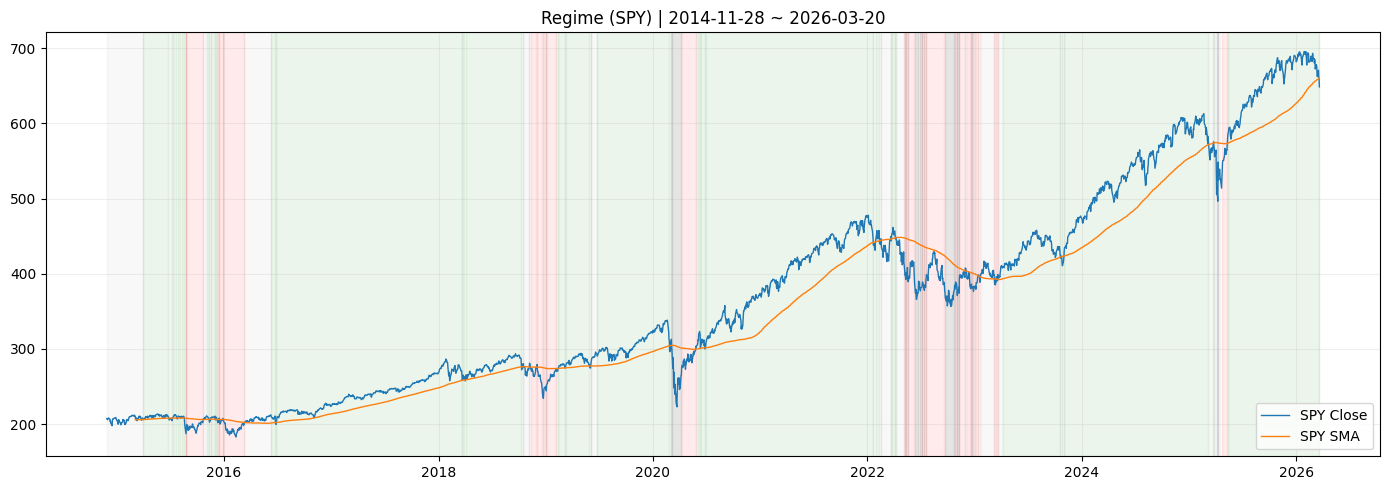


[Investability Report]
 Mean_IC              current=0.022613     target=0.040000     achv=56.5%      FAIL
 Spread               current=0.016600     target=0.030000     achv=55.3%      FAIL
 Positive_IC_Ratio    current=0.600806     target=0.550000     achv=109.2%     PASS
 IC_BEAR              current=0.062609     target=0.000000     achv=100.0%     PASS
 Factor_Count         current=12.000000    target=5.000000     achv=240.0%     PASS

[Data Quality Summary]
(empty)

[Factor Coverage Bottom]
(empty)

[Data Quality Sample]
(empty)
[PIOT META LOG] saved: /Users/shin-il/Documents/my stock/cache_fmp_c2_1/output/PIOT_META_LOG_v4_12_20260406_043415.txt
[DONE] saved: /Users/shin-il/Documents/my stock/cache_fmp_c2_1/output/SP500_PHASE2_BATCH11_20260406_043402.xlsx
[Timing] precompute=50.01s | meta=66216.74s | ga_final=35940.08s | excel=12.59s

[Phase2] Signal quality: MeanIC=0.0226 Spread=0.0166 PosICRatio=0.601
[Phase2] Frozen signal saved → /Users/shin-il/Documents/my stock/cache_fmp_c2

In [4]:
# Cell 3 - Experiment runner
# Run cells 0 -> 1 -> 2 first, then execute this cell.
# Change RUN_TARGET only.
# Phase 1 targets: LIVE_GAP / BULL_SPREAD / ... / IFS_MID_REVALID
# Phase 2 targets: P2_BATCH01 / P2_BATCH02 / P2_BATCH03

RUN_TARGET = "P2_BATCH11"
RUN_WRITE_REPORTS = True
RUN_SHOW_PROGRESS = True
RUN_QUIET_TQDM = False

# Frozen signal: set path to skip GA and reuse a saved signal.
# Leave empty "" to run GA normally (signal is auto-saved after GA completes).
# BATCH11: Meta Search + fresh GA — leave empty.
FROZEN_SIGNAL_PATH = ""


def _pick_run_bundle(target: str):
    target = str(target).strip().upper()
    bundles = {
        "LIVE_GAP": (LIVE_GAP_BASE_CFG, LIVE_GAP_EXPERIMENT_SPECS, LIVE_GAP_RUN_OPTIONS),
        "BULL_SPREAD": (BULL_SPREAD_BASE_CFG, BULL_SPREAD_EXPERIMENT_SPECS, BULL_SPREAD_RUN_OPTIONS),
        "INTERACTION_AB": (INTERACTION_AB_BASE_CFG, INTERACTION_AB_EXPERIMENT_SPECS, INTERACTION_AB_RUN_OPTIONS),
        "TOPQ_SWEEP": (TOPQ_SWEEP_BASE_CFG, TOPQ_SWEEP_EXPERIMENT_SPECS, TOPQ_SWEEP_RUN_OPTIONS),
        "TOPQ_REVALID_2ARM": (TOPQ_REVALID_2ARM_BASE_CFG, TOPQ_REVALID_2ARM_EXPERIMENT_SPECS, TOPQ_REVALID_2ARM_RUN_OPTIONS),
        "STRETCH60": (STRETCH60_BASE_CFG, STRETCH60_EXPERIMENT_SPECS, STRETCH60_RUN_OPTIONS),
        "SPREAD_RECOVERY": (SPREAD_RECOVERY_BASE_CFG, SPREAD_RECOVERY_EXPERIMENT_SPECS, SPREAD_RECOVERY_RUN_OPTIONS),
        "SPREAD_RECOVERY_TUNE": (SPREAD_RECOVERY_TUNE_BASE_CFG, SPREAD_RECOVERY_TUNE_EXPERIMENT_SPECS, SPREAD_RECOVERY_TUNE_RUN_OPTIONS),
        "OBJECTIVE_ARCH": (OBJECTIVE_ARCH_BASE_CFG, OBJECTIVE_ARCH_EXPERIMENT_SPECS, OBJECTIVE_ARCH_RUN_OPTIONS),
        "HYBRID_OBJECTIVE_RECOVERY": (HYBRID_OBJECTIVE_RECOVERY_BASE_CFG, HYBRID_OBJECTIVE_RECOVERY_EXPERIMENT_SPECS, HYBRID_OBJECTIVE_RECOVERY_RUN_OPTIONS),
        "SIGNAL_ARCH": (SIGNAL_ARCH_BASE_CFG, SIGNAL_ARCH_EXPERIMENT_SPECS, SIGNAL_ARCH_RUN_OPTIONS),
        "SIGNAL_ARCH_REVALID": (SIGNAL_ARCH_REVALID_BASE_CFG, SIGNAL_ARCH_REVALID_EXPERIMENT_SPECS, SIGNAL_ARCH_REVALID_RUN_OPTIONS),
        "SPREAD_PUSH": (SPREAD_PUSH_BASE_CFG, SPREAD_PUSH_EXPERIMENT_SPECS, SPREAD_PUSH_RUN_OPTIONS),
        "IC_FLOOR_SPREAD": (IC_FLOOR_SPREAD_BASE_CFG, IC_FLOOR_SPREAD_EXPERIMENT_SPECS, IC_FLOOR_SPREAD_RUN_OPTIONS),
        "IFS_MID_REVALID": (IFS_MID_REVALID_BASE_CFG, IFS_MID_REVALID_EXPERIMENT_SPECS, IFS_MID_REVALID_RUN_OPTIONS),
    }
    if target not in bundles:
        raise ValueError(f"Unsupported RUN_TARGET: {target}")
    return bundles[target]


def _pick_check_cols(target: str):
    target = str(target).strip().upper()
    if target == "LIVE_GAP":
        return [
            "ExperimentName", "Status",
            "TodayTop10Date", "LiveTop10Date", "EvalLastDate",
            "EvalLiveDateGapDays", "PseudoLiveCutoffCount",
            "PseudoLiveSpread3M", "PseudoLivePositiveRatio", "PseudoLiveDecayVsEval",
            "Phase1LiveGapPass", "Phase1PseudoLivePass", "Phase1ShadowPass",
        ]
    if target == "BULL_SPREAD":
        return [
            "ExperimentName", "Status",
            "BullIC1M", "BullIC3M", "BullSpreadMix", "BullFloorPen", "BullSpreadBonus",
            "Invest_MeanIC", "Invest_Spread",
            "PseudoLiveSpread3M", "PseudoLivePositiveRatio", "Phase1ShadowPass",
            "PortfolioMeanFwd3M", "PortfolioAvgTurnover",
        ]
    if target == "INTERACTION_AB":
        return [
            "ExperimentName", "Status", "BullSpreadMix",
            "Invest_MeanIC", "Invest_Spread",
            "PseudoLiveSpread3M", "PseudoLivePositiveRatio", "Phase1ShadowPass",
            "PortfolioMeanFwd3M", "PortfolioAvgTurnover", "SelectedFactorCount",
        ]
    if target == "SIGNAL_ARCH":
        return [
            "ExperimentName", "Status",
            "BullIC1M", "BullIC3M", "BullSpreadMix",
            "Invest_MeanIC", "Invest_Spread", "Invest_PosICRatio",
            "PseudoLiveSpread3M", "PseudoLivePositiveRatio",
            "HardGatePass", "MinimumPass", "SelectedFactorCount",
        ]
    return [
        "ExperimentName", "Status", "TopQuantile", "BullSpreadMix",
        "Invest_MeanIC", "Invest_Spread", "Invest_PosICRatio",
        "PseudoLiveSpread3M", "PseudoLivePositiveRatio",
        "PortfolioMeanFwd3M", "PortfolioAvgTurnover",
        "HardGateAchPct", "HardGatePass",
        "MinimumAchPct", "MinimumPass",
        "TargetAchPct", "TargetPass",
        "InstitutionalAchPct", "InstitutionalPass",
        "SelectedFactorCount",
    ]


# ──────────────────────────────────────────
# Dispatch
# ──────────────────────────────────────────
if RUN_TARGET.strip().upper().startswith("P2_"):
    # ═══════════════════════════════════════
    # Phase 2: Portfolio Parameter Sweep
    # ═══════════════════════════════════════
    _p2_target = RUN_TARGET.strip().upper()

    if _p2_target == "P2_BATCH01":
        _p2_base_cfg = PHASE2_BATCH01_BASE_CFG
        _p2_portfolio_configs = PHASE2_BATCH01_PORTFOLIO_CONFIGS
        _p2_signal_overrides = PHASE2_BATCH01_SIGNAL_OVERRIDES
        _p2_commission = PHASE2_BATCH01_COMMISSION_BPS
        _p2_slippage = PHASE2_BATCH01_SLIPPAGE_BPS
    elif _p2_target == "P2_BATCH02":
        _p2_base_cfg = PHASE2_BATCH02_BASE_CFG
        _p2_portfolio_configs = PHASE2_BATCH02_PORTFOLIO_CONFIGS
        _p2_signal_overrides = PHASE2_BATCH02_SIGNAL_OVERRIDES
        _p2_commission = PHASE2_BATCH02_COMMISSION_BPS
        _p2_slippage = PHASE2_BATCH02_SLIPPAGE_BPS
    elif _p2_target == "P2_BATCH03":
        _p2_base_cfg = PHASE2_BATCH03_BASE_CFG
        _p2_portfolio_configs = PHASE2_BATCH03_PORTFOLIO_CONFIGS
        _p2_signal_overrides = PHASE2_BATCH03_SIGNAL_OVERRIDES
        _p2_commission = PHASE2_BATCH03_COMMISSION_BPS
        _p2_slippage = PHASE2_BATCH03_SLIPPAGE_BPS
    elif _p2_target == "P2_BATCH04":
        _p2_base_cfg = PHASE2_BATCH04_BASE_CFG
        _p2_portfolio_configs = PHASE2_BATCH04_PORTFOLIO_CONFIGS
        _p2_signal_overrides = PHASE2_BATCH04_SIGNAL_OVERRIDES
        _p2_commission = PHASE2_BATCH04_COMMISSION_BPS
        _p2_slippage = PHASE2_BATCH04_SLIPPAGE_BPS
    elif _p2_target == "P2_BATCH05":
        _p2_base_cfg = PHASE2_BATCH05_BASE_CFG
        _p2_portfolio_configs = PHASE2_BATCH05_PORTFOLIO_CONFIGS
        _p2_signal_overrides = PHASE2_BATCH05_SIGNAL_OVERRIDES
        _p2_commission = PHASE2_BATCH05_COMMISSION_BPS
        _p2_slippage = PHASE2_BATCH05_SLIPPAGE_BPS
    elif _p2_target == "P2_BATCH06":
        _p2_base_cfg = PHASE2_BATCH06_BASE_CFG
        _p2_portfolio_configs = PHASE2_BATCH06_PORTFOLIO_CONFIGS
        _p2_signal_overrides = PHASE2_BATCH06_SIGNAL_OVERRIDES
        _p2_commission = PHASE2_BATCH06_COMMISSION_BPS
        _p2_slippage = PHASE2_BATCH06_SLIPPAGE_BPS
    elif _p2_target == "P2_BATCH07":
        _p2_base_cfg = PHASE2_BATCH07_BASE_CFG
        _p2_portfolio_configs = PHASE2_BATCH07_PORTFOLIO_CONFIGS
        _p2_signal_overrides = PHASE2_BATCH07_SIGNAL_OVERRIDES
        _p2_commission = PHASE2_BATCH07_COMMISSION_BPS
        _p2_slippage = PHASE2_BATCH07_SLIPPAGE_BPS
    elif _p2_target == "P2_BATCH08":
        _p2_base_cfg = PHASE2_BATCH08_BASE_CFG
        _p2_portfolio_configs = PHASE2_BATCH08_PORTFOLIO_CONFIGS
        _p2_signal_overrides = PHASE2_BATCH08_SIGNAL_OVERRIDES
        _p2_commission = PHASE2_BATCH08_COMMISSION_BPS
        _p2_slippage = PHASE2_BATCH08_SLIPPAGE_BPS
    elif _p2_target == "P2_BATCH09":
        _p2_base_cfg = PHASE2_BATCH09_BASE_CFG
        _p2_portfolio_configs = PHASE2_BATCH09_PORTFOLIO_CONFIGS
        _p2_signal_overrides = PHASE2_BATCH09_SIGNAL_OVERRIDES
        _p2_commission = PHASE2_BATCH09_COMMISSION_BPS
        _p2_slippage = PHASE2_BATCH09_SLIPPAGE_BPS
    elif _p2_target == "P2_BATCH10":
        _p2_base_cfg = PHASE2_BATCH10_BASE_CFG
        _p2_portfolio_configs = PHASE2_BATCH10_PORTFOLIO_CONFIGS
        _p2_signal_overrides = PHASE2_BATCH10_SIGNAL_OVERRIDES
        _p2_commission = PHASE2_BATCH10_COMMISSION_BPS
        _p2_slippage = PHASE2_BATCH10_SLIPPAGE_BPS
    elif _p2_target == "P2_BATCH11":
        _p2_base_cfg = PHASE2_BATCH11_BASE_CFG
        _p2_portfolio_configs = PHASE2_BATCH11_PORTFOLIO_CONFIGS
        _p2_signal_overrides = PHASE2_BATCH11_SIGNAL_OVERRIDES
        _p2_commission = PHASE2_BATCH11_COMMISSION_BPS
        _p2_slippage = PHASE2_BATCH11_SLIPPAGE_BPS
    elif _p2_target == "P2_BATCH11T":
        _p2_base_cfg = PHASE2_BATCH11T_BASE_CFG
        _p2_portfolio_configs = PHASE2_BATCH11T_PORTFOLIO_CONFIGS
        _p2_signal_overrides = PHASE2_BATCH11T_SIGNAL_OVERRIDES
        _p2_commission = PHASE2_BATCH11T_COMMISSION_BPS
        _p2_slippage = PHASE2_BATCH11T_SLIPPAGE_BPS
    else:
        raise ValueError(f"Unsupported Phase 2 RUN_TARGET: {RUN_TARGET}")

    print(
        f"[Phase2] target={_p2_target} portfolio_configs={len(_p2_portfolio_configs)} "
        f"commission={_p2_commission}bps slippage={_p2_slippage}bps"
    )

    # Step 1: obtain signal — either run GA or load frozen signal
    _p2_frozen = str(FROZEN_SIGNAL_PATH).strip()
    _p2_signal_ok = False

    if _p2_frozen and os.path.exists(_p2_frozen):
        # ── Load frozen signal (skip GA entirely) ──
        print(f"[Phase2] Step 1: Loading FROZEN signal from {_p2_frozen}")
        _fs = np.load(_p2_frozen, allow_pickle=True)
        _p2_best_mask = np.asarray(_fs["mask"], dtype=bool)
        _p2_best_wb = np.asarray(_fs["wb"], dtype=np.float64)
        _p2_best_ws = np.asarray(_fs["ws"], dtype=np.float64)
        _p2_best_wd = np.asarray(_fs["wd"], dtype=np.float64)
        _p2_signal_summary = json.loads(str(_fs["signal_summary"])) if "signal_summary" in _fs else {}
        print(
            f"[Phase2] Frozen signal loaded: k_used={int(_p2_best_mask.sum())} "
            f"MeanIC={_p2_signal_summary.get('Invest_MeanIC', float('nan')):.4f} "
            f"Spread={_p2_signal_summary.get('Invest_Spread', float('nan')):.4f} "
            f"PosICRatio={_p2_signal_summary.get('Invest_PosICRatio', float('nan')):.3f}"
        )
        # Apply signal overrides so portfolio scoring uses the same factor pools
        # that the GA used when training this frozen signal.
        _p2_final_cfg = make_cfg_with_overrides(_p2_base_cfg, {
            k: v for k, v in _p2_signal_overrides.items() if k != "use_random_seed"
        })
        print(f"[Phase2] Signal overrides applied to final_cfg: {[k for k in _p2_signal_overrides if k != 'use_random_seed']}")
        print("[Phase2] Preparing data inputs (pack + regime)...")
        _p2_prep = prepare_inputs(_p2_final_cfg)
        _p2_pack = _p2_prep["pack"]
        _p2_regime_by_date = _p2_prep.get("regime_by_date")
        _p2_signal_ok = True
    else:
        # ── Run GA normally ──
        if _p2_frozen:
            print(f"[Phase2] WARNING: FROZEN_SIGNAL_PATH={_p2_frozen!r} not found, running GA.")
        print("[Phase2] Step 1: Running GA to obtain signal...")
        _p2_signal_spec = {
            "name": "P2_SIGNAL_RUN",
            "notes": "Phase 2 signal extraction (SA_VAL_QUALITY_MOM_REVALID frozen signal)",
            "cfg_overrides": dict(_p2_signal_overrides),
        }
        _p2_signal_result = run_single_experiment(
            base_cfg=_p2_base_cfg,
            spec=_p2_signal_spec,
            write_reports=RUN_WRITE_REPORTS,
            report_prefix="P2_SIGNAL",
        )
        if _p2_signal_result["status"] != "OK":
            print(f"[Phase2] SIGNAL RUN FAILED: {_p2_signal_result['error_text']}")
        else:
            _p2_pack = _p2_signal_result["prepared_inputs"]["pack"]
            _p2_regime_by_date = _p2_signal_result["prepared_inputs"].get("regime_by_date")
            _p2_final_cfg = _p2_signal_result["search_bundle"]["final_cfg"]
            _p2_best_mask = np.asarray(_p2_signal_result["search_bundle"]["best_mask"], dtype=bool)
            _p2_best_wb = np.asarray(_p2_signal_result["search_bundle"]["best_wb"], dtype=np.float64)
            _p2_best_ws = np.asarray(_p2_signal_result["search_bundle"]["best_ws"], dtype=np.float64)
            _p2_best_wd = np.asarray(_p2_signal_result["search_bundle"]["best_wd"], dtype=np.float64)
            _p2_signal_summary = _p2_signal_result["summary_row"]
            print(
                f"\n[Phase2] Signal quality: "
                f"MeanIC={_p2_signal_summary.get('Invest_MeanIC', np.nan):.4f} "
                f"Spread={_p2_signal_summary.get('Invest_Spread', np.nan):.4f} "
                f"PosICRatio={_p2_signal_summary.get('Invest_PosICRatio', np.nan):.3f}"
            )
            # ── Auto-save frozen signal ──
            _p2_save_dir = getattr(_p2_base_cfg, "save_dir", "output")
            os.makedirs(_p2_save_dir, exist_ok=True)
            _fs_stamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
            _fs_path = os.path.join(_p2_save_dir, f"frozen_signal_{_p2_target}_{_fs_stamp}.npz")
            np.savez(
                _fs_path,
                mask=_p2_best_mask,
                wb=_p2_best_wb, ws=_p2_best_ws, wd=_p2_best_wd,
                signal_summary=json.dumps({
                    k: float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v
                    for k, v in _p2_signal_summary.items()
                    if k.startswith("Invest_")
                }),
            )
            print(f"[Phase2] Frozen signal saved → {_fs_path}")
            print(f"[Phase2] To reuse: set FROZEN_SIGNAL_PATH = \"{_fs_path}\"")
            _p2_signal_ok = True

    if _p2_signal_ok:

        # Build VIX fast regime if any config needs it
        _p2_vix_regime_by_date = None
        _any_vix = any(pc.get('overrides', {}).get('enable_vix_fast_regime', False) for pc in _p2_portfolio_configs)
        if not _any_vix:
            _any_vix = bool(getattr(_p2_final_cfg, 'enable_vix_fast_regime', False))
        # Also build VIX regime if any config uses circuit-breaker
        _any_cb = any(pc.get('overrides', {}).get('enable_circuit_breaker', False) for pc in _p2_portfolio_configs)
        _any_ra = _any_vix or _any_cb
        if _any_ra:
            print("[Phase2] Building VIX fast regime timeseries...")
            try:
                _vix_start = _p2_final_cfg.start_panel_date - timedelta(days=400)
                _vix_end = _p2_final_cfg.end_date
                _vix_ts = build_vix_regime_timeseries(_p2_final_cfg, _vix_start, _vix_end)
                _p2_vix_regime_by_date = {
                    row.name.strftime('%Y-%m-%d') if hasattr(row.name, 'strftime') else str(row.name): str(row['regime'])
                    for _, row in _vix_ts.iterrows()
                }
                _vix_dist = _vix_ts['regime'].value_counts().to_dict()
                print(f"[Phase2] VIX regime: {len(_p2_vix_regime_by_date)} days, dist={_vix_dist}")
            except Exception as _vix_e:
                print(f"[Phase2] VIX regime build FAILED: {_vix_e} — falling back to SMA regime")
                _p2_vix_regime_by_date = None

        # Step 2: sweep portfolio configs
        print(f"\n[Phase2] Step 2: Sweeping {len(_p2_portfolio_configs)} portfolio configs...")
        p2_sweep_df = run_phase2_portfolio_sweep(
            pack=_p2_pack,
            cfg=_p2_final_cfg,
            best_mask=_p2_best_mask,
            best_wb=_p2_best_wb,
            best_ws=_p2_best_ws,
            best_wd=_p2_best_wd,
            regime_by_date=_p2_regime_by_date,
            portfolio_configs=_p2_portfolio_configs,
            commission_bps=_p2_commission,
            slippage_bps=_p2_slippage,
            vix_regime_by_date=_p2_vix_regime_by_date,
        )

        # Step 3: Phase 2 gate evaluation
        print_phase2_sweep_report(p2_sweep_df)

        p2_gate_df = build_phase2_gate_report(p2_sweep_df)
        p2_goal_summary = build_phase2_goal_summary(p2_sweep_df)

        print("\n[Phase 2 Gate Report]")
        print(p2_gate_df.to_string(index=False))
        print("\n[Phase 2 Goal Summary]")
        print(p2_goal_summary.to_string(index=False))

        # Save results to Excel + TXT compare report
        _p2_save_dir = getattr(_p2_base_cfg, "save_dir", "output")
        os.makedirs(_p2_save_dir, exist_ok=True)
        _p2_stamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
        _p2_batch_label = _p2_target.replace('P2_', '')
        _p2_excel_path = os.path.join(_p2_save_dir, f"SP500_PHASE2_{_p2_batch_label}_SWEEP_{_p2_stamp}.xlsx")
        with pd.ExcelWriter(_p2_excel_path, engine="openpyxl") as w:
            p2_sweep_df.to_excel(w, sheet_name="Sweep_Results", index=False)
            p2_gate_df.to_excel(w, sheet_name="Gate_Report", index=False)
            p2_goal_summary.to_excel(w, sheet_name="Goal_Summary", index=False)

        # TXT compare report (mirrors Phase 1 structure)
        _p2_compact_cols = [
            "ConfigName", "Net_CAGR", "Gross_CAGR", "Net_Sharpe", "Gross_Sharpe",
            "Max_Drawdown", "Calmar_Ratio", "Monthly_WinRate", "Annual_Turnover",
            "Gross_to_Net_Decay", "Mean_Net_Fwd1M", "Portfolio_Top_N",
            "RegimeAdaptive", "RegimeSource", "CashPct_Profile", "Avg_CashPct",
            "Avg_EffectiveCashPct", "CB_ActivePct",
            "Weight_Mode", "Max_Weight_Cap", "Commission_BPS", "Slippage_BPS",
        ]
        _p2_compact_df = p2_sweep_df[[c for c in _p2_compact_cols if c in p2_sweep_df.columns]].copy()
        _p2_txt_lines = [
            f"[Phase 2 {_p2_batch_label} Compare Report]",
            f"ExcelPath={_p2_excel_path}",
            f"ConfigCount={len(p2_sweep_df)}",
            f"Commission={_p2_commission}bps  Slippage={_p2_slippage}bps  RoundTrip={_p2_commission + _p2_slippage}bps",
            "",
            "[Signal Quality (Phase 1 frozen signal)]",
            f"  MeanIC       = {_p2_signal_summary.get('Invest_MeanIC', float('nan')):.4f}",
            f"  Spread       = {_p2_signal_summary.get('Invest_Spread', float('nan')):.4f}",
            f"  PosICRatio   = {_p2_signal_summary.get('Invest_PosICRatio', float('nan')):.3f}",
            "",
            "[Compact Sweep Summary]",
            _safe_table_to_text(_p2_compact_df, max_rows=20),
            "",
            "[Phase 2 Goal Summary]",
            _safe_table_to_text(p2_goal_summary, max_rows=20),
            "",
            "[Phase 2 Gate Report]",
            _safe_table_to_text(p2_gate_df, max_rows=80),
        ]
        _p2_txt_path = os.path.splitext(_p2_excel_path)[0] + ".txt"
        with open(_p2_txt_path, "w", encoding="utf-8") as _f:
            _f.write("\n".join(_p2_txt_lines))
        print(f"\n[Phase2] Excel : {_p2_excel_path}")
        print(f"[Phase2] TXT   : {_p2_txt_path}")

else:
    # ═══════════════════════════════════════
    # Phase 1: Standard Experiment Batch
    # ═══════════════════════════════════════
    selected_base_cfg, selected_specs, selected_run_options = _pick_run_bundle(RUN_TARGET)
    selected_run_options = dict(selected_run_options)
    selected_run_options["write_reports"] = RUN_WRITE_REPORTS
    selected_run_options["show_progress"] = RUN_SHOW_PROGRESS
    selected_run_options["quiet_tqdm"] = RUN_QUIET_TQDM

    print(
        f"[ExperimentRun] target={RUN_TARGET} count={len(selected_specs)} "
        f"write_reports={RUN_WRITE_REPORTS} ga_pop={getattr(selected_base_cfg, 'ga_population', 'NA')} "
        f"ga_gen={getattr(selected_base_cfg, 'ga_generations', 'NA')}"
    )

    selected_result = run_experiment_batch(
        base_cfg=selected_base_cfg,
        experiment_specs=selected_specs,
        **selected_run_options,
    )

    selected_summary_df = selected_result["summary_df"].copy()
    selected_cols = _pick_check_cols(RUN_TARGET)
    selected_check_df = selected_summary_df[[c for c in selected_cols if c in selected_summary_df.columns]].copy()

    print(selected_check_df.to_string(index=False))
    print(selected_result["compare_paths"])


In [2]:
# Cell 1 - Batch helpers and report helpers
from __future__ import annotations

import traceback
from dataclasses import asdict, is_dataclass
from pathlib import Path
from typing import Sequence, Callable

try:
    from IPython.display import display as _ipy_display
except Exception:
    _ipy_display = None

try:
    from tqdm import tqdm as _tqdm
except Exception:
    _tqdm = None


# =========================
# Batch experiment helpers
# =========================
def _cfg_to_plain_dict(cfg: Config) -> Dict[str, Any]:
    if is_dataclass(cfg):
        return dict(asdict(cfg))
    if hasattr(cfg, "__dict__"):
        return dict(vars(cfg))
    return dict(cfg)


def make_cfg_with_overrides(base_cfg: Config, overrides: Optional[Dict[str, Any]] = None) -> Config:
    """Return a fresh Config instance with a small override dict applied."""
    overrides = dict(overrides or {})
    base_kwargs = _cfg_to_plain_dict(base_cfg)
    allowed_keys = set(base_kwargs.keys())
    unknown_keys = sorted(k for k in overrides.keys() if k not in allowed_keys)
    if unknown_keys:
        raise KeyError(f"Unknown Config override key(s): {unknown_keys}")
    base_kwargs.update({k: overrides[k] for k in overrides.keys() if k in allowed_keys})
    return base_cfg.__class__(**base_kwargs)


def diff_cfg_keys(base_cfg: Config, other_cfg: Config) -> pd.DataFrame:
    """Return a compact table of Config fields that changed."""
    base_map = _cfg_to_plain_dict(base_cfg)
    other_map = _cfg_to_plain_dict(other_cfg)
    rows = []
    for key in sorted(set(base_map.keys()) | set(other_map.keys())):
        base_val = base_map.get(key, None)
        other_val = other_map.get(key, None)
        if base_val != other_val:
            rows.append(
                {
                    "Key": key,
                    "BaseValue": str(base_val),
                    "NewValue": str(other_val),
                }
            )
    return pd.DataFrame(rows, columns=["Key", "BaseValue", "NewValue"])


def _table_metric_value(df: Optional[pd.DataFrame], metric: str, *, key_col: str = "Metric", value_col: str = "Current") -> Any:
    if df is None or df.empty or key_col not in df.columns:
        return np.nan
    sub = df.loc[df[key_col].astype(str) == str(metric)]
    if sub.empty or value_col not in sub.columns:
        return np.nan
    return sub.iloc[0][value_col]


def _make_inline_status_updater(enabled: bool = True, prefix: str = "[Batch]") -> Callable[[str], None]:
    """Return a single-line status updater that does not spam new rows."""
    state = {"last": ""}

    def _update(message: str) -> None:
        if not enabled:
            return
        text = f"{prefix} {message}"
        if _ipy_display is not None:
            # In notebooks, reuse the same display output instead of appending rows.
            if state.get("handle") is None:
                state["handle"] = _ipy_display(text, display_id=True)
            else:
                try:
                    state["handle"].update(text)
                except Exception:
                    state["handle"] = _ipy_display(text, display_id=True)
        else:
            pad = max(len(state["last"]) - len(text), 0)
            sys.stdout.write("\r" + text + (" " * pad))
            sys.stdout.flush()
            state["last"] = text

    return _update


_QUIET_TQDM_STATUS_FN: Optional[Callable[[str], None]] = None
_QUIET_TQDM_LABEL: str = ""


def _set_quiet_tqdm_context(status_fn: Optional[Callable[[str], None]], label: str) -> None:
    global _QUIET_TQDM_STATUS_FN, _QUIET_TQDM_LABEL
    _QUIET_TQDM_STATUS_FN = status_fn
    _QUIET_TQDM_LABEL = str(label)


def _clear_quiet_tqdm_context() -> None:
    global _QUIET_TQDM_STATUS_FN, _QUIET_TQDM_LABEL
    _QUIET_TQDM_STATUS_FN = None
    _QUIET_TQDM_LABEL = ""


class _QuietTqdm:
    """Minimal tqdm drop-in that redirects progress into a single status line."""
    def __init__(self, iterable=None, *args, **kwargs):
        self.iterable = iterable if iterable is not None else []
        self.desc = str(kwargs.get("desc", "")).strip()
        self.postfix = ""
        self.last_pct = -1
        total = kwargs.get("total", None)
        if total is not None:
            self.total = int(total)
        else:
            try:
                self.total = len(self.iterable)
            except Exception:
                self.total = 0
        self._emit(0)

    def _emit(self, current: int) -> None:
        cb = _QUIET_TQDM_STATUS_FN
        if cb is None or self.total <= 0:
            return
        pct = int(round(100.0 * float(current) / max(float(self.total), 1.0)))
        if pct == self.last_pct:
            return
        msg = f"{_QUIET_TQDM_LABEL}: {self.desc} {pct}%"
        if self.postfix:
            msg += f" | {self.postfix}"
        cb(msg)
        self.last_pct = pct

    def __iter__(self):
        total = self.total if self.total > 0 else None
        for i, item in enumerate(self.iterable, start=1):
            yield item
            if total is not None:
                self._emit(i)

    def update(self, n=1, *args, **kwargs):
        if self.total > 0:
            next_pct = min(self.total, max(0, int(n)))
            self._emit(next_pct)
        return None

    def set_postfix(self, *args, **kwargs):
        try:
            if kwargs:
                self.postfix = ", ".join(f"{k}={v}" for k, v in kwargs.items())
            elif args:
                self.postfix = str(args[0])
        except Exception:
            self.postfix = ""
        return None

    def close(self):
        if self.total > 0:
            self._emit(self.total)
        return None

    def __len__(self):
        try:
            return len(self.iterable)
        except Exception:
            return 0


def _safe_df_tail_date(df: Optional[pd.DataFrame], date_col: str = "Date") -> Any:
    if df is None or df.empty or date_col not in df.columns:
        return None
    try:
        ser = pd.to_datetime(df[date_col], errors="coerce")
        ser = ser.dropna()
        if ser.empty:
            return None
        return ser.max().to_pydatetime().date()
    except Exception:
        try:
            return str(df[date_col].iloc[-1])
        except Exception:
            return None


def _safe_first_date(df: Optional[pd.DataFrame], date_col: str = "Date") -> Any:
    if df is None or df.empty or date_col not in df.columns:
        return None
    try:
        val = pd.to_datetime(df[date_col].iloc[0], errors="coerce")
        if pd.isna(val):
            return str(df[date_col].iloc[0])
        return val.to_pydatetime().date()
    except Exception:
        try:
            return str(df[date_col].iloc[0])
        except Exception:
            return None


def _as_bool(value: Any) -> bool:
    if isinstance(value, bool):
        return value
    if value is None:
        return False
    if isinstance(value, (int, float)):
        return bool(value)
    text = str(value).strip().lower()
    return text in {"1", "true", "yes", "y", "on"}


def _date_gap_days(left_date: Any, right_date: Any) -> Any:
    try:
        if left_date is None or right_date is None:
            return np.nan
        left_ts = pd.to_datetime(left_date, errors="coerce")
        right_ts = pd.to_datetime(right_date, errors="coerce")
        if pd.isna(left_ts) or pd.isna(right_ts):
            return np.nan
        return float((right_ts - left_ts).days)
    except Exception:
        return np.nan


def _recent_periodic_cutoff_indices(pack: dict, cfg: Config, n_cutoffs: int = 12, freq: str = "M") -> List[int]:
    dates = list(pack.get("dates", []))
    if not dates:
        return []
    D = len(dates)
    h3 = int(getattr(cfg, "horizon_3m", 60))
    valid_idx = [di for di in range(D) if di + h3 < D]
    if not valid_idx:
        return []

    dt = pd.to_datetime(pd.Index([dates[di] for di in valid_idx]), errors="coerce")
    base = pd.DataFrame({"di": valid_idx, "dt": dt}).dropna(subset=["dt"])
    if base.empty:
        return []
    base["period_key"] = base["dt"].dt.to_period(str(freq))
    grouped = base.sort_values("dt").groupby("period_key", as_index=False).tail(1)
    grouped = grouped.sort_values("dt").tail(int(n_cutoffs))
    return [int(x) for x in grouped["di"].tolist()]


def compute_pseudo_live_transfer_metrics(
    pack: dict,
    cfg: Config,
    mask: np.ndarray,
    w_bull: np.ndarray,
    w_side: np.ndarray,
    w_def: np.ndarray,
    regime_by_date: Optional[Dict[str, str]] = None,
    top_n: int = 10,
    n_cutoffs: int = 12,
    cutoff_freq: str = "M",
) -> Dict[str, Any]:
    cols = [
        "CutoffDate",
        "ScoreRegime",
        "TopN",
        "Top10Fwd3M",
        "UniverseMeanFwd3M",
        "Spread3M",
    ]
    dates = list(pack.get("dates", []))
    tickers = list(pack.get("tickers", []))
    if not dates or not tickers:
        return {"metrics": {}, "detail_df": pd.DataFrame(columns=cols)}

    close = np.asarray(pack.get("close", np.zeros((0, 0))), dtype=np.float64)
    tradable = np.asarray(pack.get("tradable", np.zeros((0, 0), dtype=bool)), dtype=bool)
    fwd3 = np.asarray(pack.get("fwd3", np.full((len(dates), len(tickers)), np.nan)), dtype=np.float64)
    sel = np.asarray(mask, dtype=bool)
    if sel.size <= 0 or not np.any(sel):
        return {"metrics": {}, "detail_df": pd.DataFrame(columns=cols)}

    active_w_bull = get_regime_active_weight_vector(cfg, sel, sel, sel, w_bull, w_side, w_def, "BULL")
    active_w_side = get_regime_active_weight_vector(cfg, sel, sel, sel, w_bull, w_side, w_def, "SIDE")
    active_w_def = get_regime_active_weight_vector(cfg, sel, sel, sel, w_bull, w_side, w_def, "DEFENSIVE")

    rows = []
    for di in _recent_periodic_cutoff_indices(pack, cfg, n_cutoffs=n_cutoffs, freq=cutoff_freq):
        d = dates[di]
        diag_regime = str(regime_by_date.get(d, "SIDE")) if regime_by_date is not None else "SIDE"
        score_regime = _collapse_diag_regime_to_scoring(diag_regime)
        scores = _score_vector_for_regime(
            pack=pack,
            di=di,
            sel=sel,
            active_w_bull=active_w_bull,
            active_w_side=active_w_side,
            active_w_def=active_w_def,
            score_regime=score_regime,
            cfg=cfg,
        )
        score100 = 100.0 * np.clip(scores, 0.0, 1.0)
        usable = np.asarray(tradable[di], dtype=bool) & np.isfinite(close[di]) & (close[di] > 0) & np.isfinite(score100) & np.isfinite(fwd3[di])
        usable_idx = np.where(usable)[0]
        if usable_idx.size <= 0:
            continue
        order = usable_idx[np.argsort(-score100[usable_idx])]
        top_idx = order[:max(1, min(int(top_n), int(order.size)))]
        top_mean = float(np.nanmean(fwd3[di, top_idx])) if top_idx.size > 0 else np.nan
        bench_mean = float(np.nanmean(fwd3[di, usable_idx])) if usable_idx.size > 0 else np.nan
        spread = float(top_mean - bench_mean) if np.isfinite(top_mean) and np.isfinite(bench_mean) else np.nan
        rows.append(
            {
                "CutoffDate": str(d),
                "ScoreRegime": score_regime,
                "TopN": int(len(top_idx)),
                "Top10Fwd3M": top_mean,
                "UniverseMeanFwd3M": bench_mean,
                "Spread3M": spread,
            }
        )

    detail_df = pd.DataFrame(rows, columns=cols)
    if detail_df.empty:
        return {"metrics": {}, "detail_df": detail_df}

    spread_ser = pd.to_numeric(detail_df["Spread3M"], errors="coerce")
    top_ser = pd.to_numeric(detail_df["Top10Fwd3M"], errors="coerce")
    bench_ser = pd.to_numeric(detail_df["UniverseMeanFwd3M"], errors="coerce")
    metrics = {
        "PseudoLiveCutoffCount": int(len(detail_df)),
        "PseudoLiveSpread3M": float(spread_ser.mean()),
        "PseudoLivePositiveRatio": float(np.mean(spread_ser.fillna(-np.inf) > 0)) if len(spread_ser) > 0 else np.nan,
        "PseudoLiveMeanTop10Fwd3M": float(top_ser.mean()),
        "PseudoLiveMeanUniverseFwd3M": float(bench_ser.mean()),
    }
    return {"metrics": metrics, "detail_df": detail_df}


def _phase1_goal_row(
    exp_name: str,
    group_name: str,
    metric_name: str,
    current: float,
    target: Any,
    *,
    comparator: str = "ge",
) -> Dict[str, Any]:
    current_val = _to_float(current)
    pass_flag = False
    achievement = np.nan

    if comparator == "eq1":
        pass_flag = bool(np.isfinite(current_val) and current_val >= 1.0)
        achievement = 100.0 if pass_flag else 0.0
    elif comparator == "gt0":
        pass_flag = bool(np.isfinite(current_val) and current_val > 0)
        achievement = 100.0 if pass_flag else 0.0
    else:
        target_val = _to_float(target)
        pass_flag = bool(np.isfinite(current_val) and np.isfinite(target_val) and current_val >= target_val)
        achievement = (100.0 * current_val / target_val) if np.isfinite(current_val) and np.isfinite(target_val) and abs(target_val) > 1e-12 else np.nan

    return {
        "ExperimentName": exp_name,
        "Group": group_name,
        "Metric": metric_name,
        "Current": current_val,
        "Target": target,
        "AchievementPct": achievement,
        "Pass": "PASS" if pass_flag else "FAIL",
    }


# Phase 1 sanity-check gates (unchanged)
PHASE1_HARD_TARGETS = {
    "LiveTop10Count": (10.0, "ge"),
    "LiveTop10SameAsToday": (1.0, "eq1"),
    "EvalLiveDateGapDays": (">0", "gt0"),
    "PseudoLiveSpread3M": (">0", "gt0"),
    "PseudoLivePositiveRatio": (0.60, "ge"),
    "PseudoLiveDecayVsEval": (0.60, "ge"),
}

# Phase 1 Signal Quality — 3-tier (v4: Risk-Adjusted Revision)
PHASE1_MINIMUM_TARGETS = {
    "Invest_MeanIC": (0.020, "ge"),
    "Invest_Spread": (0.015, "ge"),
    "Invest_PosICRatio": (0.58, "ge"),
}
PHASE1_TARGET_TARGETS = {
    "Invest_MeanIC": (0.025, "ge"),
    "Invest_Spread": (0.020, "ge"),
    "Invest_PosICRatio": (0.60, "ge"),
}
PHASE1_INSTITUTIONAL_TARGETS = {
    "Invest_MeanIC": (0.035, "ge"),
    "Invest_Spread": (0.030, "ge"),
    "Invest_PosICRatio": (0.62, "ge"),
}

# Backward-compat aliases for Phase 1 runner (maps old names to new Minimum tier)
PHASE1_MAIN_TARGETS = PHASE1_MINIMUM_TARGETS
PHASE1_STRETCH_TARGETS = PHASE1_INSTITUTIONAL_TARGETS


# =========================
# Phase 2 Gate Targets (Phase 3 entry conditions)
# v4 — 3-tier Risk-Adjusted Revision (WinRate removed)
# =========================
PHASE2_BACKTEST_MINIMUM = {
    "Net_CAGR":      (0.12, "ge"),
    "Max_Drawdown":  (0.40, "le"),
    "Net_Sharpe":    (0.70, "ge"),
    "Calmar_Ratio":  (0.40, "ge"),
}
PHASE2_BACKTEST_TARGET = {
    "Net_CAGR":      (0.16, "ge"),
    "Max_Drawdown":  (0.32, "le"),
    "Net_Sharpe":    (0.85, "ge"),
    "Calmar_Ratio":  (0.55, "ge"),
}
PHASE2_BACKTEST_INSTITUTIONAL = {
    "Net_CAGR":      (0.18, "ge"),
    "Max_Drawdown":  (0.25, "le"),
    "Net_Sharpe":    (1.00, "ge"),
    "Calmar_Ratio":  (0.70, "ge"),
}
# Backward-compat alias
PHASE2_BACKTEST_TARGETS = PHASE2_BACKTEST_MINIMUM
PHASE2_STABILITY_MINIMUM  = {"Annual_Turnover": (26.0, "le")}
PHASE2_STABILITY_TARGET   = {"Annual_Turnover": (22.0, "le")}
PHASE2_STABILITY_INST     = {"Annual_Turnover": (18.0, "le")}
# Backward-compat aliases
PHASE2_STABILITY_TARGETS  = PHASE2_STABILITY_MINIMUM

PHASE2_COST_MINIMUM       = {"Gross_to_Net_Decay": (0.12, "le")}
PHASE2_COST_TARGET        = {"Gross_to_Net_Decay": (0.08, "le")}
PHASE2_COST_INST          = {"Gross_to_Net_Decay": (0.05, "le")}
# Backward-compat alias
PHASE2_COST_TARGETS       = PHASE2_COST_MINIMUM


def _phase2_goal_row(
    cfg_name: str,
    group_name: str,
    metric_name: str,
    current: float,
    target: float,
    comparator: str = "ge",
) -> Dict[str, Any]:
    """Phase 2 gate row builder. Supports both 'ge' (higher=better) and 'le' (lower=better)."""
    cur = _to_float(current)
    tgt = _to_float(target)
    pass_flag = False
    achievement = np.nan

    if np.isfinite(cur) and np.isfinite(tgt):
        if comparator == "le":
            pass_flag = bool(cur <= tgt)
            # Achievement: how close to target? 100% = exactly at target, lower current = more room
            achievement = float(100.0 * tgt / cur) if abs(cur) > 1e-12 else np.nan
        else:  # "ge" default
            pass_flag = bool(cur >= tgt)
            achievement = float(100.0 * cur / tgt) if abs(tgt) > 1e-12 else np.nan

    return {
        "ConfigName": cfg_name,
        "Group": group_name,
        "Metric": metric_name,
        "Current": cur,
        "Target": tgt,
        "AchievementPct": achievement,
        "Pass": "PASS" if pass_flag else "FAIL",
    }


def build_phase2_gate_report(sweep_df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "ConfigName", "Group", "Metric", "Current",
        "MinTarget", "MinAchPct", "MinPass",
        "TgtTarget", "TgtAchPct", "TgtPass",
        "InstTarget", "InstAchPct", "InstPass",
    ]
    if sweep_df is None or sweep_df.empty:
        return pd.DataFrame(columns=cols)

    _tier_defs = [
        ("Minimum", {
            "BacktestGate":  PHASE2_BACKTEST_MINIMUM,
            "StabilityGate": PHASE2_STABILITY_MINIMUM,
            "CostGate":      PHASE2_COST_MINIMUM,
        }),
        ("Target", {
            "BacktestGate":  PHASE2_BACKTEST_TARGET,
            "StabilityGate": PHASE2_STABILITY_TARGET,
            "CostGate":      PHASE2_COST_TARGET,
        }),
        ("Institutional", {
            "BacktestGate":  PHASE2_BACKTEST_INSTITUTIONAL,
            "StabilityGate": PHASE2_STABILITY_INST,
            "CostGate":      PHASE2_COST_INST,
        }),
    ]

    all_metrics = set()
    gate_metric_comp = {}
    for _, gate_map in _tier_defs:
        for gate_name, tgt_dict in gate_map.items():
            for m, (_, c) in tgt_dict.items():
                all_metrics.add((gate_name, m))
                gate_metric_comp[(gate_name, m)] = c

    rows = []
    for _, row in sweep_df.iterrows():
        cfg_name = str(row.get("ConfigName", ""))
        for gate_name, metric_name in sorted(all_metrics):
            cur = _to_float(row.get(metric_name, np.nan))
            comp = gate_metric_comp[(gate_name, metric_name)]
            r = {"ConfigName": cfg_name, "Group": gate_name, "Metric": metric_name, "Current": cur}
            for tier_name, tier_gates in _tier_defs:
                pfx = {"Minimum": "Min", "Target": "Tgt", "Institutional": "Inst"}[tier_name]
                tgt_dict = tier_gates.get(gate_name, {})
                if metric_name in tgt_dict:
                    tgt_val = tgt_dict[metric_name][0]
                    tr = _phase2_goal_row(cfg_name, gate_name, metric_name, cur, tgt_val, comp)
                    r[f"{pfx}Target"] = tgt_val
                    r[f"{pfx}AchPct"] = tr["AchievementPct"]
                    r[f"{pfx}Pass"] = tr["Pass"]
                else:
                    r[f"{pfx}Target"] = np.nan
                    r[f"{pfx}AchPct"] = np.nan
                    r[f"{pfx}Pass"] = ""
            rows.append(r)

    return pd.DataFrame(rows, columns=cols)


def build_phase2_goal_summary(sweep_df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "ConfigName",
        "MinBacktest", "MinStability", "MinCost", "AllMinimum",
        "TgtBacktest", "TgtStability", "TgtCost", "AllTarget",
        "InstBacktest", "InstStability", "InstCost", "AllInstitutional",
    ]
    detail_df = build_phase2_gate_report(sweep_df)
    if detail_df is None or detail_df.empty:
        return pd.DataFrame(columns=cols)

    out_rows = []
    for cfg_name, cfg_df in detail_df.groupby("ConfigName"):
        out = {"ConfigName": cfg_name}
        for tier_pfx, pass_suffix in [("Min", "Minimum"), ("Tgt", "Target"), ("Inst", "Institutional")]:
            tier_all = True
            for gate_name, col_suffix in [("BacktestGate", "Backtest"), ("StabilityGate", "Stability"), ("CostGate", "Cost")]:
                grp = cfg_df[cfg_df["Group"] == gate_name]
                pass_col = f"{tier_pfx}Pass"
                valid = grp[grp[pass_col].astype(str).isin(["PASS", "FAIL"])]
                gate_ok = bool(len(valid) and valid[pass_col].astype(str).eq("PASS").all())
                out[f"{tier_pfx}{col_suffix}"] = gate_ok
                tier_all = tier_all and gate_ok
            out[f"All{pass_suffix}"] = tier_all
        out_rows.append(out)
    return pd.DataFrame(out_rows, columns=cols)


def build_phase1_gate_report(summary_df: pd.DataFrame) -> pd.DataFrame:
    cols = ["ExperimentName", "Group", "Metric", "Current", "Target", "AchievementPct", "Pass"]
    if summary_df is None or summary_df.empty:
        return pd.DataFrame(columns=cols)

    rows = []
    for _, row in summary_df.iterrows():
        exp_name = str(row.get("ExperimentName", ""))
        hard_inputs = {
            "LiveTop10Count": _to_float(row.get("LiveTop10Count", np.nan)),
            "LiveTop10SameAsToday": 1.0 if _as_bool(row.get("LiveTop10SameAsToday", False)) else 0.0,
            "EvalLiveDateGapDays": _to_float(row.get("EvalLiveDateGapDays", np.nan)),
            "PseudoLiveSpread3M": _to_float(row.get("PseudoLiveSpread3M", np.nan)),
            "PseudoLivePositiveRatio": _to_float(row.get("PseudoLivePositiveRatio", np.nan)),
            "PseudoLiveDecayVsEval": _to_float(row.get("PseudoLiveDecayVsEval", np.nan)),
        }
        main_inputs = {
            "Invest_MeanIC": _to_float(row.get("Invest_MeanIC", np.nan)),
            "Invest_Spread": _to_float(row.get("Invest_Spread", np.nan)),
            "Invest_PosICRatio": _to_float(row.get("Invest_PosICRatio", np.nan)),
        }
        stretch_inputs = {
            "Invest_MeanIC": _to_float(row.get("Invest_MeanIC", np.nan)),
            "Invest_Spread": _to_float(row.get("Invest_Spread", np.nan)),
        }

        for metric_name, (target, comparator) in PHASE1_HARD_TARGETS.items():
            rows.append(_phase1_goal_row(exp_name, "HardGate", metric_name, hard_inputs.get(metric_name, np.nan), target, comparator=comparator))
        for metric_name, (target, comparator) in PHASE1_MINIMUM_TARGETS.items():
            rows.append(_phase1_goal_row(exp_name, "Minimum", metric_name, main_inputs.get(metric_name, np.nan), target, comparator=comparator))
        for metric_name, (target, comparator) in PHASE1_TARGET_TARGETS.items():
            rows.append(_phase1_goal_row(exp_name, "Target", metric_name, main_inputs.get(metric_name, np.nan), target, comparator=comparator))
        for metric_name, (target, comparator) in PHASE1_INSTITUTIONAL_TARGETS.items():
            rows.append(_phase1_goal_row(exp_name, "Institutional", metric_name, main_inputs.get(metric_name, np.nan), target, comparator=comparator))

    return pd.DataFrame(rows, columns=cols)


def build_phase1_goal_summary(summary_df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "ExperimentName",
        "HardGateAchPct", "HardGatePass",
        "MinimumAchPct", "MinimumPass",
        "TargetAchPct", "TargetPass",
        "InstitutionalAchPct", "InstitutionalPass",
    ]
    detail_df = build_phase1_gate_report(summary_df)
    if detail_df is None or detail_df.empty:
        return pd.DataFrame(columns=cols)

    rows = []
    for exp_name, exp_df in detail_df.groupby("ExperimentName", dropna=False):
        out = {"ExperimentName": str(exp_name)}
        for group_name, pct_col, pass_col in [
            ("HardGate",       "HardGateAchPct",       "HardGatePass"),
            ("Minimum",        "MinimumAchPct",        "MinimumPass"),
            ("Target",         "TargetAchPct",         "TargetPass"),
            ("Institutional",  "InstitutionalAchPct",  "InstitutionalPass"),
        ]:
            grp = exp_df[exp_df["Group"] == group_name].copy()
            ach = pd.to_numeric(grp.get("AchievementPct", np.nan), errors="coerce")
            out[pct_col] = float(ach.clip(upper=100.0).mean()) if len(grp) else np.nan
            out[pass_col] = bool(len(grp) and grp["Pass"].astype(str).eq("PASS").all())
        rows.append(out)

    return pd.DataFrame(rows, columns=cols)


def build_experiment_summary_row(
    *,
    spec_name: str,
    spec_notes: str,
    base_cfg: Config,
    run_cfg: Config,
    prepared_inputs: Optional[Dict[str, Any]],
    search_bundle: Optional[Dict[str, Any]],
    cfg_diff_df: Optional[pd.DataFrame] = None,
    today_top10: Optional[pd.DataFrame] = None,
    live_today_top10: Optional[pd.DataFrame] = None,
    portfolio_ts: Optional[pd.DataFrame] = None,
    today_portfolio: Optional[pd.DataFrame] = None,
    selected_tables: Optional[Dict[str, pd.DataFrame]] = None,
    hist_tables: Optional[Dict[str, pd.DataFrame]] = None,
    status: str = "OK",
    error_text: str = "",
) -> Dict[str, Any]:
    prepared_inputs = prepared_inputs or {}
    search_bundle = search_bundle or {}
    selected_tables = selected_tables or {}
    hist_tables = hist_tables or {}
    final_cfg = search_bundle.get("final_cfg", run_cfg)

    pack = prepared_inputs.get("pack")
    regime_by_date = prepared_inputs.get("regime_by_date")
    best_mask = np.asarray(search_bundle.get("best_mask", np.array([], dtype=bool)), dtype=bool)
    best_wb = np.asarray(search_bundle.get("best_wb", np.array([], dtype=np.float64)), dtype=np.float64)
    best_ws = np.asarray(search_bundle.get("best_ws", np.array([], dtype=np.float64)), dtype=np.float64)
    best_wd = np.asarray(search_bundle.get("best_wd", np.array([], dtype=np.float64)), dtype=np.float64)
    best_alpha = search_bundle.get("best_alpha", np.nan)
    best_ts_df = search_bundle.get("best_ts_df", pd.DataFrame())
    best_cfg_df = search_bundle.get("best_cfg_df", pd.DataFrame())
    best_regime_tbl = search_bundle.get("best_regime_tbl", pd.DataFrame())
    best_scoring_regime_tbl = search_bundle.get("best_scoring_regime_tbl", pd.DataFrame())
    best_invest_tbl = search_bundle.get("best_invest_tbl", pd.DataFrame())
    stability_tbl = search_bundle.get("stability_tbl", pd.DataFrame())
    stability_seed_summary = search_bundle.get("stability_seed_summary", pd.DataFrame())
    meta_summary_df = search_bundle.get("meta_summary_df", pd.DataFrame())
    best_meta_cfg = search_bundle.get("best_meta_cfg", None)
    best_meta_row = search_bundle.get("best_meta_row", None)

    if today_top10 is None and pack is not None and best_mask.size:
        try:
            today_top10 = build_today_top10(pack, best_mask, best_wb, best_ws, best_wd, final_cfg, regime_by_date=regime_by_date)
        except Exception:
            today_top10 = pd.DataFrame()
    if live_today_top10 is None and pack is not None and best_mask.size:
        try:
            live_today_top10 = build_live_today_top10(pack, best_mask, best_wb, best_ws, best_wd, final_cfg, regime_by_date=regime_by_date)
        except Exception:
            live_today_top10 = pd.DataFrame()
    if (portfolio_ts is None or today_portfolio is None) and pack is not None and best_mask.size:
        try:
            portfolio_ts, today_portfolio = build_portfolio_timeseries(
                pack=pack,
                cfg=final_cfg,
                mask=best_mask,
                w_bull=best_wb,
                w_side=best_ws,
                w_def=best_wd,
                regime_by_date=regime_by_date,
            )
        except Exception:
            if portfolio_ts is None:
                portfolio_ts = pd.DataFrame()
            if today_portfolio is None:
                today_portfolio = pd.DataFrame()

    if not selected_tables and pack is not None and best_mask.size:
        try:
            selected_tables = build_selected_factor_completeness_tables(pack, final_cfg, best_mask, regime_by_date=regime_by_date)
        except Exception:
            selected_tables = {}
    if not hist_tables and pack is not None:
        try:
            hist_tables = build_historical_universe_debug_tables(pack, final_cfg)
        except Exception:
            hist_tables = {}

    best_cfg_changes = int(0 if cfg_diff_df is None else len(cfg_diff_df))
    cfg_diff_keys = ", ".join(cfg_diff_df["Key"].astype(str).tolist()) if cfg_diff_df is not None and not cfg_diff_df.empty else ""

    portfolio_report = build_portfolio_report(final_cfg, portfolio_ts if portfolio_ts is not None else pd.DataFrame())
    regime_summary = regime_summary_from_ts(best_ts_df)
    regime_metric_tbl = best_regime_tbl if best_regime_tbl is not None and not best_regime_tbl.empty else build_regime_metric_table(best_ts_df, final_cfg)
    scoring_regime_tbl = best_scoring_regime_tbl if best_scoring_regime_tbl is not None and not best_scoring_regime_tbl.empty else build_scoring_regime_metric_table(best_ts_df, final_cfg)

    today_top10_date = _safe_first_date(today_top10)
    live_today_top10_date = _safe_first_date(live_today_top10)
    eval_last_date = _safe_df_tail_date(portfolio_ts if portfolio_ts is not None and not portfolio_ts.empty else best_ts_df)
    eval_live_gap_days = _date_gap_days(eval_last_date, live_today_top10_date)

    pseudo_live_bundle = compute_pseudo_live_transfer_metrics(
        pack=pack,
        cfg=final_cfg,
        mask=best_mask,
        w_bull=best_wb,
        w_side=best_ws,
        w_def=best_wd,
        regime_by_date=regime_by_date,
        top_n=10,
        n_cutoffs=12,
        cutoff_freq="M",
    ) if pack is not None and best_mask.size else {"metrics": {}, "detail_df": pd.DataFrame()}
    pseudo_live_metrics = dict(pseudo_live_bundle.get("metrics", {}))
    eval_mean_spread3 = float(pd.to_numeric(best_ts_df.get("Spread_3M", np.nan), errors="coerce").mean()) if best_ts_df is not None and not best_ts_df.empty else np.nan
    pseudo_live_spread3 = _to_float(pseudo_live_metrics.get("PseudoLiveSpread3M", np.nan))
    pseudo_live_pos_ratio = _to_float(pseudo_live_metrics.get("PseudoLivePositiveRatio", np.nan))
    pseudo_live_decay = float(pseudo_live_spread3 / eval_mean_spread3) if np.isfinite(pseudo_live_spread3) and np.isfinite(eval_mean_spread3) and abs(eval_mean_spread3) > 1e-12 else np.nan
    phase1_decay_check_used = bool(np.isfinite(eval_mean_spread3) and eval_mean_spread3 > 0)

    phase1_live_gap_pass = bool(
        int(0 if today_top10 is None else len(today_top10)) >= 10
        and int(0 if live_today_top10 is None else len(live_today_top10)) >= 10
        and bool(False if today_top10 is None or live_today_top10 is None else today_top10.equals(live_today_top10))
        and np.isfinite(_to_float(eval_live_gap_days))
        and _to_float(eval_live_gap_days) > 0
    )
    phase1_pseudo_live_core_pass = bool(
        np.isfinite(pseudo_live_spread3) and pseudo_live_spread3 > 0
        and np.isfinite(pseudo_live_pos_ratio) and pseudo_live_pos_ratio >= 0.50
    )
    phase1_pseudo_live_decay_pass = bool((not phase1_decay_check_used) or (np.isfinite(pseudo_live_decay) and pseudo_live_decay >= 0.40))
    phase1_pseudo_live_pass = bool(phase1_pseudo_live_core_pass and phase1_pseudo_live_decay_pass)
    phase1_shadow_pass = bool(phase1_live_gap_pass and phase1_pseudo_live_pass)

    summary_row = {
        "ExperimentName": str(spec_name),
        "SpecNotes": str(spec_notes),
        "Status": str(status),
        "ErrorText": str(error_text),
        "CfgDiffCount": best_cfg_changes,
        "CfgDiffKeys": cfg_diff_keys,
        "ExcelPrefix": str(getattr(final_cfg, "excel_prefix", "")),
        "MetaID": str((best_meta_row or {}).get("MetaID", "")),
        "MetaSource": str((best_meta_row or {}).get("Source", "")),
        "MetaTemplate": str((best_meta_row or {}).get("TemplateName", "")),
        "MetaScore": _to_float((best_meta_row or {}).get("MetaScore", np.nan)),
        "MetaSec": _to_float(search_bundle.get("meta_sec", np.nan)),
        "GaSec": _to_float(search_bundle.get("ga_sec", np.nan)),
        "BestFitness": _to_float(search_bundle.get("best_fitness", np.nan)),
        "BestAlpha": _to_float(best_alpha),
        "BestKUsed": _to_float(_table_metric_value(best_cfg_df, "best_k_used", key_col="Key", value_col="Value")),
        "UsedFactors": str(_table_metric_value(best_cfg_df, "used_factors", key_col="Key", value_col="Value") or ""),
        "TopQuantile": _to_float(getattr(final_cfg, "top_quantile", np.nan)),
        "BestAlphaFloor": _to_float(getattr(final_cfg, "ga_alpha_floor", np.nan)),
        "TodayTop10Date": str(today_top10_date) if today_top10_date is not None else "",
        "LiveTop10Date": str(live_today_top10_date) if live_today_top10_date is not None else "",
        "EvalLastDate": str(eval_last_date) if eval_last_date is not None else "",
        "EvalLiveDateGapDays": _to_float(eval_live_gap_days),
        "TodayTop10Count": int(0 if today_top10 is None else len(today_top10)),
        "LiveTop10Count": int(0 if live_today_top10 is None else len(live_today_top10)),
        "LiveTop10SameAsToday": bool(False if today_top10 is None or live_today_top10 is None else today_top10.equals(live_today_top10)),
        "PortfolioTsRows": int(0 if portfolio_ts is None else len(portfolio_ts)),
        "TodayPortfolioRows": int(0 if today_portfolio is None else len(today_portfolio)),
        "PortfolioMeanFwd1M": _to_float(_table_metric_value(portfolio_report, "Portfolio_Mean_Fwd1M")),
        "PortfolioMeanFwd3M": _to_float(_table_metric_value(portfolio_report, "Portfolio_Mean_Fwd3M")),
        "PortfolioAvgTurnover": _to_float(_table_metric_value(portfolio_report, "Portfolio_Avg_Turnover")),
        "PortfolioAvgHoldings": _to_float(_table_metric_value(portfolio_report, "Portfolio_Avg_Holdings")),
        "PortfolioAvgFilterPass": _to_float(_table_metric_value(portfolio_report, "Portfolio_Avg_FilterPass")),
        "PortfolioAvgMaxWeight": _to_float(_table_metric_value(portfolio_report, "Portfolio_Avg_MaxWeight")),
        "Invest_MeanIC": _to_float(_table_metric_value(best_invest_tbl, "Mean_IC")),
        "Invest_Spread": _to_float(_table_metric_value(best_invest_tbl, "Spread")),
        "Invest_PosICRatio": _to_float(_table_metric_value(best_invest_tbl, "Positive_IC_Ratio")),
        "Invest_ICBear": _to_float(_table_metric_value(best_invest_tbl, "IC_BEAR")),
        "InvestFactorCount": _to_float(_table_metric_value(best_invest_tbl, "Factor_Count")),
        "BullIC1M": _to_float(_table_metric_value(best_cfg_df, "best_bull_ic_1m", key_col="Key", value_col="Value")),
        "BullIC3M": _to_float(_table_metric_value(best_cfg_df, "best_bull_ic_3m", key_col="Key", value_col="Value")),
        "BullSpreadMix": _to_float(_table_metric_value(best_cfg_df, "best_bull_spread_mix", key_col="Key", value_col="Value")),
        "BullFloorPen": _to_float(_table_metric_value(best_cfg_df, "best_bull_floor_pen", key_col="Key", value_col="Value")),
        "BullSpreadBonus": _to_float(_table_metric_value(best_cfg_df, "best_bull_spread_bonus", key_col="Key", value_col="Value")),
        "BullBreadthSoftBias": _to_float(_table_metric_value(best_cfg_df, "best_bull_breadth_soft_bias", key_col="Key", value_col="Value")),
        "BullBreakoutPresenceBonus": _to_float(_table_metric_value(best_cfg_df, "best_bull_breakout_presence_bonus", key_col="Key", value_col="Value")),
        "EvalMeanSpread3M": eval_mean_spread3,
        "PseudoLiveCutoffCount": _to_float(pseudo_live_metrics.get("PseudoLiveCutoffCount", np.nan)),
        "PseudoLiveSpread3M": pseudo_live_spread3,
        "PseudoLivePositiveRatio": pseudo_live_pos_ratio,
        "PseudoLiveMeanTop10Fwd3M": _to_float(pseudo_live_metrics.get("PseudoLiveMeanTop10Fwd3M", np.nan)),
        "PseudoLiveMeanUniverseFwd3M": _to_float(pseudo_live_metrics.get("PseudoLiveMeanUniverseFwd3M", np.nan)),
        "PseudoLiveDecayVsEval": _to_float(pseudo_live_decay),
        "Phase1DecayCheckUsed": phase1_decay_check_used,
        "Phase1LiveGapPass": phase1_live_gap_pass,
        "Phase1PseudoLiveCorePass": phase1_pseudo_live_core_pass,
        "Phase1PseudoLivePass": phase1_pseudo_live_pass,
        "Phase1ShadowPass": phase1_shadow_pass,
        "RegimeSummaryRows": int(0 if regime_summary is None else len(regime_summary)),
        "RegimeMetricRows": int(0 if regime_metric_tbl is None else len(regime_metric_tbl)),
        "ScoringRegimeMetricRows": int(0 if scoring_regime_tbl is None else len(scoring_regime_tbl)),
        "StabilityRows": int(0 if stability_tbl is None else len(stability_tbl)),
        "StabilitySeedRows": int(0 if stability_seed_summary is None else len(stability_seed_summary)),
        "SelectedFactorCount": _to_float(_table_metric_value(selected_tables.get("summary_df") if selected_tables else pd.DataFrame(), "SelectedFactorCount", value_col="Current")),
        "SelectedCompleteRatio": _to_float(_table_metric_value(selected_tables.get("summary_df") if selected_tables else pd.DataFrame(), "Sample_SelectedCompleteRatio", value_col="Current")),
        "StrictInvestableRatio": _to_float(_table_metric_value(selected_tables.get("summary_df") if selected_tables else pd.DataFrame(), "Sample_StrictInvestableRatio", value_col="Current")),
        "HistEnabled": _as_bool(_table_metric_value(hist_tables.get("summary_df") if hist_tables else pd.DataFrame(), "HistoricalUniverseEnabled", value_col="Value")),
        "HistExpandTickers": _as_bool(_table_metric_value(hist_tables.get("summary_df") if hist_tables else pd.DataFrame(), "HistoricalUniverseExpandTickers", value_col="Value")),
        "HistAvgRawUniverseMembers": _to_float(_table_metric_value(hist_tables.get("summary_df") if hist_tables else pd.DataFrame(), "AvgRawUniverseMembers", value_col="Value")),
        "HistAvgUniverseMembers": _to_float(_table_metric_value(hist_tables.get("summary_df") if hist_tables else pd.DataFrame(), "AvgUniverseMembers", value_col="Value")),
        "HistAvgCoverageRatioVsRaw": _to_float(_table_metric_value(hist_tables.get("summary_df") if hist_tables else pd.DataFrame(), "AvgCoverageRatioVsRaw", value_col="Value")),
        "HistLowCoverageDayRatio": _to_float(_table_metric_value(hist_tables.get("summary_df") if hist_tables else pd.DataFrame(), "LowCoverageDayRatio", value_col="Value")),
        "HistAddedHistoricalTickerCount": _to_float(_table_metric_value(hist_tables.get("summary_df") if hist_tables else pd.DataFrame(), "AddedHistoricalTickerCount", value_col="Value")),
    }
    return summary_row


def _normalize_experiment_spec(spec: Dict[str, Any], idx: int) -> Dict[str, Any]:
    out = dict(spec or {})
    out.setdefault("name", f"EXP_{idx:02d}")
    out.setdefault("notes", "")
    out.setdefault("cfg_overrides", {})
    if not isinstance(out["cfg_overrides"], dict):
        raise TypeError("spec['cfg_overrides'] must be a dict")
    return out


def run_single_experiment(
    base_cfg: Config,
    spec: Dict[str, Any],
    *,
    write_reports: bool = False,
    report_prefix: Optional[str] = None,
    status_fn: Optional[Callable[[str], None]] = None,
) -> Dict[str, Any]:
    spec = _normalize_experiment_spec(spec, 1)
    spec_name = str(spec.get("name", "EXP_01"))
    spec_notes = str(spec.get("notes", ""))
    cfg_overrides = dict(spec.get("cfg_overrides", {}))
    run_cfg = make_cfg_with_overrides(base_cfg, cfg_overrides)
    cfg_diff_df = diff_cfg_keys(base_cfg, run_cfg)

    _set_quiet_tqdm_context(status_fn, spec_name)

    if status_fn is not None:
        status_fn(f"{spec_name}: 2% configured ({len(cfg_diff_df)} diff keys)")
    else:
        print(
            f"[Batch][SpecStart] name={spec_name} "
            f"notes={spec_notes or '(none)'} "
            f"diffs={len(cfg_diff_df)}"
        )
        if cfg_diff_df is not None and not cfg_diff_df.empty:
            print(f"[Batch][SpecDiffKeys] {', '.join(cfg_diff_df['Key'].astype(str).tolist())}")

    prepared_inputs = None
    search_bundle = None
    today_top10 = None
    live_today_top10 = None
    portfolio_ts = None
    today_portfolio = None
    selected_tables = None
    hist_tables = None
    status = "OK"
    error_text = ""
    render_path = ""

    try:
        if status_fn is not None:
            status_fn(f"{spec_name}: 5% preparing inputs")
        prepared_inputs = prepare_inputs(run_cfg)

        if status_fn is not None:
            status_fn(f"{spec_name}: 20% running search")
        search_bundle = run_search_from_pack(prepared_inputs["pack"], prepared_inputs.get("regime_by_date"), run_cfg)

        pack = prepared_inputs["pack"]
        regime_by_date = prepared_inputs.get("regime_by_date")
        final_cfg = search_bundle["final_cfg"]
        best_mask = np.asarray(search_bundle["best_mask"], dtype=bool)
        best_wb = np.asarray(search_bundle["best_wb"], dtype=np.float64)
        best_ws = np.asarray(search_bundle["best_ws"], dtype=np.float64)
        best_wd = np.asarray(search_bundle["best_wd"], dtype=np.float64)

        if status_fn is not None:
            status_fn(f"{spec_name}: 85% building outputs")
        today_top10 = build_today_top10(pack, best_mask, best_wb, best_ws, best_wd, final_cfg, regime_by_date=regime_by_date)
        live_today_top10 = build_live_today_top10(pack, best_mask, best_wb, best_ws, best_wd, final_cfg, regime_by_date=regime_by_date)
        portfolio_ts, today_portfolio = build_portfolio_timeseries(
            pack=pack,
            cfg=final_cfg,
            mask=best_mask,
            w_bull=best_wb,
            w_side=best_ws,
            w_def=best_wd,
            regime_by_date=regime_by_date,
        )
        selected_tables = build_selected_factor_completeness_tables(pack, final_cfg, best_mask, regime_by_date=regime_by_date)
        hist_tables = build_historical_universe_debug_tables(pack, final_cfg)

        if bool(write_reports):
            if status_fn is not None:
                status_fn(f"{spec_name}: 95% writing reports")
            render_path = render_reports(prepared_inputs, search_bundle)
    except Exception as exc:
        status = "FAILED"
        error_text = f"{type(exc).__name__}: {exc}"
        prepared_inputs = prepared_inputs or {}
        search_bundle = search_bundle or {}
    finally:
        _clear_quiet_tqdm_context()

    summary_row = build_experiment_summary_row(
        spec_name=spec_name,
        spec_notes=spec_notes,
        base_cfg=base_cfg,
        run_cfg=run_cfg,
        prepared_inputs=prepared_inputs,
        search_bundle=search_bundle,
        cfg_diff_df=cfg_diff_df,
        today_top10=today_top10,
        live_today_top10=live_today_top10,
        portfolio_ts=portfolio_ts,
        today_portfolio=today_portfolio,
        selected_tables=selected_tables,
        hist_tables=hist_tables,
        status=status,
        error_text=error_text,
    )

    if status_fn is not None:
        final_label = f"{spec_name}: 100% done" if status == "OK" else f"{spec_name}: failed ({error_text})"
        status_fn(final_label)

    return {
        "spec": spec,
        "base_cfg": base_cfg,
        "run_cfg": run_cfg,
        "cfg_diff_df": cfg_diff_df,
        "prepared_inputs": prepared_inputs,
        "search_bundle": search_bundle,
        "today_top10": today_top10,
        "live_today_top10": live_today_top10,
        "portfolio_ts": portfolio_ts,
        "today_portfolio": today_portfolio,
        "selected_tables": selected_tables,
        "hist_tables": hist_tables,
        "summary_row": summary_row,
        "status": status,
        "error_text": error_text,
        "render_path": render_path,
    }


def run_experiment_batch(
    base_cfg: Config,
    experiment_specs: Sequence[Dict[str, Any]],
    *,
    write_reports: bool = False,
    report_prefix: Optional[str] = None,
    show_progress: bool = True,
    quiet_tqdm: bool = True,
) -> Dict[str, Any]:
    specs = [_normalize_experiment_spec(spec, i + 1) for i, spec in enumerate(list(experiment_specs or []))]
    results: List[Dict[str, Any]] = []
    status_fn = _make_inline_status_updater(enabled=bool(show_progress), prefix="[Batch]")
    original_tqdm = globals().get("tqdm", None)
    if quiet_tqdm:
        globals()["tqdm"] = _QuietTqdm

    try:
        status_fn(
            f"start count={len(specs)} write_reports={bool(write_reports)} "
            f"report_prefix={report_prefix or getattr(base_cfg, 'excel_prefix', 'EXPERIMENT_COMPARE')}"
        )

        for i, spec in enumerate(specs, start=1):
            spec_name = str(spec.get("name", f"EXP_{i:02d}"))
            status_fn(f"{spec_name}: queued ({i}/{len(specs)})")
            result = run_single_experiment(
                base_cfg=base_cfg,
                spec=spec,
                write_reports=write_reports,
                report_prefix=report_prefix,
                status_fn=status_fn,
            )
            results.append(result)
            status_fn(f"{spec_name}: collected ({i}/{len(specs)})")
    finally:
        if quiet_tqdm and original_tqdm is not None:
            globals()["tqdm"] = original_tqdm

    summary_df = pd.DataFrame([r["summary_row"] for r in results]) if results else pd.DataFrame()
    compare_paths = write_experiment_compare_report(
        results=results,
        base_cfg=base_cfg,
        report_prefix=report_prefix,
    )
    return {
        "summary_df": summary_df,
        "results": results,
        "compare_paths": compare_paths,
    }


def _build_compare_text_summary(summary_df: pd.DataFrame) -> pd.DataFrame:
    if summary_df is None or summary_df.empty:
        return pd.DataFrame()
    compact_cols = [
        "ExperimentName",
        "Status",
        "ErrorText",
        "TopQuantile",
        "BullSpreadMix",
        "Invest_MeanIC",
        "Invest_Spread",
        "Invest_PosICRatio",
        "PseudoLiveSpread3M",
        "PseudoLivePositiveRatio",
        "PortfolioMeanFwd3M",
        "PortfolioAvgTurnover",
        "HardGateAchPct",
        "HardGatePass",
        "MinimumAchPct",
        "MinimumPass",
        "TargetAchPct",
        "TargetPass",
        "InstitutionalAchPct",
        "InstitutionalPass",
    ]
    cols = [c for c in compact_cols if c in summary_df.columns]
    return summary_df[cols].copy() if cols else summary_df.copy()


def _build_compare_text_diff(diff_df: pd.DataFrame) -> pd.DataFrame:
    if diff_df is None or diff_df.empty:
        return pd.DataFrame(columns=["ExperimentName", "ChangedKeys"])
    grouped = (
        diff_df.groupby("ExperimentName", dropna=False)["Key"]
        .apply(lambda s: ", ".join([str(x) for x in s.tolist()]))
        .reset_index(name="ChangedKeys")
    )
    return grouped


def write_experiment_compare_report(
    *,
    results: Sequence[Dict[str, Any]],
    base_cfg: Config,
    report_prefix: Optional[str] = None,
) -> Dict[str, str]:
    results = list(results or [])
    if not results:
        return {"excel": "", "txt": ""}

    first_cfg = results[0].get("run_cfg", base_cfg)
    save_dir = str(getattr(first_cfg, "save_dir", getattr(base_cfg, "save_dir", ".")))
    os.makedirs(save_dir, exist_ok=True)
    prefix = str(report_prefix or getattr(base_cfg, "excel_prefix", "EXPERIMENT_COMPARE") or "EXPERIMENT_COMPARE")
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")

    summary_df = pd.DataFrame([r.get("summary_row", {}) for r in results])
    phase1_goal_summary_df = build_phase1_goal_summary(summary_df)
    if not phase1_goal_summary_df.empty and "ExperimentName" in summary_df.columns:
        summary_df = summary_df.merge(phase1_goal_summary_df, on="ExperimentName", how="left")
    if not summary_df.empty:
        summary_df["_StatusSort"] = summary_df.get("Status", pd.Series(index=summary_df.index, dtype=object)).astype(str).map(lambda x: 0 if x.upper() == "OK" else 1)
        sort_cols = [c for c in ["_StatusSort", "MetaScore", "BestFitness", "PortfolioMeanFwd1M", "ExperimentName"] if c in summary_df.columns]
        if sort_cols:
            summary_df = summary_df.sort_values(sort_cols, ascending=[True] + [False] * max(len(sort_cols) - 1, 0)).reset_index(drop=True)
        if "_StatusSort" in summary_df.columns:
            summary_df = summary_df.drop(columns=["_StatusSort"])

    detail_rows = []
    for result in results:
        spec_name = str(result.get("summary_row", {}).get("ExperimentName", result.get("spec", {}).get("name", "")))
        cfg_diff_df = result.get("cfg_diff_df", pd.DataFrame())
        if cfg_diff_df is None or cfg_diff_df.empty:
            continue
        for _, row in cfg_diff_df.iterrows():
            detail_rows.append(
                {
                    "ExperimentName": spec_name,
                    "Key": str(row.get("Key", "")),
                    "BaseValue": str(row.get("BaseValue", "")),
                    "NewValue": str(row.get("NewValue", "")),
                }
            )
    diff_df = pd.DataFrame(detail_rows)
    phase1_gate_df = build_phase1_gate_report(summary_df)

    excel_path = os.path.join(save_dir, f"{prefix}_{ts}_compare.xlsx")
    with pd.ExcelWriter(excel_path, engine="openpyxl") as w:
        summary_df.to_excel(w, sheet_name="Summary", index=False)
        if diff_df is not None and not diff_df.empty:
            diff_df.to_excel(w, sheet_name="Config_Diff", index=False)
        else:
            pd.DataFrame(columns=["ExperimentName", "Key", "BaseValue", "NewValue"]).to_excel(w, sheet_name="Config_Diff", index=False)

        if phase1_goal_summary_df is not None and not phase1_goal_summary_df.empty:
            phase1_goal_summary_df.to_excel(w, sheet_name="Phase1_Goal_Summary", index=False)
        else:
            pd.DataFrame(columns=["ExperimentName", "HardGateAchPct", "HardGatePass", "MinimumAchPct", "MinimumPass", "TargetAchPct", "TargetPass", "InstitutionalAchPct", "InstitutionalPass"]).to_excel(w, sheet_name="Phase1_Goal_Summary", index=False)

        if phase1_gate_df is not None and not phase1_gate_df.empty:
            phase1_gate_df.to_excel(w, sheet_name="Phase1_Gates", index=False)
        else:
            pd.DataFrame(columns=["ExperimentName", "Group", "Metric", "Current", "Target", "AchievementPct", "Pass"]).to_excel(w, sheet_name="Phase1_Gates", index=False)

        if results:
            best_rows = []
            for result in results:
                row = dict(result.get("summary_row", {}))
                best_rows.append(
                    {
                        "ExperimentName": row.get("ExperimentName", ""),
                        "Status": row.get("Status", ""),
                        "MetaScore": row.get("MetaScore", np.nan),
                        "BestFitness": row.get("BestFitness", np.nan),
                        "PortfolioMeanFwd1M": row.get("PortfolioMeanFwd1M", np.nan),
                        "PortfolioMeanFwd3M": row.get("PortfolioMeanFwd3M", np.nan),
                        "PortfolioAvgTurnover": row.get("PortfolioAvgTurnover", np.nan),
                        "CfgDiffCount": row.get("CfgDiffCount", np.nan),
                    }
                )
            pd.DataFrame(best_rows).to_excel(w, sheet_name="Quick_View", index=False)

    compact_summary_df = _build_compare_text_summary(summary_df)
    compact_diff_df = _build_compare_text_diff(diff_df)

    lines = []
    lines.append("[Experiment Compare Report]")
    lines.append(f"ExcelPath={excel_path}")
    lines.append(f"ResultCount={len(results)}")
    lines.append("")
    lines.append("[Compact Summary]")
    lines.append(_safe_table_to_text(compact_summary_df, max_rows=50))
    if phase1_goal_summary_df is not None and not phase1_goal_summary_df.empty:
        lines.append("")
        lines.append("[Phase1 Goal Summary]")
        lines.append(_safe_table_to_text(phase1_goal_summary_df, max_rows=50))
    if phase1_gate_df is not None and not phase1_gate_df.empty:
        lines.append("")
        lines.append("[Phase1 Gate Report]")
        lines.append(_safe_table_to_text(phase1_gate_df, max_rows=160))
    if compact_diff_df is not None and not compact_diff_df.empty:
        lines.append("")
        lines.append("[Config Diff Brief]")
        lines.append(_safe_table_to_text(compact_diff_df, max_rows=50))
    txt_path = os.path.splitext(excel_path)[0] + ".txt"
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))
    return {"excel": excel_path, "txt": txt_path}


# Quick usage notes:
# batch_result = run_experiment_batch(base_cfg, experiment_specs, write_reports=False)
# compare_paths = batch_result["compare_paths"]
# batch_result["summary_df"]


In [3]:
# Cell 2 - Experiment plans
# All experiment specs: baseline cfgs, overrides, run options.
# Run order: Cell 0 -> 1 -> 2 -> 3.

EXPERIMENT_GA_POP = 160
EXPERIMENT_GA_GEN = 16
EXPERIMENT_STABILITY_SEEDS = 1

IF_B_BREAKOUT_QUALITY_OVERRIDES = {
    "bull_allowed_factor_pool": (
        "MOM_3M", "MOM_6M", "MOM_12M_EX1M",
        "BREAKOUT_252", "BREAKOUT_126", "DIST_FROM_SMA50", "HIGH_20_BREAK",
        "RSI_TREND", "SMA50_SLOPE", "MACD", "SMA_CROSS", "ADX", "ROC",
        "VAL_EARN_YIELD", "QUAL_ROE", "CF_FCF_YIELD", "QUAL_ROE_X_BREAKOUT_126",
    ),
    "bull_factor_pool": (
        "MOM_3M", "MOM_6M", "MOM_12M_EX1M",
        "BREAKOUT_252", "BREAKOUT_126", "DIST_FROM_SMA50", "HIGH_20_BREAK",
        "RSI_TREND", "SMA50_SLOPE", "ADX", "QUAL_ROE_X_BREAKOUT_126",
    ),
    "bull_breakout_presence_pool": (
        "BREAKOUT_252", "BREAKOUT_126", "HIGH_20_BREAK", "DIST_FROM_SMA50", "QUAL_ROE_X_BREAKOUT_126",
    ),
    "bull_breadth_breakout_pool": (
        "BREAKOUT_252", "BREAKOUT_126", "HIGH_20_BREAK", "DIST_FROM_SMA50", "QUAL_ROE_X_BREAKOUT_126",
    ),
}


def make_live_gap_base_cfg() -> Config:
    cfg = make_cfg_with_overrides(
        Config(),
        {
            "excel_prefix": "SP500_QRESEARCH_V62_LIVE_GAP_TEST",
            "precompute_npz_prefix": "precompute_qresearch_v62_live_gap_test",
            "start_panel_date": datetime(2016, 1, 1),
            "end_date": datetime.now(),
            "ohlcv_policy": "UP_TO_D1",
            "enable_historical_universe": True,
            "historical_universe_expand_tickers": True,
            "historical_universe_repair_mode": "OFF",
            "enable_coverage_based_universe": True,
            "enable_panel_cache_fallback_download": False,
            "enable_meta_search": False,
            "enable_stability_layer": False,
            "ga_lightweight": False,
            "ga_population": 80,
            "ga_generations": 8,
            "stability_seed_runs": 1,
            "write_live_today_top10": True,
            "write_piot_result_log": False,
            "log_piot_result_verbose": False,
        },
    )
    return cfg


LIVE_GAP_BASE_CFG = make_live_gap_base_cfg()
LIVE_GAP_RUN_OPTIONS = {
    "write_reports": True,
    "report_prefix": "SP500_LIVE_GAP_CHECK",
    "show_progress": True,
}
LIVE_GAP_EXPERIMENT_SPECS = [
    {
        "name": "LG_NOW_D1",
        "notes": "Current live-gap check with run_main-aligned settings and UP_TO_D1 policy.",
        "cfg_overrides": {},
    },
    {
        "name": "LG_CUTOFF_2025_12_01",
        "notes": "Historical replay cutoff to confirm the same eval/live date split logic on past data.",
        "cfg_overrides": {
            "end_date": datetime(2025, 12, 1),
            "ohlcv_policy": "INCLUDE_TODAY",
        },
    },
]


def make_bull_spread_base_cfg() -> Config:
    return make_cfg_with_overrides(
        LIVE_GAP_BASE_CFG,
        {
            "excel_prefix": "SP500_QRESEARCH_V62_BULL_SPREAD_HI",
            "precompute_npz_prefix": "precompute_qresearch_v62_bull_spread_hi",
            "ga_population": EXPERIMENT_GA_POP,
            "ga_generations": EXPERIMENT_GA_GEN,
            "stability_seed_runs": EXPERIMENT_STABILITY_SEEDS,
            "enable_meta_search": False,
            "enable_stability_layer": False,
            "write_piot_result_log": False,
            "log_piot_result_verbose": False,
        },
    )


BULL_SPREAD_BASE_CFG = make_bull_spread_base_cfg()
BULL_SPREAD_RUN_OPTIONS = {
    "write_reports": True,
    "report_prefix": "SP500_BULL_SPREAD_HI",
    "show_progress": True,
}
BULL_SPREAD_EXPERIMENT_SPECS = [
    {
        "name": "BS_BASELINE_HI",
        "notes": "High-budget baseline before any bull-specific strengthening.",
        "cfg_overrides": {},
    },
    {
        "name": "BS_OBJ_STRONG_HI",
        "notes": "High-budget revalidation of the bull spread objective patch only.",
        "cfg_overrides": {
            "bull_min_spread_mix": 0.005,
            "bull_penalty_lambda_spread": 1.10,
            "bull_spread_bonus_threshold": 0.003,
            "bull_spread_bonus_lambda": 1.20,
        },
    },
]


def make_interaction_ab_base_cfg() -> Config:
    return make_cfg_with_overrides(
        BULL_SPREAD_BASE_CFG,
        {
            "excel_prefix": "SP500_QRESEARCH_V62_INTERACTION_AB_HI",
            "precompute_npz_prefix": "precompute_qresearch_v62_interaction_ab_hi",
            "bull_min_spread_mix": 0.005,
            "bull_penalty_lambda_spread": 1.10,
            "bull_spread_bonus_threshold": 0.003,
            "bull_spread_bonus_lambda": 1.20,
        },
    )


INTERACTION_AB_BASE_CFG = make_interaction_ab_base_cfg()
INTERACTION_AB_RUN_OPTIONS = {
    "write_reports": True,
    "report_prefix": "SP500_INTERACTION_AB_HI",
    "show_progress": True,
}
INTERACTION_AB_EXPERIMENT_SPECS = [
    {
        "name": "IF_BASE_OBJ_HI",
        "notes": "BS_OBJ_STRONG_HI carried forward as the interaction baseline.",
        "cfg_overrides": {},
    },
    {
        "name": "IF_A_MOM_QUALITY_HI",
        "notes": "Promote momentum-quality/value interaction factors in the bull pool.",
        "cfg_overrides": {
            "bull_allowed_factor_pool": (
                "MOM_3M", "MOM_6M", "MOM_12M_EX1M",
                "BREAKOUT_252", "BREAKOUT_126", "DIST_FROM_SMA50", "HIGH_20_BREAK",
                "RSI_TREND", "SMA50_SLOPE", "MACD", "SMA_CROSS", "ADX", "ROC",
                "VAL_EARN_YIELD", "QUAL_ROE", "CF_FCF_YIELD",
                "QUAL_ROE_X_MOM_6M", "VAL_EARN_YIELD_X_MOM_6M", "CF_FCF_YIELD_X_MOM_6M",
            ),
            "bull_factor_pool": (
                "MOM_3M", "MOM_6M", "MOM_12M_EX1M",
                "BREAKOUT_252", "BREAKOUT_126", "DIST_FROM_SMA50", "HIGH_20_BREAK",
                "RSI_TREND", "SMA50_SLOPE", "ADX",
                "QUAL_ROE_X_MOM_6M", "VAL_EARN_YIELD_X_MOM_6M", "CF_FCF_YIELD_X_MOM_6M",
            ),
            "bull_breadth_momentum_pool": (
                "MOM_3M", "MOM_6M", "MOM_12M_EX1M",
                "QUAL_ROE_X_MOM_6M", "VAL_EARN_YIELD_X_MOM_6M", "CF_FCF_YIELD_X_MOM_6M",
            ),
        },
    },
    {
        "name": "IF_B_BREAKOUT_QUALITY_HI",
        "notes": "Promote breakout-quality interaction factors in the bull breakout path.",
        "cfg_overrides": dict(IF_B_BREAKOUT_QUALITY_OVERRIDES),
    },
]


def make_top_quantile_base_cfg() -> Config:
    return make_cfg_with_overrides(
        INTERACTION_AB_BASE_CFG,
        {
            "excel_prefix": "SP500_QRESEARCH_V62_TOPQ_SWEEP_HI",
            "precompute_npz_prefix": "precompute_qresearch_v62_topq_sweep_hi",
            "ga_population": EXPERIMENT_GA_POP,
            "ga_generations": EXPERIMENT_GA_GEN,
            **IF_B_BREAKOUT_QUALITY_OVERRIDES,
        },
    )


TOPQ_SWEEP_BASE_CFG = make_top_quantile_base_cfg()
TOPQ_SWEEP_RUN_OPTIONS = {
    "write_reports": True,
    "report_prefix": "SP500_TOPQ_SWEEP_HI",
    "show_progress": True,
}
TOPQ_SWEEP_EXPERIMENT_SPECS = [
    {"name": "TQ_012", "notes": "IF_B baseline with top_quantile=0.12", "cfg_overrides": {"top_quantile": 0.12}},
    {"name": "TQ_015", "notes": "IF_B baseline with top_quantile=0.15", "cfg_overrides": {"top_quantile": 0.15}},
    {"name": "TQ_018", "notes": "IF_B baseline with top_quantile=0.18", "cfg_overrides": {"top_quantile": 0.18}},
    {"name": "TQ_020", "notes": "IF_B baseline with top_quantile=0.20", "cfg_overrides": {"top_quantile": 0.20}},
    {"name": "TQ_022", "notes": "IF_B baseline with top_quantile=0.22", "cfg_overrides": {"top_quantile": 0.22}},
]


def make_topq_revalid_2arm_base_cfg() -> Config:
    """Separate excel/npz prefix so revalidation runs do not overwrite sweep artifacts."""
    return make_cfg_with_overrides(
        TOPQ_SWEEP_BASE_CFG,
        {
            "excel_prefix": "SP500_QRESEARCH_V62_TOPQ_REVALID_2ARM",
            "precompute_npz_prefix": "precompute_qresearch_v62_topq_revalid_2arm",
            "ga_population": 180,
            "ga_generations": 18,
        },
    )


TOPQ_REVALID_2ARM_BASE_CFG = make_topq_revalid_2arm_base_cfg()
TOPQ_REVALID_2ARM_RUN_OPTIONS = {
    "write_reports": True,
    "report_prefix": "SP500_TOPQ_REVALID_2ARM",
    "show_progress": True,
}
TOPQ_REVALID_2ARM_EXPERIMENT_SPECS = [
    {
        "name": "TQ_015",
        "notes": "Revalidation arm A: IF_B + top_quantile=0.15 (balanced pick from sweep).",
        "cfg_overrides": {"top_quantile": 0.15},
    },
    {
        "name": "TQ_012",
        "notes": "Revalidation arm B: IF_B + top_quantile=0.12 (aggressive spread pick from sweep).",
        "cfg_overrides": {"top_quantile": 0.12},
    },
]


def make_stretch60_base_cfg() -> Config:
    return make_cfg_with_overrides(
        TOPQ_REVALID_2ARM_BASE_CFG,
        {
            "excel_prefix": "SP500_QRESEARCH_V62_STRETCH60_HI",
            "precompute_npz_prefix": "precompute_qresearch_v62_stretch60_hi",
            "top_quantile": 0.12,
            "enable_meta_search": False,
            "ga_population": 180,
            "ga_generations": 18,
        },
    )


STRETCH60_BASE_CFG = make_stretch60_base_cfg()
STRETCH60_RUN_OPTIONS = {
    "write_reports": True,
    "report_prefix": "SP500_STRETCH60_HI",
    "show_progress": True,
}
STRETCH60_EXPERIMENT_SPECS = [
    {
        "name": "ST60_BASE_TQ012",
        "notes": "Baseline carry-forward: TQ_012 with meta search off.",
        "cfg_overrides": {},
    },
    {
        "name": "ST60_OBJ_SPREAD_UP",
        "notes": "Keep TQ_012 selection and strengthen spread-oriented objective terms.",
        "cfg_overrides": {
            "w_ic1": 0.35,
            "w_ic3": 0.35,
            "w_spread": 0.30,
            "bull_min_spread_mix": 0.0060,
            "bull_penalty_lambda_spread": 1.25,
            "bull_spread_bonus_threshold": 0.0025,
            "bull_spread_bonus_lambda": 1.35,
        },
    },
    {
        "name": "ST60_QUAL_CONSTRAINT_UP",
        "notes": "Keep TQ_012 objective and tighten correlation/diversity constraints to defend IC quality.",
        "cfg_overrides": {
            "factor_corr_penalty_lambda": 0.10,
            "weight_cap": 0.40,
            "entropy_bonus": 0.10,
        },
    },
    {
        "name": "ST60_OBJ_QUAL_COMBO",
        "notes": "Combine spread-objective strengthening with tighter quality constraints for stretch-60 push.",
        "cfg_overrides": {
            "w_ic1": 0.35,
            "w_ic3": 0.35,
            "w_spread": 0.30,
            "bull_min_spread_mix": 0.0060,
            "bull_penalty_lambda_spread": 1.25,
            "bull_spread_bonus_threshold": 0.0025,
            "bull_spread_bonus_lambda": 1.35,
            "factor_corr_penalty_lambda": 0.10,
            "weight_cap": 0.40,
            "entropy_bonus": 0.10,
        },
    },
]


def make_spread_recovery_base_cfg() -> Config:
    return make_cfg_with_overrides(
        STRETCH60_BASE_CFG,
        {
            "excel_prefix": "SP500_QRESEARCH_V62_SPREAD_RECOVERY_HI",
            "precompute_npz_prefix": "precompute_qresearch_v62_spread_recovery_hi",
            "top_quantile": 0.12,
            "enable_meta_search": False,
            "ga_population": 180,
            "ga_generations": 18,
            "w_ic1": 0.35,
            "w_ic3": 0.35,
            "w_spread": 0.30,
            "bull_min_spread_mix": 0.0060,
            "bull_penalty_lambda_spread": 1.25,
            "bull_spread_bonus_threshold": 0.0025,
            "bull_spread_bonus_lambda": 1.35,
            "factor_corr_penalty_lambda": 0.10,
            "weight_cap": 0.40,
            "entropy_bonus": 0.10,
        },
    )


SPREAD_RECOVERY_BASE_CFG = make_spread_recovery_base_cfg()
SPREAD_RECOVERY_RUN_OPTIONS = {
    "write_reports": True,
    "report_prefix": "SP500_SPREAD_RECOVERY_HI",
    "show_progress": True,
}
SPREAD_RECOVERY_EXPERIMENT_SPECS = [
    {
        "name": "SR_BASE_COMBO",
        "notes": "Carry forward ST60_OBJ_QUAL_COMBO as the spread-recovery baseline.",
        "cfg_overrides": {},
    },
    {
        "name": "SR_BONUS_EARLY",
        "notes": "Reward bull spread earlier and more strongly while keeping combo quality controls.",
        "cfg_overrides": {
            "bull_spread_bonus_threshold": 0.0020,
            "bull_spread_bonus_lambda": 1.50,
        },
    },
    {
        "name": "SR_FLOOR_RELAX",
        "notes": "Relax spread floor pressure to test whether the combo is over-penalizing spread candidates.",
        "cfg_overrides": {
            "bull_min_spread_mix": 0.0050,
            "bull_penalty_lambda_spread": 1.00,
        },
    },
    {
        "name": "SR_WEIGHT_TILT",
        "notes": "Keep combo constraints and tilt the objective slightly more toward spread.",
        "cfg_overrides": {
            "w_ic1": 0.34,
            "w_ic3": 0.34,
            "w_spread": 0.32,
        },
    },
]


def make_spread_recovery_tune_base_cfg() -> Config:
    return make_cfg_with_overrides(
        SPREAD_RECOVERY_BASE_CFG,
        {
            "excel_prefix": "SP500_QRESEARCH_V62_SPREAD_RECOVERY_TUNE_HI",
            "precompute_npz_prefix": "precompute_qresearch_v62_spread_recovery_tune_hi",
            "w_ic1": 0.34,
            "w_ic3": 0.34,
            "w_spread": 0.32,
        },
    )


SPREAD_RECOVERY_TUNE_BASE_CFG = make_spread_recovery_tune_base_cfg()
SPREAD_RECOVERY_TUNE_RUN_OPTIONS = {
    "write_reports": True,
    "report_prefix": "SP500_SPREAD_RECOVERY_TUNE_HI",
    "show_progress": True,
}
SPREAD_RECOVERY_TUNE_EXPERIMENT_SPECS = [
    {
        "name": "SRT_BASE_WEIGHT_TILT",
        "notes": "Carry forward SR_WEIGHT_TILT as the local baseline.",
        "cfg_overrides": {},
    },
    {
        "name": "SRT_WT_MORE_SPREAD",
        "notes": "Increase spread emphasis slightly further from SR_WEIGHT_TILT.",
        "cfg_overrides": {
            "w_ic1": 0.33,
            "w_ic3": 0.33,
            "w_spread": 0.34,
        },
    },
    {
        "name": "SRT_WT_PLUS_BONUS",
        "notes": "Combine SR_WEIGHT_TILT with earlier/stronger bull spread bonus.",
        "cfg_overrides": {
            "bull_spread_bonus_threshold": 0.0020,
            "bull_spread_bonus_lambda": 1.50,
        },
    },
    {
        "name": "SRT_WT_SOFT_BONUS",
        "notes": "Apply a softer early-bonus variant on top of SR_WEIGHT_TILT.",
        "cfg_overrides": {
            "bull_spread_bonus_threshold": 0.0022,
            "bull_spread_bonus_lambda": 1.42,
        },
    },
]


def make_objective_arch_base_cfg() -> Config:
    return make_cfg_with_overrides(
        SPREAD_RECOVERY_TUNE_BASE_CFG,
        {
            "excel_prefix": "SP500_QRESEARCH_V62_OBJECTIVE_ARCH_HI",
            "precompute_npz_prefix": "precompute_qresearch_v62_objective_arch_hi",
            "enable_meta_search": False,
            "top_quantile": 0.12,
            "ga_alpha_floor": 0.22,
            "factor_corr_penalty_lambda": 0.10,
            "entropy_bonus": 0.10,
            "conc_penalty": 0.12,
            "weight_cap": 0.40,
            "bull_min_spread_mix": 0.0060,
            "bull_penalty_lambda_spread": 1.25,
            "bull_spread_bonus_threshold": 0.0025,
            "bull_spread_bonus_lambda": 1.35,
            "w_ic1": 0.34,
            "w_ic3": 0.34,
            "w_spread": 0.32,
        },
    )


OBJECTIVE_ARCH_BASE_CFG = make_objective_arch_base_cfg()
OBJECTIVE_ARCH_RUN_OPTIONS = {
    "write_reports": True,
    "report_prefix": "SP500_OBJECTIVE_ARCH_HI",
    "show_progress": True,
}
OBJECTIVE_ARCH_EXPERIMENT_SPECS = [
    {
        "name": "OA_BASE_SR_WEIGHT_TILT",
        "notes": "Current local best baseline with locked SR_WEIGHT_TILT controls.",
        "cfg_overrides": {
            "meta_disabled_template_name": "TPL_BALANCED",
        },
    },
    {
        "name": "OA_TPL_SPREAD_LOCKED",
        "notes": "Use TPL_SPREAD objective family while keeping current scalar controls locked.",
        "cfg_overrides": {
            "meta_disabled_template_name": "TPL_SPREAD",
        },
    },
    {
        "name": "OA_TPL_SPREAD_AGG_LOCKED",
        "notes": "Use TPL_SPREAD_AGG objective family while keeping current scalar controls locked.",
        "cfg_overrides": {
            "meta_disabled_template_name": "TPL_SPREAD_AGG",
        },
    },
    {
        "name": "OA_TPL_IC_DEF_LOCKED",
        "notes": "Use TPL_IC_DEF objective family while keeping current scalar controls locked.",
        "cfg_overrides": {
            "meta_disabled_template_name": "TPL_IC_DEF",
        },
    },
]


def make_hybrid_objective_recovery_base_cfg() -> Config:
    return make_cfg_with_overrides(
        OBJECTIVE_ARCH_BASE_CFG,
        {
            "excel_prefix": "SP500_QRESEARCH_V62_HYBRID_OBJECTIVE_RECOVERY_HI",
            "precompute_npz_prefix": "precompute_qresearch_v62_hybrid_objective_recovery_hi",
            "meta_disabled_template_name": "TPL_SPREAD",
            "enable_meta_search": False,
        },
    )


HYBRID_OBJECTIVE_RECOVERY_BASE_CFG = make_hybrid_objective_recovery_base_cfg()
HYBRID_OBJECTIVE_RECOVERY_RUN_OPTIONS = {
    "write_reports": True,
    "report_prefix": "SP500_HYBRID_OBJECTIVE_RECOVERY_HI",
    "show_progress": True,
}
HYBRID_OBJECTIVE_RECOVERY_EXPERIMENT_SPECS = [
    {
        "name": "HYB_BASE_SPREAD_LOCKED",
        "notes": "Carry forward OA_TPL_SPREAD_LOCKED as the architecture challenger baseline.",
        "cfg_overrides": {},
    },
    {
        "name": "HYB_SPREAD_PLUS_WEIGHTTILT",
        "notes": "Keep TPL_SPREAD architecture and partially restore weight-tilt balance toward IC.",
        "cfg_overrides": {
            "w_ic1": 0.30,
            "w_ic3": 0.30,
            "w_spread": 0.40,
        },
    },
    {
        "name": "HYB_SPREAD_PLUS_ICDEF",
        "notes": "Keep TPL_SPREAD architecture and strengthen IC-defense quality constraints.",
        "cfg_overrides": {
            "factor_corr_penalty_lambda": 0.12,
            "weight_cap": 0.38,
            "entropy_bonus": 0.10,
        },
    },
    {
        "name": "HYB_SPREAD_SOFTENED",
        "notes": "Keep TPL_SPREAD architecture but soften spread pressure to recover IC quality.",
        "cfg_overrides": {
            "bull_min_spread_mix": 0.0050,
            "bull_penalty_lambda_spread": 1.00,
            "bull_spread_bonus_threshold": 0.0030,
            "bull_spread_bonus_lambda": 1.20,
        },
    },
]

# =============================================================================
# Signal Architecture Round v1
# Goal: expand interaction factor pool (4 original → 8) and test whether
#       new interaction types break the MeanIC ceiling and improve Bull spread.
# Budget: 1/3 screening (ga_pop=60, ga_gen=6).  Winner must be revalidated
#         at full budget (180/18) before any baseline promotion.
# Precompute: new prefix forces rebuild with 8-factor INTERACTION_FACTOR_NAMES.
# =============================================================================
SIGNAL_ARCH_GA_POP = 60
SIGNAL_ARCH_GA_GEN = 6


def make_signal_arch_base_cfg() -> Config:
    return make_cfg_with_overrides(
        HYBRID_OBJECTIVE_RECOVERY_BASE_CFG,
        {
            "excel_prefix": "SP500_QRESEARCH_V62_SIGNAL_ARCH_V1",
            "precompute_npz_prefix": "precompute_qresearch_v62_signal_arch_v1",
            "ga_population": SIGNAL_ARCH_GA_POP,
            "ga_generations": SIGNAL_ARCH_GA_GEN,
            "enable_meta_search": False,
            "enable_stability_layer": False,
        },
    )


SIGNAL_ARCH_BASE_CFG = make_signal_arch_base_cfg()
SIGNAL_ARCH_RUN_OPTIONS = {
    "write_reports": True,
    "report_prefix": "SP500_SIGNAL_ARCH_V1",
    "show_progress": True,
}
SIGNAL_ARCH_EXPERIMENT_SPECS = [
    {
        "name": "SA_CTRL",
        "notes": (
            "Control: inherited IF_B_BREAKOUT_QUALITY pools as-is. "
            "New factors (VAL_BOOK2PRICE_X_MOM_6M etc.) exist in INDICATOR_NAMES "
            "but are NOT added to any bull pool. Confirms baseline stability after precompute rebuild."
        ),
        "cfg_overrides": {},
    },
    {
        "name": "SA_VAL_QUALITY_MOM",
        "notes": (
            "Test: add VAL_BOOK2PRICE_X_MOM_6M (value×momentum) and "
            "MOM_12M_EX1M_X_QUAL_ROE (12M quality momentum) to the bull pool. "
            "Hypothesis: orthogonal value-quality signals improve IC without sacrificing spread."
        ),
        "cfg_overrides": {
            "bull_allowed_factor_pool": (
                "MOM_3M", "MOM_6M", "MOM_12M_EX1M",
                "BREAKOUT_252", "BREAKOUT_126", "DIST_FROM_SMA50", "HIGH_20_BREAK",
                "RSI_TREND", "SMA50_SLOPE", "MACD", "SMA_CROSS", "ADX", "ROC",
                "VAL_EARN_YIELD", "QUAL_ROE", "CF_FCF_YIELD", "QUAL_ROE_X_BREAKOUT_126",
                "VAL_BOOK2PRICE_X_MOM_6M", "MOM_12M_EX1M_X_QUAL_ROE",
            ),
            "bull_factor_pool": (
                "MOM_3M", "MOM_6M", "MOM_12M_EX1M",
                "BREAKOUT_252", "BREAKOUT_126", "DIST_FROM_SMA50", "HIGH_20_BREAK",
                "RSI_TREND", "SMA50_SLOPE", "ADX", "QUAL_ROE_X_BREAKOUT_126",
                "VAL_BOOK2PRICE_X_MOM_6M", "MOM_12M_EX1M_X_QUAL_ROE",
            ),
        },
    },
    {
        "name": "SA_BREAKOUT_QUALITY_EXT",
        "notes": (
            "Test: add BREAKOUT_252_X_CF_FCF_YIELD (long-term quality breakout) to the bull pool, "
            "including breakout_presence and breadth_breakout pools. "
            "Hypothesis: FCF-quality breakout filter sharpens bull tail separation."
        ),
        "cfg_overrides": {
            "bull_allowed_factor_pool": (
                "MOM_3M", "MOM_6M", "MOM_12M_EX1M",
                "BREAKOUT_252", "BREAKOUT_126", "DIST_FROM_SMA50", "HIGH_20_BREAK",
                "RSI_TREND", "SMA50_SLOPE", "MACD", "SMA_CROSS", "ADX", "ROC",
                "VAL_EARN_YIELD", "QUAL_ROE", "CF_FCF_YIELD", "QUAL_ROE_X_BREAKOUT_126",
                "BREAKOUT_252_X_CF_FCF_YIELD",
            ),
            "bull_factor_pool": (
                "MOM_3M", "MOM_6M", "MOM_12M_EX1M",
                "BREAKOUT_252", "BREAKOUT_126", "DIST_FROM_SMA50", "HIGH_20_BREAK",
                "RSI_TREND", "SMA50_SLOPE", "ADX", "QUAL_ROE_X_BREAKOUT_126",
                "BREAKOUT_252_X_CF_FCF_YIELD",
            ),
            "bull_breakout_presence_pool": (
                "BREAKOUT_252", "BREAKOUT_126", "HIGH_20_BREAK", "DIST_FROM_SMA50",
                "QUAL_ROE_X_BREAKOUT_126", "BREAKOUT_252_X_CF_FCF_YIELD",
            ),
            "bull_breadth_breakout_pool": (
                "BREAKOUT_252", "BREAKOUT_126", "HIGH_20_BREAK", "DIST_FROM_SMA50",
                "QUAL_ROE_X_BREAKOUT_126", "BREAKOUT_252_X_CF_FCF_YIELD",
            ),
        },
    },
]


# =============================================================================
# Signal Architecture Revalidation
# Goal: full-budget revalidation of SA_VAL_QUALITY_MOM winner from screening round.
# Budget: 180/18 (full).  Single arm only - pass/fail determines baseline promotion.
# Precompute: same prefix as SIGNAL_ARCH (reuses existing 36-factor cache).
# =============================================================================
SIGNAL_ARCH_REVALID_GA_POP = 180
SIGNAL_ARCH_REVALID_GA_GEN = 18


def make_signal_arch_revalid_base_cfg() -> Config:
    return make_cfg_with_overrides(
        SIGNAL_ARCH_BASE_CFG,
        {
            "excel_prefix": "SP500_QRESEARCH_V62_SIGNAL_ARCH_REVALID",
            "ga_population": SIGNAL_ARCH_REVALID_GA_POP,
            "ga_generations": SIGNAL_ARCH_REVALID_GA_GEN,
            "enable_stability_layer": True,
            "stability_seed_runs": 3,
            "stability_top_n_seeds": 2,
        },
    )


SIGNAL_ARCH_REVALID_BASE_CFG = make_signal_arch_revalid_base_cfg()
SIGNAL_ARCH_REVALID_RUN_OPTIONS = {
    "write_reports": True,
    "report_prefix": "SP500_SIGNAL_ARCH_REVALID",
    "show_progress": True,
}
SIGNAL_ARCH_REVALID_EXPERIMENT_SPECS = [
    {
        "name": "SA_VAL_QUALITY_MOM_REVALID",
        "notes": (
            "Full-budget revalidation of SA_VAL_QUALITY_MOM. "
            "Adds VAL_BOOK2PRICE_X_MOM_6M and MOM_12M_EX1M_X_QUAL_ROE to bull pool. "
            "Screening result: MeanIC=0.0173(96%), Spread=0.0110(PASS), PosIC=0.573(PASS). "
            "Stability layer ON (3 seeds) for robustness check."
        ),
        "cfg_overrides": {
            "bull_allowed_factor_pool": (
                "MOM_3M", "MOM_6M", "MOM_12M_EX1M",
                "BREAKOUT_252", "BREAKOUT_126", "DIST_FROM_SMA50", "HIGH_20_BREAK",
                "RSI_TREND", "SMA50_SLOPE", "MACD", "SMA_CROSS", "ADX", "ROC",
                "VAL_EARN_YIELD", "QUAL_ROE", "CF_FCF_YIELD", "QUAL_ROE_X_BREAKOUT_126",
                "VAL_BOOK2PRICE_X_MOM_6M", "MOM_12M_EX1M_X_QUAL_ROE",
            ),
            "bull_factor_pool": (
                "MOM_3M", "MOM_6M", "MOM_12M_EX1M",
                "BREAKOUT_252", "BREAKOUT_126", "DIST_FROM_SMA50", "HIGH_20_BREAK",
                "RSI_TREND", "SMA50_SLOPE", "ADX", "QUAL_ROE_X_BREAKOUT_126",
                "VAL_BOOK2PRICE_X_MOM_6M", "MOM_12M_EX1M_X_QUAL_ROE",
            ),
        },
    },
]


# =============================================================================
# Spread Push Round
# Context: SA_VAL_QUALITY_MOM_REVALID achieved:
#   MeanIC=0.0248 (60% Stretch PASS), Spread=0.0145 (need 0.018)
#   MeanIC headroom above 60% target: only 0.0008 (3.5%)
#   Spread gap to 60% target: 0.0035 (24.4%)
#
# Strategy: factor-pool-driven approach, NOT objective tilt.
#   MeanIC headroom is too thin for aggressive objective rebalancing.
#   Instead, add spread-specializing factors and let GA find combinations
#   that improve tail separation without sacrificing IC.
#
# Budget: stability ON (same as revalid, ~4800 evals per arm).
#   Small arm count (3) so total cost is manageable.
#   Results are promotion-grade if pass criteria are met.
# =============================================================================

_SA_VQM_BULL_POOL_BASE = (
    "MOM_3M", "MOM_6M", "MOM_12M_EX1M",
    "BREAKOUT_252", "BREAKOUT_126", "DIST_FROM_SMA50", "HIGH_20_BREAK",
    "RSI_TREND", "SMA50_SLOPE", "MACD", "SMA_CROSS", "ADX", "ROC",
    "VAL_EARN_YIELD", "QUAL_ROE", "CF_FCF_YIELD", "QUAL_ROE_X_BREAKOUT_126",
    "VAL_BOOK2PRICE_X_MOM_6M", "MOM_12M_EX1M_X_QUAL_ROE",
)

_SA_VQM_BULL_FACTOR_BASE = (
    "MOM_3M", "MOM_6M", "MOM_12M_EX1M",
    "BREAKOUT_252", "BREAKOUT_126", "DIST_FROM_SMA50", "HIGH_20_BREAK",
    "RSI_TREND", "SMA50_SLOPE", "ADX", "QUAL_ROE_X_BREAKOUT_126",
    "VAL_BOOK2PRICE_X_MOM_6M", "MOM_12M_EX1M_X_QUAL_ROE",
)


def make_spread_push_base_cfg() -> Config:
    return make_cfg_with_overrides(
        SIGNAL_ARCH_REVALID_BASE_CFG,
        {
            "excel_prefix": "SP500_QRESEARCH_V62_SPREAD_PUSH",
            "ga_population": 100,
            "ga_generations": 10,
            "enable_stability_layer": False,
        },
    )


SPREAD_PUSH_BASE_CFG = make_spread_push_base_cfg()
SPREAD_PUSH_RUN_OPTIONS = {
    "write_reports": True,
    "report_prefix": "SP500_SPREAD_PUSH",
    "show_progress": True,
}
SPREAD_PUSH_EXPERIMENT_SPECS = [
    {
        "name": "SP_CTRL_VQM",
        "notes": (
            "Control: exact SA_VAL_QUALITY_MOM_REVALID config. "
            "Confirms revalid result reproducibility under same stability pipeline."
        ),
        "cfg_overrides": {
            "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
            "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
        },
    },
    {
        "name": "SP_COMBINED_FACTORS",
        "notes": (
            "Merge SA_VAL_QUALITY_MOM + SA_BREAKOUT_QUALITY_EXT factor pools. "
            "Add BREAKOUT_252_X_CF_FCF_YIELD to bull_allowed, bull_factor, "
            "breakout_presence, and breadth_breakout pools. "
            "Hypothesis: quality-breakout factor sharpens tail separation (spread) "
            "while VAL_QUALITY_MOM factors maintain IC."
        ),
        "cfg_overrides": {
            "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE + (
                "BREAKOUT_252_X_CF_FCF_YIELD",
            ),
            "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE + (
                "BREAKOUT_252_X_CF_FCF_YIELD",
            ),
            "bull_breakout_presence_pool": (
                "BREAKOUT_252", "BREAKOUT_126", "HIGH_20_BREAK", "DIST_FROM_SMA50",
                "QUAL_ROE_X_BREAKOUT_126", "BREAKOUT_252_X_CF_FCF_YIELD",
            ),
            "bull_breadth_breakout_pool": (
                "BREAKOUT_252", "BREAKOUT_126", "HIGH_20_BREAK", "DIST_FROM_SMA50",
                "QUAL_ROE_X_BREAKOUT_126", "BREAKOUT_252_X_CF_FCF_YIELD",
            ),
        },
    },
    {
        "name": "SP_COMBINED_PLUS_LEV",
        "notes": (
            "SP_COMBINED_FACTORS + LEV_DEBT_EQUITY_X_MOM_6M in bull pool. "
            "Full 8-interaction-factor deployment in bull regime. "
            "Hypothesis: low-leverage×momentum screens out fragile momentum stocks, "
            "improving bottom-quintile identification and thus spread."
        ),
        "cfg_overrides": {
            "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE + (
                "BREAKOUT_252_X_CF_FCF_YIELD", "LEV_DEBT_EQUITY_X_MOM_6M",
            ),
            "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE + (
                "BREAKOUT_252_X_CF_FCF_YIELD", "LEV_DEBT_EQUITY_X_MOM_6M",
            ),
            "bull_breakout_presence_pool": (
                "BREAKOUT_252", "BREAKOUT_126", "HIGH_20_BREAK", "DIST_FROM_SMA50",
                "QUAL_ROE_X_BREAKOUT_126", "BREAKOUT_252_X_CF_FCF_YIELD",
            ),
            "bull_breadth_breakout_pool": (
                "BREAKOUT_252", "BREAKOUT_126", "HIGH_20_BREAK", "DIST_FROM_SMA50",
                "QUAL_ROE_X_BREAKOUT_126", "BREAKOUT_252_X_CF_FCF_YIELD",
            ),
        },
    },
]


# ──────────────────────────────────────────────────────────
# IC Floor + Spread Push (Option A)
# Strategy: harden bull IC floor so GA cannot sacrifice IC,
# then safely push spread objective weight upward.
# Step 1 screening → winner proceeds to stability revalidation.
# ──────────────────────────────────────────────────────────

IC_FLOOR_SPREAD_GA_POP = 100
IC_FLOOR_SPREAD_GA_GEN = 10


def make_ic_floor_spread_base_cfg() -> Config:
    return make_cfg_with_overrides(
        SIGNAL_ARCH_REVALID_BASE_CFG,
        {
            "excel_prefix": "SP500_QRESEARCH_V62_IC_FLOOR_SPREAD",
            "ga_population": IC_FLOOR_SPREAD_GA_POP,
            "ga_generations": IC_FLOOR_SPREAD_GA_GEN,
            "enable_stability_layer": False,
        },
    )


IC_FLOOR_SPREAD_BASE_CFG = make_ic_floor_spread_base_cfg()

IC_FLOOR_SPREAD_EXPERIMENT_SPECS = [
    {
        "name": "IFS_CTRL",
        "notes": (
            "Control: SA_VAL_QUALITY_MOM baseline with current objective params. "
            "Same factor pool, same w_ic/w_spread, same bull floor defaults. "
            "Reproducibility reference for same-batch relative comparison."
        ),
        "cfg_overrides": {
            "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
            "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
        },
    },
    {
        "name": "IFS_IC_GUARD_MID",
        "notes": (
            "Moderate IC floor guard + spread tilt. "
            "bull_min_ic raised to 0.015 (from 0.01), penalty_lambda_ic doubled to 1.20. "
            "w_spread 0.40→0.44, spread_bonus_lambda 1.20→1.50. "
            "Hypothesis: IC floor prevents degradation seen in SPREAD_PUSH, "
            "allowing safe spread weight increase."
        ),
        "cfg_overrides": {
            "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
            "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
            "bull_min_ic_1m": 0.015,
            "bull_min_ic_3m": 0.015,
            "bull_penalty_lambda_ic": 1.20,
            "w_ic1": 0.28,
            "w_ic3": 0.28,
            "w_spread": 0.44,
            "bull_spread_bonus_lambda": 1.50,
        },
    },
    {
        "name": "IFS_IC_GUARD_AGG",
        "notes": (
            "Aggressive IC floor guard + strong spread push. "
            "bull_min_ic raised to 0.018 (MainPerformance threshold), "
            "penalty_lambda_ic 2.5x to 1.50. "
            "w_spread 0.40→0.50, spread_bonus_lambda 1.20→1.80, threshold 0.003→0.004. "
            "Hypothesis: very hard IC guardrail allows maximum spread optimization "
            "without crossing the MainPerformance IC floor."
        ),
        "cfg_overrides": {
            "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
            "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
            "bull_min_ic_1m": 0.018,
            "bull_min_ic_3m": 0.018,
            "bull_penalty_lambda_ic": 1.50,
            "w_ic1": 0.25,
            "w_ic3": 0.25,
            "w_spread": 0.50,
            "bull_spread_bonus_threshold": 0.004,
            "bull_spread_bonus_lambda": 1.80,
        },
    },
]

IC_FLOOR_SPREAD_RUN_OPTIONS = dict(
    write_reports=True,
    report_prefix="IC_FLOOR_SPREAD",
    show_progress=True,
)


# ──────────────────────────────────────────────────────────
# IFS_IC_GUARD_MID Revalidation (Step 2)
# Winner from IC_FLOOR_SPREAD screening batch.
# Objective: bull_min_ic=0.015, penalty_lambda_ic=1.20,
#            w_spread=0.44, spread_bonus_lambda=1.50
# Half-budget stability: fast/refine each halved, seed_runs=3 kept.
# ──────────────────────────────────────────────────────────

IFS_MID_REVALID_GA_POP = 90      # 180 → 90
IFS_MID_REVALID_GA_GEN = 9       # 18  → 9


def make_ifs_mid_revalid_base_cfg() -> Config:
    return make_cfg_with_overrides(
        IC_FLOOR_SPREAD_BASE_CFG,
        {
            "excel_prefix": "SP500_QRESEARCH_V62_IFS_MID_REVALID",
            "ga_population": IFS_MID_REVALID_GA_POP,
            "ga_generations": IFS_MID_REVALID_GA_GEN,
            "enable_stability_layer": True,
            "stability_seed_runs": 3,
            "stability_top_n_seeds": 2,
            "stability_fast_population": 50,    # 100 → 50
            "stability_fast_generations": 4,    # 8   → 4
            "stability_refine_population": 100, # 200 → 100
            "stability_refine_generations": 6,  # 12  → 6
            # IFS_IC_GUARD_MID objective params inherited via cfg_overrides below
        },
    )


IFS_MID_REVALID_BASE_CFG = make_ifs_mid_revalid_base_cfg()

IFS_MID_REVALID_EXPERIMENT_SPECS = [
    {
        "name": "IFS_MID_REVALID",
        "notes": (
            "Step 2 stability revalidation of IFS_IC_GUARD_MID winner. "
            "Screening result: MeanIC=0.02417(PASS), Spread=0.01204(PASS), "
            "MainPerformance PASS, beat CTRL by MeanIC+62%/Spread+57%. "
            "Objective: bull_min_ic_1m/3m=0.015, penalty_lambda_ic=1.20, "
            "w_ic1/3=0.28, w_spread=0.44, spread_bonus_lambda=1.50. "
            "Half-budget stability to balance quality vs run time."
        ),
        "cfg_overrides": {
            "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
            "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
            "bull_min_ic_1m": 0.015,
            "bull_min_ic_3m": 0.015,
            "bull_penalty_lambda_ic": 1.20,
            "w_ic1": 0.28,
            "w_ic3": 0.28,
            "w_spread": 0.44,
            "bull_spread_bonus_lambda": 1.50,
        },
    },
]

IFS_MID_REVALID_RUN_OPTIONS = dict(
    write_reports=True,
    report_prefix="IFS_MID_REVALID",
    show_progress=True,
)


# =============================================================================
# Phase 2 Batch 01: Portfolio Parameter Sweep
# Signal: frozen SA_VAL_QUALITY_MOM_REVALID (Phase 1 best)
# Approach: 1 GA run → N portfolio configs → compare net performance
# Cost model: commission 10bps + slippage 5bps per side
# =============================================================================

def make_phase2_batch01_base_cfg() -> Config:
    return make_cfg_with_overrides(
        SIGNAL_ARCH_REVALID_BASE_CFG,
        {
            "excel_prefix": "SP500_PHASE2_BATCH01",
        },
    )

PHASE2_BATCH01_BASE_CFG = make_phase2_batch01_base_cfg()

PHASE2_BATCH01_COMMISSION_BPS = 10.0
PHASE2_BATCH01_SLIPPAGE_BPS = 5.0

PHASE2_BATCH01_PORTFOLIO_CONFIGS = [
    {
        "name": "P2_BASELINE",
        "notes": "Phase 1 default: top_n=20, score_proportional, max_weight=0.20",
        "overrides": {},
    },
    {
        "name": "P2_EQUAL_WEIGHT",
        "notes": "Equal weight: same top_n=20, lower concentration risk",
        "overrides": {
            "portfolio_weight_mode": "equal",
        },
    },
    {
        "name": "P2_TIGHT_TOP15",
        "notes": "Higher conviction: top_n=15, max_weight=0.10, score_proportional",
        "overrides": {
            "portfolio_top_n": 15,
            "portfolio_hold_buffer_n": 22,
            "portfolio_max_weight_cap": 0.10,
        },
    },
    {
        "name": "P2_WIDE_TOP30",
        "notes": "Diversification: top_n=30, max_weight=0.08, score_proportional",
        "overrides": {
            "portfolio_top_n": 30,
            "portfolio_hold_buffer_n": 40,
            "portfolio_max_weight_cap": 0.08,
        },
    },
    {
        "name": "P2_SOFTMAX_TEMP5",
        "notes": "Smoother weights via softmax temp=5.0, top_n=20",
        "overrides": {
            "portfolio_weight_mode": "softmax",
            "portfolio_softmax_temp": 5.0,
        },
    },
]

# GA seed reference (not enforced - use_random_seed=True for robustness)
PHASE2_FROZEN_GA_SEED = 3139437245

PHASE2_BATCH01_SIGNAL_OVERRIDES = {
    "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
    "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
    "use_random_seed": True,
}


# ============================================================
# Phase 2 Batch 02: Regime-Adaptive Portfolio
# ============================================================
def make_phase2_batch02_base_cfg() -> Config:
    c = make_phase2_batch01_base_cfg()
    return c

PHASE2_BATCH02_BASE_CFG = make_phase2_batch02_base_cfg()
PHASE2_BATCH02_COMMISSION_BPS = 10.0
PHASE2_BATCH02_SLIPPAGE_BPS = 5.0

PHASE2_BATCH02_PORTFOLIO_CONFIGS = [
    {
        "name": "P2B2_CTRL_WIDE30",
        "notes": "Control: BATCH01 winner P2_WIDE_TOP30 (no regime-adaptive)",
        "overrides": {
            "regime_adaptive_portfolio": False,
            "portfolio_top_n": 30,
            "portfolio_max_weight_cap": 0.08,
        },
    },
    {
        "name": "P2B2_RA_CONSERVATIVE",
        "notes": "Regime-adaptive: BULL=30/0%, SIDE=20/15%, DEF=10/40%",
        "overrides": {
            "regime_adaptive_portfolio": True,
            "regime_bull_top_n": 30,
            "regime_bull_cash_pct": 0.0,
            "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 20,
            "regime_side_cash_pct": 0.15,
            "regime_side_max_weight_cap": 0.10,
            "regime_defensive_top_n": 10,
            "regime_defensive_cash_pct": 0.40,
            "regime_defensive_max_weight_cap": 0.15,
        },
    },
    {
        "name": "P2B2_RA_MODERATE",
        "notes": "Regime-adaptive moderate: BULL=30/0%, SIDE=25/10%, DEF=15/25%",
        "overrides": {
            "regime_adaptive_portfolio": True,
            "regime_bull_top_n": 30,
            "regime_bull_cash_pct": 0.0,
            "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 25,
            "regime_side_cash_pct": 0.10,
            "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 15,
            "regime_defensive_cash_pct": 0.25,
            "regime_defensive_max_weight_cap": 0.12,
        },
    },
    {
        "name": "P2B2_RA_AGGRESSIVE_DEF",
        "notes": "Strong defensive: BULL=30/0%, SIDE=20/20%, DEF=8/50%",
        "overrides": {
            "regime_adaptive_portfolio": True,
            "regime_bull_top_n": 30,
            "regime_bull_cash_pct": 0.0,
            "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 20,
            "regime_side_cash_pct": 0.20,
            "regime_side_max_weight_cap": 0.10,
            "regime_defensive_top_n": 8,
            "regime_defensive_cash_pct": 0.50,
            "regime_defensive_max_weight_cap": 0.20,
        },
    },
    {
        "name": "P2B2_RA_BULL_PUSH",
        "notes": "Bull aggressive + defensive: BULL=35/0%, SIDE=25/10%, DEF=10/35%",
        "overrides": {
            "regime_adaptive_portfolio": True,
            "regime_bull_top_n": 35,
            "regime_bull_cash_pct": 0.0,
            "regime_bull_max_weight_cap": 0.06,
            "regime_side_top_n": 25,
            "regime_side_cash_pct": 0.10,
            "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 10,
            "regime_defensive_cash_pct": 0.35,
            "regime_defensive_max_weight_cap": 0.15,
        },
    },
]

PHASE2_BATCH02_SIGNAL_OVERRIDES = {
    "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
    "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
    "use_random_seed": True,
}


# ============================================================
# Phase 2 Batch 03: VIX Fast-Regime + Turnover tuning
# ============================================================
def make_phase2_batch03_base_cfg() -> Config:
    c = make_phase2_batch01_base_cfg()
    return c

PHASE2_BATCH03_BASE_CFG = make_phase2_batch03_base_cfg()
PHASE2_BATCH03_COMMISSION_BPS = 10.0
PHASE2_BATCH03_SLIPPAGE_BPS = 5.0

PHASE2_BATCH03_PORTFOLIO_CONFIGS = [
    {
        "name": "P2B3_CTRL_WIDE30",
        "notes": "Control: no regime-adaptive, no VIX, WIDE_TOP30 baseline",
        "overrides": {
            "regime_adaptive_portfolio": False,
            "enable_vix_fast_regime": False,
            "portfolio_top_n": 30,
            "portfolio_max_weight_cap": 0.08,
        },
    },
    {
        "name": "P2B3_SMA_MODERATE",
        "notes": "SMA200 regime (BATCH02 best): B30/S25/D15, 0/10/25% cash",
        "overrides": {
            "regime_adaptive_portfolio": True,
            "enable_vix_fast_regime": False,
            "regime_bull_top_n": 30, "regime_bull_cash_pct": 0.0, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 25, "regime_side_cash_pct": 0.10, "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 15, "regime_defensive_cash_pct": 0.25, "regime_defensive_max_weight_cap": 0.12,
        },
    },
    {
        "name": "P2B3_VIX_MODERATE",
        "notes": "VIX regime: VIX<20=BULL, 20-30=SIDE, >30=DEF. B30/S25/D15, 0/10/25% cash",
        "overrides": {
            "regime_adaptive_portfolio": True,
            "enable_vix_fast_regime": True,
            "vix_bull_threshold": 20.0,
            "vix_defensive_threshold": 30.0,
            "vix_smoothing_window": 5,
            "regime_bull_top_n": 30, "regime_bull_cash_pct": 0.0, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 25, "regime_side_cash_pct": 0.10, "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 15, "regime_defensive_cash_pct": 0.25, "regime_defensive_max_weight_cap": 0.12,
        },
    },
    {
        "name": "P2B3_VIX_AGGRESSIVE",
        "notes": "VIX regime aggressive defense: VIX<18=BULL, 18-25=SIDE, >25=DEF. B30/S20/D10, 0/15/40% cash",
        "overrides": {
            "regime_adaptive_portfolio": True,
            "enable_vix_fast_regime": True,
            "vix_bull_threshold": 18.0,
            "vix_defensive_threshold": 25.0,
            "vix_smoothing_window": 5,
            "regime_bull_top_n": 30, "regime_bull_cash_pct": 0.0, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 20, "regime_side_cash_pct": 0.15, "regime_side_max_weight_cap": 0.10,
            "regime_defensive_top_n": 10, "regime_defensive_cash_pct": 0.40, "regime_defensive_max_weight_cap": 0.15,
        },
    },
    {
        "name": "P2B3_VIX_TIGHT_TURNOVER",
        "notes": "VIX moderate + turnover optimization: higher hold buffer, higher entry margin",
        "overrides": {
            "regime_adaptive_portfolio": True,
            "enable_vix_fast_regime": True,
            "vix_bull_threshold": 20.0,
            "vix_defensive_threshold": 30.0,
            "vix_smoothing_window": 5,
            "regime_bull_top_n": 30, "regime_bull_cash_pct": 0.0, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 25, "regime_side_cash_pct": 0.10, "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 15, "regime_defensive_cash_pct": 0.25, "regime_defensive_max_weight_cap": 0.12,
            "portfolio_hold_buffer_n": 40,
            "portfolio_entry_score_margin": 5.0,
        },
    },
]

PHASE2_BATCH03_SIGNAL_OVERRIDES = {
    "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
    "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
    "use_random_seed": True,
}


# =============================================================================
# PHASE 2 BATCH04 — Live-Ready Portfolio
# Goal: Combine CTRL_WIDE30 high-CAGR + TIGHT_TURNOVER + Circuit-Breaker(VIX)
# Phase-3 prep: order-book simulation enabled (Action/Close/Shares per rebalance)
# =============================================================================

def make_phase2_batch04_base_cfg() -> Config:
    c = make_phase2_batch01_base_cfg()
    return make_cfg_with_overrides(c, {
        "excel_prefix": "SP500_PHASE2_BATCH04",
        "enable_order_book": True,
        "order_book_total_capital": 100000.0,
    })

PHASE2_BATCH04_BASE_CFG = make_phase2_batch04_base_cfg()
PHASE2_BATCH04_COMMISSION_BPS = 10.0
PHASE2_BATCH04_SLIPPAGE_BPS = 5.0

# Shared TIGHT_TURNOVER base overrides (hold_buffer_n=40, entry_score_margin=5.0)
_B4_TIGHT = {
    "regime_adaptive_portfolio": False,
    "enable_vix_fast_regime": False,
    "portfolio_top_n": 30,
    "portfolio_max_weight_cap": 0.08,
    "portfolio_hold_buffer_n": 40,
    "portfolio_entry_score_margin": 5.0,
}

PHASE2_BATCH04_PORTFOLIO_CONFIGS = [
    {
        "name": "P2B4_CTRL_TIGHT",
        "notes": "CTRL_WIDE30 + TIGHT_TURNOVER: no regime, hold_buf=40, margin=5.0",
        "overrides": {**_B4_TIGHT},
    },
    {
        "name": "P2B4_CTRL_TIGHT_BUF50",
        "notes": "TIGHT with higher buffer: hold_buf=50, margin=8.0. Targets Turnover Stretch <=18x",
        "overrides": {**_B4_TIGHT,
            "portfolio_hold_buffer_n": 50,
            "portfolio_entry_score_margin": 8.0,
        },
    },
    {
        "name": "P2B4_CTRL_TIGHT_CB35",
        "notes": "TIGHT + Circuit-Breaker VIX>35 → 50% cash. Targets MDD Stretch <=25%",
        "overrides": {**_B4_TIGHT,
            "enable_vix_fast_regime": True,
            "enable_circuit_breaker": True,
            "circuit_breaker_vix_threshold": 35.0,
            "circuit_breaker_cash_pct": 0.50,
            "vix_bull_threshold": 20.0,
            "vix_defensive_threshold": 40.0,
        },
    },
    {
        "name": "P2B4_CTRL_TIGHT_CB30",
        "notes": "TIGHT + Circuit-Breaker VIX>30 → 40% cash. Earlier trigger, more protection vs CAGR",
        "overrides": {**_B4_TIGHT,
            "enable_vix_fast_regime": True,
            "enable_circuit_breaker": True,
            "circuit_breaker_vix_threshold": 30.0,
            "circuit_breaker_cash_pct": 0.40,
            "vix_bull_threshold": 20.0,
            "vix_defensive_threshold": 40.0,
        },
    },
    {
        "name": "P2B4_TIGHT_BUF50_CB35",
        "notes": "BUF50 + CB35 combined: targets Turnover Stretch + MDD Stretch simultaneously",
        "overrides": {**_B4_TIGHT,
            "portfolio_hold_buffer_n": 50,
            "portfolio_entry_score_margin": 8.0,
            "enable_vix_fast_regime": True,
            "enable_circuit_breaker": True,
            "circuit_breaker_vix_threshold": 35.0,
            "circuit_breaker_cash_pct": 0.50,
            "vix_bull_threshold": 20.0,
            "vix_defensive_threshold": 40.0,
        },
    },
]

PHASE2_BATCH04_SIGNAL_OVERRIDES = {
    "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
    "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
    "use_random_seed": True,
}


# =============================================================================
# PHASE 2 BATCH05 — 3x Signal Budget + CB Bug-Fixed BATCH04 Configs
# Phase 1 signal quality revalidation with 3x compute:
#   Outer GA: pop=300, gen=27  (1.7x vs 180/18)
#   Stability: seed_runs=9, top_n_seeds=4  (3x vs 3/2)
#   Stability fast: pop=130, gen=10  (1.6x vs 100/8)
#   Stability refine: pop=270, gen=16  (1.5x vs 200/12)
#   Total: ~37K eval vs ~10K  ≈ 3.5x budget
# Portfolio: same 5 arms as BATCH04 (with per-config CB VIX bug fixed)
# =============================================================================

PHASE2_BATCH05_GA_POP = 300
PHASE2_BATCH05_GA_GEN = 27

def make_phase2_batch05_base_cfg() -> Config:
    c = make_phase2_batch01_base_cfg()
    return make_cfg_with_overrides(c, {
        "excel_prefix": "SP500_PHASE2_BATCH05",
        # 3x outer GA budget
        "ga_population": PHASE2_BATCH05_GA_POP,
        "ga_generations": PHASE2_BATCH05_GA_GEN,
        # 3x stability layer
        "stability_seed_runs": 9,
        "stability_top_n_seeds": 4,
        "stability_fast_population": 130,
        "stability_fast_generations": 10,
        "stability_refine_population": 270,
        "stability_refine_generations": 16,
        # Order book enabled
        "enable_order_book": True,
        "order_book_total_capital": 100000.0,
    })

PHASE2_BATCH05_BASE_CFG = make_phase2_batch05_base_cfg()
PHASE2_BATCH05_COMMISSION_BPS = 10.0
PHASE2_BATCH05_SLIPPAGE_BPS = 5.0

# Reuse BATCH04 portfolio configs — CB bug is now fixed in run_phase2_portfolio_sweep
PHASE2_BATCH05_PORTFOLIO_CONFIGS = PHASE2_BATCH04_PORTFOLIO_CONFIGS

PHASE2_BATCH05_SIGNAL_OVERRIDES = {
    "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
    "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
    "use_random_seed": True,
}


# =============================================================================
# PHASE 2 BATCH06 — Risk-Adjusted Engine Revision
#   GA budget: pop-heavy, moderate-gen (initial exploration >>>)
#     Outer GA: pop=500, gen=15 (used when stability disabled)
#     Stability: seed_runs=12, top_n_seeds=5
#     Stability fast: pop=200, gen=7  (subprocess-isolated per seed)
#     Stability refine: pop=300, gen=12
#     Total: ~20.4K eval  (fast 16,800 + refine 3,600)
#   Fitness: enable_fitness_risk_penalty=True (downside_vol + neg_spread_ratio)
#   Portfolio: Top-N reduced (20/25/30) + BUF/Margin sweeps
# =============================================================================

PHASE2_BATCH06_GA_POP = 500
PHASE2_BATCH06_GA_GEN = 15

def make_phase2_batch06_base_cfg() -> Config:
    c = make_phase2_batch01_base_cfg()
    return make_cfg_with_overrides(c, {
        "excel_prefix": "SP500_PHASE2_BATCH06",
        # Pop-heavy GA budget
        "ga_population": PHASE2_BATCH06_GA_POP,
        "ga_generations": PHASE2_BATCH06_GA_GEN,
        # Stability layer — subprocess-isolated fast seeds reclaim memory before refine
        "stability_seed_runs": 12,
        "stability_top_n_seeds": 5,
        "stability_fast_population": 200,
        "stability_fast_generations": 7,
        "stability_refine_population": 300,
        "stability_refine_generations": 12,
        # Risk penalty enabled
        "enable_fitness_risk_penalty": True,
        "fitness_downside_vol_lambda": 0.50,
        "fitness_max_neg_spread_ratio_lambda": 0.30,
        # Order book
        "enable_order_book": True,
        "order_book_total_capital": 100000.0,
    })

PHASE2_BATCH06_BASE_CFG = make_phase2_batch06_base_cfg()
PHASE2_BATCH06_COMMISSION_BPS = 10.0
PHASE2_BATCH06_SLIPPAGE_BPS = 5.0

_B6_BASE = {
    "regime_adaptive_portfolio": True,
    "enable_vix_fast_regime": True,
    "enable_circuit_breaker": True,
    "circuit_breaker_vix_threshold": 35.0,
    "circuit_breaker_cash_pct": 0.50,
    "vix_bull_threshold": 20.0,
    "vix_defensive_threshold": 40.0,
    "portfolio_weight_mode": "score_weighted",
    "portfolio_max_weight_cap": 0.08,
    "portfolio_min_rebalance_weight_change": 0.005,
    "portfolio_enable_turnover_hysteresis": True,
}

PHASE2_BATCH06_PORTFOLIO_CONFIGS = [
    {
        "name": "P2B6_CTRL_TIGHT_T20",
        "notes": "Top20 + tight buffer: concentrated high-conviction",
        "overrides": {**_B6_BASE,
            "portfolio_top_n": 20,
            "portfolio_hold_buffer_n": 30,
            "portfolio_entry_score_margin": 5.0,
        },
    },
    {
        "name": "P2B6_CTRL_BUF50_T20",
        "notes": "Top20 + wider buffer: low turnover concentrated",
        "overrides": {**_B6_BASE,
            "portfolio_top_n": 20,
            "portfolio_hold_buffer_n": 40,
            "portfolio_entry_score_margin": 8.0,
        },
    },
    {
        "name": "P2B6_CTRL_TIGHT_T30",
        "notes": "Top30 + tight buffer: BATCH04 reproduction with risk penalty GA",
        "overrides": {**_B6_BASE,
            "portfolio_top_n": 30,
            "portfolio_hold_buffer_n": 40,
            "portfolio_entry_score_margin": 5.0,
        },
    },
    {
        "name": "P2B6_CTRL_BUF50_T30",
        "notes": "Top30 + wide buffer: BATCH05 best arm reproduction",
        "overrides": {**_B6_BASE,
            "portfolio_top_n": 30,
            "portfolio_hold_buffer_n": 50,
            "portfolio_entry_score_margin": 8.0,
        },
    },
    {
        "name": "P2B6_CTRL_BUF50_T25",
        "notes": "Top25 + medium buffer: middle-ground exploration",
        "overrides": {**_B6_BASE,
            "portfolio_top_n": 25,
            "portfolio_hold_buffer_n": 45,
            "portfolio_entry_score_margin": 7.0,
        },
    },
]

PHASE2_BATCH06_SIGNAL_OVERRIDES = {
    "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
    "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
    "use_random_seed": True,
}


# =============================================================================
# PHASE 2 BATCH07 — MDD-Focused Defense Revision
#   Goal: Reduce MDD from 36.7% → ≤32% (Target tier) while preserving CAGR ≥15%
#   Strategy: faster regime transition + higher defensive cash + aggressive CB
#   Signal: reuse BATCH06 GA (risk penalty, pop-heavy) with fast gen bumped 7→9
#   GA budget:
#     Stability fast: pop=200, gen=9  (was 7 — saturation analysis shows headroom)
#     Stability refine: pop=300, gen=12
#     Total: ~25.2K eval  (fast 12x200x9=21,600  refine 300x12=3,600)
#   Portfolio: 5 arms — VIX threshold / cash profile / CB aggressiveness sweeps
# =============================================================================

PHASE2_BATCH07_GA_POP = 500
PHASE2_BATCH07_GA_GEN = 15

def make_phase2_batch07_base_cfg() -> Config:
    c = make_phase2_batch01_base_cfg()
    return make_cfg_with_overrides(c, {
        "excel_prefix": "SP500_PHASE2_BATCH07",
        "ga_population": PHASE2_BATCH07_GA_POP,
        "ga_generations": PHASE2_BATCH07_GA_GEN,
        # Stability — fast gen bumped 7→9 per saturation analysis
        "stability_seed_runs": 12,
        "stability_top_n_seeds": 5,
        "stability_fast_population": 200,
        "stability_fast_generations": 9,
        "stability_refine_population": 300,
        "stability_refine_generations": 12,
        # Risk penalty (same as BATCH06)
        "enable_fitness_risk_penalty": True,
        "fitness_downside_vol_lambda": 0.50,
        "fitness_max_neg_spread_ratio_lambda": 0.30,
        # Order book
        "enable_order_book": True,
        "order_book_total_capital": 100000.0,
    })

PHASE2_BATCH07_BASE_CFG = make_phase2_batch07_base_cfg()
PHASE2_BATCH07_COMMISSION_BPS = 10.0
PHASE2_BATCH07_SLIPPAGE_BPS = 5.0

# --- MDD defense arms ---
# All arms use BATCH06-best structure (BUF50_T30) as base,
# then vary regime thresholds and cash profiles for MDD reduction.
_B7_PORTFOLIO_BASE = {
    "portfolio_top_n": 30,
    "portfolio_hold_buffer_n": 50,
    "portfolio_entry_score_margin": 8.0,
    "portfolio_weight_mode": "score_weighted",
    "portfolio_max_weight_cap": 0.08,
    "portfolio_min_rebalance_weight_change": 0.005,
    "portfolio_enable_turnover_hysteresis": True,
    "regime_adaptive_portfolio": True,
    "enable_vix_fast_regime": True,
    "enable_circuit_breaker": True,
    "enable_order_book": True,
    "order_book_total_capital": 100000.0,
}

PHASE2_BATCH07_PORTFOLIO_CONFIGS = [
    {
        "name": "P2B7_CTRL_B6BEST",
        "notes": "BATCH06 best (BUF50_T30) exact reproduction as control",
        "overrides": {**_B7_PORTFOLIO_BASE,
            "vix_bull_threshold": 20.0,
            "vix_defensive_threshold": 40.0,
            "circuit_breaker_vix_threshold": 35.0,
            "circuit_breaker_cash_pct": 0.50,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.15,
            "regime_defensive_cash_pct": 0.40,
            "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 25, "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 15, "regime_defensive_max_weight_cap": 0.12,
        },
    },
    {
        "name": "P2B7_FAST_DEF30",
        "notes": "Earlier defensive entry (VIX>=30 vs 40) + side cash 25%",
        "overrides": {**_B7_PORTFOLIO_BASE,
            "vix_bull_threshold": 18.0,
            "vix_defensive_threshold": 30.0,
            "circuit_breaker_vix_threshold": 35.0,
            "circuit_breaker_cash_pct": 0.50,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.25,
            "regime_defensive_cash_pct": 0.50,
            "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 20, "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 12, "regime_defensive_max_weight_cap": 0.12,
        },
    },
    {
        "name": "P2B7_HIGH_CASH_DEF",
        "notes": "Heavy cash in defensive (60%) + aggressive CB (VIX>=30 -> 70% cash)",
        "overrides": {**_B7_PORTFOLIO_BASE,
            "vix_bull_threshold": 18.0,
            "vix_defensive_threshold": 30.0,
            "circuit_breaker_vix_threshold": 30.0,
            "circuit_breaker_cash_pct": 0.70,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.20,
            "regime_defensive_cash_pct": 0.60,
            "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 20, "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 10, "regime_defensive_max_weight_cap": 0.15,
        },
    },
    {
        "name": "P2B7_GRADUAL_SHIELD",
        "notes": "Gradual cash escalation: Bull5%->Side30%->Def65% + CB VIX>=28 -> 75%",
        "overrides": {**_B7_PORTFOLIO_BASE,
            "vix_bull_threshold": 18.0,
            "vix_defensive_threshold": 28.0,
            "circuit_breaker_vix_threshold": 28.0,
            "circuit_breaker_cash_pct": 0.75,
            "regime_bull_cash_pct": 0.05,
            "regime_side_cash_pct": 0.30,
            "regime_defensive_cash_pct": 0.65,
            "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 18, "regime_side_max_weight_cap": 0.10,
            "regime_defensive_top_n": 10, "regime_defensive_max_weight_cap": 0.15,
        },
    },
    {
        "name": "P2B7_MAX_PROTECT",
        "notes": "Maximum MDD protection: CB VIX>=25->80% cash, Def70%, fewer stocks",
        "overrides": {**_B7_PORTFOLIO_BASE,
            "vix_bull_threshold": 16.0,
            "vix_defensive_threshold": 25.0,
            "circuit_breaker_vix_threshold": 25.0,
            "circuit_breaker_cash_pct": 0.80,
            "regime_bull_cash_pct": 0.05,
            "regime_side_cash_pct": 0.35,
            "regime_defensive_cash_pct": 0.70,
            "regime_bull_top_n": 28, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 15, "regime_side_max_weight_cap": 0.10,
            "regime_defensive_top_n": 8, "regime_defensive_max_weight_cap": 0.20,
        },
    },
]

PHASE2_BATCH07_SIGNAL_OVERRIDES = {
    "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
    "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
    "use_random_seed": True,
}


# =============================================================================
# BATCH08 — Frozen-Signal MDD Fine-Tuning
#   GA identical to BATCH07 (run once, then reuse via FROZEN_SIGNAL_PATH).
#   Dense sweep around FAST_DEF30 sweet-spot (BATCH07 MDD winner: 0.326).
#   Goal: close the 0.6%p gap to MDD Target (0.32) with minimal CAGR sacrifice.
# =============================================================================

PHASE2_BATCH08_GA_POP = 500
PHASE2_BATCH08_GA_GEN = 15

def make_phase2_batch08_base_cfg() -> Config:
    c = make_phase2_batch01_base_cfg()
    return make_cfg_with_overrides(c, {
        "excel_prefix": "SP500_PHASE2_BATCH08",
        "ga_population": PHASE2_BATCH08_GA_POP,
        "ga_generations": PHASE2_BATCH08_GA_GEN,
        "stability_seed_runs": 12,
        "stability_top_n_seeds": 5,
        "stability_fast_population": 200,
        "stability_fast_generations": 9,
        "stability_refine_population": 300,
        "stability_refine_generations": 12,
        "enable_fitness_risk_penalty": True,
        "fitness_downside_vol_lambda": 0.50,
        "fitness_max_neg_spread_ratio_lambda": 0.30,
        "enable_order_book": True,
        "order_book_total_capital": 100000.0,
    })

PHASE2_BATCH08_BASE_CFG = make_phase2_batch08_base_cfg()
PHASE2_BATCH08_COMMISSION_BPS = 10.0
PHASE2_BATCH08_SLIPPAGE_BPS = 5.0

_B8_PORT_BASE = {
    "portfolio_top_n": 30,
    "portfolio_hold_buffer_n": 50,
    "portfolio_entry_score_margin": 8.0,
    "portfolio_weight_mode": "score_weighted",
    "portfolio_max_weight_cap": 0.08,
    "portfolio_min_rebalance_weight_change": 0.005,
    "portfolio_enable_turnover_hysteresis": True,
    "regime_adaptive_portfolio": True,
    "enable_vix_fast_regime": True,
    "enable_circuit_breaker": True,
    "enable_order_book": True,
    "order_book_total_capital": 100000.0,
}

PHASE2_BATCH08_PORTFOLIO_CONFIGS = [
    # ─── Arm 0: CTRL — exact FAST_DEF30 reproduction ───
    {
        "name": "P2B8_CTRL",
        "notes": "BATCH07 FAST_DEF30 control (MDD=0.326)",
        "overrides": {**_B8_PORT_BASE,
            "vix_bull_threshold": 18.0,
            "vix_defensive_threshold": 30.0,
            "circuit_breaker_vix_threshold": 35.0,
            "circuit_breaker_cash_pct": 0.50,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.25,
            "regime_defensive_cash_pct": 0.50,
            "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 20, "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 12, "regime_defensive_max_weight_cap": 0.12,
        },
    },
    # ─── Arm 1: earlier defensive (VIX>=28) ───
    {
        "name": "P2B8_DEF28",
        "notes": "VIX def 30→28, slightly earlier defensive transition",
        "overrides": {**_B8_PORT_BASE,
            "vix_bull_threshold": 18.0,
            "vix_defensive_threshold": 28.0,
            "circuit_breaker_vix_threshold": 35.0,
            "circuit_breaker_cash_pct": 0.50,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.25,
            "regime_defensive_cash_pct": 0.50,
            "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 20, "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 12, "regime_defensive_max_weight_cap": 0.12,
        },
    },
    # ─── Arm 2: VIX def=29 midpoint ───
    {
        "name": "P2B8_DEF29",
        "notes": "VIX def=29 midpoint between 28 and 30",
        "overrides": {**_B8_PORT_BASE,
            "vix_bull_threshold": 18.0,
            "vix_defensive_threshold": 29.0,
            "circuit_breaker_vix_threshold": 35.0,
            "circuit_breaker_cash_pct": 0.50,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.25,
            "regime_defensive_cash_pct": 0.50,
            "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 20, "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 12, "regime_defensive_max_weight_cap": 0.12,
        },
    },
    # ─── Arm 3: more side cash (25→28%) ───
    {
        "name": "P2B8_SIDE28",
        "notes": "Side cash 25%→28% for earlier risk reduction",
        "overrides": {**_B8_PORT_BASE,
            "vix_bull_threshold": 18.0,
            "vix_defensive_threshold": 30.0,
            "circuit_breaker_vix_threshold": 35.0,
            "circuit_breaker_cash_pct": 0.50,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.28,
            "regime_defensive_cash_pct": 0.50,
            "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 20, "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 12, "regime_defensive_max_weight_cap": 0.12,
        },
    },
    # ─── Arm 4: earlier CB trigger (35→32) ───
    {
        "name": "P2B8_CB32",
        "notes": "CB VIX 35→32, earlier circuit-breaker activation",
        "overrides": {**_B8_PORT_BASE,
            "vix_bull_threshold": 18.0,
            "vix_defensive_threshold": 30.0,
            "circuit_breaker_vix_threshold": 32.0,
            "circuit_breaker_cash_pct": 0.50,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.25,
            "regime_defensive_cash_pct": 0.50,
            "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 20, "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 12, "regime_defensive_max_weight_cap": 0.12,
        },
    },
    # ─── Arm 5: stronger CB cash (50→60%) ───
    {
        "name": "P2B8_CB60",
        "notes": "CB cash 50%→60% for deeper drawdown cushion",
        "overrides": {**_B8_PORT_BASE,
            "vix_bull_threshold": 18.0,
            "vix_defensive_threshold": 30.0,
            "circuit_breaker_vix_threshold": 35.0,
            "circuit_breaker_cash_pct": 0.60,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.25,
            "regime_defensive_cash_pct": 0.50,
            "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 20, "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 12, "regime_defensive_max_weight_cap": 0.12,
        },
    },
    # ─── Arm 6: more def cash (50→55%) ───
    {
        "name": "P2B8_DCASH55",
        "notes": "Defensive cash 50%→55%, slight extra cushion",
        "overrides": {**_B8_PORT_BASE,
            "vix_bull_threshold": 18.0,
            "vix_defensive_threshold": 30.0,
            "circuit_breaker_vix_threshold": 35.0,
            "circuit_breaker_cash_pct": 0.50,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.25,
            "regime_defensive_cash_pct": 0.55,
            "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 20, "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 10, "regime_defensive_max_weight_cap": 0.12,
        },
    },
    # ─── Arm 7: combo — def28 + side28 + CB32 (triple squeeze) ───
    {
        "name": "P2B8_TRIPLE",
        "notes": "def=28, side=28%, CB=32 — triple-squeeze for MDD",
        "overrides": {**_B8_PORT_BASE,
            "vix_bull_threshold": 18.0,
            "vix_defensive_threshold": 28.0,
            "circuit_breaker_vix_threshold": 32.0,
            "circuit_breaker_cash_pct": 0.55,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.28,
            "regime_defensive_cash_pct": 0.52,
            "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 20, "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 12, "regime_defensive_max_weight_cap": 0.12,
        },
    },
    # ─── Arm 8: fewer def stocks (12→8) + tighter weight ───
    {
        "name": "P2B8_CONC_DEF",
        "notes": "Defensive top_n=8, cap=0.20 — concentrated during stress",
        "overrides": {**_B8_PORT_BASE,
            "vix_bull_threshold": 18.0,
            "vix_defensive_threshold": 30.0,
            "circuit_breaker_vix_threshold": 35.0,
            "circuit_breaker_cash_pct": 0.50,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.25,
            "regime_defensive_cash_pct": 0.50,
            "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 20, "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 8, "regime_defensive_max_weight_cap": 0.20,
        },
    },
    # ─── Arm 9: balanced — def29 + side27 + CB33 + CB55% + dcash52% ───
    {
        "name": "P2B8_BALANCED",
        "notes": "Balanced nudge across all levers for minimal CAGR impact",
        "overrides": {**_B8_PORT_BASE,
            "vix_bull_threshold": 18.0,
            "vix_defensive_threshold": 29.0,
            "circuit_breaker_vix_threshold": 33.0,
            "circuit_breaker_cash_pct": 0.55,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.27,
            "regime_defensive_cash_pct": 0.52,
            "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
            "regime_side_top_n": 20, "regime_side_max_weight_cap": 0.08,
            "regime_defensive_top_n": 11, "regime_defensive_max_weight_cap": 0.12,
        },
    },
]

PHASE2_BATCH08_SIGNAL_OVERRIDES = {
    "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
    "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
    "use_random_seed": True,
}


# =============================================================================
# BATCH09 — High-Budget GA Signal + SIDE28 Fine-Tuning
#   Primary goal: produce a high-quality frozen signal (MeanIC ≥ 0.025).
#   GA budget: outer pop 500→800, fast pop 200→300 (subprocess-safe).
#   Portfolio: SIDE28 anchor + side/def cash variations.
# =============================================================================

PHASE2_BATCH09_GA_POP = 500
PHASE2_BATCH09_GA_GEN = 15

def make_phase2_batch09_base_cfg() -> Config:
    c = make_phase2_batch01_base_cfg()
    return make_cfg_with_overrides(c, {
        "excel_prefix": "SP500_PHASE2_BATCH09",
        "ga_population": PHASE2_BATCH09_GA_POP,
        "ga_generations": PHASE2_BATCH09_GA_GEN,
        # Stability — fast is seed screening only; refine gets the real budget
        "stability_seed_runs": 12,
        "stability_top_n_seeds": 5,
        "stability_fast_population": 200,
        "stability_fast_generations": 9,
        "stability_refine_population": 800,
        "stability_refine_generations": 15,
        # Risk penalty
        "enable_fitness_risk_penalty": True,
        "fitness_downside_vol_lambda": 0.50,
        "fitness_max_neg_spread_ratio_lambda": 0.30,
        "enable_order_book": True,
        "order_book_total_capital": 100000.0,
    })

PHASE2_BATCH09_BASE_CFG = make_phase2_batch09_base_cfg()
PHASE2_BATCH09_COMMISSION_BPS = 10.0
PHASE2_BATCH09_SLIPPAGE_BPS = 5.0

_B9_PORT_BASE = {
    "portfolio_top_n": 30,
    "portfolio_hold_buffer_n": 50,
    "portfolio_entry_score_margin": 8.0,
    "portfolio_weight_mode": "score_weighted",
    "portfolio_max_weight_cap": 0.08,
    "portfolio_min_rebalance_weight_change": 0.005,
    "portfolio_enable_turnover_hysteresis": True,
    "regime_adaptive_portfolio": True,
    "enable_vix_fast_regime": True,
    "enable_circuit_breaker": True,
    "enable_order_book": True,
    "order_book_total_capital": 100000.0,
    "vix_bull_threshold": 18.0,
    "vix_defensive_threshold": 30.0,
    "circuit_breaker_vix_threshold": 35.0,
    "circuit_breaker_cash_pct": 0.50,
    "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
    "regime_side_top_n": 20, "regime_side_max_weight_cap": 0.08,
    "regime_defensive_top_n": 12, "regime_defensive_max_weight_cap": 0.12,
}

PHASE2_BATCH09_PORTFOLIO_CONFIGS = [
    # ─── Arm 0: CTRL — BATCH08 SIDE28 exact ───
    {
        "name": "P2B9_CTRL",
        "notes": "SIDE28 anchor (BATCH08 winner: MDD=0.308, Sharpe=0.705)",
        "overrides": {**_B9_PORT_BASE,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.28,
            "regime_defensive_cash_pct": 0.50,
        },
    },
    # ─── Arm 1: side cash 30% ───
    {
        "name": "P2B9_SIDE30",
        "notes": "Side cash 28%→30%: check if more side cash still helps",
        "overrides": {**_B9_PORT_BASE,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.30,
            "regime_defensive_cash_pct": 0.50,
        },
    },
    # ─── Arm 2: small bull cash (3%) ───
    {
        "name": "P2B9_BULL3",
        "notes": "Add 3% bull cash for constant baseline cushion",
        "overrides": {**_B9_PORT_BASE,
            "regime_bull_cash_pct": 0.03,
            "regime_side_cash_pct": 0.28,
            "regime_defensive_cash_pct": 0.50,
        },
    },
    # ─── Arm 3: defensive cash 55% ───
    {
        "name": "P2B9_DCASH55",
        "notes": "Defensive cash 50%→55% for deeper crisis protection",
        "overrides": {**_B9_PORT_BASE,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.28,
            "regime_defensive_cash_pct": 0.55,
            "regime_defensive_top_n": 10,
        },
    },
    # ─── Arm 4: concentrated top_n=25 ───
    {
        "name": "P2B9_T25",
        "notes": "Top_n 30→25, concentrate on highest-conviction picks",
        "overrides": {**_B9_PORT_BASE,
            "portfolio_top_n": 25,
            "portfolio_hold_buffer_n": 40,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.28,
            "regime_defensive_cash_pct": 0.50,
            "regime_bull_top_n": 25,
            "regime_side_top_n": 18,
        },
    },
    # ─── Arm 5: combo — side30 + def55 ───
    {
        "name": "P2B9_S30_D55",
        "notes": "Side=30% + DefCash=55% combo for max MDD defense",
        "overrides": {**_B9_PORT_BASE,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.30,
            "regime_defensive_cash_pct": 0.55,
            "regime_defensive_top_n": 10,
        },
    },
]

PHASE2_BATCH09_SIGNAL_OVERRIDES = {
    "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
    "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
    "use_random_seed": True,
}


# =============================================================================
# BATCH10 — Frozen-Signal Sweep: MDD Target Lock + CAGR Maximization
#   Uses BATCH09 frozen signal (MeanIC=0.0225).
#   Goal 1: lock MDD ≤ 0.32 via side cash fine-tuning (31~33%)
#   Goal 2: maximize CAGR within signal constraint (less defensive = more CAGR)
#   Goal 3: find the Pareto-optimal MDD vs CAGR config
#   No GA runs — frozen signal only, ~5 min total.
# =============================================================================

PHASE2_BATCH10_BASE_CFG = make_phase2_batch09_base_cfg()
PHASE2_BATCH10_COMMISSION_BPS = 10.0
PHASE2_BATCH10_SLIPPAGE_BPS = 5.0

_B10_PORT_BASE = {
    "portfolio_top_n": 30,
    "portfolio_hold_buffer_n": 50,
    "portfolio_entry_score_margin": 8.0,
    "portfolio_weight_mode": "score_weighted",
    "portfolio_max_weight_cap": 0.08,
    "portfolio_min_rebalance_weight_change": 0.005,
    "portfolio_enable_turnover_hysteresis": True,
    "regime_adaptive_portfolio": True,
    "enable_vix_fast_regime": True,
    "enable_circuit_breaker": True,
    "enable_order_book": True,
    "order_book_total_capital": 100000.0,
    "vix_bull_threshold": 18.0,
    "vix_defensive_threshold": 30.0,
    "circuit_breaker_vix_threshold": 35.0,
    "circuit_breaker_cash_pct": 0.50,
    "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
    "regime_side_top_n": 20, "regime_side_max_weight_cap": 0.08,
    "regime_defensive_top_n": 12, "regime_defensive_max_weight_cap": 0.12,
}

PHASE2_BATCH10_PORTFOLIO_CONFIGS = [
    # ─── Group A: MDD Target lock — side cash gradient ───
    {
        "name": "P2B10_S30",
        "notes": "BATCH09 winner baseline (side=30%)",
        "overrides": {**_B10_PORT_BASE,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.30,
            "regime_defensive_cash_pct": 0.50,
        },
    },
    {
        "name": "P2B10_S31",
        "notes": "Side=31%: +1%p from SIDE30",
        "overrides": {**_B10_PORT_BASE,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.31,
            "regime_defensive_cash_pct": 0.50,
        },
    },
    {
        "name": "P2B10_S32",
        "notes": "Side=32%: +2%p from SIDE30",
        "overrides": {**_B10_PORT_BASE,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.32,
            "regime_defensive_cash_pct": 0.50,
        },
    },
    {
        "name": "P2B10_S33",
        "notes": "Side=33%: +3%p from SIDE30",
        "overrides": {**_B10_PORT_BASE,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.33,
            "regime_defensive_cash_pct": 0.50,
        },
    },
    # ─── Group B: CAGR maximization — less defensive, more equity ───
    {
        "name": "P2B10_LEAN",
        "notes": "Minimal defense: side=20%, def=40% — maximize CAGR at MDD cost",
        "overrides": {**_B10_PORT_BASE,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.20,
            "regime_defensive_cash_pct": 0.40,
        },
    },
    {
        "name": "P2B10_CAP10",
        "notes": "Higher weight cap 0.08→0.10: more conviction on top picks",
        "overrides": {**_B10_PORT_BASE,
            "portfolio_max_weight_cap": 0.10,
            "regime_bull_max_weight_cap": 0.10,
            "regime_side_max_weight_cap": 0.10,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.30,
            "regime_defensive_cash_pct": 0.50,
        },
    },
    # ─── Group C: combo — MDD Target + CAGR recovery ───
    {
        "name": "P2B10_S31_D45",
        "notes": "Side=31% (MDD lock) + DefCash=45% (CAGR recovery in crisis)",
        "overrides": {**_B10_PORT_BASE,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.31,
            "regime_defensive_cash_pct": 0.45,
        },
    },
    {
        "name": "P2B10_S32_CAP10",
        "notes": "Side=32% (MDD lock) + weight cap=0.10 (CAGR boost)",
        "overrides": {**_B10_PORT_BASE,
            "portfolio_max_weight_cap": 0.10,
            "regime_bull_max_weight_cap": 0.10,
            "regime_side_max_weight_cap": 0.10,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.32,
            "regime_defensive_cash_pct": 0.50,
        },
    },
]

PHASE2_BATCH10_SIGNAL_OVERRIDES = {
    "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
    "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
    "use_random_seed": True,
}


# =============================================================================
# BATCH11 — Meta Search + High-Budget GA for Signal Quality Improvement
#   Goal 1: MeanIC >= 0.025 (from 0.0225) via Meta Search optimization
#   Goal 2: Maintain/improve Spread >= 0.016
#   Approach:
#     - Enable Meta Search to explore fitness hyperparameters (OBJ, REG, alpha, top_q, penalties)
#     - Keep BATCH09 high refine budget (pop=800, gen=15)
#     - Portfolio configs re-use BATCH10 winners for fair signal comparison
#   Budget estimate:
#     Meta search: 16 trials x 4 seeds x (120 x 10) = 76,800 evals (lightweight)
#     Final GA:    12 fast x (200 x 9) + 5 refine x (800 x 15) = 81,600 evals
#     Total: ~158,400 evals, estimated ~7 hours
# =============================================================================

PHASE2_BATCH11_GA_POP = 500
PHASE2_BATCH11_GA_GEN = 15

def make_phase2_batch11_base_cfg() -> Config:
    c = make_phase2_batch01_base_cfg()
    return make_cfg_with_overrides(c, {
        "excel_prefix": "SP500_PHASE2_BATCH11",
        "ga_population": PHASE2_BATCH11_GA_POP,
        "ga_generations": PHASE2_BATCH11_GA_GEN,
        # Stability — same high budget as BATCH09
        "stability_seed_runs": 12,
        "stability_top_n_seeds": 5,
        "stability_fast_population": 200,
        "stability_fast_generations": 9,
        "stability_refine_population": 800,
        "stability_refine_generations": 15,
        # Risk penalty (from BATCH08+)
        "enable_fitness_risk_penalty": True,
        "fitness_downside_vol_lambda": 0.50,
        "fitness_max_neg_spread_ratio_lambda": 0.30,
        "enable_order_book": True,
        "order_book_total_capital": 100000.0,
        # --- Meta Search ON ---
        "enable_meta_search": True,
        "meta_search_mode": "TEMPLATE_PLUS_RANDOM",
        "meta_search_trials": 14,
        "meta_template_trials_per_template": 2,
        "meta_random_extra_trials": 6,
        "meta_allow_template_perturbation": True,
        "meta_top_n_refine": 3,
        "meta_fast_ga_population": 120,
        "meta_fast_ga_generations": 10,
        "meta_fast_stability_seed_runs": 4,
        "meta_fast_stability_top_n": 2,
    })

PHASE2_BATCH11_BASE_CFG = make_phase2_batch11_base_cfg()
PHASE2_BATCH11_COMMISSION_BPS = 10.0
PHASE2_BATCH11_SLIPPAGE_BPS = 5.0

_B11_PORT_BASE = {
    "portfolio_top_n": 30,
    "portfolio_hold_buffer_n": 50,
    "portfolio_entry_score_margin": 8.0,
    "portfolio_weight_mode": "score_weighted",
    "portfolio_max_weight_cap": 0.08,
    "portfolio_min_rebalance_weight_change": 0.005,
    "portfolio_enable_turnover_hysteresis": True,
    "regime_adaptive_portfolio": True,
    "enable_vix_fast_regime": True,
    "enable_circuit_breaker": True,
    "enable_order_book": True,
    "order_book_total_capital": 100000.0,
    "vix_bull_threshold": 18.0,
    "vix_defensive_threshold": 30.0,
    "circuit_breaker_vix_threshold": 35.0,
    "circuit_breaker_cash_pct": 0.50,
    "regime_bull_top_n": 30, "regime_bull_max_weight_cap": 0.08,
    "regime_side_top_n": 20, "regime_side_max_weight_cap": 0.08,
    "regime_defensive_top_n": 12, "regime_defensive_max_weight_cap": 0.12,
}

PHASE2_BATCH11_PORTFOLIO_CONFIGS = [
    # ─── BATCH10 winner: MDD + CAGR Pareto-optimal ───
    {
        "name": "P2B11_S31_D45",
        "notes": "BATCH10 winner: Side=31% + DefCash=45%",
        "overrides": {**_B11_PORT_BASE,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.31,
            "regime_defensive_cash_pct": 0.45,
        },
    },
    # ─── BATCH09/10 baseline ───
    {
        "name": "P2B11_S30",
        "notes": "Side=30% baseline for comparison",
        "overrides": {**_B11_PORT_BASE,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.30,
            "regime_defensive_cash_pct": 0.50,
        },
    },
    # ─── Higher side cash for MDD safety ───
    {
        "name": "P2B11_S33",
        "notes": "Side=33% for max MDD defense",
        "overrides": {**_B11_PORT_BASE,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.33,
            "regime_defensive_cash_pct": 0.50,
        },
    },
    # ─── CAGR push: lower defense + higher cap ───
    {
        "name": "P2B11_LEAN_CAP10",
        "notes": "Minimal defense + weight cap 0.10: max CAGR push",
        "overrides": {**_B11_PORT_BASE,
            "portfolio_max_weight_cap": 0.10,
            "regime_bull_max_weight_cap": 0.10,
            "regime_side_max_weight_cap": 0.10,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.20,
            "regime_defensive_cash_pct": 0.40,
        },
    },
]

PHASE2_BATCH11_SIGNAL_OVERRIDES = {
    "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
    "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
    "use_random_seed": True,
}


# =============================================================================
# BATCH11T — Lightweight test: verify Meta Search → Final GA transition
#   Same structure as BATCH11 but drastically reduced budget (~20 min)
# =============================================================================

def make_phase2_batch11t_base_cfg() -> Config:
    c = make_phase2_batch01_base_cfg()
    return make_cfg_with_overrides(c, {
        "excel_prefix": "SP500_PHASE2_BATCH11T",
        "ga_population": 100,
        "ga_generations": 7,
        "stability_seed_runs": 4,
        "stability_top_n_seeds": 2,
        "stability_fast_population": 100,
        "stability_fast_generations": 7,
        "stability_refine_population": 200,
        "stability_refine_generations": 10,
        "enable_fitness_risk_penalty": True,
        "fitness_downside_vol_lambda": 0.50,
        "fitness_max_neg_spread_ratio_lambda": 0.30,
        "enable_order_book": True,
        "order_book_total_capital": 100000.0,
        # Meta Search ON — small budget
        "enable_meta_search": True,
        "meta_search_mode": "TEMPLATE_PLUS_RANDOM",
        "meta_search_trials": 3,
        "meta_template_trials_per_template": 1,
        "meta_random_extra_trials": 0,
        "meta_allow_template_perturbation": False,
        "meta_top_n_refine": 1,
        "meta_fast_ga_population": 60,
        "meta_fast_ga_generations": 5,
        "meta_fast_stability_seed_runs": 2,
        "meta_fast_stability_top_n": 1,
    })

PHASE2_BATCH11T_BASE_CFG = make_phase2_batch11t_base_cfg()
PHASE2_BATCH11T_COMMISSION_BPS = 10.0
PHASE2_BATCH11T_SLIPPAGE_BPS = 5.0

PHASE2_BATCH11T_PORTFOLIO_CONFIGS = [
    {
        "name": "P2B11T_S31_D45",
        "notes": "Quick test config",
        "overrides": {**_B11_PORT_BASE,
            "regime_bull_cash_pct": 0.0,
            "regime_side_cash_pct": 0.31,
            "regime_defensive_cash_pct": 0.45,
        },
    },
]

PHASE2_BATCH11T_SIGNAL_OVERRIDES = {
    "bull_allowed_factor_pool": _SA_VQM_BULL_POOL_BASE,
    "bull_factor_pool": _SA_VQM_BULL_FACTOR_BASE,
    "use_random_seed": True,
}


print(
    f"[ExperimentPlan] ready live_gap={len(LIVE_GAP_EXPERIMENT_SPECS)} "
    f"bull={len(BULL_SPREAD_EXPERIMENT_SPECS)} interaction={len(INTERACTION_AB_EXPERIMENT_SPECS)} "
    f"topq={len(TOPQ_SWEEP_EXPERIMENT_SPECS)} topq_revalid_2arm={len(TOPQ_REVALID_2ARM_EXPERIMENT_SPECS)} "
    f"stretch60={len(STRETCH60_EXPERIMENT_SPECS)} spread_recovery={len(SPREAD_RECOVERY_EXPERIMENT_SPECS)} "
    f"spread_recovery_tune={len(SPREAD_RECOVERY_TUNE_EXPERIMENT_SPECS)} objective_arch={len(OBJECTIVE_ARCH_EXPERIMENT_SPECS)} "
    f"hybrid_objective_recovery={len(HYBRID_OBJECTIVE_RECOVERY_EXPERIMENT_SPECS)} "
    f"signal_arch={len(SIGNAL_ARCH_EXPERIMENT_SPECS)} signal_arch_revalid={len(SIGNAL_ARCH_REVALID_EXPERIMENT_SPECS)} "
    f"spread_push={len(SPREAD_PUSH_EXPERIMENT_SPECS)} ic_floor_spread={len(IC_FLOOR_SPREAD_EXPERIMENT_SPECS)} "
    f"ifs_mid_revalid={len(IFS_MID_REVALID_EXPERIMENT_SPECS)} "
    f"p2_batch01={len(PHASE2_BATCH01_PORTFOLIO_CONFIGS)} "
    f"p2_batch02={len(PHASE2_BATCH02_PORTFOLIO_CONFIGS)} "
    f"p2_batch03={len(PHASE2_BATCH03_PORTFOLIO_CONFIGS)} "
    f"p2_batch04={len(PHASE2_BATCH04_PORTFOLIO_CONFIGS)} "
    f"p2_batch05={len(PHASE2_BATCH05_PORTFOLIO_CONFIGS)} "
    f"p2_batch06={len(PHASE2_BATCH06_PORTFOLIO_CONFIGS)} "
    f"p2_batch07={len(PHASE2_BATCH07_PORTFOLIO_CONFIGS)} "
    f"p2_batch08={len(PHASE2_BATCH08_PORTFOLIO_CONFIGS)} "
    f"p2_batch09={len(PHASE2_BATCH09_PORTFOLIO_CONFIGS)} "
    f"p2_batch10={len(PHASE2_BATCH10_PORTFOLIO_CONFIGS)} "
    f"p2_batch11={len(PHASE2_BATCH11_PORTFOLIO_CONFIGS)} "
    f"p2_batch11t={len(PHASE2_BATCH11T_PORTFOLIO_CONFIGS)} "
    f"ga_pop={EXPERIMENT_GA_POP} ga_gen={EXPERIMENT_GA_GEN}"
)


[ExperimentPlan] ready live_gap=2 bull=2 interaction=3 topq=5 topq_revalid_2arm=2 stretch60=4 spread_recovery=4 spread_recovery_tune=4 objective_arch=4 hybrid_objective_recovery=4 signal_arch=3 signal_arch_revalid=1 spread_push=3 ic_floor_spread=3 ifs_mid_revalid=1 p2_batch01=5 p2_batch02=5 p2_batch03=5 p2_batch04=5 p2_batch05=5 p2_batch06=5 p2_batch07=5 p2_batch08=10 p2_batch09=6 p2_batch10=8 p2_batch11=4 p2_batch11t=1 ga_pop=160 ga_gen=16
